# Estudo de Caso 1: o Tempo de Tramitação dos Inquéritos Policiais de Homicídio em Goiás

**Autor:** rafaelcc · **Disciplina:** Ciência de Dados e Estatística (CDEDPP) · **Notebook:** `rafaelcc_ed1.ipynb` (gerado por `src/build_rafaelcc_ed1.py`)

## Introdução

O inquérito policial (IP) é o procedimento pelo qual a Polícia Civil apura a materialidade e a autoria de uma infração penal e o encaminha ao Ministério Público, titular da ação penal. Nos crimes dolosos contra a vida, a **duração** do inquérito é um indicador central da capacidade do sistema de justiça criminal de responsabilizar autores. Um IP que se arrasta por anos perde prova testemunhal e pericial, aproxima-se da prescrição e raramente produz denúncia.

**A base.** Este estudo analisa uma **amostra de 218 inquéritos policiais de homicídio e crimes correlatos** (latrocínio, feminicídio, lesão corporal seguida de morte) de **seis comarcas goianas**: Goiânia, Aparecida de Goiânia, Anápolis, Luziânia, Senador Canedo e Águas Lindas de Goiás. Os dados (Apêndice B) vêm dos sistemas Atena (MPGO) e Projudi (TJGO) e do texto dos próprios inquéritos, e são acompanhados de um quadro de variáveis (Apêndice A). Uma segunda base, coletada na **API pública do DataJud (CNJ)**, amplia a análise para todos os inquéritos de homicídio dessas comarcas registrados no tribunal.

**Variável-alvo.** O **tempo de tramitação**, em duas definições:

- o **tempo total**, da instauração do IP à conclusão no MP;
- a **fase judicial**, da chegada ao Projudi à conclusão no MP.

**Perguntas de pesquisa.**

1. **Curadoria.** Os dados são coerentes? Que registros são incoerentes e como tratá-los sem inventar informação?
2. **Mensuração.** O que a base realmente mede como "tempo de tramitação"? Que vieses o desenho da amostra introduz (censura, truncamento)?
3. **Distribuição.** O tempo segue uma distribuição normal? Ou se ajusta a alguma família paramétrica, em particular a gama generalizada?
4. **Fatores.** Que variáveis do caso e da investigação se associam a um tempo maior ou menor? Os efeitos resistem ao controle das demais variáveis e à censura?
5. **Complementação.** É necessário e viável complementar a base com o DataJud? O que muda com uma amostra maior?

**Pipeline.**

| Parte | Seções | Conteúdo |
|---|---|---|
| Introdução visual (professor) | 1 | Tipos de gráficos e como lê-los |
| I. Curadoria | 2–9 | Leitura, limpeza, partições, tipagem, auditoria de coerência, prescrição, validação das regras textuais, exportação |
| I-B. Exercícios do professor | 10–14 | Exercícios 1 a 5 do roteiro da disciplina (barras e Pareto, quantitativas, grupos, mosaico e correspondência, correlação), com os desafios |
| **Etapa 1 — a amostra do estudo** | | |
| II. Tempo de tramitação | 15–16 | Definição e descrição do tempo; teste de normalidade e justificativa dos testes não paramétricos |
| III. Testes e modelos | 17–19 | Binomial, qui-quadrado, Fisher e post-hoc; Mann-Whitney, Kruskal-Wallis e Dunn; Spearman; ajuste de distribuições (FDA empírica × teórica); regressões linear e logística |
| IV. Sobrevivência | 20–21 | Kaplan-Meier, log-rank, Cox, AFT; janela de observação, truncamento e teste de Tsai |
| **Etapa 2 — a população do Estado (DataJud)** | | |
| V. DataJud | 22 | CVLI/MVI, coleta, curadoria, linha do tempo do inquérito, e a mesma sequência de análises; comparação com a amostra |
| Síntese | 23 | Respostas, limitações e próximos passos |

> A versão anterior deste notebook está preservada em `versoes/ed1_exercicios_2026-10-01/`.

---

### Métodos: visão geral

| Problema | Método | Por quê |
|---|---|---|
| Distribuição assimétrica, com zeros e cauda longa | Mediana, quartis, testes não paramétricos | Não dependem de normalidade |
| Normalidade | Shapiro-Wilk, D'Agostino-Pearson, Anderson-Darling, Lilliefors; Q-Q | Cada teste é sensível a um aspecto diferente |
| Forma da distribuição | Máxima verossimilhança com censura (e entrada tardia) para exponencial, Weibull, gama, lognormal, log-logística e gama generalizada; AIC/BIC, razão de verossimilhança, Cox-Snell, KS por bootstrap | As famílias são aninhadas na gama generalizada |
| Diferença entre grupos | Mann-Whitney (rank-bisserial), Kruskal-Wallis (ε²), Dunn–Holm, correção BH | Comparação de postos, com tamanho de efeito e controle de falsos positivos |
| Procedimentos não concluídos | Kaplan-Meier, log-rank | Usam a informação parcial (censura) |
| Seleção pela chegada ao Projudi | Entrada tardia (truncamento à esquerda); teste de quase-independência de Tsai | Evita superestimar o tempo |
| Efeito ajustado | Cox (resíduos de Schoenfeld, estratificação) e modelos AFT (razão de tempos) | Controle simultâneo das variáveis; alternativa quando os riscos não são proporcionais |

## 1. Tipos de Gráficos: Uma Introdução Visual

| Gráfico | Tipo de variável | Quando usar | Como ler |
|---|---|---|---|
| **Barras/colunas** | Categórica (nominal ou ordinal) | Distribuição de frequências | Altura = contagem/proporção; compara categorias, identifica a moda e categorias raras |
| **Dot plot** | Quantitativa | Amostras pequenas/médias | Cada ponto é uma observação; mostra repetições (empilhamento), lacunas e valores atípicos |
| **Histograma** | Quantitativa | Amostras médias/grandes | Altura = frequência por intervalo; revela forma (simetria, assimetria), centro, dispersão e multimodalidade. O número de intervalos altera a leitura |
| **Boxplot** | Quantitativa (por grupos) | Comparar grupos | Caixa = Q1–Q3 (IQR), linha = mediana, bigodes até 1,5×IQR, pontos além = possíveis outliers; losango = média |
| **Mosaico** | Duas ou mais categóricas | Associação | Área ∝ frequência conjunta; largura = marginal da 1ª variável; altura = condicional da 2ª. Alturas diferentes entre colunas indicam associação |
| **Dispersão** | Duas quantitativas | Relação | Direção, forma e força da relação; reta de mínimos quadrados = tendência linear média; outliers influentes |

---

## 2. Preparação do Ambiente

As bibliotecas são as declaradas no `pyproject.toml` do projeto (ambiente `uv`). A paleta categórica é fixa e validada para daltonismo; as cores seguem a entidade (a mesma categoria tem sempre a mesma cor) e nunca são recicladas.

In [36]:
from pathlib import Path
from datetime import datetime
from collections import Counter, defaultdict
import gzip
import json
import re
import textwrap
import unicodedata

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import scipy
from scipy import stats
import statsmodels
from statsmodels.graphics.mosaicplot import mosaic
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.duration.survfunc import SurvfuncRight, survdiff
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.diagnostic import lilliefors
from statsmodels.nonparametric.smoothers_lowess import lowess
import scikit_posthocs as sp
import lifelines
from lifelines import (KaplanMeierFitter, NelsonAalenFitter, CoxPHFitter, ExponentialFitter, WeibullFitter,
                       LogNormalFitter, LogLogisticFitter, GeneralizedGammaFitter, WeibullAFTFitter, LogNormalAFTFitter,
                       LogLogisticAFTFitter, GeneralizedGammaRegressionFitter)
from lifelines.fitters import ParametricUnivariateFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test, proportional_hazard_test
from lifelines.utils import median_survival_times
from autograd_gamma import gammainccln
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
from lifelines.exceptions import ApproximationWarning, StatisticalWarning, ConvergenceWarning
for _aviso in (ApproximationWarning, StatisticalWarning, ConvergenceWarning, RuntimeWarning):
    warnings.filterwarnings('ignore', category=_aviso)

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 220)
pd.set_option('display.max_colwidth', 90)
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')

RNG = np.random.default_rng(2026)  # reprodutibilidade dos testes por permutação

# Paleta categórica validada (ordem fixa) e tintas neutras
CORES = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
COR_PRINCIPAL, COR_DESTAQUE = CORES[0], CORES[1]
COR_SECUNDARIA = '#9ec5f4'
TINTA, TINTA_2, GRADE = '#0b0b0b', '#52514e', '#e4e3df'
MAPA_DIVERGENTE = LinearSegmentedColormap.from_list('div', ['#2a78d6', '#f0efec', '#e34948'])
MAPA_SEQUENCIAL = LinearSegmentedColormap.from_list('seq', ['#f5f9fe', '#86b6ef', '#2a78d6', '#0d366b'])

plt.rcParams.update({
    'figure.dpi': 100,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': TINTA_2,
    'axes.labelcolor': TINTA,
    'axes.titleweight': 'bold',
    'axes.titlesize': 12,
    'axes.grid': True,
    'grid.color': GRADE,
    'grid.linewidth': 0.8,
    'axes.axisbelow': True,
    'xtick.color': TINTA_2,
    'ytick.color': TINTA_2,
    'axes.prop_cycle': mpl.cycler(color=CORES),
    'font.size': 10,
    'legend.frameon': False,
})

# Localizar os dados ao iniciar o kernel pela raiz do projeto ou por esta pasta
_candidatos = [Path.cwd(), Path.cwd() / 'EstudodeCaso1', Path.cwd().parent / 'EstudodeCaso1']
PASTA_ESTUDO = next((p.resolve() for p in _candidatos if (p / 'dat' / 'estcaso_ip').is_dir()), None)
if PASTA_ESTUDO is None:
    raise FileNotFoundError('Pasta dat/estcaso_ip não encontrada. Inicie o notebook dentro do projeto AulaCleuler.')
PASTA_DADOS = PASTA_ESTUDO / 'dat' / 'estcaso_ip'
PASTA_SAIDA = PASTA_ESTUDO / 'dat' / 'processado'

print(f'pandas {pd.__version__} | numpy {np.__version__} | matplotlib {mpl.__version__} | '
      f'seaborn {sns.__version__} | scipy {scipy.__version__} | statsmodels {statsmodels.__version__} | '
      f'lifelines {lifelines.__version__} | scikit-posthocs {sp.__version__}')
print(f'Dados: {PASTA_DADOS}')

pandas 3.0.5 | numpy 2.5.2 | matplotlib 3.11.1 | seaborn 0.13.2 | scipy 1.18.0 | statsmodels 0.14.6 | lifelines 0.30.0 | scikit-posthocs 0.14.0
Dados: E:\DADOS\Documents\AmbienteDeTrabalho\Projetos\notebook\dat\estcaso_ip


---

## 3. Criação do Dataset

### 3.1 Leitura da base e do dicionário de variáveis

A planilha `ApendiceB-BaseDados.xlsx` tem uma única aba (`218.1`). O arquivo-fonte nunca é alterado: `dados_brutos` preserva exatamente a leitura e todas as transformações acontecem em uma cópia.

In [37]:
dicionario = pd.read_excel(PASTA_DADOS / 'ApendiceA-QuadroVariaveis.xlsx')
dados_brutos = pd.read_excel(PASTA_DADOS / 'ApendiceB-BaseDados.xlsx', sheet_name='218.1', engine='openpyxl')

print(f'Dicionário: {dicionario.shape[0]} variáveis descritas')
print(f'Base      : {dados_brutos.shape[0]} inquéritos × {dados_brutos.shape[1]} variáveis')
print(f'Linhas inteiramente duplicadas: {dados_brutos.duplicated().sum()}')
print(f'N_ordem duplicados            : {dados_brutos["N_ordem"].duplicated().sum()}')
assert dados_brutos['N_ordem'].is_unique and not dados_brutos.duplicated().any()

with pd.option_context('display.max_colwidth', 120):
    display(dicionario[['N.', 'Categoria', 'Variável', 'Tipo', 'Descrição']])

Dicionário: 38 variáveis descritas
Base      : 218 inquéritos × 28 variáveis
Linhas inteiramente duplicadas: 0
N_ordem duplicados            : 0


e:\DADOS\Documents\AmbienteDeTrabalho\Projetos\notebook\.venv\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


,N.,Categoria,Variável,Tipo,Descrição
0,1,1 - Identificação,N_ordem,Numérico,Número sequencial que identifica cada procedimento listado na tabela.
1,2,1 - Identificação,Link_atena,Qualitativa nominal,Link de acesso ao procedimento no sistema de gestão processual Atena do MPGO.
2,3,1 - Identificação,N_atena,Numérico,Número de identificação único atribuído a cada procedimento no sistema de gestão processual Atena do Ministério Públ...
3,4,1 - Identificação,Promotoria,Qualitativa nominal,Nome da promotoria de justiça responsável pelo procedimento.
4,5,1 - Identificação,Comarca,Qualitativa nominal,Nome da comarca relacionada à promotoria de justiça atuante no procedimento
5,6,1 - Identificação,N_projudi,Numérico,Número de identificação único atribuído a cada procedimento no sistema de gestão processual Projudi do Tribunal de J...
6,7,1 - Identificação,Nome_delegacia,Qualitativa nominal,Nome da delegacia de polícia responsável pela condução do inquérito policial.
7,8,1 - Identificação,N_ip_ou_apf,Qualitativa nominal,Número do inquérito policial ou do auto de prisão em flagrante
8,9,1 - Identificação,N_aleatorio,Numérico,Número de sorteio aleatório utilizado para a seleção dos procedimentos da coleta de dados.
9,10,1 - Identificação,Selecionado,Qualitativa nominal,Identificação de procedimento selecionado para a coleta de dados.


### 3.2 Correspondência entre dicionário e base

O dicionário descreve 38 variáveis da coleta completa; a base amostral disponibilizada tem 28. Quatro colunas da base têm nome diferente do dicionário (erros de digitação como `manifstacao` e sufixos `_mp`/`_ip` trocados). A tabela abaixo documenta a correspondência e lista as variáveis do dicionário que **não** vieram na base.

In [38]:
CORRECAO_NOMES_DICIONARIO = {
    '4_data_primeira_manifstação': '4_data_primeira_manifstação_mp',
    '5_data_ultima_manifestacao': '5_data_ultima_manifestacao_mp',
    '6_Data_conclusao_MP': '6_data_conclusao_mp',
    'Quantidade_manifestacao_ip': 'Quantidade_manifstacao_mp',
}
dic = dicionario.assign(Variável=dicionario['Variável'].str.strip()).set_index('Variável')

correspondencia = pd.DataFrame({'Coluna na base': dados_brutos.columns})
correspondencia['Nome no dicionário'] = correspondencia['Coluna na base'].map(
    lambda c: CORRECAO_NOMES_DICIONARIO.get(c, c))
correspondencia['Tipo segundo o dicionário'] = correspondencia['Nome no dicionário'].map(dic['Tipo'])
assert correspondencia['Tipo segundo o dicionário'].notna().all(), 'Coluna da base sem correspondente no dicionário'

fora_da_base = dic.index.difference(correspondencia['Nome no dicionário'], sort=False)
print(f'{len(correspondencia)} colunas da base encontradas no dicionário '
      f'({len(CORRECAO_NOMES_DICIONARIO)} com nome divergente).')
print(f'{len(fora_da_base)} variáveis do dicionário ausentes da base: {", ".join(fora_da_base)}')
display(correspondencia)

28 colunas da base encontradas no dicionário (4 com nome divergente).
10 variáveis do dicionário ausentes da base: Link_atena, N_atena, Promotoria, N_projudi, N_aleatorio, Selecionado, Assunto, Total_movimentos, Ultimo_movimento, Orgao_posse_atual


,Coluna na base,Nome no dicionário,Tipo segundo o dicionário
0,N_ordem,N_ordem,Numérico
1,Comarca,Comarca,Qualitativa nominal
2,Assunto_resumido,Assunto_resumido,Qualitativa nominal
3,Status_projudi,Status_projudi,Qualitativa nominal
4,Data_prescricao_projudi,Data_prescricao_projudi,Qualitativa nominal
5,N_indiciados,N_indiciados,Numérica
6,N_vitimas,N_vitimas,Numérica
7,Reu_preso,Reu_preso,Qualitativa nominal
8,Tramitacao_direta,Tramitacao_direta,Binária (Sim/Não)
9,1_data_fato,1_data_fato,Qualitativa nominal


### 3.3 Perfil bruto: o que o pandas leu

O `dtype` que o pandas atribui na leitura não é o tipo estatístico. Colunas de data vêm como `object` porque misturam datas com textos (`Nao_houve`, `Não informada`); indicadores 0/1 vêm como `int64`, embora sejam qualitativos; e o dicionário classifica datas e tempos como "Qualitativa nominal". A coluna *tipos Python* mostra o que realmente existe em cada coluna.

In [39]:
def tipos_presentes(serie):
    return ', '.join(sorted(serie.dropna().map(lambda v: type(v).__name__).unique()))

perfil_bruto = pd.DataFrame({
    'dtype lido': dados_brutos.dtypes.astype(str),
    'tipos Python presentes': dados_brutos.apply(tipos_presentes),
    'não nulos': dados_brutos.notna().sum(),
    'distintos': dados_brutos.nunique(),
    'exemplo (1ª linha)': dados_brutos.iloc[0].astype(str).str.slice(0, 45),
})
display(perfil_bruto)

,dtype lido,tipos Python presentes,não nulos,distintos,exemplo (1ª linha)
N_ordem,int64,int,218,218,1
Comarca,str,str,218,6,GOIANIA
Assunto_resumido,str,str,218,7,Homicídio Simples
Status_projudi,str,str,218,15,Arquivado - DEFERIMENTO DO PEDIDO
Data_prescricao_projudi,object,"datetime, str",218,141,2035-12-17 00:00:00
N_indiciados,int64,int,218,6,0
N_vitimas,int64,int,218,5,2
Reu_preso,int64,int,218,2,0
Tramitacao_direta,int64,int,218,2,1
1_data_fato,object,"datetime, str",218,211,2015-12-17 00:00:00


---

## 4. Limpeza dos Dados

### 4.1 Nomes das colunas

Regras: nomes válidos como identificador Python (sem começar por dígito, sem acento), grafia corrigida (`manifstação` → `manifestacao`), sufixo `_ip` para o que é da polícia e `_mp` para o que é do Ministério Público, e prefixo `Data_` para todas as datas. Os nomes usados nos exercícios do professor (`Comarca`, `Reu_preso`, `Tempo_conclusao_ip`, `Assunto_resumido`...) foram mantidos. `N_ordem` passa a ser o **índice** do DataFrame: é identificador, não medida.

In [40]:
RENOMEAR = {
    '1_data_fato': 'Data_fato',
    '2_data_instauracao': 'Data_instauracao',
    '3_data_recebimento_projudi': 'Data_recebimento_projudi',
    '4_data_primeira_manifstação': 'Data_primeira_manifestacao_mp',
    '5_data_ultima_manifestacao': 'Data_ultima_manifestacao_mp',
    '6_Data_conclusao_MP': 'Data_conclusao_mp',
    'Prazo_conclusao_IP': 'Prazo_conclusao_ip',
    'Quantidade_manifestacao_ip': 'Quantidade_manifestacao_mp',
}
dados = dados_brutos.rename(columns=RENOMEAR).set_index('N_ordem').sort_index()
assert dados.index.is_unique
assert all(c.isidentifier() and c.isascii() for c in dados.columns)

display(pd.DataFrame({'Nome original': list(RENOMEAR), 'Nome padronizado': list(RENOMEAR.values())}))

,Nome original,Nome padronizado
0,1_data_fato,Data_fato
1,2_data_instauracao,Data_instauracao
2,3_data_recebimento_projudi,Data_recebimento_projudi
3,4_data_primeira_manifstação,Data_primeira_manifestacao_mp
4,5_data_ultima_manifestacao,Data_ultima_manifestacao_mp
5,6_Data_conclusao_MP,Data_conclusao_mp
6,Prazo_conclusao_IP,Prazo_conclusao_ip
7,Quantidade_manifestacao_ip,Quantidade_manifestacao_mp


### 4.2 Textos: espaços, quebras de linha e caracteres "sósias"

Os campos textuais têm espaços duplicados, quebras de linha internas e — achado relevante — **letras cirílicas visualmente idênticas às latinas** (`СРВ` em vez de `CPB`, `НОМІCÍDIO`), resíduo de OCR sobre os PDFs dos inquéritos. Elas tornam dois textos iguais à vista diferentes para o computador. A limpeza troca esses homóglifos pelas letras latinas, colapsa espaços e converte cadeias vazias em `pd.NA`.

In [41]:
HOMOGLIFOS = str.maketrans({
    'А': 'A', 'В': 'B', 'С': 'C', 'Е': 'E', 'Н': 'H', 'І': 'I', 'К': 'K', 'М': 'M',
    'О': 'O', 'Р': 'P', 'Т': 'T', 'Х': 'X', 'а': 'a', 'с': 'c', 'е': 'e', 'о': 'o',
    'р': 'p', 'х': 'x', 'і': 'i',
})
COLUNAS_TEXTO = ['Comarca', 'Assunto_resumido', 'Status_projudi', 'Nome_delegacia', 'Forma_instauracao',
                 'N_ip_ou_apf', 'Nome_lei', 'Capitulacao', 'Tipo_manifestacao_mp']


def limpar_texto(serie):
    """Troca homóglifos cirílicos, colapsa espaços/quebras de linha e converte vazio em NA."""
    return (serie.astype('string')
            .str.translate(HOMOGLIFOS)
            .str.replace(r'\s+', ' ', regex=True)
            .str.strip()
            .replace('', pd.NA))


def normalizar_chave(texto):
    """Chave de comparação: sem acentos, maiúscula, espaços simples (não altera o dado)."""
    if pd.isna(texto):
        return pd.NA
    texto = unicodedata.normalize('NFKD', str(texto).translate(HOMOGLIFOS))
    texto = ''.join(c for c in texto if not unicodedata.combining(c))
    return re.sub(r'\s+', ' ', texto).strip().upper()


diagnostico_texto = []
for coluna in COLUNAS_TEXTO:
    bruto = dados[coluna].astype('string')
    limpo = limpar_texto(dados[coluna])
    diagnostico_texto.append({
        'Variável': coluna,
        'Com cirílico': int(bruto.str.contains('[\u0400-\u04FF]', regex=True, na=False).sum()),
        'Com quebra de linha': int(bruto.str.contains('\n', regex=False, na=False).sum()),
        'Com espaço sobrando': int((bruto != bruto.str.replace(r'\s+', ' ', regex=True).str.strip()).sum()),
        'Distintos antes': bruto.nunique(),
        'Distintos depois': limpo.nunique(),
    })
    dados[coluna] = limpo

display(pd.DataFrame(diagnostico_texto))
assert not any(dados[c].str.contains('[\u0400-\u04FF]', regex=True, na=False).any() for c in COLUNAS_TEXTO)

,Variável,Com cirílico,Com quebra de linha,Com espaço sobrando,Distintos antes,Distintos depois
0,Comarca,0,0,0,6,6
1,Assunto_resumido,0,0,0,7,7
2,Status_projudi,0,0,0,15,15
3,Nome_delegacia,0,0,0,42,42
4,Forma_instauracao,0,0,0,2,2
5,N_ip_ou_apf,0,0,0,185,185
6,Nome_lei,0,0,0,4,4
7,Capitulacao,8,8,15,82,79
8,Tipo_manifestacao_mp,0,1,24,127,125


### 4.3 Marcadores de ausência

A planilha registra ausências com palavras. Elas não são categorias nem zeros e precisam virar `pd.NA`/`NaT`, mas **não têm todas o mesmo significado**:

- **Ausência informativa** — o dado existe no mundo real, mas não foi localizado (`Não informada`, `Não encontrado`);
- **Ausência estrutural** — o dado não existe porque o evento não ocorreu (`Nao_houve` manifestação, `Não se aplica`, `Prejudicado`);
- **Censura** — o evento ainda não ocorreu até a data da coleta (`Nao_concluido`): o tempo de conclusão é *pelo menos* o tempo decorrido.

A informação contida nas ausências estruturais não se perde: ela é preservada em indicadores booleanos derivados (`Concluido_mp`, `Houve_manifestacao_mp`, seção 8).

In [42]:
MARCADORES_AUSENCIA = pd.DataFrame([
    ('Data_prescricao_projudi', 'Não informada', 'Informativa', 'Data de prescrição não registrada no Projudi'),
    ('N_ip_ou_apf', 'Não encontrado', 'Informativa', 'Número do IP/APF não localizado'),
    ('Nome_delegacia', 'NÃO ENCONTRADO', 'Informativa', 'Delegacia não localizada'),
    ('Data_primeira_manifestacao_mp', 'Nao_houve', 'Estrutural', 'O MP não se manifestou no IP'),
    ('Data_ultima_manifestacao_mp', 'Nao_houve', 'Estrutural', 'Não houve (ou não se registrou) última manifestação'),
    ('Tipo_manifestacao_mp', 'Não se aplica', 'Estrutural', 'Sem manifestação, não há tipo'),
    ('Tempo_entre_manifestacoes_mp', 'Prejudicado', 'Estrutural', 'Sem as duas datas, não há intervalo'),
    ('Data_conclusao_mp', 'Nao_concluido', 'Censura', 'Procedimento ainda não concluído no MP'),
], columns=['Variável', 'Marcador na planilha', 'Tipo de ausência', 'Significado'])

MARCADORES_AUSENCIA['Ocorrências'] = [
    int(dados[v].astype('string').str.strip().eq(m).sum()) for v, m in
    zip(MARCADORES_AUSENCIA['Variável'], MARCADORES_AUSENCIA['Marcador na planilha'])
]
display(MARCADORES_AUSENCIA)

# Nas colunas de texto o marcador vira pd.NA; datas e tempos são tratados a seguir
for v, m in zip(MARCADORES_AUSENCIA['Variável'], MARCADORES_AUSENCIA['Marcador na planilha']):
    if v in COLUNAS_TEXTO:
        dados[v] = dados[v].mask(dados[v].eq(m))

,Variável,Marcador na planilha,Tipo de ausência,Significado,Ocorrências
0,Data_prescricao_projudi,Não informada,Informativa,Data de prescrição não registrada no Projudi,71
1,N_ip_ou_apf,Não encontrado,Informativa,Número do IP/APF não localizado,33
2,Nome_delegacia,NÃO ENCONTRADO,Informativa,Delegacia não localizada,1
3,Data_primeira_manifestacao_mp,Nao_houve,Estrutural,O MP não se manifestou no IP,83
4,Data_ultima_manifestacao_mp,Nao_houve,Estrutural,Não houve (ou não se registrou) última manifestação,95
5,Tipo_manifestacao_mp,Não se aplica,Estrutural,"Sem manifestação, não há tipo",83
6,Tempo_entre_manifestacoes_mp,Prejudicado,Estrutural,"Sem as duas datas, não há intervalo",95
7,Data_conclusao_mp,Nao_concluido,Censura,Procedimento ainda não concluído no MP,26


### 4.4 Datas

Cada célula de data é classificada em três situações: data válida, marcador de ausência esperado ou **erro de origem** (texto que não é data nem marcador). Os erros de origem viram `NaT` e são registrados na tabela de auditoria com o valor original. Nenhum valor é "adivinhado".

In [43]:
COLUNAS_DATA = ['Data_prescricao_projudi', 'Data_fato', 'Data_instauracao', 'Data_recebimento_projudi',
                'Data_primeira_manifestacao_mp', 'Data_ultima_manifestacao_mp', 'Data_conclusao_mp']
MARCADOR_POR_COLUNA = dict(zip(MARCADORES_AUSENCIA['Variável'], MARCADORES_AUSENCIA['Marcador na planilha']))

registros_auditoria = []


def registrar(n_ordem, variavel, valor, problema, tratamento):
    registros_auditoria.append({'N_ordem': n_ordem, 'Variável': variavel, 'Valor original': str(valor),
                                'Problema': problema, 'Tratamento': tratamento})


resumo_datas = []
for coluna in COLUNAS_DATA:
    original = dados[coluna]
    e_data = original.map(lambda v: isinstance(v, datetime))
    marcador = MARCADOR_POR_COLUNA.get(coluna)
    e_marcador = original.astype('string').str.strip().eq(marcador).fillna(False) if marcador else e_data & False
    erro = original.notna() & ~e_data & ~e_marcador
    for n_ordem in dados.index[erro]:
        registrar(n_ordem, coluna, original[n_ordem], 'Texto que não é data nem marcador de ausência',
                  'Convertido em NaT (não imputado)')
    dados[coluna] = pd.to_datetime(original.where(e_data), errors='coerce').astype('datetime64[ns]')
    resumo_datas.append({'Variável': coluna, 'Datas válidas': int(e_data.sum()),
                         'Marcador de ausência': int(e_marcador.sum()), 'Erro de origem': int(erro.sum()),
                         'Mínimo': dados[coluna].min().date(), 'Máximo': dados[coluna].max().date()})

display(pd.DataFrame(resumo_datas))
display(pd.DataFrame(registros_auditoria))
print('Contexto do erro em Data_fato (N_ordem 170):')
display(dados.loc[[170], ['Data_instauracao', 'Data_recebimento_projudi']])

,Variável,Datas válidas,Marcador de ausência,Erro de origem,Mínimo,Máximo
0,Data_prescricao_projudi,145,71,2,2024-12-31,2047-05-06
1,Data_fato,217,0,1,1998-05-04,2025-06-01
2,Data_instauracao,218,0,0,1998-05-04,2025-06-02
3,Data_recebimento_projudi,218,0,0,2022-01-07,2025-06-09
4,Data_primeira_manifestacao_mp,135,83,0,2022-01-14,2025-08-12
5,Data_ultima_manifestacao_mp,123,95,0,2022-02-04,2026-03-12
6,Data_conclusao_mp,192,26,0,2022-01-13,2026-03-06


,N_ordem,Variável,Valor original,Problema,Tratamento
0,67,Data_prescricao_projudi,Arquivado - EXT. DA PUNIB. POR FALTA DE JUSTA CAUSA PARA AÇÃO PENAL,Texto que não é data nem marcador de ausência,Convertido em NaT (não imputado)
1,254,Data_prescricao_projudi,Arquivado - EXT. DA PUNIB. POR FALTA DE JUSTA CAUSA PARA AÇÃO PENAL,Texto que não é data nem marcador de ausência,Convertido em NaT (não imputado)
2,170,Data_fato,12/02/202515,Texto que não é data nem marcador de ausência,Convertido em NaT (não imputado)


Contexto do erro em Data_fato (N_ordem 170):


,Data_instauracao,Data_recebimento_projudi
N_ordem,,
170,2015-02-26,2023-04-19


O valor `12/02/202515` (N_ordem 170) provavelmente corresponde a 12/02/2015, já que a instauração ocorreu em 26/02/2015. Por prudência metodológica ele **não** é imputado: fica `NaT`, e a hipótese fica registrada. Os dois casos em que a data de prescrição contém o texto do status processual indicam deslocamento de colunas no preenchimento.

### 4.5 Contagens e durações

Contagens (pessoas, manifestações) e durações (dias) são **quantitativas discretas**: usam o inteiro anulável `Int64`, que aceita `pd.NA` sem virar `float`. O marcador `Prejudicado` vira ausência.

**Zero estrutural.** Nos 26 procedimentos não concluídos no MP, a planilha registra `Tempo_conclusao_mp = 0`. Esse zero é falso: tratá-lo como duração real puxaria a média para baixo e confundiria "concluído no mesmo dia" com "ainda não concluído". Ele passa a `pd.NA`; os zeros de procedimentos efetivamente concluídos permanecem.

In [44]:
COLUNAS_CONTAGEM = ['N_indiciados', 'N_vitimas', 'Quantidade_manifestacao_mp']
COLUNAS_DIAS = ['Prazo_conclusao_ip', 'Tempo_conclusao_ip', 'Tempo_entre_manifestacoes_mp', 'Tempo_conclusao_mp']

for coluna in COLUNAS_CONTAGEM + COLUNAS_DIAS:
    serie = dados[coluna]
    marcador = MARCADOR_POR_COLUNA.get(coluna)
    if marcador:
        serie = serie.mask(serie.astype('string').str.strip().eq(marcador).fillna(False))
    convertida = pd.to_numeric(serie, errors='coerce')
    assert not (serie.notna() & convertida.isna()).any(), f'Valor não numérico inesperado em {coluna}'
    assert (convertida.dropna() % 1 == 0).all() and (convertida.dropna() >= 0).all(), coluna
    dados[coluna] = convertida.astype('Int64')

nao_concluido = dados['Data_conclusao_mp'].isna()
zeros_falsos = int(dados.loc[nao_concluido, 'Tempo_conclusao_mp'].eq(0).sum())
assert zeros_falsos == nao_concluido.sum(), 'Há não concluídos com tempo diferente de zero'
dados.loc[nao_concluido, 'Tempo_conclusao_mp'] = pd.NA

print(f'Zeros estruturais removidos de Tempo_conclusao_mp: {zeros_falsos}')
print(f'Zeros legítimos mantidos (concluído no mesmo dia): {int(dados["Tempo_conclusao_mp"].eq(0).sum())}')

Zeros estruturais removidos de Tempo_conclusao_mp: 26
Zeros legítimos mantidos (concluído no mesmo dia): 8


---

## 5. Normalização das Categorias: Partições

Uma variável categórica bem construída é uma **partição** do conjunto de casos:

1. **Exaustiva** — todo caso pertence a alguma categoria (ou é explicitamente ausente);
2. **Disjunta** — nenhum caso pertence a mais de uma categoria, e nenhuma categoria contém conceitualmente outra (ex.: `Homicídio` ⊃ `Homicídio Simples` viola a regra);
3. **Sem classes vazias** — toda categoria declarada tem ao menos um caso;
4. **Sem sinônimos** — a mesma entidade não aparece com duas grafias (`GIH DE LUZIÂNIA` e `GIH GRUPO DE INVESTIGAÇÃO DE HOMICÍDIOS DE LUZIÂNIA`).

A normalização usa **dicionários de mapeamento explícitos** (valor original → rótulo). A função `para_categoria` recusa valores sem mapeamento, e `verificar_particao` confere as quatro propriedades com `assert`, de modo que um erro interrompe a execução em vez de passar despercebido. O conteúdo original continua disponível em `dados_brutos`.

In [45]:
def ordem_por_frequencia(rotulos):
    """Categorias em ordem decrescente de frequência (empates em ordem alfabética)."""
    contagem = rotulos.dropna().value_counts()
    return sorted(contagem.index, key=lambda r: (-contagem[r], str(r)))


def para_categoria(serie, mapa, ordem=None, ordenada=False):
    """Aplica um mapa exaustivo (valor original → rótulo) e devolve dtype category."""
    sem_mapa = sorted(set(serie.dropna().unique()) - set(mapa))
    assert not sem_mapa, f'Valores sem mapeamento: {sem_mapa}'
    rotulos = serie.map(mapa).astype('object').where(lambda s: s.notna(), None)
    ordem = ordem or ordem_por_frequencia(rotulos)
    assert set(rotulos.dropna()) <= set(ordem), 'Há rótulos fora da lista de categorias'
    return rotulos.astype(pd.CategoricalDtype(ordem, ordered=ordenada))


resumo_particoes = []


def verificar_particao(nova, original=None, ausentes_permitidos=0):
    """Confere se uma variável category é partição: exaustiva, disjunta, sem vazias e sem sinônimos."""
    assert isinstance(nova.dtype, pd.CategoricalDtype), f'{nova.name} não é category'
    contagem = nova.value_counts(sort=False)
    chaves = pd.Series(contagem.index.astype(str)).map(normalizar_chave)
    resultado = {
        'Variável': nova.name,
        'Categorias': len(contagem),
        'Categorias vazias': int((contagem == 0).sum()),
        'Casos sem categoria (NA)': int(nova.isna().sum()),
        'Sinônimos (mesma chave)': int(chaves.duplicated().sum()),
        'Soma = n': int(contagem.sum() + nova.isna().sum()) == len(nova),
    }
    if original is not None:
        mapa = pd.crosstab(original.astype('string').fillna('<NA>'), nova.astype('string').fillna('<NA>'))
        resultado['Valor original em >1 categoria'] = int(((mapa > 0).sum(axis=1) > 1).sum())
        resultado['Valores originais'] = original.nunique()
    ok = (resultado['Categorias vazias'] == 0 and resultado['Sinônimos (mesma chave)'] == 0
          and resultado['Casos sem categoria (NA)'] <= ausentes_permitidos and resultado['Soma = n']
          and resultado.get('Valor original em >1 categoria', 0) == 0)
    resultado['Partição válida'] = ok
    assert ok, f'{nova.name} não forma uma partição: {resultado}'
    resumo_particoes.append(resultado)
    return pd.DataFrame(contagem.rename('Casos')).assign(**{'%': lambda t: 100 * t['Casos'] / len(nova)})

### 5.1 Comarca

Os seis nomes vieram em maiúsculas e sem acento. Passam à grafia oficial dos municípios.

In [46]:
MAPA_COMARCA = {
    'GOIANIA': 'Goiânia',
    'APARECIDA DE GOIANIA': 'Aparecida de Goiânia',
    'ANAPOLIS': 'Anápolis',
    'LUZIANIA': 'Luziânia',
    'SENADOR CANEDO': 'Senador Canedo',
    'AGUAS LINDAS DE GOIAS': 'Águas Lindas de Goiás',
}
dados['Comarca'] = para_categoria(dados['Comarca'], MAPA_COMARCA)
verificar_particao(dados['Comarca'], dados_brutos.set_index('N_ordem')['Comarca'])

,Casos,%
Comarca,,
Goiânia,101,46.33
Aparecida de Goiânia,44,20.18
Anápolis,34,15.60
Luziânia,18,8.26
Senador Canedo,14,6.42
Águas Lindas de Goiás,7,3.21


### 5.2 Assunto (tipo de crime)

Problemas no original: o rótulo genérico `Homicídio` (3 casos) **contém** conceitualmente `Homicídio Simples`, `Qualificado` e `Privilegiado` — a partição não seria disjunta; e `Seguida de Morte` é um fragmento de "lesão corporal seguida de morte" (art. 129, §3º do CP).

Regra adotada: o caso genérico cuja capitulação indica **art. 121, *caput*** é, por definição legal, homicídio simples e é reclassificado; os demais genéricos, cuja capitulação diz apenas "art. 121", recebem o rótulo explícito `Homicídio (espécie não especificada)`, que é disjunto dos outros. Para análises com tabelas de contingência cria-se também `Assunto_grupo` com três classes (o feminicídio de 2023 era, à época, qualificadora do art. 121, §2º, VI).

In [47]:
capitulacao_chave = dados['Capitulacao'].map(normalizar_chave).str.replace(r'\b[L1]2[L1]\b', '121', regex=True)

MAPA_ASSUNTO = {
    'Homicídio Simples': 'Homicídio simples',
    'Homicídio Qualificado': 'Homicídio qualificado',
    'Homicídio Privilegiado': 'Homicídio privilegiado',
    'Homicídio': 'Homicídio (espécie não especificada)',
    'Feminicídio': 'Feminicídio',
    'Latrocínio': 'Latrocínio',
    'Seguida de Morte': 'Lesão corporal seguida de morte',
}
ORDEM_ASSUNTO = ['Homicídio simples', 'Homicídio qualificado', 'Homicídio privilegiado',
                 'Homicídio (espécie não especificada)', 'Feminicídio', 'Latrocínio',
                 'Lesão corporal seguida de morte']
assunto = dados['Assunto_resumido'].map(MAPA_ASSUNTO)
generico_caput = dados['Assunto_resumido'].eq('Homicídio') & capitulacao_chave.str.contains(r'\bCAPUT\b')
for n_ordem in dados.index[generico_caput]:
    registrar(n_ordem, 'Assunto_resumido', 'Homicídio', 'Rótulo genérico com capitulação "art. 121, caput"',
              'Reclassificado como Homicídio simples')
dados['Assunto_resumido'] = para_categoria(assunto.mask(generico_caput, 'Homicídio simples'),
                                           {v: v for v in ORDEM_ASSUNTO}, ORDEM_ASSUNTO)

MAPA_ASSUNTO_GRUPO = {
    'Homicídio simples': 'Homicídio simples',
    'Homicídio qualificado': 'Homicídio qualificado',
    'Feminicídio': 'Homicídio qualificado',
    'Homicídio privilegiado': 'Outros',
    'Homicídio (espécie não especificada)': 'Outros',
    'Latrocínio': 'Outros',
    'Lesão corporal seguida de morte': 'Outros',
}
dados['Assunto_grupo'] = para_categoria(dados['Assunto_resumido'].astype('string'), MAPA_ASSUNTO_GRUPO,
                                        ['Homicídio simples', 'Homicídio qualificado', 'Outros'])

display(pd.crosstab(dados_brutos.set_index('N_ordem')['Assunto_resumido'], dados['Assunto_resumido']))
display(verificar_particao(dados['Assunto_resumido']))
display(verificar_particao(dados['Assunto_grupo'], dados['Assunto_resumido']))

Assunto_resumido,Homicídio simples,Homicídio qualificado,Homicídio privilegiado,Homicídio (espécie não especificada),Feminicídio,Latrocínio,Lesão corporal seguida de morte
Assunto_resumido,,,,,,,
Feminicídio,0,0,0,0,1,0,0
Homicídio,1,0,0,2,0,0,0
Homicídio Privilegiado,0,0,2,0,0,0,0
Homicídio Qualificado,0,37,0,0,0,0,0
Homicídio Simples,171,0,0,0,0,0,0
Latrocínio,0,0,0,0,0,3,0
Seguida de Morte,0,0,0,0,0,0,1


,Casos,%
Assunto_resumido,,
Homicídio simples,172,78.90
Homicídio qualificado,37,16.97
Homicídio privilegiado,2,0.92
Homicídio (espécie não especificada),2,0.92
Feminicídio,1,0.46
Latrocínio,3,1.38
Lesão corporal seguida de morte,1,0.46


,Casos,%
Assunto_grupo,,
Homicídio simples,172,78.90
Homicídio qualificado,38,17.43
Outros,8,3.67


### 5.3 Situação processual (`Status_projudi`)

Os 15 status originais misturam duas informações: a **situação** do procedimento (ativo, suspenso, arquivado) e o **motivo** do arquivamento, com abreviações (`EXT. DA PUNIB.`) e grafias irregulares. São criadas três variáveis hierárquicas, cada uma uma partição:

- `Status_projudi` — os 15 status com rótulos legíveis (nível mais detalhado);
- `Desfecho` — 11 classes: os quatro casos de extinção da punibilidade (prescrição, morte do agente, renúncia, cumprimento de ANPP) formam uma classe, e dois motivos únicos (desistência, sentença absolutória) formam "outros motivos";
- `Status_macro` — 3 classes: Ativo, Suspenso, Arquivado.

Cada nível é função do anterior (nenhum status aparece em dois desfechos), o que garante a hierarquia.

In [48]:
MAPA_STATUS = {  # original: (status detalhado, desfecho)
    'Ativo': ('Ativo: em investigação', 'Em investigação'),
    'Ativo (denúncia)': ('Ativo: denúncia oferecida', 'Denúncia oferecida'),
    'Suspenso': ('Suspenso', 'Suspenso'),
    'Arquivado - EXT. DA PUNIB. POR FALTA DE JUSTA CAUSA PARA AÇÃO PENAL':
        ('Arquivado: falta de justa causa', 'Arquivado: falta de justa causa'),
    'Arquivado - DEFERIMENTO DO PEDIDO':
        ('Arquivado: pedido deferido (motivo não especificado)', 'Arquivado: pedido deferido (motivo não especificado)'),
    'Arquivado - NÃO CONSTITUI CRIME (ATIPICIDADE)': ('Arquivado: atipicidade', 'Arquivado: atipicidade'),
    'Arquivado - AGENTE DESCONHECIDO': ('Arquivado: autoria desconhecida', 'Arquivado: autoria desconhecida'),
    'Arquivado - EXTINÇÃO DA PUNIBILIDADE - PRESCRIÇÃO':
        ('Arquivado: extinção da punibilidade (prescrição)', 'Arquivado: extinção da punibilidade'),
    'Arquivado - EXTINÇÃO DA PUNIBILIDADE - MORTE DO AGENTE':
        ('Arquivado: extinção da punibilidade (morte do agente)', 'Arquivado: extinção da punibilidade'),
    'Arquivado - EXTINÇÃO DA PUNIBILIDADE-RENUNCIA AO DIREITO DE REPRESENTAR':
        ('Arquivado: extinção da punibilidade (renúncia à representação)', 'Arquivado: extinção da punibilidade'),
    'Arquivado - EXT. DA PUNIB PELO CUMPRIMENTO DAS CONDIÇÕES IMP. P/ANPP':
        ('Arquivado: extinção da punibilidade (cumprimento de ANPP)', 'Arquivado: extinção da punibilidade'),
    'Arquivado - LITISPENDÊNCIA': ('Arquivado: litispendência', 'Arquivado: litispendência'),
    'Arquivado - INDICIADO NÃO DENUNCIADO': ('Arquivado: indiciado não denunciado', 'Arquivado: indiciado não denunciado'),
    'Arquivado - DESISTÊNCIA DA PARTE': ('Arquivado: desistência da parte', 'Arquivado: outros motivos'),
    'Arquivado - ABSOLUTÓRIA': ('Arquivado: sentença absolutória', 'Arquivado: outros motivos'),
}
ORDEM_DESFECHO = ['Em investigação', 'Denúncia oferecida', 'Suspenso',
                  'Arquivado: falta de justa causa', 'Arquivado: pedido deferido (motivo não especificado)',
                  'Arquivado: extinção da punibilidade', 'Arquivado: atipicidade', 'Arquivado: autoria desconhecida',
                  'Arquivado: litispendência', 'Arquivado: indiciado não denunciado', 'Arquivado: outros motivos']

status_original = dados['Status_projudi']
dados['Status_projudi'] = para_categoria(status_original, {k: v[0] for k, v in MAPA_STATUS.items()})
dados['Desfecho'] = para_categoria(status_original, {k: v[1] for k, v in MAPA_STATUS.items()}, ORDEM_DESFECHO)
dados['Status_macro'] = para_categoria(
    dados['Desfecho'].astype('string'),
    {d: ('Ativo' if d in ('Em investigação', 'Denúncia oferecida') else
         'Suspenso' if d == 'Suspenso' else 'Arquivado') for d in ORDEM_DESFECHO},
    ['Ativo', 'Suspenso', 'Arquivado'])

display(verificar_particao(dados['Status_projudi'], status_original))
display(verificar_particao(dados['Desfecho'], dados['Status_projudi']))
display(verificar_particao(dados['Status_macro'], dados['Desfecho']))

,Casos,%
Status_projudi,,
Arquivado: falta de justa causa,90,41.28
Arquivado: pedido deferido (motivo não especificado),26,11.93
Ativo: em investigação,24,11.01
Arquivado: atipicidade,17,7.80
Arquivado: autoria desconhecida,16,7.34
Arquivado: extinção da punibilidade (prescrição),10,4.59
Arquivado: extinção da punibilidade (morte do agente),7,3.21
Suspenso,7,3.21
Arquivado: litispendência,6,2.75


,Casos,%
Desfecho,,
Em investigação,24,11.01
Denúncia oferecida,6,2.75
Suspenso,7,3.21
Arquivado: falta de justa causa,90,41.28
Arquivado: pedido deferido (motivo não especificado),26,11.93
Arquivado: extinção da punibilidade,19,8.72
Arquivado: atipicidade,17,7.80
Arquivado: autoria desconhecida,16,7.34
Arquivado: litispendência,6,2.75


,Casos,%
Status_macro,,
Ativo,30,13.76
Suspenso,7,3.21
Arquivado,181,83.03


### 5.4 Delegacia

É a variável mais "suja": 42 valores distintos — 41 grafias de delegacias mais o marcador `NÃO ENCONTRADO` —, com nomes truncados (`...HOMICIDIOS DE APARECI`), com e sem acento, com e sem sigla, e a mesma unidade escrita de formas diferentes (`01 DDP DE ANAPOLIS GO` e `1ª DELEGACIA DISTRITAL DE POLÍCIA DE ANÁPOLIS`). O mapeamento explícito leva cada grafia a um **nome canônico** (sigla – município). `NÃO ENCONTRADO` é ausência informativa.

Para análise, cria-se `Tipo_delegacia` (4 classes, pela natureza da unidade) e `Delegacia_top6` (as 6 unidades mais frequentes e "Outras delegacias", como pede o desafio do Exercício 4).

In [49]:
MAPA_DELEGACIA = {
    'DIH DELEGACIA ESTADUAL DE INVESTIGACAO DE HOMICIDI': 'DIH – Goiânia',
    'GIH GRUPO DE INVESTIGACAO DE HOMICIDIOS DE APARECI': 'GIH – Aparecida de Goiânia',
    'GIH GRUPO DE INVESTIGÀÇÃO DE HOMICÍDIOS DE APARECIDA DE GOIÂNIA': 'GIH – Aparecida de Goiânia',
    'GIH GRUPO DE INVESTIGACAO DE HOMICIDIOS DE ANAPOLIS': 'GIH – Anápolis',
    'GRUPO DE INVESTIGACAO DE HOMICIDIOS DE ANÁPOLIS': 'GIH – Anápolis',
    'GIH DE SENADOR CANEDO': 'GIH – Senador Canedo',
    'GIH GRUPO DE INVESTIGAÇÃO DE HOMICÍDIOS DE SENADOR CANEDO': 'GIH – Senador Canedo',
    'GIH DE LUZIÂNIA': 'GIH – Luziânia',
    'GIH GRUPO DE INVESTIGAÇÃO DE HOMICÍDIOS DE LUZIÂNIA': 'GIH – Luziânia',
    'GRUPO DE INVESTIGAÇÃO DE HOMICÍDIOS DE ÁGUAS LINDAS': 'GIH – Águas Lindas de Goiás',
    'CENTRAL GERAL DE FLAGRANTES DE GOIÂNIA': 'Central Geral de Flagrantes – Goiânia',
    'CENTRAL GERAL DE FLAGRANTES DE APARECIDA DE GOIÂNIA': 'Central Geral de Flagrantes – Aparecida de Goiânia',
    '03 DP DE ANÁPOLIS - CENTRAL DE FLAGRANTE': '3ª DP – Anápolis (Central de Flagrantes)',
    '01 DDP DE GOIANIA GO': '1ª DDP – Goiânia',
    '08 DDP DE GOIANIA GO': '8ª DDP – Goiânia',
    '10 DDP DE GOIANIA GO': '10ª DDP – Goiânia',
    '11 DDP DE GOIANIA GO': '11ª DDP – Goiânia',
    '18 DDP DE GOIANIA GO': '18ª DDP – Goiânia',
    '23 DDP DE GOIANIA GO': '23ª DDP – Goiânia',
    '24 DDP DE GOIANIA GO': '24ª DDP – Goiânia',
    '01 DDP DE APARECIDA DE GOIÂNIA': '1ª DDP – Aparecida de Goiânia',
    '04 DDP DE APARECIDA DE GOIÂNIA': '4ª DDP – Aparecida de Goiânia',
    '07 DDP DE APARECIDA DE GOIÂNIA': '7ª DDP – Aparecida de Goiânia',
    '01 DDP DE ANAPOLIS GO': '1ª DDP – Anápolis',
    '1ª DELEGACIA DISTRITAL DE POLÍCIA DE ANÁPOLIS': '1ª DDP – Anápolis',
    '02 DDP DE ANAPOLIS GO': '2ª DDP – Anápolis',
    '04 DDP DE ANAPOLIS GO': '4ª DDP – Anápolis',
    '05 DDP DE ANAPOLIS GO': '5ª DDP – Anápolis',
    '01 DDP DE LUZIANIA GO': '1ª DDP – Luziânia',
    '02 DDP DE LUZIANIA GO': '2ª DDP – Luziânia',
    '17ª DELEGACIA REGIONAL DE POLÍCIA DE LUZIÂNIA': '17ª DRP – Luziânia',
    'DP DE SENADOR CANEDO GO': 'DP – Senador Canedo',
    '01 CIOPS DE AGUAS LINDAS GO': '1º CIOPS – Águas Lindas de Goiás',
    '1ª DEAM - Goiânia centro': '1ª DEAM – Goiânia',
    'DEAM - ANÁPOLIS': 'DEAM – Anápolis',
    'DPCA - Aparecida de Goiânia': 'DPCA – Aparecida de Goiânia',
    'DEAI DE GOIÂNIA': 'DEAI – Goiânia',
    'DEIC DELEGACIA ESTADUAL DE INVESTIGACOES CRIMINAIS': 'DEIC – Goiânia',
    'GEIC/1ª DRP DE GOIÂNIA': 'GEIC/1ª DRP – Goiânia',
    'DIG': 'DIG (município não informado)',
    'GRUPO DE INVESTIGAÇÃO DE DESAPARECIDOS': 'GID – Grupo de Investigação de Desaparecidos',
}
delegacia_original = dados['Nome_delegacia']
dados['Nome_delegacia'] = para_categoria(delegacia_original, MAPA_DELEGACIA)


def tipo_delegacia(nome):
    if nome.startswith(('DIH', 'GIH')):
        return 'Especializada em homicídios (DIH/GIH)'
    if 'Flagrantes' in nome:
        return 'Central de flagrantes'
    if re.match(r'^(\d+[ªº] (DDP|DRP|CIOPS)|DP) ', nome):
        return 'Distrital/regional (DDP, DP, DRP)'
    return 'Outras especializadas (DEAM, DPCA, DEIC...)'


MAPA_TIPO_DELEGACIA = {n: tipo_delegacia(n) for n in dados['Nome_delegacia'].cat.categories}
dados['Tipo_delegacia'] = para_categoria(dados['Nome_delegacia'].astype('string'), MAPA_TIPO_DELEGACIA)

TOP6_DELEGACIAS = list(dados['Nome_delegacia'].cat.categories[:6])  # categorias já em ordem de frequência
dados['Delegacia_top6'] = para_categoria(
    dados['Nome_delegacia'].astype('string'),
    {n: (n if n in TOP6_DELEGACIAS else 'Outras delegacias') for n in dados['Nome_delegacia'].cat.categories},
    TOP6_DELEGACIAS + ['Outras delegacias'])

print(f'Grafias originais: {delegacia_original.nunique()} → unidades canônicas: {dados["Nome_delegacia"].nunique()}')
display(verificar_particao(dados['Nome_delegacia'], delegacia_original, ausentes_permitidos=1).head(10))
display(verificar_particao(dados['Tipo_delegacia'], dados['Nome_delegacia'], ausentes_permitidos=1))
display(verificar_particao(dados['Delegacia_top6'], dados['Nome_delegacia'], ausentes_permitidos=1))

Grafias originais: 41 → unidades canônicas: 36


,Casos,%
Nome_delegacia,,
DIH – Goiânia,74,33.94
GIH – Aparecida de Goiânia,30,13.76
GIH – Anápolis,23,10.55
GIH – Luziânia,10,4.59
GIH – Senador Canedo,10,4.59
Central Geral de Flagrantes – Goiânia,7,3.21
1ª DDP – Luziânia,6,2.75
4ª DDP – Aparecida de Goiânia,6,2.75
GIH – Águas Lindas de Goiás,6,2.75


,Casos,%
Tipo_delegacia,,
Especializada em homicídios (DIH/GIH),153,70.18
"Distrital/regional (DDP, DP, DRP)",44,20.18
Central de flagrantes,11,5.05
"Outras especializadas (DEAM, DPCA, DEIC...)",9,4.13


,Casos,%
Delegacia_top6,,
DIH – Goiânia,74,33.94
GIH – Aparecida de Goiânia,30,13.76
GIH – Anápolis,23,10.55
GIH – Luziânia,10,4.59
GIH – Senador Canedo,10,4.59
Central Geral de Flagrantes – Goiânia,7,3.21
Outras delegacias,63,28.90


### 5.5 Forma de instauração e indicadores binários

`Forma_instauracao` tem duas classes que não são verdadeiro/falso (portaria × auto de prisão em flagrante), portanto é `category`. Já `Reu_preso`, `Tramitacao_direta`, `Arma_de_fogo` e `Validacao` são proposições sim/não codificadas 0/1: são **qualitativas nominais dicotômicas** e usam o booleano anulável `boolean` do pandas. Os rótulos legíveis ("Preso"/"Solto") são aplicados apenas na exibição, sem alterar o tipo.

`Validacao` é constante (todos os 218 casos = 1): não tem variabilidade, portanto não tem poder explicativo e fica fora das análises.

In [50]:
dados['Forma_instauracao'] = para_categoria(
    dados['Forma_instauracao'], {'Portaria': 'Portaria', 'APF': 'Auto de prisão em flagrante (APF)'})
verificar_particao(dados['Forma_instauracao'], dados_brutos.set_index('N_ordem')['Forma_instauracao'])

COLUNAS_BOOLEANAS_ORIGINAIS = ['Reu_preso', 'Tramitacao_direta', 'Arma_de_fogo', 'Validacao']
for coluna in COLUNAS_BOOLEANAS_ORIGINAIS:
    assert set(dados[coluna].unique()) <= {0, 1}, f'Domínio inválido em {coluna}'
    dados[coluna] = dados[coluna].map({0: False, 1: True}).astype('boolean')

ROTULOS_BOOLEANOS = {
    'Reu_preso': ('Solto', 'Preso'),
    'Tramitacao_direta': ('Não', 'Sim'),
    'Arma_de_fogo': ('Sem arma de fogo', 'Com arma de fogo'),
    'Validacao': ('Não validado', 'Validado'),
}
display(pd.DataFrame({c: dados[c].value_counts() for c in COLUNAS_BOOLEANAS_ORIGINAIS}).fillna(0).astype(int))

,Reu_preso,Tramitacao_direta,Arma_de_fogo,Validacao
False,197,76,66,0
True,21,142,152,218


### 5.6 Capitulação: atributos jurídicos extraídos do texto livre

`Capitulacao` tem 82 redações diferentes para, essencialmente, meia dúzia de enquadramentos. Em vez de forçar o texto livre a virar categoria, extraem-se dele atributos bem definidos, cada um uma partição:

- `Artigo_principal` — art. 121 (homicídio), 157 §3º (latrocínio), 129 §3º (lesão corporal seguida de morte) ou 122 (induzimento ao suicídio);
- `Tentativa` — há menção ao art. 14, II, ou às palavras tentativa/tentado;
- `Qualificadora_capitulada` — há menção ao §2º do art. 121 ou à palavra "qualificado".

A extração usa a chave normalizada (sem acentos, homóglifos corrigidos e o erro de OCR `l2l` → `121`). O texto original é mantido em `Capitulacao` (`string`).

In [51]:
def artigo_principal(chave):
    if re.search(r'\b157\b', chave):
        return 'Art. 157 §3º (latrocínio)'
    if re.search(r'\b121\b', chave):
        return 'Art. 121 (homicídio)'
    if re.search(r'\b129\b', chave):
        return 'Art. 129 §3º (lesão corporal seguida de morte)'
    if re.search(r'\b122\b', chave):
        return 'Art. 122 (induzimento ao suicídio)'
    return None


artigos = capitulacao_chave.map(artigo_principal)
assert artigos.notna().all(), 'Capitulação sem artigo reconhecido'
dados['Artigo_principal'] = para_categoria(artigos, {a: a for a in artigos.unique()})
dados['Tentativa'] = capitulacao_chave.str.contains(r'TENTA|\b14\b', regex=True).astype('boolean')
dados['Qualificadora_capitulada'] = capitulacao_chave.str.contains(r'§\s*2|QUALIFICAD', regex=True).astype('boolean')

display(verificar_particao(dados['Artigo_principal']))
print('Concordância entre o assunto (sistema do MP) e a capitulação (texto do IP):')
display(pd.crosstab(dados['Assunto_resumido'], [dados['Artigo_principal'], dados['Qualificadora_capitulada']],
                    margins=True, margins_name='Total'))

,Casos,%
Artigo_principal,,
Art. 121 (homicídio),214,98.17
Art. 157 §3º (latrocínio),2,0.92
Art. 122 (induzimento ao suicídio),1,0.46
Art. 129 §3º (lesão corporal seguida de morte),1,0.46


Concordância entre o assunto (sistema do MP) e a capitulação (texto do IP):


Artigo_principal                     Art. 121 (homicídio)      Art. 157 §3º (latrocínio) Art. 122 (induzimento ao suicídio) Art. 129 §3º (lesão corporal seguida de morte) Total
Qualificadora_capitulada                            False True                     False                              False                                          False      
Assunto_resumido                                                                                                                                                                
Homicídio simples                                     167    4                         0                                  1                                              0   172
Homicídio qualificado                                  20   17                         0                                  0                                              0    37
Homicídio privilegiado                                  2    0                         0                                  0                                              0     2
Homicídio (espécie não especificada)                    2    0                         0                                  0                                              0     2
Feminicídio                                             0    1                         0                                  0                                              0     1
Latrocínio                                              1    0                         2                                  0                                              0     3
Lesão corporal seguida de morte                         0    0                         0                                  0                                              1     1
Total                                                 192   22                         2                                  1                                              1   218

### 5.7 Campos multirresposta: leis e diligências do MP

`Nome_lei` e `Tipo_manifestacao_mp` guardam **vários itens na mesma célula**, separados por `;`. Tratar cada combinação como uma categoria criaria classes que se sobrepõem (um caso com "CP; Lei de Drogas" teria intersecção com "CP"). A solução correta é:

1. Separar os itens em uma **tabela longa** (uma linha por caso × item);
2. Classificar cada **item** em uma partição de categorias (cada item em exatamente uma);
3. Voltar ao nível do caso com **indicadores booleanos** (um caso pode ter vários — é multirresposta, e isso é declarado, não escondido).

**Leis.** São só quatro leis, todas as combinações incluem o Código Penal.

In [52]:
LEIS = {'Código Penal': 'Lei_codigo_penal', 'Lei de Drogas': 'Lei_drogas',
        'Código de Trânsito Brasileiro': 'Lei_transito', 'Estatuto do Desarmamento': 'Lei_desarmamento'}
itens_lei = dados['Nome_lei'].str.split(';').explode().str.strip()
assert set(itens_lei.dropna()) <= set(LEIS), set(itens_lei.dropna()) - set(LEIS)

for nome, coluna in LEIS.items():
    dados[coluna] = dados['Nome_lei'].str.contains(nome, regex=False).astype('boolean')
dados['Concurso_lei_especial'] = dados[['Lei_drogas', 'Lei_transito', 'Lei_desarmamento']].any(axis=1).astype('boolean')

cap_menciona_lei_especial = capitulacao_chave.str.contains(r'10\.826|11\.343|LEI DE DROGAS|\bCTB\b|TRANSITO', regex=True)
display(dados[list(LEIS.values())].sum().rename('Casos').to_frame())
print('Concurso com lei especial segundo Nome_lei × segundo o texto da capitulação:')
display(pd.crosstab(dados['Concurso_lei_especial'], cap_menciona_lei_especial.rename('Capitulação cita lei especial')))

,Casos
Lei_codigo_penal,218
Lei_drogas,2
Lei_transito,2
Lei_desarmamento,1


Concurso com lei especial segundo Nome_lei × segundo o texto da capitulação:


Capitulação cita lei especial,False,True
Concurso_lei_especial,,
False,213,2
True,0,3


**Diligências e manifestações do MP.** São 444 itens com cerca de 300 redações distintas. Cada item é classificado por uma lista **ordenada** de regras (expressões regulares sobre a chave normalizada): a primeira regra que casa define a categoria. Como cada item recebe exatamente um rótulo, o conjunto de categorias é uma partição dos itens por construção; a verificação confirma que nenhuma categoria ficou vazia e que o resíduo "Outras providências" é mínimo.

In [53]:
REGRAS_DILIGENCIA = [  # (categoria, padrão) — a ordem resolve itens que citam dois temas
    ('Outras providências', r'DESTRUICAO'),
    ('Controle externo da atividade policial',
     r'CORREGEDORIA|POLICIA(L|IS)? MILITAR|\bIPM\b|VIATURAS|AGENTES? D[OE]S? ORGAOS D[EO] SEGURANCA|'
     r'AGENTES DE SEGURANCA|ESCALAS DE SERVICO'),
    ('Competência, redistribuição e apensamento',
     r'REDISTRIBU|DECLIN|COMPETEN[CI]|\bVARAS?\b|JUIZADO|APENSAMENTO|HABILITACAO DE SERVENTIA|'
     r'TRIBUNAL DO JURI|COMPARTILHAMENTO'),
    ('Imagens, mídias e dados telemáticos',
     r'CAMERA|IMAGE|VIDEO|MIDIA|QUEBRA DE SIGILO|SIGILO TELEF|TELEFON|TELEMAT|CELULAR|INTERCEPTA|FILMAGE'),
    ('Medidas cautelares, prisão e atos processuais',
     r'PRISAO PREVENTIVA|RELAXAMENTO|PRISAO EM FLAGRANTE|CAUTELA[RE]|TORNOZELEIRA|MONITORAMENTO ELETRONICO|'
     r'MANDADO DE PRISAO|DESCUMPRIMENTO|CUMPRIMENTO DA MEDIDA|MEDIDAS IMPOSTAS|ANPP|EXTINCAO DA PUNIBILIDADE|'
     r'CITADO POR EDITAL|ASSISTENTE DE ACUSACAO|REPRESENTACAO PROCESSUAL'),
    ('Perícias e laudos',
     r'LAUDO|EXAME|PERICI|NECRO|DNA|GENETIC|BALISTIC|REPRODUCAO SIMULADA|CROQUI|RELATORIO MEDICO|PRONTUARIO|'
     r'LEGISTA|\bIML\b|MUNIC|ARMAS? D[EA] FOGO|INSANIDADE|IDENTIFICACAO DE VEICULO|DESCRICAO DE OBJETO'),
    ('Oitivas e identificação de pessoas',
     r'OITIVA|OUVIR|INQUIRI|DEPOIMENTO|INTERROGA|ACAREACAO|TESTEMUNHA|QUALIFICA|LOCALIZ|IDENTIFICA|'
     r'DECLARACO|FAMILIARES|RECONHECIMENTO|INTIMACAO DA VITIMA|PRESTAR'),
    ('Prazo e conclusão do inquérito',
     r'DILACAO|CONCLUS|RELATORIO (CONCLUSIVO|FINAL)|REMESSA (INTEGRAL )?DO INQUERITO|ULTIMAR|REITER|AGUARDAR|'
     r'RETORNO|ANDAMENTO|DILIGENCIAS|AUTORIDADE POLICIAL|PERMANENCIA DOS AUTOS|DEVOLUCAO'),
    ('Documentos, certidões e informações',
     r'CERTIDAO|OBITO|FALECIMENTO|ANTECEDENTES|HISTORICO CRIMINAL|JUNTADA|JUNTAR|DOCUMENTO|DENUNCIAS|'
     r'PROCEDIMENTO INVESTIGATIVO|RECLUSA|PRESO|INFORMA|ESCLARECER|DESAVENCA|ORDEM DE MISSAO|APELIDOS|'
     r'PRESENCA DE PESSOAS|COPIA|CERTIFICAR|OFICI'),
]
CATEGORIAS_DILIGENCIA = [c for c, _ in REGRAS_DILIGENCIA[1:]] + ['Outras providências']


def classificar_diligencia(item):
    chave = normalizar_chave(item)
    for categoria, padrao in REGRAS_DILIGENCIA:
        if re.search(padrao, chave):
            return categoria
    return 'Outras providências'


diligencias_longas = (dados['Tipo_manifestacao_mp'].str.split(';').explode().str.strip()
                      .replace('', pd.NA).dropna().rename('Item').rename_axis('N_ordem').reset_index())
diligencias_longas['Categoria'] = para_categoria(
    diligencias_longas['Item'].map(classificar_diligencia),
    {c: c for c in CATEGORIAS_DILIGENCIA}, ordem_por_frequencia(diligencias_longas['Item'].map(classificar_diligencia)))

print(f'{len(diligencias_longas)} itens em {diligencias_longas["N_ordem"].nunique()} inquéritos; '
      f'{diligencias_longas["Item"].map(normalizar_chave).nunique()} redações distintas')
display(verificar_particao(diligencias_longas['Categoria'].rename('Categoria_diligencia'),
                           diligencias_longas['Item'].map(normalizar_chave)))
with pd.option_context('display.max_colwidth', 110):
    display(diligencias_longas.groupby('Categoria', observed=True)['Item']
            .agg(lambda s: ' | '.join(s.str.upper().value_counts().index[:3])).rename('Exemplos mais frequentes').to_frame())

444 itens em 135 inquéritos; 301 redações distintas


,Casos,%
Categoria_diligencia,,
Prazo e conclusão do inquérito,126,28.38
Perícias e laudos,100,22.52
Oitivas e identificação de pessoas,75,16.89
"Competência, redistribuição e apensamento",34,7.66
"Documentos, certidões e informações",31,6.98
"Imagens, mídias e dados telemáticos",30,6.76
"Medidas cautelares, prisão e atos processuais",25,5.63
Controle externo da atividade policial,22,4.95
Outras providências,1,0.23


,Exemplos mais frequentes
Categoria,
Prazo e conclusão do inquérito,DILAÇÃO DE PRAZO | CONCLUSÃO DO INQUÉRITO POLICIAL | CONCLUSÃO DAS INVESTIGAÇÕES
Perícias e laudos,RELATÓRIO MÉDICO DA VÍTIMA | LAUDO DE LOCAL DE MORTE VIOLENTA | LAUDO DE EXAME DE LOCAL DE MORTE VIOLENTA
Oitivas e identificação de pessoas,OITIVA DE PESSOAS CITADAS NO RAI | OITIVA DA VÍTIMA | INTIMAÇÃO E OITIVA DE PESSOAS CITADAS NO RAI
"Competência, redistribuição e apensamento",REDISTRIBUIÇÃO À VARA CRIMINAL COMPETENTE | REDISTRIBUIÇÃO A UMA DAS VARAS DOS CRIMES DOLOSOS CONTRA A VID...
"Documentos, certidões e informações",JUNTADA DO RAI | JUNTADA DO INQUÉRITO POLICIAL EM SUA INTEGRALIDADE | HISTÓRICO CRIMINAL DA VÍTIMA
"Imagens, mídias e dados telemáticos",JUNTADA DE MÍDIAS AUDIOVISUAIS | IMAGENS DE CÂMERAS DE SEGURANÇA | JUNTADA DE MÍDIAS PRODUZIDAS
"Medidas cautelares, prisão e atos processuais",MANUTENÇÃO DA PRISÃO PREVENTIVA | ADVERTÊNCIA AO INDICIADO PARA CUMPRIMENTO DA MEDIDA CAUTELAR | RELAXAMEN...
Controle externo da atividade policial,"OFICIO À CORREGEDORIA DA POLÍCIA CIVIL DO ESTADO DE GOIÁS, A FIM DE APURAR POSSÍVEL OMISSÃO PELA AUTORIDAD..."
Outras providências,ENVIO DAS ARMAS E MUNICÕES APREENDIDAS PARA DESTRUIÇÃO


In [54]:
COLUNA_DILIGENCIA = {
    'Prazo e conclusão do inquérito': 'Dil_prazo_conclusao',
    'Perícias e laudos': 'Dil_pericias',
    'Oitivas e identificação de pessoas': 'Dil_oitivas',
    'Imagens, mídias e dados telemáticos': 'Dil_midias_dados',
    'Documentos, certidões e informações': 'Dil_documentos',
    'Competência, redistribuição e apensamento': 'Dil_competencia',
    'Medidas cautelares, prisão e atos processuais': 'Dil_cautelares',
    'Controle externo da atividade policial': 'Dil_controle_externo',
    'Outras providências': 'Dil_outras',
}
contagem_por_caso = (pd.crosstab(diligencias_longas['N_ordem'], diligencias_longas['Categoria'])
                     .reindex(dados.index, fill_value=0))
for categoria, coluna in COLUNA_DILIGENCIA.items():
    dados[coluna] = contagem_por_caso[categoria].gt(0).astype('boolean')
dados['N_itens_diligencia'] = contagem_por_caso.sum(axis=1).astype('Int64')

# Indício exploratório de morte decorrente de intervenção de agente do Estado
padrao_intervencao = r'INTERVEN|POLICIA(?:L|IS)? MILITAR|\bIPM\b|VIATURAS|AGENTES? D.{0,25}SEGURANCA PUBLICA|AUDITORIA MILITAR'
casos_intervencao = set(diligencias_longas.loc[
    diligencias_longas['Item'].map(normalizar_chave).str.contains(padrao_intervencao, regex=True), 'N_ordem'])
casos_intervencao |= set(dados.index[capitulacao_chave.str.contains('INTERVEN')])
dados['Indicio_intervencao_estatal'] = dados.index.isin(sorted(casos_intervencao))
dados['Indicio_intervencao_estatal'] = dados['Indicio_intervencao_estatal'].astype('boolean')

print(f'Casos com ao menos uma diligência: {int(dados["N_itens_diligencia"].gt(0).sum())}')
print(f'Casos com indício de intervenção estatal: {int(dados["Indicio_intervencao_estatal"].sum())}')
display(dados[list(COLUNA_DILIGENCIA.values())].sum().rename('Casos').to_frame())

Casos com ao menos uma diligência: 135
Casos com indício de intervenção estatal: 14


,Casos
Dil_prazo_conclusao,73
Dil_pericias,57
Dil_oitivas,53
Dil_midias_dados,25
Dil_documentos,28
Dil_competencia,32
Dil_cautelares,10
Dil_controle_externo,16
Dil_outras,1


---

## 6. Tipagem Final do Dataset

### 6.1 Variáveis derivadas

Antes de fixar o esquema, criam-se as variáveis analíticas que as perguntas de pesquisa exigem. Todas são funções determinísticas das variáveis originais:

| Variável | Definição | Tipo |
|---|---|---|
| `Concluido_mp` | há data de conclusão no MP | boolean |
| `Houve_manifestacao_mp` | `Quantidade_manifestacao_mp` > 0 | boolean |
| `Houve_indiciamento` | `N_indiciados` > 0 | boolean |
| `Excedeu_prazo_ip` | `Tempo_conclusao_ip` > `Prazo_conclusao_ip` (10 ou 30 dias). **Indicador aproximado**: compara o prazo legal com a chegada ao Projudi, que não é a conclusão do IP (seção 10) | boolean |
| `Tempo_fato_instauracao` | dias entre o fato e a instauração do IP | Int64 |
| `Tempo_conclusao_ip_anos` | `Tempo_conclusao_ip` / 365,25 | Float64 |
| `Ano_fato`, `Ano_instauracao` | ano calendário | Int64 |
| `Faixa_tempo_ip` | classes de `Tempo_conclusao_ip` (idade do IP na chegada ao Projudi) | category **ordenada** |

In [55]:
dados['Concluido_mp'] = dados['Data_conclusao_mp'].notna().astype('boolean')
dados['Houve_manifestacao_mp'] = dados['Quantidade_manifestacao_mp'].gt(0).astype('boolean')
dados['Houve_indiciamento'] = dados['N_indiciados'].gt(0).astype('boolean')
dados['Excedeu_prazo_ip'] = dados['Tempo_conclusao_ip'].gt(dados['Prazo_conclusao_ip']).astype('boolean')
dados['Tempo_fato_instauracao'] = (dados['Data_instauracao'] - dados['Data_fato']).dt.days.astype('Int64')
dados['Tempo_conclusao_ip_anos'] = (dados['Tempo_conclusao_ip'].astype('Float64') / 365.25).round(2)
dados['Ano_fato'] = dados['Data_fato'].dt.year.astype('Int64')
dados['Ano_instauracao'] = dados['Data_instauracao'].dt.year.astype('Int64')

LIMITES_FAIXA = [-1, 30, 90, 365, 3 * 365, 5 * 365, np.inf]
ROTULOS_FAIXA = ['até 30 dias', '31 a 90 dias', '91 dias a 1 ano', '1 a 3 anos', '3 a 5 anos', 'mais de 5 anos']
dados['Faixa_tempo_ip'] = pd.cut(dados['Tempo_conclusao_ip'].astype(float), LIMITES_FAIXA, labels=ROTULOS_FAIXA,
                                 ordered=True)
display(verificar_particao(dados['Faixa_tempo_ip']))

ROTULOS_BOOLEANOS.update({
    'Tentativa': ('Consumado', 'Tentado'),
    'Qualificadora_capitulada': ('Sem qualificadora', 'Com qualificadora'),
    'Concurso_lei_especial': ('Só Código Penal', 'Com lei especial'),
    'Concluido_mp': ('Não concluído', 'Concluído'),
    'Houve_manifestacao_mp': ('Sem manifestação', 'Com manifestação'),
    'Houve_indiciamento': ('Sem indiciado', 'Com indiciado'),
    'Excedeu_prazo_ip': ('No prazo', 'Excedeu o prazo'),
    'Indicio_intervencao_estatal': ('Sem indício', 'Com indício'),
})

,Casos,%
Faixa_tempo_ip,,
até 30 dias,29,13.30
31 a 90 dias,15,6.88
91 dias a 1 ano,38,17.43
1 a 3 anos,27,12.39
3 a 5 anos,29,13.30
mais de 5 anos,80,36.70


### 6.2 Esquema definitivo e aplicação dos tipos

O esquema abaixo é a "fonte da verdade" do dataset: para cada variável, o **tipo estatístico** (o que ela mede) e o **dtype do pandas** (como é armazenada). Regras:

| Tipo estatístico | dtype pandas | Por quê |
|---|---|---|
| Identificador | índice / `string` | Não se calcula média de número de processo |
| Qualitativa nominal | `category` | Economia de memória, categorias fixas e ordem de exibição controlada |
| Qualitativa ordinal | `category` (`ordered=True`) | Permite comparar `<`, `>` e ordenar corretamente |
| Qualitativa dicotômica (sim/não) | `boolean` | Booleano anulável (`True`, `False`, `pd.NA`); soma = contagem de "sim" |
| Quantitativa discreta | `Int64` | Inteiro anulável: aceita `pd.NA` sem virar `float` |
| Quantitativa contínua | `Float64` | Real anulável |
| Temporal | `datetime64[ns]` | Aritmética de datas; inválidas = `NaT` |
| Texto livre / multirresposta | `string` | Preservado para consulta; a análise usa os atributos extraídos |

A célula aplica `astype` com o esquema e verifica com `assert` que cada coluna terminou com o dtype declarado.

In [56]:
ESQUEMA = pd.DataFrame([
    # variável, grupo, tipo estatístico, dtype, unidade, origem, uso analítico
    ('Comarca', 'Identificação', 'Qualitativa nominal', 'category', '', 'Original normalizada', 'Categórica'),
    ('Nome_delegacia', 'Identificação', 'Qualitativa nominal (alta cardinalidade)', 'category', '', 'Original normalizada', 'Consulta'),
    ('Tipo_delegacia', 'Identificação', 'Qualitativa nominal', 'category', '', 'Derivada', 'Categórica'),
    ('Delegacia_top6', 'Identificação', 'Qualitativa nominal', 'category', '', 'Derivada', 'Categórica'),
    ('N_ip_ou_apf', 'Identificação', 'Identificador', 'string', '', 'Original', 'Excluir de cálculos'),
    ('Assunto_resumido', 'Caso', 'Qualitativa nominal', 'category', '', 'Original normalizada', 'Categórica'),
    ('Assunto_grupo', 'Caso', 'Qualitativa nominal', 'category', '', 'Derivada', 'Categórica'),
    ('Artigo_principal', 'Caso', 'Qualitativa nominal', 'category', '', 'Derivada (capitulação)', 'Categórica'),
    ('Tentativa', 'Caso', 'Qualitativa dicotômica', 'boolean', '', 'Derivada (capitulação)', 'Categórica'),
    ('Qualificadora_capitulada', 'Caso', 'Qualitativa dicotômica', 'boolean', '', 'Derivada (capitulação)', 'Categórica'),
    ('Capitulacao', 'Caso', 'Texto livre', 'string', '', 'Original limpa', 'Consulta'),
    ('Nome_lei', 'Caso', 'Multirresposta', 'string', '', 'Original limpa', 'Consulta'),
    ('Lei_codigo_penal', 'Caso', 'Qualitativa dicotômica', 'boolean', '', 'Derivada (multirresposta)', 'Constante'),
    ('Lei_drogas', 'Caso', 'Qualitativa dicotômica', 'boolean', '', 'Derivada (multirresposta)', 'Multirresposta'),
    ('Lei_transito', 'Caso', 'Qualitativa dicotômica', 'boolean', '', 'Derivada (multirresposta)', 'Multirresposta'),
    ('Lei_desarmamento', 'Caso', 'Qualitativa dicotômica', 'boolean', '', 'Derivada (multirresposta)', 'Multirresposta'),
    ('Concurso_lei_especial', 'Caso', 'Qualitativa dicotômica', 'boolean', '', 'Derivada', 'Categórica'),
    ('N_indiciados', 'Caso', 'Quantitativa discreta', 'Int64', 'pessoas', 'Original', 'Quantitativa'),
    ('Houve_indiciamento', 'Caso', 'Qualitativa dicotômica', 'boolean', '', 'Derivada', 'Categórica'),
    ('N_vitimas', 'Caso', 'Quantitativa discreta', 'Int64', 'pessoas', 'Original', 'Quantitativa'),
    ('Reu_preso', 'Caso', 'Qualitativa dicotômica', 'boolean', '', 'Original', 'Categórica'),
    ('Tramitacao_direta', 'Caso', 'Qualitativa dicotômica', 'boolean', '', 'Original', 'Categórica'),
    ('Forma_instauracao', 'Caso', 'Qualitativa nominal (2 classes)', 'category', '', 'Original normalizada', 'Categórica'),
    ('Arma_de_fogo', 'Caso', 'Qualitativa dicotômica', 'boolean', '', 'Original', 'Categórica'),
    ('Indicio_intervencao_estatal', 'Caso', 'Qualitativa dicotômica', 'boolean', '', 'Derivada (exploratória)', 'Categórica'),
    ('Validacao', 'Caso', 'Qualitativa dicotômica', 'boolean', '', 'Original', 'Constante'),
    ('Status_projudi', 'Desfecho', 'Qualitativa nominal', 'category', '', 'Original normalizada', 'Consulta'),
    ('Desfecho', 'Desfecho', 'Qualitativa nominal', 'category', '', 'Derivada', 'Categórica'),
    ('Status_macro', 'Desfecho', 'Qualitativa nominal', 'category', '', 'Derivada', 'Categórica'),
    ('Concluido_mp', 'Desfecho', 'Qualitativa dicotômica', 'boolean', '', 'Derivada', 'Categórica'),
    ('Data_fato', 'Tempo', 'Temporal', 'datetime64[ns]', 'data', 'Original', 'Temporal'),
    ('Data_instauracao', 'Tempo', 'Temporal', 'datetime64[ns]', 'data', 'Original', 'Temporal'),
    ('Data_recebimento_projudi', 'Tempo', 'Temporal', 'datetime64[ns]', 'data', 'Original', 'Temporal'),
    ('Data_primeira_manifestacao_mp', 'Tempo', 'Temporal', 'datetime64[ns]', 'data', 'Original', 'Temporal'),
    ('Data_ultima_manifestacao_mp', 'Tempo', 'Temporal', 'datetime64[ns]', 'data', 'Original', 'Temporal'),
    ('Data_conclusao_mp', 'Tempo', 'Temporal', 'datetime64[ns]', 'data', 'Original', 'Temporal'),
    ('Data_prescricao_projudi', 'Tempo', 'Temporal', 'datetime64[ns]', 'data', 'Original', 'Temporal'),
    ('Ano_fato', 'Tempo', 'Quantitativa discreta (temporal)', 'Int64', 'ano', 'Derivada', 'Temporal'),
    ('Ano_instauracao', 'Tempo', 'Quantitativa discreta (temporal)', 'Int64', 'ano', 'Derivada', 'Temporal'),
    ('Prazo_conclusao_ip', 'Tempo', 'Quantitativa discreta', 'Int64', 'dias', 'Original', 'Redundante (= f(Reu_preso))'),
    ('Tempo_fato_instauracao', 'Tempo', 'Quantitativa discreta', 'Int64', 'dias', 'Derivada', 'Quantitativa'),
    ('Tempo_conclusao_ip', 'Tempo', 'Quantitativa discreta', 'Int64', 'dias', 'Original', 'Quantitativa'),
    ('Tempo_conclusao_ip_anos', 'Tempo', 'Quantitativa contínua', 'Float64', 'anos', 'Derivada', 'Apresentação'),
    ('Faixa_tempo_ip', 'Tempo', 'Qualitativa ordinal', 'category', '', 'Derivada', 'Categórica'),
    ('Excedeu_prazo_ip', 'Tempo', 'Qualitativa dicotômica', 'boolean', '', 'Derivada', 'Categórica'),
    ('Tempo_entre_manifestacoes_mp', 'Tempo', 'Quantitativa discreta', 'Int64', 'dias', 'Original', 'Quantitativa'),
    ('Tempo_conclusao_mp', 'Tempo', 'Quantitativa discreta (censurada)', 'Int64', 'dias', 'Original', 'Quantitativa'),
    ('Quantidade_manifestacao_mp', 'Atuação do MP', 'Quantitativa discreta', 'Int64', 'manifestações', 'Original', 'Quantitativa'),
    ('Houve_manifestacao_mp', 'Atuação do MP', 'Qualitativa dicotômica', 'boolean', '', 'Derivada', 'Categórica'),
    ('Tipo_manifestacao_mp', 'Atuação do MP', 'Multirresposta', 'string', '', 'Original limpa', 'Consulta'),
    ('N_itens_diligencia', 'Atuação do MP', 'Quantitativa discreta', 'Int64', 'itens', 'Derivada (multirresposta)', 'Quantitativa'),
] + [(c, 'Atuação do MP', 'Qualitativa dicotômica', 'boolean', '', 'Derivada (multirresposta)', 'Multirresposta')
     for c in COLUNA_DILIGENCIA.values()],
    columns=['Variável', 'Grupo', 'Tipo estatístico', 'dtype pandas', 'Unidade', 'Origem', 'Uso analítico'])

assert ESQUEMA['Variável'].is_unique
assert set(ESQUEMA['Variável']) == set(dados.columns), set(ESQUEMA['Variável']) ^ set(dados.columns)

memoria_antes = dados_brutos.memory_usage(deep=True).sum() / 1024
tipos_simples = {v: t for v, t in zip(ESQUEMA['Variável'], ESQUEMA['dtype pandas']) if t != 'category'}
dados = dados.astype(tipos_simples)[ESQUEMA['Variável'].tolist()]  # category já tem suas categorias fixadas

dtypes_finais = dados.dtypes.astype(str)
divergentes = ESQUEMA.loc[dtypes_finais.loc[ESQUEMA['Variável']].values != ESQUEMA['dtype pandas'].values, 'Variável']
assert divergentes.empty, f'dtype diferente do esquema: {list(divergentes)}'

ESQUEMA['Não nulos'] = dados.notna().sum().values
ESQUEMA['Ausentes'] = dados.isna().sum().values
ESQUEMA['Distintos'] = dados.nunique().values
print(f'Dataset final: {dados.shape[0]} inquéritos × {dados.shape[1]} variáveis (índice: {dados.index.name})')
print(f'Memória: {memoria_antes:,.0f} KiB na leitura bruta (28 colunas) → '
      f'{dados.memory_usage(deep=True).sum() / 1024:,.0f} KiB tipado ({dados.shape[1]} colunas)')
display(ESQUEMA.groupby('dtype pandas').size().rename('Variáveis').to_frame())
with pd.option_context('display.max_rows', 80):
    display(ESQUEMA)

Dataset final: 218 inquéritos × 60 variáveis (índice: N_ordem)
Memória: 171 KiB na leitura bruta (28 colunas) → 104 KiB tipado (60 colunas)


,Variáveis
dtype pandas,
Float64,1
Int64,11
boolean,25
category,12
datetime64[ns],7
string,4


,Variável,Grupo,Tipo estatístico,dtype pandas,Unidade,Origem,Uso analítico,Não nulos,Ausentes,Distintos
0,Comarca,Identificação,Qualitativa nominal,category,,Original normalizada,Categórica,218,0,6
1,Nome_delegacia,Identificação,Qualitativa nominal (alta cardinalidade),category,,Original normalizada,Consulta,217,1,36
2,Tipo_delegacia,Identificação,Qualitativa nominal,category,,Derivada,Categórica,217,1,4
3,Delegacia_top6,Identificação,Qualitativa nominal,category,,Derivada,Categórica,217,1,7
4,N_ip_ou_apf,Identificação,Identificador,string,,Original,Excluir de cálculos,185,33,184
5,Assunto_resumido,Caso,Qualitativa nominal,category,,Original normalizada,Categórica,218,0,7
6,Assunto_grupo,Caso,Qualitativa nominal,category,,Derivada,Categórica,218,0,3
7,Artigo_principal,Caso,Qualitativa nominal,category,,Derivada (capitulação),Categórica,218,0,4
8,Tentativa,Caso,Qualitativa dicotômica,boolean,,Derivada (capitulação),Categórica,218,0,2
9,Qualificadora_capitulada,Caso,Qualitativa dicotômica,boolean,,Derivada (capitulação),Categórica,218,0,2


In [57]:
dados.info()

<class 'pandas.DataFrame'>
Index: 218 entries, 1 to 335
Data columns (total 60 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Comarca                        218 non-null    category      
 1   Nome_delegacia                 217 non-null    category      
 2   Tipo_delegacia                 217 non-null    category      
 3   Delegacia_top6                 217 non-null    category      
 4   N_ip_ou_apf                    185 non-null    string        
 5   Assunto_resumido               218 non-null    category      
 6   Assunto_grupo                  218 non-null    category      
 7   Artigo_principal               218 non-null    category      
 8   Tentativa                      218 non-null    boolean       
 9   Qualificadora_capitulada       218 non-null    boolean       
 10  Capitulacao                    218 non-null    string        
 11  Nome_lei                       218 

---

## 7. Auditoria de Qualidade e Coerência

Com os tipos corretos é possível verificar regras de negócio que eram impossíveis sobre texto:

1. **Cronologia** — fato ≤ instauração ≤ recebimento no Projudi ≤ 1ª manifestação ≤ última manifestação ≤ conclusão no MP;
2. **Durações** — as colunas de tempo da planilha conferem com a diferença entre as datas;
3. **Manifestações** — quantidade, datas e intervalo são coerentes entre si;
4. **Dependências** — `Prazo_conclusao_ip` é determinado por `Reu_preso`; `Forma_instauracao` e `Reu_preso` são fortemente ligados;
5. **Territorialidade** — a delegacia pertence ao município da comarca.
6. **Status × indiciamento** — um arquivamento por "indiciado não denunciado" pressupõe ao menos um indiciado.

In [58]:
SEQUENCIA_DATAS = ['Data_fato', 'Data_instauracao', 'Data_recebimento_projudi', 'Data_primeira_manifestacao_mp',
                   'Data_ultima_manifestacao_mp', 'Data_conclusao_mp']
violacoes_cronologia = {
    f'{a} ≤ {b}': int((dados[a].notna() & dados[b].notna() & (dados[a] > dados[b])).sum())
    for a, b in zip(SEQUENCIA_DATAS, SEQUENCIA_DATAS[1:])
}

DURACOES = {
    'Tempo_conclusao_ip': ('Data_instauracao', 'Data_recebimento_projudi'),
    'Tempo_entre_manifestacoes_mp': ('Data_primeira_manifestacao_mp', 'Data_ultima_manifestacao_mp'),
    'Tempo_conclusao_mp': ('Data_recebimento_projudi', 'Data_conclusao_mp'),
}
divergencias_duracao = {}
for coluna, (inicio, fim) in DURACOES.items():
    recalculada = (dados[fim] - dados[inicio]).dt.days.astype('Int64')
    comparavel = dados[coluna].notna() & recalculada.notna()
    divergencias_duracao[coluna] = int((dados.loc[comparavel, coluna] != recalculada[comparavel]).sum())

q = dados['Quantidade_manifestacao_mp']
sem_ultima = q.ge(1) & dados['Data_ultima_manifestacao_mp'].isna()
uma_com_intervalo = q.eq(1) & dados['Tempo_entre_manifestacoes_mp'].gt(0)
for n_ordem in dados.index[sem_ultima]:
    registrar(n_ordem, 'Data_ultima_manifestacao_mp', 'Nao_houve',
              f'{q[n_ordem]} manifestação(ões), mas sem data da última', 'Mantido NaT; intervalo ausente')
for n_ordem in dados.index[uma_com_intervalo]:
    registrar(n_ordem, 'Tempo_entre_manifestacoes_mp', dados.at[n_ordem, 'Tempo_entre_manifestacoes_mp'],
              'Uma única manifestação, mas intervalo entre manifestações > 0', 'Mantido; conferir no processo')

indiciado_sem_indiciado = dados['Desfecho'].eq('Arquivado: indiciado não denunciado') & dados['N_indiciados'].eq(0)
for n_ordem in dados.index[indiciado_sem_indiciado]:
    registrar(n_ordem, 'Status_projudi', 'Arquivado - INDICIADO NÃO DENUNCIADO',
              'Status indica indiciado, mas N_indiciados = 0', 'Mantido; conferir no processo')

MUNICIPIOS_POR_TAMANHO = sorted(MAPA_COMARCA.values(), key=len, reverse=True)  # 'Aparecida de Goiânia' antes de 'Goiânia'
MUNICIPIO_DA_DELEGACIA = {n: next((m for m in MUNICIPIOS_POR_TAMANHO if m in n), None)
                          for n in dados['Nome_delegacia'].cat.categories}
municipio_delegacia = dados['Nome_delegacia'].astype('string').map(MUNICIPIO_DA_DELEGACIA)
fora_da_comarca = municipio_delegacia.notna() & municipio_delegacia.ne(dados['Comarca'].astype('string'))

relatorio_validacao = pd.DataFrame([
    ('Identificador único', dados.index.is_unique, f'{dados.index.nunique()} N_ordem distintos'),
    ('Nenhuma linha duplicada', not dados.duplicated().any(), f'{dados.duplicated().sum()} duplicadas'),
    ('Cronologia respeitada', sum(violacoes_cronologia.values()) == 0, f'{sum(violacoes_cronologia.values())} violações'),
    ('Durações conferem com as datas', sum(divergencias_duracao.values()) == 0,
     f'{sum(divergencias_duracao.values())} divergências'),
    ('Sem manifestação ⇔ sem 1ª data', (q.eq(0) == dados['Data_primeira_manifestacao_mp'].isna()).all(),
     f'{int(q.eq(0).sum())} casos sem manifestação'),
    ('Prazo determinado por Reu_preso', pd.crosstab(dados['Reu_preso'], dados['Prazo_conclusao_ip']).gt(0).sum(axis=1).eq(1).all(),
     'preso → 10 dias; solto → 30 dias'),
    ('Nenhum zero estrutural restante', not (dados['Data_conclusao_mp'].isna() & dados['Tempo_conclusao_mp'].notna()).any(),
     'Tempo_conclusao_mp = NA se não concluído'),
    ('Manifestações com data da última ausente', True, f'{int(sem_ultima.sum())} casos (registrados)'),
    ('Uma manifestação com intervalo > 0', True, f'{int(uma_com_intervalo.sum())} casos (registrados)'),
    ('"Indiciado não denunciado" sem indiciado', True, f'{int(indiciado_sem_indiciado.sum())} casos (registrados)'),
    ('Delegacia fora do município da comarca', True, f'{int(fora_da_comarca.sum())} casos (plausível na região metropolitana)'),
], columns=['Regra', 'Aprovado', 'Resultado'])
assert relatorio_validacao['Aprovado'].all()

auditoria = pd.DataFrame(registros_auditoria).sort_values(['Variável', 'N_ordem']).reset_index(drop=True)
display(relatorio_validacao)
print('Reu_preso × Forma_instauracao (dependência forte, não determinística):')
display(pd.crosstab(dados['Reu_preso'].map({False: 'Solto', True: 'Preso'}), dados['Forma_instauracao']))
print('Delegacias de outro município:')
display(dados.loc[fora_da_comarca, ['Comarca', 'Nome_delegacia']])
print(f'TABELA DE AUDITORIA — {len(auditoria)} registros para conferência documental:')
display(auditoria)

,Regra,Aprovado,Resultado
0,Identificador único,True,218 N_ordem distintos
1,Nenhuma linha duplicada,True,0 duplicadas
2,Cronologia respeitada,True,0 violações
3,Durações conferem com as datas,True,0 divergências
4,Sem manifestação ⇔ sem 1ª data,True,83 casos sem manifestação
5,Prazo determinado por Reu_preso,True,preso → 10 dias; solto → 30 dias
6,Nenhum zero estrutural restante,True,Tempo_conclusao_mp = NA se não concluído
7,Manifestações com data da última ausente,True,12 casos (registrados)
8,Uma manifestação com intervalo > 0,True,3 casos (registrados)
9,"""Indiciado não denunciado"" sem indiciado",True,3 casos (registrados)


Reu_preso × Forma_instauracao (dependência forte, não determinística):


Forma_instauracao,Portaria,Auto de prisão em flagrante (APF)
Reu_preso,,
Preso,2,19
Solto,194,3


Delegacias de outro município:


,Comarca,Nome_delegacia
N_ordem,,
12,Senador Canedo,4ª DDP – Aparecida de Goiânia
106,Senador Canedo,DIH – Goiânia
216,Aparecida de Goiânia,Central Geral de Flagrantes – Goiânia


TABELA DE AUDITORIA — 22 registros para conferência documental:


,N_ordem,Variável,Valor original,Problema,Tratamento
0,13,Assunto_resumido,Homicídio,"Rótulo genérico com capitulação ""art. 121, caput""",Reclassificado como Homicídio simples
1,170,Data_fato,12/02/202515,Texto que não é data nem marcador de ausência,Convertido em NaT (não imputado)
2,67,Data_prescricao_projudi,Arquivado - EXT. DA PUNIB. POR FALTA DE JUSTA CAUSA PARA AÇÃO PENAL,Texto que não é data nem marcador de ausência,Convertido em NaT (não imputado)
3,254,Data_prescricao_projudi,Arquivado - EXT. DA PUNIB. POR FALTA DE JUSTA CAUSA PARA AÇÃO PENAL,Texto que não é data nem marcador de ausência,Convertido em NaT (não imputado)
4,45,Data_ultima_manifestacao_mp,Nao_houve,"2 manifestação(ões), mas sem data da última",Mantido NaT; intervalo ausente
5,68,Data_ultima_manifestacao_mp,Nao_houve,"13 manifestação(ões), mas sem data da última",Mantido NaT; intervalo ausente
6,133,Data_ultima_manifestacao_mp,Nao_houve,"1 manifestação(ões), mas sem data da última",Mantido NaT; intervalo ausente
7,147,Data_ultima_manifestacao_mp,Nao_houve,"14 manifestação(ões), mas sem data da última",Mantido NaT; intervalo ausente
8,160,Data_ultima_manifestacao_mp,Nao_houve,"1 manifestação(ões), mas sem data da última",Mantido NaT; intervalo ausente
9,180,Data_ultima_manifestacao_mp,Nao_houve,"8 manifestação(ões), mas sem data da última",Mantido NaT; intervalo ausente


### 7.1 Resumo das partições

Todas as variáveis categóricas criadas passaram nas verificações: nenhuma categoria vazia, nenhum sinônimo, nenhum valor original repartido entre duas categorias e soma das frequências igual ao número de casos. A única ausência admitida é a delegacia não encontrada (1 caso).

In [59]:
resumo = pd.DataFrame(resumo_particoes).drop_duplicates('Variável', keep='last').set_index('Variável')
display(resumo.astype({'Valor original em >1 categoria': 'Int64', 'Valores originais': 'Int64'}))

,Categorias,Categorias vazias,Casos sem categoria (NA),Sinônimos (mesma chave),Soma = n,Valor original em >1 categoria,Valores originais,Partição válida
Variável,,,,,,,,
Comarca,6,0,0,0,True,0,6,True
Assunto_resumido,7,0,0,0,True,<NA>,<NA>,True
Assunto_grupo,3,0,0,0,True,0,7,True
Status_projudi,15,0,0,0,True,0,15,True
Desfecho,11,0,0,0,True,0,15,True
Status_macro,3,0,0,0,True,0,11,True
Nome_delegacia,36,0,1,0,True,0,41,True
Tipo_delegacia,4,0,1,0,True,0,36,True
Delegacia_top6,7,0,1,0,True,0,36,True


---

## 8. Exportação do Dataset Limpo

O dataset é salvo em dois formatos em `dat/processado/`:

- **`.pkl`** (pickle) — preserva exatamente os dtypes (`category` com a ordem das categorias, `boolean`, `Int64`...). É o formato que os próximos notebooks devem ler;
- **`.xlsx`** — para consulta humana, com abas para os dados, o esquema, a auditoria e a tabela longa de diligências.

A leitura de volta é conferida: o pickle reproduz o DataFrame idêntico.

In [60]:
PASTA_SAIDA.mkdir(parents=True, exist_ok=True)
ARQUIVO_PKL = PASTA_SAIDA / 'rafaelcc_ip_limpo.pkl'
ARQUIVO_XLSX = PASTA_SAIDA / 'rafaelcc_ip_limpo.xlsx'

dados.to_pickle(ARQUIVO_PKL)
with pd.ExcelWriter(ARQUIVO_XLSX, engine='openpyxl') as planilha:
    dados.to_excel(planilha, sheet_name='dados')
    ESQUEMA.to_excel(planilha, sheet_name='esquema', index=False)
    auditoria.to_excel(planilha, sheet_name='auditoria', index=False)
    diligencias_longas.to_excel(planilha, sheet_name='diligencias_longas', index=False)

pd.testing.assert_frame_equal(pd.read_pickle(ARQUIVO_PKL), dados)
print(f'Salvo e conferido: {ARQUIVO_PKL.name} ({ARQUIVO_PKL.stat().st_size / 1024:,.0f} KiB) e '
      f'{ARQUIVO_XLSX.name} ({ARQUIVO_XLSX.stat().st_size / 1024:,.0f} KiB)')

Salvo e conferido: rafaelcc_ip_limpo.pkl (103 KiB) e rafaelcc_ip_limpo.xlsx (93 KiB)


In [61]:
def serie_exibicao(dados, variavel):
    """Versão para exibição: booleanos viram category com rótulos; categorias mantêm sua ordem."""
    serie = dados[variavel]
    if isinstance(serie.dtype, pd.BooleanDtype):
        falso, verdadeiro = ROTULOS_BOOLEANOS.get(variavel, ('Não', 'Sim'))
        return serie.map({False: falso, True: verdadeiro}).astype(pd.CategoricalDtype([falso, verdadeiro]))
    return serie


def quebrar(rotulo, largura=16):
    return '\n'.join(textwrap.wrap(str(rotulo), largura)) or str(rotulo)

---

## 9. Auditoria Complementar: Prescrição e Regras Textuais

Duas verificações de coerência que dependem de conhecimento jurídico ou de leitura humana completam a curadoria. Ambas usam a **data de referência da coleta**: a base não a informa, por isso adota-se a data mais recente registrada em qualquer campo de evento.

In [62]:
DATA_REFERENCIA = dados[SEQUENCIA_DATAS].max().max()
print(f'Data de referência da coleta (inferida): {DATA_REFERENCIA:%d/%m/%Y}')

Data de referência da coleta (inferida): 12/03/2026


### 9.1 Prescrição: coerência das datas e risco dos casos em curso

O homicídio, em todas as suas formas, tem pena máxima superior a 12 anos. Por isso, a prescrição da pretensão punitiva ocorre em **20 anos** (art. 109, I, do CP), contados do fato (art. 111). Antes da denúncia não há causa interruptiva (art. 117). A regra esperada é, portanto, `Data_prescricao_projudi ≈ Data_fato + 20 anos`. Os desvios não são necessariamente erros: prazo pela metade para agente menor de 21 anos na data do fato ou maior de 70 na sentença (art. 115), tentativa, ou outro marco inicial. Mas são pontos a conferir nos autos.

,Casos,%
Coerencia_prescricao,,
20 anos contados do fato,106,48.62
20 anos contados da instauração,3,1.38
Menos de 20 anos,6,2.75
Mais de 20 anos,30,13.76
Sem data de prescrição,73,33.49


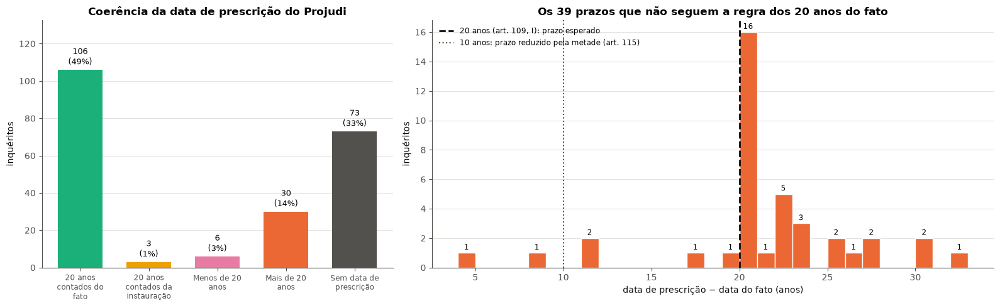

Arquivamentos por prescrição: anos entre o fato e a conclusão no MP


,Comarca,Assunto_resumido,Data_fato,Data_conclusao_mp,Data_prescricao_projudi,Anos fato → conclusão
N_ordem,,,,,,
39,Goiânia,Latrocínio,2002-04-19,2022-11-21,NaT,20.60
40,Goiânia,Homicídio simples,2022-02-11,2022-04-11,NaT,0.20
121,Goiânia,Homicídio simples,2015-07-28,2024-05-28,2035-07-28,8.80
188,Anápolis,Homicídio simples,2001-12-16,2022-04-06,NaT,20.30
192,Aparecida de Goiânia,Homicídio simples,2012-04-08,2024-02-26,2032-04-08,11.90
193,Luziânia,Homicídio simples,2002-06-26,2022-10-28,NaT,20.30
195,Aparecida de Goiânia,Homicídio simples,2011-09-21,2025-01-30,NaT,13.40
197,Aparecida de Goiânia,Homicídio simples,2001-10-07,2022-01-13,NaT,20.30
224,Luziânia,Homicídio simples,2004-04-22,2022-10-11,2024-12-31,18.50


In [63]:
anos_ate_prescricao = (dados['Data_prescricao_projudi'] - dados['Data_fato']).dt.days / 365.25
TOLERANCIA_DIAS = 7  # admite pequenas diferenças de contagem do dia inicial
desvio_fato = (dados['Data_prescricao_projudi'] - (dados['Data_fato'] + pd.DateOffset(years=20))).dt.days
desvio_instauracao = (dados['Data_prescricao_projudi'] - (dados['Data_instauracao'] + pd.DateOffset(years=20))).dt.days
classe_prescricao = np.select(
    [dados['Data_prescricao_projudi'].isna(),
     desvio_fato.abs().le(TOLERANCIA_DIAS).fillna(False),
     desvio_instauracao.abs().le(TOLERANCIA_DIAS).fillna(False),
     anos_ate_prescricao.lt(20).fillna(False)],
    ['Sem data de prescrição', '20 anos contados do fato', '20 anos contados da instauração', 'Menos de 20 anos'],
    default='Mais de 20 anos')
ORDEM_PRESCRICAO = ['20 anos contados do fato', '20 anos contados da instauração', 'Menos de 20 anos',
                    'Mais de 20 anos', 'Sem data de prescrição']
dados['Coerencia_prescricao'] = para_categoria(pd.Series(classe_prescricao, index=dados.index),
                                               {c: c for c in ORDEM_PRESCRICAO}, ORDEM_PRESCRICAO)
display(verificar_particao(dados['Coerencia_prescricao']))

fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [1, 1.6]})
# 1. Quantos inquéritos em cada classe (escala linear, contagem e % sobre a barra)
contagem = dados['Coerencia_prescricao'].value_counts().reindex(ORDEM_PRESCRICAO)
cores_classe = [CORES[2], CORES[3], CORES[4], COR_DESTAQUE, TINTA_2]
axes[0].bar(range(len(contagem)), contagem.values, color=cores_classe, width=0.65)
for i, n in enumerate(contagem.values):
    axes[0].text(i, n + 1.5, f'{n}\n({100 * n / len(dados):.0f}%)', ha='center', va='bottom', fontsize=9)
axes[0].set_xticks(range(len(contagem)), [quebrar(c, 14) for c in contagem.index], fontsize=8.5)
axes[0].set_ylim(0, contagem.max() * 1.25)
axes[0].set_ylabel('inquéritos')
axes[0].set_title('Coerência da data de prescrição do Projudi')
axes[0].grid(axis='x', visible=False)

# 2. Onde estão os prazos incoerentes: só os casos que NÃO estão nos 20 anos do fato
fora = anos_ate_prescricao[dados['Coerencia_prescricao'].isin(['Menos de 20 anos', 'Mais de 20 anos', '20 anos contados da instauração'])]
barras = np.arange(np.floor(fora.min()), np.ceil(fora.max()) + 1, 1.0)
n_barra, bordas, retangulos = axes[1].hist(fora, bins=barras, color=COR_DESTAQUE, edgecolor='white')
for n, esquerda in zip(n_barra, bordas[:-1]):
    if n > 0:
        axes[1].text(esquerda + 0.5, n + 0.1, f'{int(n)}', ha='center', va='bottom', fontsize=8.5)
axes[1].axvline(20, color=TINTA, linewidth=2, linestyle='--', label='20 anos (art. 109, I): prazo esperado')
axes[1].axvline(10, color=TINTA_2, linewidth=1.5, linestyle=':', label='10 anos: prazo reduzido pela metade (art. 115)')
axes[1].set_xlabel('data de prescrição − data do fato (anos)')
axes[1].set_ylabel('inquéritos')
axes[1].set_title(f'Os {len(fora)} prazos que não seguem a regra dos 20 anos do fato')
axes[1].legend(fontsize=8.5, loc='upper left')
axes[1].grid(axis='x', visible=False)
plt.tight_layout()
plt.show()

print('Arquivamentos por prescrição: anos entre o fato e a conclusão no MP')
arq_prescricao = dados.loc[dados['Status_projudi'].eq('Arquivado: extinção da punibilidade (prescrição)'),
                           ['Comarca', 'Assunto_resumido', 'Data_fato', 'Data_conclusao_mp', 'Data_prescricao_projudi']]
arq_prescricao['Anos fato → conclusão'] = ((arq_prescricao['Data_conclusao_mp'] - arq_prescricao['Data_fato']).dt.days / 365.25).round(1)
display(arq_prescricao)
for n_ordem in arq_prescricao.index[arq_prescricao['Anos fato → conclusão'] < 10]:
    registrar(n_ordem, 'Status_projudi', 'Arquivado - EXTINÇÃO DA PUNIBILIDADE - PRESCRIÇÃO',
              'Prescrição com menos de 10 anos entre o fato e a conclusão', 'Mantido; conferir no processo')

In [64]:
em_curso = dados[dados['Status_macro'].isin(['Ativo', 'Suspenso'])].copy()
em_curso['Anos até prescrever'] = ((em_curso['Data_prescricao_projudi'] - DATA_REFERENCIA).dt.days / 365.25).round(1)
em_curso['Idade do fato (anos)'] = ((DATA_REFERENCIA - em_curso['Data_fato']).dt.days / 365.25).round(1)
risco = em_curso[['Comarca', 'Desfecho', 'Data_fato', 'Idade do fato (anos)', 'Data_prescricao_projudi', 'Anos até prescrever',
                  'Houve_indiciamento']].sort_values('Idade do fato (anos)', ascending=False)
print(f'{len(risco)} inquéritos em curso (ativos ou suspensos) na data de referência; fato mais antigo há '
      f'{risco["Idade do fato (anos)"].max():.1f} anos; menor prazo restante até a prescrição: '
      f'{risco["Anos até prescrever"].min():.1f} anos; {int(risco["Houve_indiciamento"].eq(False).sum())} sem indiciado')
display(risco)

37 inquéritos em curso (ativos ou suspensos) na data de referência; fato mais antigo há 11.1 anos; menor prazo restante até a prescrição: 10.0 anos; 16 sem indiciado


,Comarca,Desfecho,Data_fato,Idade do fato (anos),Data_prescricao_projudi,Anos até prescrever,Houve_indiciamento
N_ordem,,,,,,,
126,Luziânia,Em investigação,2015-01-28,11.10,2045-08-14,19.40,False
289,Anápolis,Em investigação,2016-03-08,10.00,2036-03-10,10.00,False
6,Goiânia,Em investigação,2017-04-08,8.90,2037-04-08,11.10,False
147,Goiânia,Em investigação,2017-06-01,8.80,2037-06-01,11.20,False
198,Goiânia,Em investigação,2017-10-21,8.40,2037-10-21,11.60,False
180,Goiânia,Em investigação,2018-01-26,8.10,2038-01-29,11.90,False
81,Goiânia,Em investigação,2018-02-02,8.10,2038-02-02,11.90,False
129,Goiânia,Em investigação,2018-03-02,8.00,2038-03-02,12.00,False
58,Goiânia,Em investigação,2019-03-13,7.00,2039-03-13,13.00,False


**Leitura.**

- **O Projudi aplica a regra dos 20 anos na maioria dos casos.** Dos 145 inquéritos com data de prescrição, 106 (73%) têm exatamente fato + 20 anos (art. 109, I) e outros 3 contam os 20 anos da instauração. Trinta (21%) têm prazo **maior** que 20 anos, até 32,8, o que nenhuma regra do CP justifica antes da denúncia. Parecem datas recalculadas a partir de outro marco, possivelmente o recebimento no Projudi: em 10 dos 30 casos a prescrição cai exatamente 20 anos depois do recebimento. Seis têm prazo menor que 20 anos, e 73 (33%) não têm data. **A data de prescrição do Projudi não é confiável como variável analítica.**
- **Arquivamentos por prescrição.** Dos 10 casos, 5 são coerentes (≥ 20 anos entre o fato e a conclusão) e 3 são compatíveis com a redução pela metade do art. 115 (11,9, 13,4 e 18,5 anos). Dois são **incompatíveis com qualquer prazo legal**: N_ordem 40 (fato em 02/2022, arquivado por "prescrição" dois meses depois) e N_ordem 121 (8,8 anos). Ambos foram incluídos na auditoria, que passa a ter 24 registros. O mais provável é erro de lançamento do motivo, por exemplo extinção por morte do agente registrada como prescrição.
- **Risco nos casos em curso.** Não há prescrição iminente. Dos 37 inquéritos ativos ou suspensos, o mais próximo do prazo (N_ordem 289, Anápolis) ainda tem 10 anos. Mas 16 deles não têm indiciado, e os mais antigos (fatos de 2015 a 2019, sobretudo em Goiânia) já consumiram de um terço a mais da metade do prazo sem autoria definida. É esse grupo que o MP deveria priorizar.

### 9.2 Validação das regras textuais

As categorias de diligência e o indício de intervenção estatal vêm de expressões regulares. Duas verificações:

1. **Ambiguidade**: quantos itens casam com mais de uma regra? Nesses itens, a categoria foi decidida pela **ordem** das regras, e não pelo conteúdo;
2. **Amostra para conferência humana**: até 6 itens por categoria, sorteados com semente fixa, e todos os casos de intervenção estatal são exportados para a planilha `rafaelcc_validacao_regras.xlsx`, com colunas em branco para o parecer do leitor. O parecer preenchido é salvo à parte, em `rafaelcc_validacao_regras_parecer.xlsx`, que a reexecução não sobrescreve. Dele saem a taxa de acerto de cada regra e a precisão do indício de intervenção estatal.

In [65]:
def regras_que_casam(item):
    chave = normalizar_chave(item)
    return [categoria for categoria, padrao in REGRAS_DILIGENCIA if re.search(padrao, chave)]


diligencias_longas['Regras que casam'] = diligencias_longas['Item'].map(regras_que_casam)
diligencias_longas['N regras'] = diligencias_longas['Regras que casam'].map(len)
ambiguidade = (diligencias_longas.groupby('Categoria', observed=True)
               .agg(Itens=('Item', 'size'),
                    Sem_regra=('N regras', lambda s: int((s == 0).sum())),
                    Ambiguos=('N regras', lambda s: int((s > 1).sum())))
               .assign(**{'% ambíguos': lambda t: (100 * t['Ambiguos'] / t['Itens']).round(1)}))
print(f"Itens que casam com mais de uma regra: {int((diligencias_longas['N regras'] > 1).sum())} de {len(diligencias_longas)} "
      f"({100 * (diligencias_longas['N regras'] > 1).mean():.1f}%)")
display(ambiguidade)

amostra_validacao = pd.concat([
    grupo.sample(min(len(grupo), 6), random_state=2026)
    for _, grupo in diligencias_longas.groupby('Categoria', observed=True)
])[['N_ordem', 'Item', 'Categoria']].assign(**{'Regras que casam': lambda t: diligencias_longas.loc[t.index, 'Regras que casam'].str.join(' | '),
                                               'Parecer (OK/Errado)': '', 'Categoria correta': ''})
casos_intervencao_validar = dados.loc[dados['Indicio_intervencao_estatal'], ['Comarca', 'Capitulacao', 'Tipo_manifestacao_mp']].assign(
    **{'Parecer (Sim/Não)': ''})

ARQUIVO_VALIDACAO = PASTA_SAIDA / 'rafaelcc_validacao_regras.xlsx'
with pd.ExcelWriter(ARQUIVO_VALIDACAO, engine='openpyxl') as planilha:
    amostra_validacao.to_excel(planilha, sheet_name='diligencias', index=False)
    casos_intervencao_validar.to_excel(planilha, sheet_name='intervencao_estatal')
print(f'Amostra de validação: {len(amostra_validacao)} itens de diligência e {len(casos_intervencao_validar)} casos de '
      f'intervenção → {ARQUIVO_VALIDACAO.name}')
diligencias_longas = diligencias_longas.drop(columns=['Regras que casam', 'N regras'])

# O parecer fica num arquivo separado, que a reexecução não sobrescreve
ARQUIVO_PARECER = PASTA_SAIDA / 'rafaelcc_validacao_regras_parecer.xlsx'
if ARQUIVO_PARECER.exists():
    parecer_dil = pd.read_excel(ARQUIVO_PARECER, sheet_name='diligencias')
    parecer_int = pd.read_excel(ARQUIVO_PARECER, sheet_name='intervencao_estatal')
    print(f"Parecer: {ARQUIVO_PARECER.name} | revisor: {'; '.join(parecer_dil['Revisor'].dropna().unique())}")
    acerto = (parecer_dil.assign(OK=parecer_dil['Parecer (OK/Errado)'].str.strip().str.upper().eq('OK'))
              .groupby('Categoria').agg(Itens=('OK', 'size'), Corretos=('OK', 'sum')))
    acerto.loc['Total'] = acerto.sum()
    acerto['Acerto'] = acerto['Corretos'] / acerto['Itens']
    acerto['IC 95% (Wilson)'] = [
        '{:.0%}–{:.0%}'.format(*proportion_confint(c, n, method='wilson')) for c, n in zip(acerto['Corretos'], acerto['Itens'])]
    display(acerto.style.format({'Acerto': '{:.0%}'}))
    confirmados = parecer_int['Parecer (Sim/Não)'].str.strip().str.lower().eq('sim')
    li, ls = proportion_confint(confirmados.sum(), len(confirmados), method='wilson')
    print(f'Intervenção estatal: {confirmados.sum()} de {len(confirmados)} casos confirmados '
          f'(precisão {confirmados.mean():.0%}; IC 95% {li:.0%}–{ls:.0%})')
    display(parecer_int[['N_ordem', 'Comarca', 'Parecer (Sim/Não)', 'Evidência']])
    observacoes = parecer_dil.loc[parecer_dil['Observação'].notna(), ['N_ordem', 'Item', 'Categoria', 'Observação']]
    if len(observacoes):
        display(observacoes)
else:
    print(f'Parecer ainda não preenchido: salve a planilha revisada como {ARQUIVO_PARECER.name}')

Itens que casam com mais de uma regra: 76 de 444 (17.1%)


,Itens,Sem_regra,Ambiguos,% ambíguos
Categoria,,,,
Prazo e conclusão do inquérito,126,0,7,5.60
Perícias e laudos,100,0,21,21.00
Oitivas e identificação de pessoas,75,0,5,6.70
"Competência, redistribuição e apensamento",34,0,0,0.00
"Documentos, certidões e informações",31,0,0,0.00
"Imagens, mídias e dados telemáticos",30,0,19,63.30
"Medidas cautelares, prisão e atos processuais",25,0,4,16.00
Controle externo da atividade policial,22,0,19,86.40
Outras providências,1,0,1,100.00


Amostra de validação: 49 itens de diligência e 14 casos de intervenção → rafaelcc_validacao_regras.xlsx
Parecer ainda não preenchido: salve a planilha revisada como rafaelcc_validacao_regras_parecer.xlsx


**Leitura.** Nenhum item ficou sem regra, e só um caiu no resíduo "Outras providências". Mas **17% dos itens (76 de 444) casam com mais de uma regra**, e neles a categoria foi decidida pela ordem das regras. A ambiguidade concentra-se em duas categorias. Em "Controle externo" (86%), itens como "imagens da viatura da PM" também citam mídia; a ordem dá prioridade ao controle externo, que é o aspecto de maior interesse jurídico. Em "Imagens e dados" (63%), os itens também mencionam oitiva ou perícia. Nas categorias grandes (prazo, oitivas, documentos, competência), a ambiguidade é baixa (0–7%).

Isso não invalida a partição, porque cada item continua com exatamente um rótulo. Mas as frequências de "Controle externo" e "Imagens" dependem da ordem das regras. A planilha `rafaelcc_validacao_regras.xlsx` tem 49 itens e os 14 casos de intervenção estatal para conferência.

**Resultado da conferência.** Os 49 itens da amostra foram considerados corretamente classificados (acerto de 100%; IC 95% de Wilson 93–100%). Quatro são limítrofes e estão anotados na tabela de observações: a perícia em celular, as mídias de gravação das oitivas, a suspensão do art. 366 do CPP e a destinação de armas apreendidas. Nos quatro, a categoria atribuída é defensável, mas outra também seria. Os 14 casos marcados como intervenção estatal foram confirmados (precisão de 100%; IC 95% 78–100%). Dois deles são tentativas sem óbito (N_ordem 184 e 210), e em outros dois a evidência é indireta: um ofício à Corregedoria da PM (106) e a menção à existência de um IPM (246).

**Limites.** A conferência mede só a **precisão** das regras: verifica se o que foi rotulado está certo. Ela não mede a **sensibilidade**, porque não se examinaram os casos não marcados em busca de intervenções que as regras deixaram passar. Com 6 itens por categoria, o acerto de cada categoria tem intervalo largo. O parecer registrado na planilha é uma revisão preliminar e deve ser confirmado pelo autor.

**Auditoria atualizada.** A tabela de auditoria, acrescida dos registros desta seção, e a nova variável `Coerencia_prescricao` são regravadas no dataset exportado.

In [66]:
auditoria = pd.DataFrame(registros_auditoria).drop_duplicates().sort_values(['Variável', 'N_ordem']).reset_index(drop=True)
ESQUEMA_EXPORT = pd.concat([ESQUEMA, pd.DataFrame([{
    'Variável': 'Coerencia_prescricao', 'Grupo': 'Tempo', 'Tipo estatístico': 'Qualitativa nominal', 'dtype pandas': 'category',
    'Unidade': '', 'Origem': 'Derivada (seção 9.1)', 'Uso analítico': 'Auditoria',
    'Não nulos': int(dados['Coerencia_prescricao'].notna().sum()), 'Ausentes': int(dados['Coerencia_prescricao'].isna().sum()),
    'Distintos': int(dados['Coerencia_prescricao'].nunique())}])], ignore_index=True)
assert set(ESQUEMA_EXPORT['Variável']) == set(dados.columns)

dados.to_pickle(ARQUIVO_PKL)
with pd.ExcelWriter(ARQUIVO_XLSX, engine='openpyxl') as planilha:
    dados.to_excel(planilha, sheet_name='dados')
    ESQUEMA_EXPORT.to_excel(planilha, sheet_name='esquema', index=False)
    auditoria.to_excel(planilha, sheet_name='auditoria', index=False)
    diligencias_longas.to_excel(planilha, sheet_name='diligencias_longas', index=False)
pd.testing.assert_frame_equal(pd.read_pickle(ARQUIVO_PKL), dados)
print(f'Dataset regravado: {dados.shape[0]} × {dados.shape[1]}; auditoria com {len(auditoria)} registros')
display(auditoria[auditoria['Problema'].str.contains('Prescrição')])

Dataset regravado: 218 × 61; auditoria com 24 registros


,N_ordem,Variável,Valor original,Problema,Tratamento
16,40,Status_projudi,Arquivado - EXTINÇÃO DA PUNIBILIDADE - PRESCRIÇÃO,Prescrição com menos de 10 anos entre o fato e a conclusão,Mantido; conferir no processo
17,121,Status_projudi,Arquivado - EXTINÇÃO DA PUNIBILIDADE - PRESCRIÇÃO,Prescrição com menos de 10 anos entre o fato e a conclusão,Mantido; conferir no processo


---

# PARTE I-B — A ANÁLISE EXPLORATÓRIA PROPOSTA PELO PROFESSOR

As seções 10 a 14 seguem o roteiro do notebook da disciplina (`estcaso_ip.ipynb`): as funções do professor, aprimoradas, e os Exercícios 1 a 5 resolvidos, com os desafios. Elas usam o dataset já curado na Parte I. A variável de tempo usada aqui, `Tempo_conclusao_ip`, é a do enunciado; a Parte II mostra o que ela realmente mede e define o desfecho com mais rigor.

---

## 10. Análise de Variáveis Categóricas (Exercício 1)

### Objetivo
Gráficos de barras/colunas para cada variável categórica (nominal ou ordinal), com contagem acima de cada barra, proporção (%) e tabela de frequências.

### Função auxiliar — com o desafio de Pareto resolvido

A função do professor foi estendida:

- **`pareto='sim'`** (com `decresc='sim'`) acrescenta a curva de frequência relativa acumulada no eixo direito e marca o ponto de corte de 80%. As barras que compõem os primeiros 80% ficam em cor cheia e as demais em tom claro. O eixo esquerdo vai de 0 a *n* e o direito de 0 a 100%: são **a mesma escala** (contagem e percentual do total), de modo que a curva e as barras são diretamente comparáveis — não é um gráfico de dois eixos com escalas independentes;
- `decresc='não'` respeita a ordem das categorias do dtype (essencial para variáveis ordinais como `Faixa_tempo_ip`);
- booleanos recebem rótulos legíveis apenas na exibição; rótulos longos são quebrados em linhas;
- a tabela de frequências (antes comentada) agora é exibida, com a frequência acumulada.

In [67]:
def serie_exibicao(dados, variavel):
    """Versão para exibição: booleanos viram category com rótulos; categorias mantêm sua ordem."""
    serie = dados[variavel]
    if isinstance(serie.dtype, pd.BooleanDtype):
        falso, verdadeiro = ROTULOS_BOOLEANOS.get(variavel, ('Não', 'Sim'))
        return serie.map({False: falso, True: verdadeiro}).astype(pd.CategoricalDtype([falso, verdadeiro]))
    return serie


def quebrar(rotulo, largura=16):
    return '\n'.join(textwrap.wrap(str(rotulo), largura)) or str(rotulo)


def grafico_barras_completo(dados, variavel, decresc='não', titulo=None, rotacao=0, pareto='não', largura_rotulo=16):
    """
    Gráfico de barras com contagens, proporções e tabela de frequências.

    - decresc: 'sim' ordena por frequência decrescente; 'não' mantém a ordem das categorias
    - pareto: 'sim' (exige decresc='sim') adiciona a curva acumulada e o corte de 80%
    """
    serie = serie_exibicao(dados, variavel)
    freq = serie.value_counts(sort=False)
    if decresc.lower() == 'sim':
        freq = freq.sort_values(ascending=False, kind='stable')
    n = int(freq.sum())
    prop = 100 * freq / n
    acumulada = prop.cumsum()
    usar_pareto = pareto.lower() == 'sim' and decresc.lower() == 'sim'

    k = len(freq)
    fig, ax = plt.subplots(figsize=(max(7, 1.05 * k + 3), 5.2))
    posicoes = np.arange(k)
    if usar_pareto:
        corte = int(np.argmax(acumulada.values >= 80)) + 1  # nº de categorias até atingir 80%
        cores = [COR_PRINCIPAL if i < corte else COR_SECUNDARIA for i in range(k)]
    else:
        cores = COR_PRINCIPAL
    barras = ax.bar(posicoes, freq.values, color=cores, width=0.72, edgecolor='white', linewidth=2)

    topo = n if usar_pareto else freq.max()
    for barra, contagem, pct in zip(barras, freq.values, prop.values):
        x = barra.get_x() + barra.get_width() / 2
        ax.text(x, barra.get_height() + topo * 0.012, f'{contagem}', ha='center', va='bottom',
                fontsize=10, fontweight='bold', color=TINTA)
        if barra.get_height() >= topo * 0.09:
            ax.text(x, barra.get_height() / 2, f'{pct:.1f}%', ha='center', va='center', fontsize=9, color='white',
                    fontweight='bold')
        else:
            ax.text(x, barra.get_height() + topo * 0.075, f'{pct:.1f}%', ha='center', va='bottom', fontsize=8.5,
                    color=TINTA_2)

    ax.set_xticks(posicoes)
    ax.set_xticklabels([quebrar(c, largura_rotulo) for c in freq.index], rotation=rotacao,
                       ha='right' if rotacao else 'center')
    ax.set_ylabel('Frequência (nº de inquéritos)')
    ax.set_xlabel(variavel)
    ax.set_title(titulo or f'Distribuição de {variavel}', pad=14)
    ax.grid(axis='x', visible=False)

    if usar_pareto:
        ax.set_ylim(0, n * 1.08)
        ax2 = ax.twinx()
        ax2.set_ylim(0, 108)  # mesma escala do eixo esquerdo: n ↔ 100%
        ax2.plot(posicoes, acumulada.values, color=COR_DESTAQUE, marker='o', markersize=6, linewidth=2)
        ax2.axhline(80, color=TINTA_2, linestyle='--', linewidth=1)
        ax2.axvline(corte - 1, color=TINTA_2, linestyle=':', linewidth=1)
        ax2.annotate(f'80% atingidos com {corte} de {k} categorias ({acumulada.iloc[corte - 1]:.1f}%)',
                     xy=(corte - 1, acumulada.iloc[corte - 1]), xytext=(8, -26), textcoords='offset points',
                     fontsize=9, color=TINTA)
        ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax2.set_ylabel('Frequência relativa acumulada')
        ax2.grid(False)
        ax2.spines['right'].set_visible(True)
    else:
        ax.set_ylim(0, freq.max() * 1.18)

    plt.tight_layout()
    plt.show()

    tabela = pd.DataFrame({'Contagem': freq.values, 'Proporção (%)': prop.values.round(2),
                           'Acumulada (%)': acumulada.values.round(2)}, index=freq.index.astype(str))
    tabela.index.name = variavel
    ausentes = int(serie.isna().sum())
    display(tabela)
    print(f'Total de observações: {n}' + (f'  |  ausentes: {ausentes}' if ausentes else ''))
    return tabela

### Exercício 1: gráficos de barras para cada variável categórica

As variáveis analisadas são as de uso "Categórica" no esquema (`Validacao` e `Lei_codigo_penal` são constantes e ficam de fora). Variáveis nominais com muitas classes usam ordem decrescente com Pareto; as ordinais e as dicotômicas mantêm a ordem natural. Começamos pela comarca, com o diagrama de Pareto pedido no desafio.

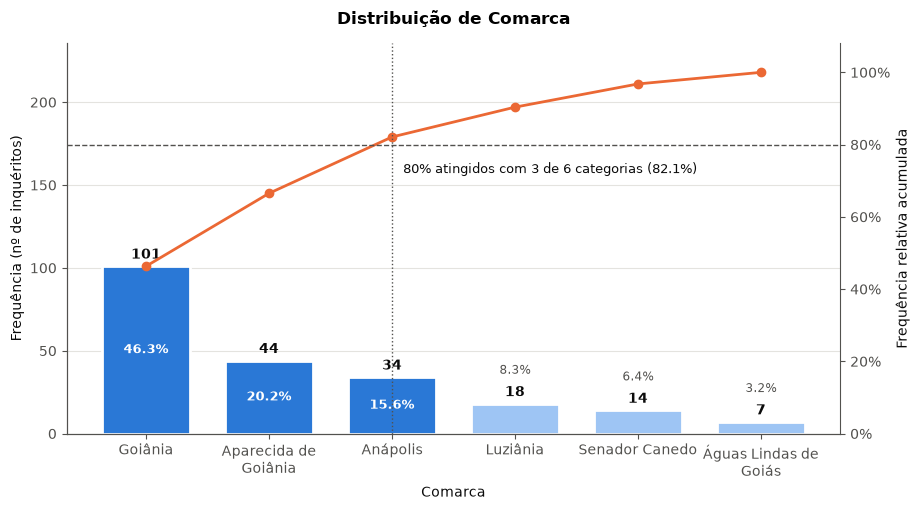

,Contagem,Proporção (%),Acumulada (%)
Comarca,,,
Goiânia,101,46.33,46.33
Aparecida de Goiânia,44,20.18,66.51
Anápolis,34,15.60,82.11
Luziânia,18,8.26,90.37
Senador Canedo,14,6.42,96.79
Águas Lindas de Goiás,7,3.21,100.00


Total de observações: 218


In [68]:
tab_comarca = grafico_barras_completo(dados, 'Comarca', decresc='sim', pareto='sim')

**Leitura.** A amostra é muito concentrada: Goiânia responde por 46,3% dos inquéritos e, com Aparecida de Goiânia (20,2%) e Anápolis (15,6%), as três maiores comarcas somam 82,1% — o ponto de corte de 80% do Pareto é atingido com 3 das 6 categorias. Águas Lindas de Goiás tem apenas 7 casos (3,2%), o que torna frágil qualquer conclusão específica sobre ela: nas comparações por comarca, suas estatísticas devem ser lidas com cautela.

21 variáveis categóricas analisadas: Comarca, Tipo_delegacia, Delegacia_top6, Assunto_resumido, Assunto_grupo, Artigo_principal, Tentativa, Qualificadora_capitulada, Concurso_lei_especial, Houve_indiciamento, Reu_preso, Tramitacao_direta, Forma_instauracao, Arma_de_fogo, Indicio_intervencao_estatal, Desfecho, Status_macro, Concluido_mp, Faixa_tempo_ip, Excedeu_prazo_ip, Houve_manifestacao_mp


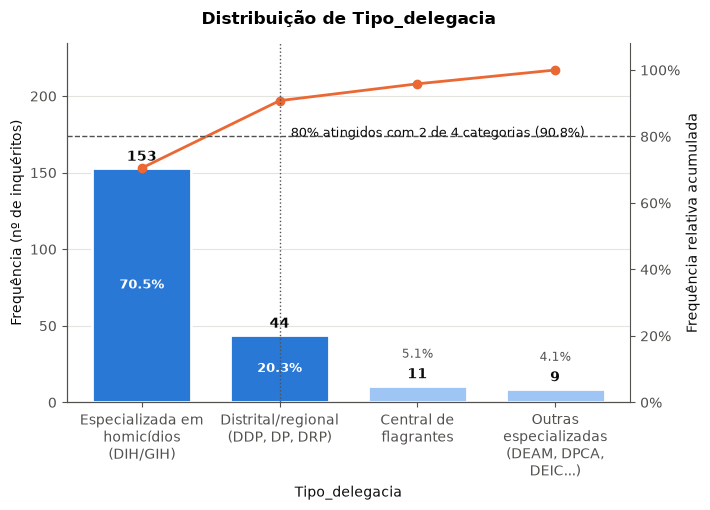

,Contagem,Proporção (%),Acumulada (%)
Tipo_delegacia,,,
Especializada em homicídios (DIH/GIH),153,70.51,70.51
"Distrital/regional (DDP, DP, DRP)",44,20.28,90.78
Central de flagrantes,11,5.07,95.85
"Outras especializadas (DEAM, DPCA, DEIC...)",9,4.15,100.00


Total de observações: 217  |  ausentes: 1


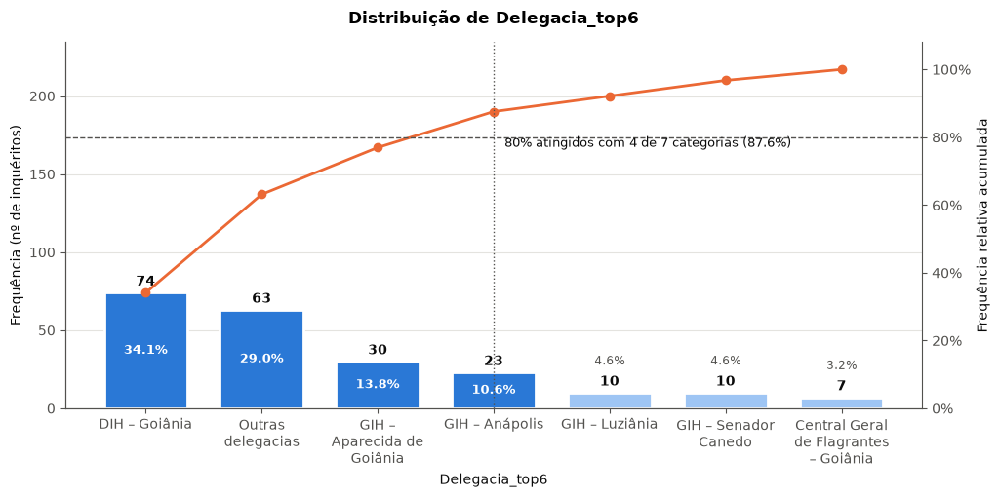

,Contagem,Proporção (%),Acumulada (%)
Delegacia_top6,,,
DIH – Goiânia,74,34.10,34.10
Outras delegacias,63,29.03,63.13
GIH – Aparecida de Goiânia,30,13.82,76.96
GIH – Anápolis,23,10.60,87.56
GIH – Luziânia,10,4.61,92.17
GIH – Senador Canedo,10,4.61,96.77
Central Geral de Flagrantes – Goiânia,7,3.23,100.00


Total de observações: 217  |  ausentes: 1


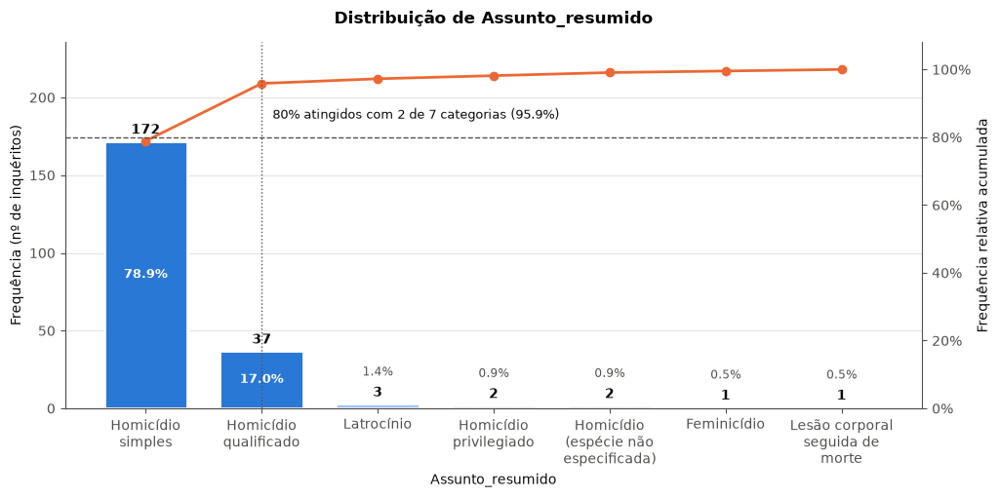

,Contagem,Proporção (%),Acumulada (%)
Assunto_resumido,,,
Homicídio simples,172,78.90,78.90
Homicídio qualificado,37,16.97,95.87
Latrocínio,3,1.38,97.25
Homicídio privilegiado,2,0.92,98.17
Homicídio (espécie não especificada),2,0.92,99.08
Feminicídio,1,0.46,99.54
Lesão corporal seguida de morte,1,0.46,100.00


Total de observações: 218


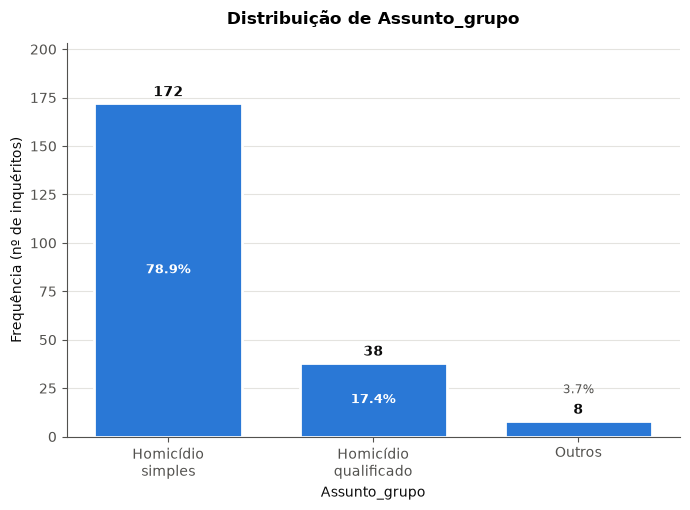

,Contagem,Proporção (%),Acumulada (%)
Assunto_grupo,,,
Homicídio simples,172,78.90,78.90
Homicídio qualificado,38,17.43,96.33
Outros,8,3.67,100.00


Total de observações: 218


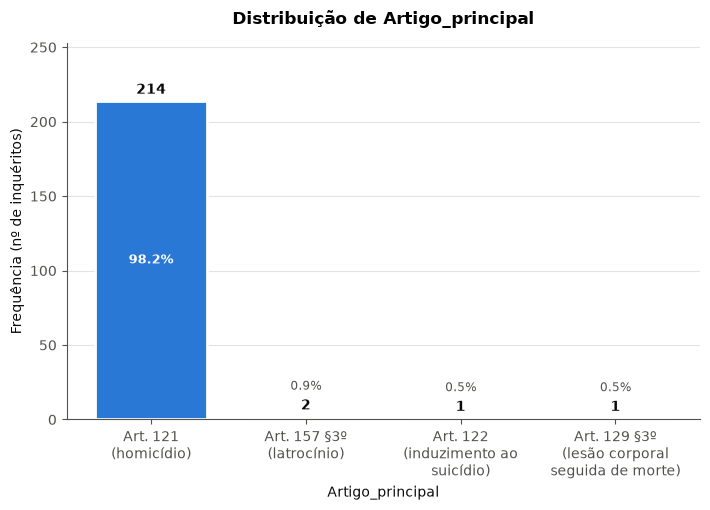

,Contagem,Proporção (%),Acumulada (%)
Artigo_principal,,,
Art. 121 (homicídio),214,98.17,98.17
Art. 157 §3º (latrocínio),2,0.92,99.08
Art. 122 (induzimento ao suicídio),1,0.46,99.54
Art. 129 §3º (lesão corporal seguida de morte),1,0.46,100.00


Total de observações: 218


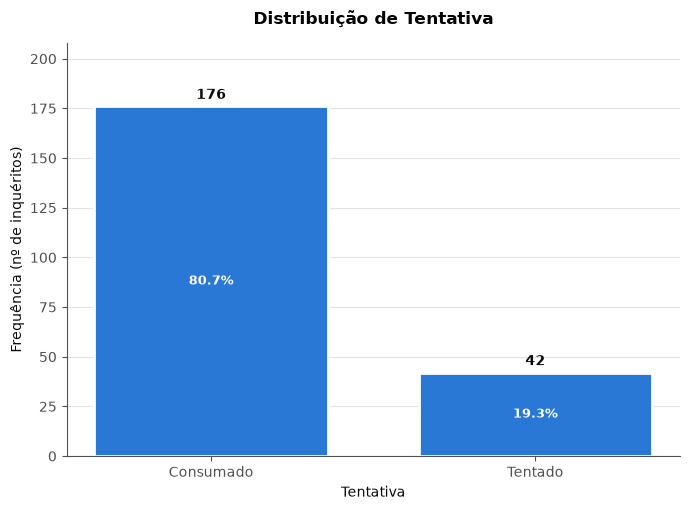

,Contagem,Proporção (%),Acumulada (%)
Tentativa,,,
Consumado,176,80.73,80.73
Tentado,42,19.27,100.00


Total de observações: 218


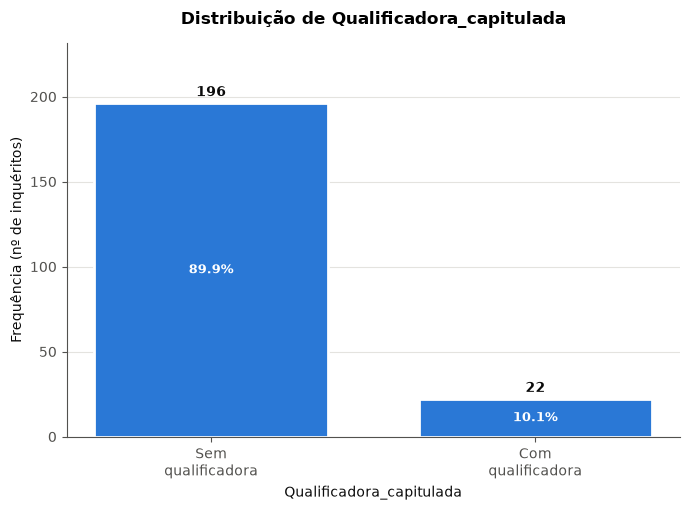

,Contagem,Proporção (%),Acumulada (%)
Qualificadora_capitulada,,,
Sem qualificadora,196,89.91,89.91
Com qualificadora,22,10.09,100.00


Total de observações: 218


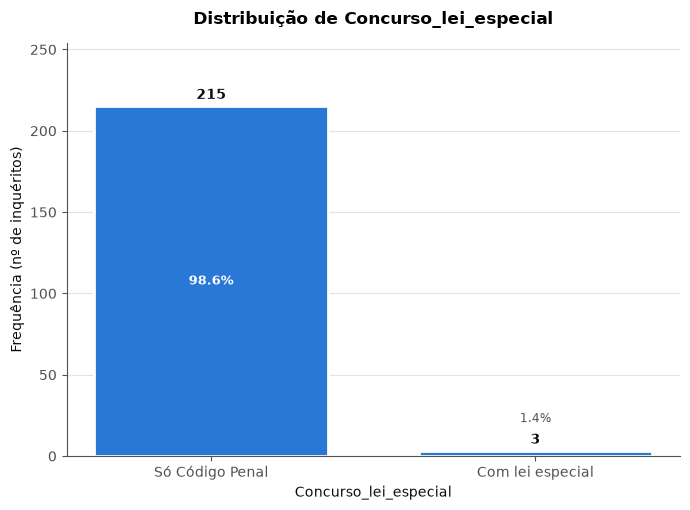

,Contagem,Proporção (%),Acumulada (%)
Concurso_lei_especial,,,
Só Código Penal,215,98.62,98.62
Com lei especial,3,1.38,100.00


Total de observações: 218


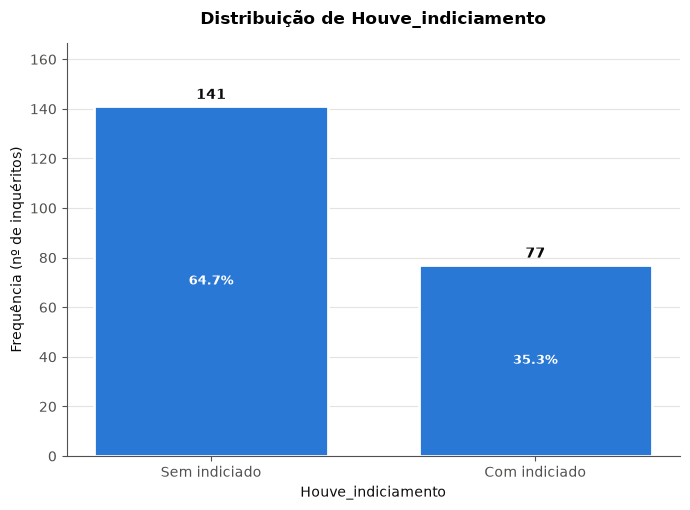

,Contagem,Proporção (%),Acumulada (%)
Houve_indiciamento,,,
Sem indiciado,141,64.68,64.68
Com indiciado,77,35.32,100.00


Total de observações: 218


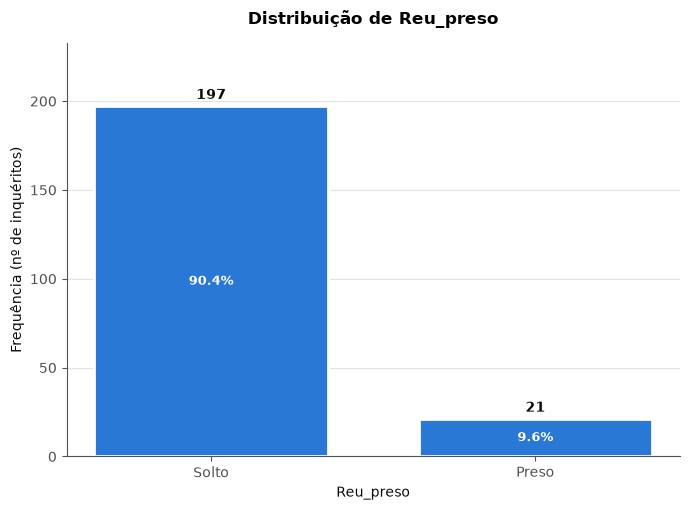

,Contagem,Proporção (%),Acumulada (%)
Reu_preso,,,
Solto,197,90.37,90.37
Preso,21,9.63,100.00


Total de observações: 218


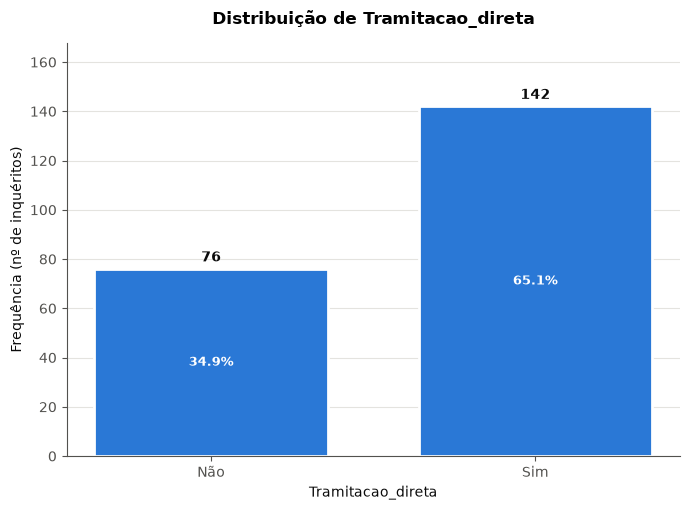

,Contagem,Proporção (%),Acumulada (%)
Tramitacao_direta,,,
Não,76,34.86,34.86
Sim,142,65.14,100.00


Total de observações: 218


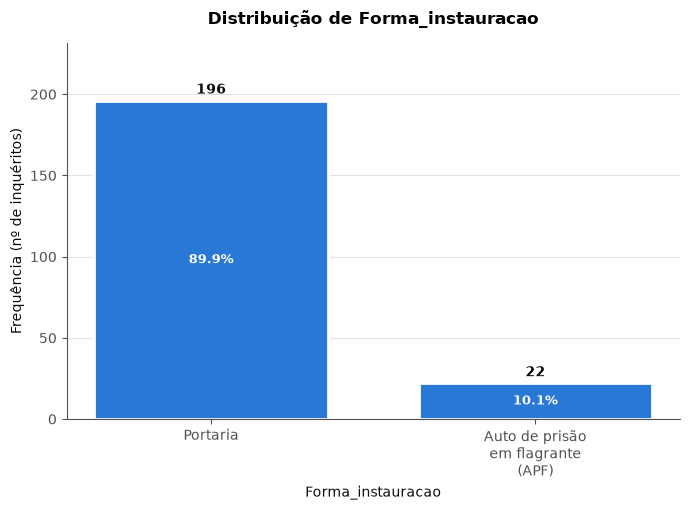

,Contagem,Proporção (%),Acumulada (%)
Forma_instauracao,,,
Portaria,196,89.91,89.91
Auto de prisão em flagrante (APF),22,10.09,100.00


Total de observações: 218


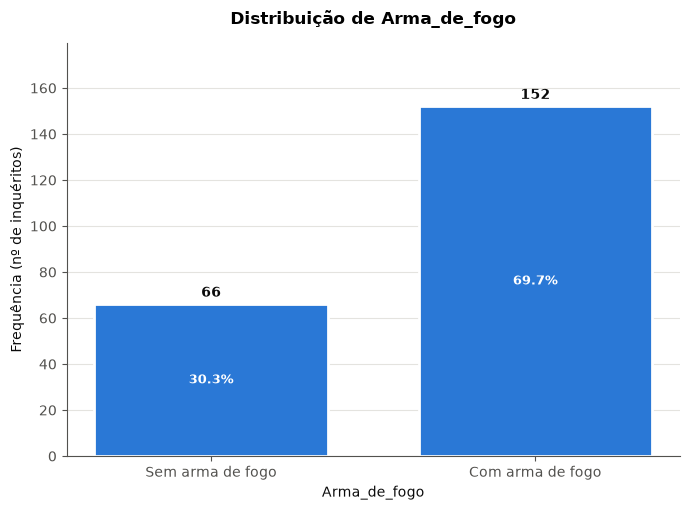

,Contagem,Proporção (%),Acumulada (%)
Arma_de_fogo,,,
Sem arma de fogo,66,30.28,30.28
Com arma de fogo,152,69.72,100.00


Total de observações: 218


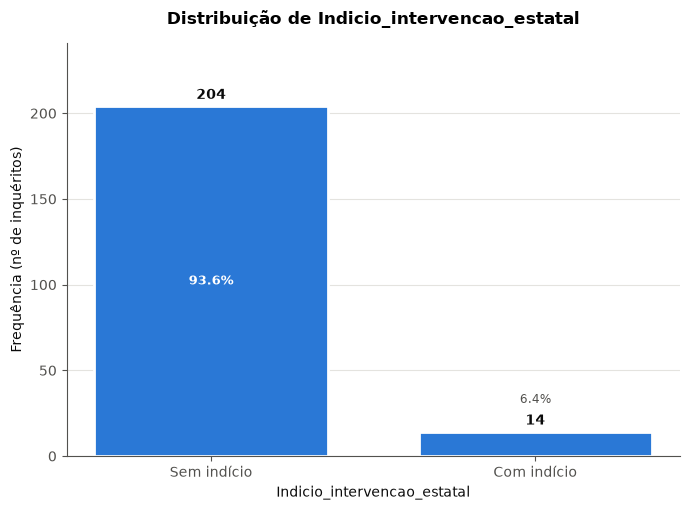

,Contagem,Proporção (%),Acumulada (%)
Indicio_intervencao_estatal,,,
Sem indício,204,93.58,93.58
Com indício,14,6.42,100.00


Total de observações: 218


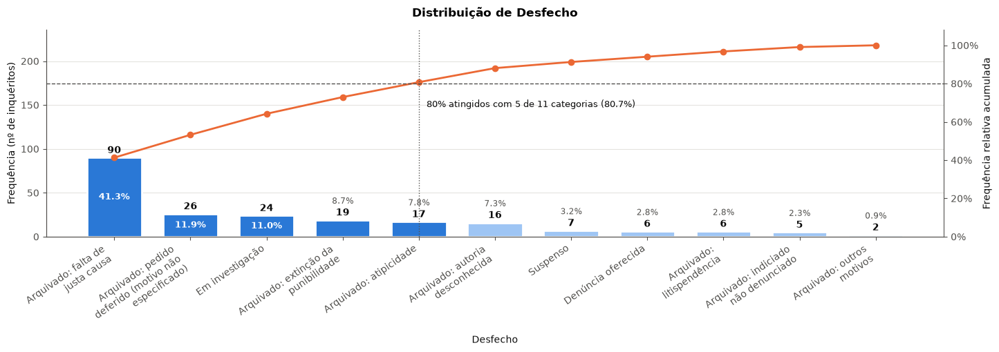

,Contagem,Proporção (%),Acumulada (%)
Desfecho,,,
Arquivado: falta de justa causa,90,41.28,41.28
Arquivado: pedido deferido (motivo não especificado),26,11.93,53.21
Em investigação,24,11.01,64.22
Arquivado: extinção da punibilidade,19,8.72,72.94
Arquivado: atipicidade,17,7.80,80.73
Arquivado: autoria desconhecida,16,7.34,88.07
Suspenso,7,3.21,91.28
Denúncia oferecida,6,2.75,94.04
Arquivado: litispendência,6,2.75,96.79


Total de observações: 218


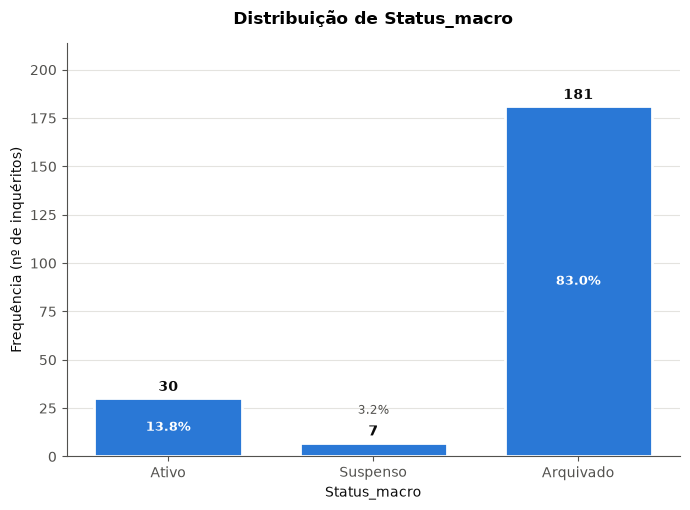

,Contagem,Proporção (%),Acumulada (%)
Status_macro,,,
Ativo,30,13.76,13.76
Suspenso,7,3.21,16.97
Arquivado,181,83.03,100.00


Total de observações: 218


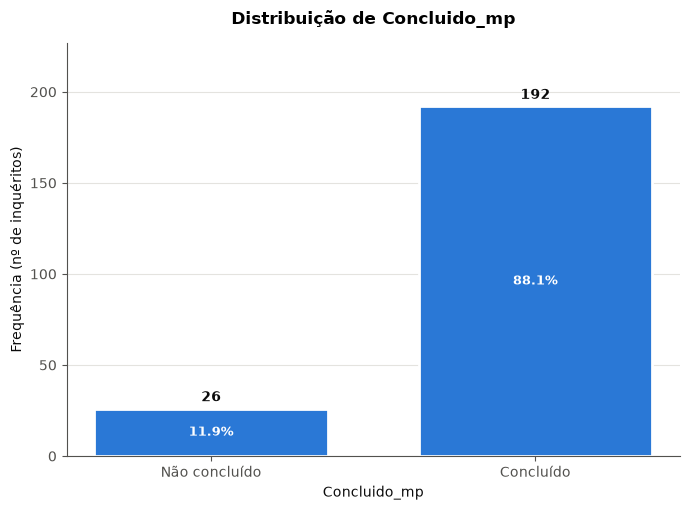

,Contagem,Proporção (%),Acumulada (%)
Concluido_mp,,,
Não concluído,26,11.93,11.93
Concluído,192,88.07,100.00


Total de observações: 218


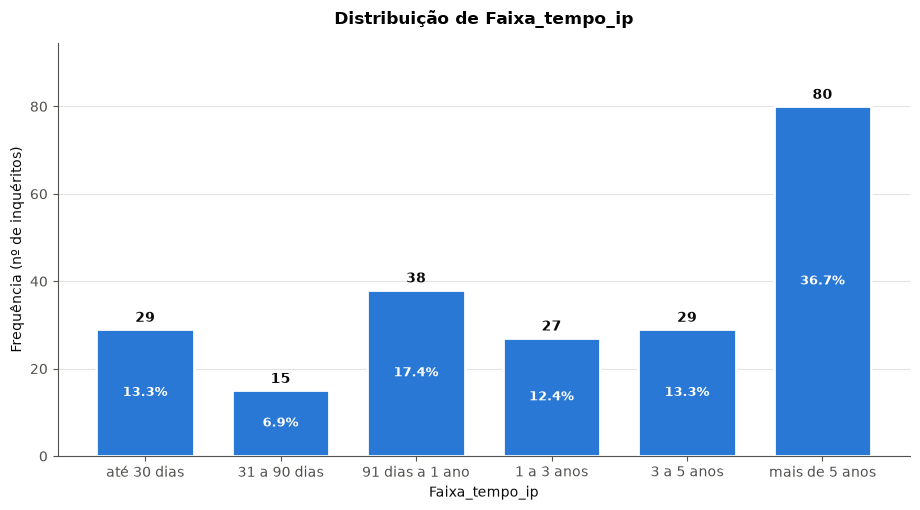

,Contagem,Proporção (%),Acumulada (%)
Faixa_tempo_ip,,,
até 30 dias,29,13.30,13.30
31 a 90 dias,15,6.88,20.18
91 dias a 1 ano,38,17.43,37.61
1 a 3 anos,27,12.39,50.00
3 a 5 anos,29,13.30,63.30
mais de 5 anos,80,36.70,100.00


Total de observações: 218


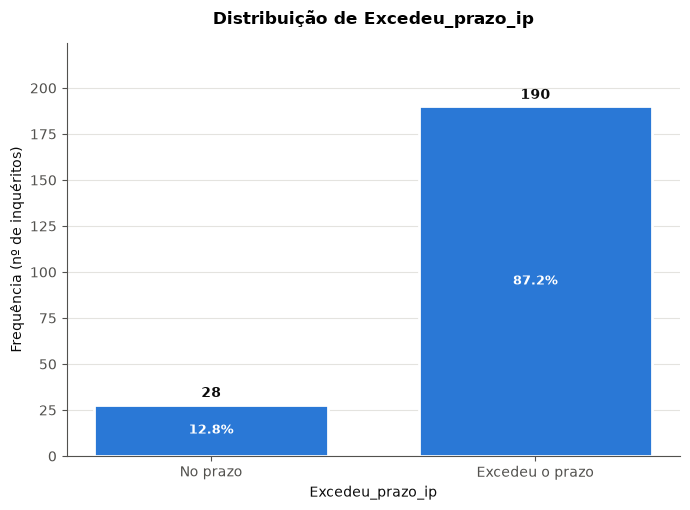

,Contagem,Proporção (%),Acumulada (%)
Excedeu_prazo_ip,,,
No prazo,28,12.84,12.84
Excedeu o prazo,190,87.16,100.00


Total de observações: 218


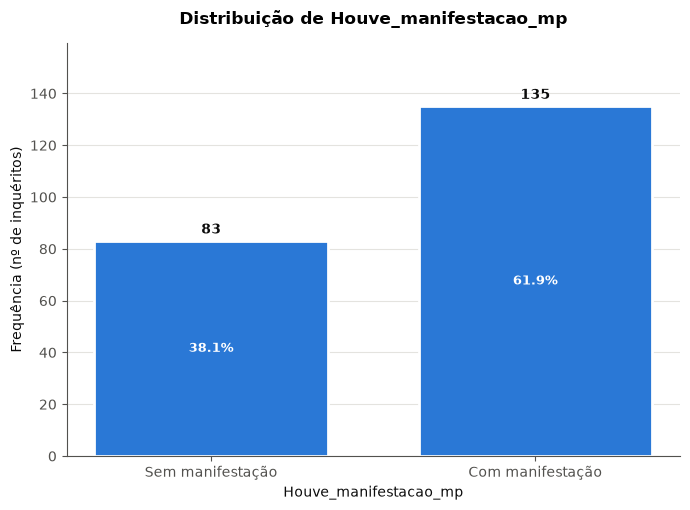

,Contagem,Proporção (%),Acumulada (%)
Houve_manifestacao_mp,,,
Sem manifestação,83,38.07,38.07
Com manifestação,135,61.93,100.00


Total de observações: 218


In [69]:
VARS_CATEGORICAS = ESQUEMA.loc[ESQUEMA['Uso analítico'].eq('Categórica'), 'Variável'].tolist()
print(f'{len(VARS_CATEGORICAS)} variáveis categóricas analisadas:', ', '.join(VARS_CATEGORICAS))

CONFIG_BARRAS = {  # variável: parâmetros específicos
    'Delegacia_top6': dict(decresc='sim', pareto='sim', largura_rotulo=14),
    'Tipo_delegacia': dict(decresc='sim', pareto='sim', largura_rotulo=18),
    'Assunto_resumido': dict(decresc='sim', pareto='sim', largura_rotulo=14),
    'Artigo_principal': dict(decresc='sim', largura_rotulo=18),
    'Desfecho': dict(decresc='sim', pareto='sim', rotacao=35, largura_rotulo=22),
}
tabelas_frequencia = {'Comarca': tab_comarca}
for variavel in VARS_CATEGORICAS:
    if variavel == 'Comarca':
        continue
    tabelas_frequencia[variavel] = grafico_barras_completo(dados, variavel, **CONFIG_BARRAS.get(variavel, {}))

O status processual detalhado (15 classes) e a delegacia (36 unidades) são exibidos à parte, em barras horizontais, porque os rótulos são longos demais para o eixo horizontal.

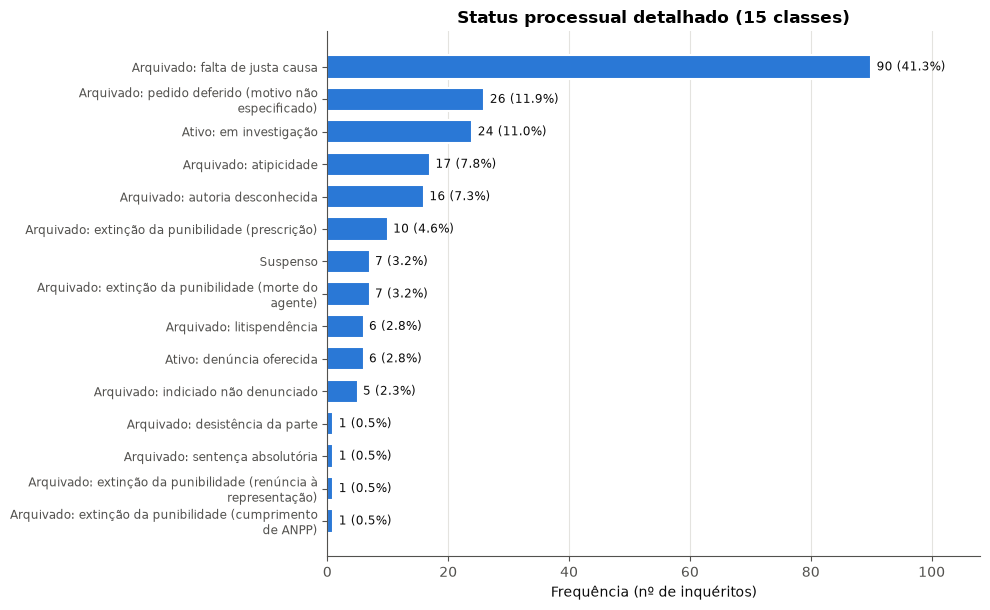

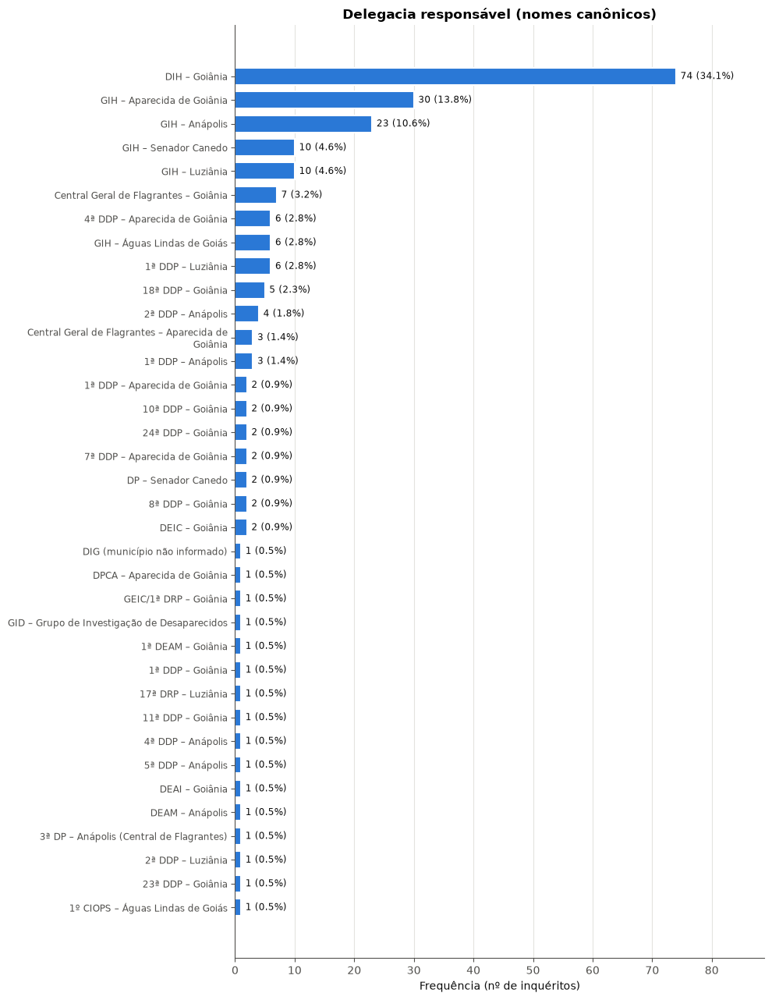

In [70]:
def barras_horizontais(dados, variavel, titulo=None, largura_rotulo=48):
    serie = serie_exibicao(dados, variavel)
    freq = serie.value_counts().sort_values()
    n = int(freq.sum())
    fig, ax = plt.subplots(figsize=(10, 0.32 * len(freq) + 1.4))
    ax.barh([quebrar(c, largura_rotulo) for c in freq.index], freq.values, color=COR_PRINCIPAL, height=0.72,
            edgecolor='white', linewidth=1.5)
    for y, contagem in enumerate(freq.values):
        ax.text(contagem + freq.max() * 0.01, y, f'{contagem} ({100 * contagem / n:.1f}%)', va='center',
                fontsize=8.5, color=TINTA)
    ax.set_xlim(0, freq.max() * 1.2)
    ax.set_xlabel('Frequência (nº de inquéritos)')
    ax.set_title(titulo or f'Distribuição de {variavel}')
    ax.grid(axis='y', visible=False)
    ax.tick_params(axis='y', labelsize=8.5)
    plt.tight_layout()
    plt.show()


barras_horizontais(dados, 'Status_projudi', 'Status processual detalhado (15 classes)')
barras_horizontais(dados, 'Nome_delegacia', 'Delegacia responsável (nomes canônicos)')

**Campo multirresposta.** Nas diligências, a pergunta certa não é "qual a categoria do caso" (um caso pode ter várias), mas "em quantos casos com manifestação do MP aparece cada tipo de diligência". Por isso as porcentagens abaixo somam mais de 100%.

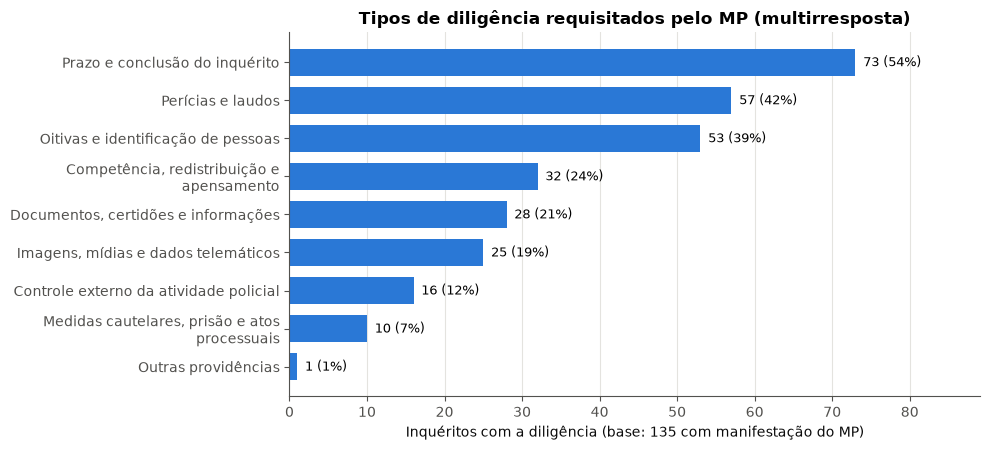

In [71]:
casos_com_manifestacao = int(dados['Houve_manifestacao_mp'].sum())
freq_dil = dados[list(COLUNA_DILIGENCIA.values())].sum().rename(index={v: k for k, v in COLUNA_DILIGENCIA.items()})
freq_dil = freq_dil.sort_values()
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.barh([quebrar(c, 40) for c in freq_dil.index], freq_dil.values, color=COR_PRINCIPAL, height=0.7)
for y, v in enumerate(freq_dil.values):
    ax.text(v + 1, y, f'{v} ({100 * v / casos_com_manifestacao:.0f}%)', va='center', fontsize=9)
ax.set_xlim(0, freq_dil.max() * 1.22)
ax.set_xlabel(f'Inquéritos com a diligência (base: {casos_com_manifestacao} com manifestação do MP)')
ax.set_title('Tipos de diligência requisitados pelo MP (multirresposta)')
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

In [72]:
perfil_categorico = pd.DataFrame([
    {'Variável': v, 'Níveis': len(t), 'Categoria modal': t['Contagem'].idxmax(),
     'Casos na moda': int(t['Contagem'].max()), '% da moda': round(t['Proporção (%)'].max(), 1),
     'Categorias raras (< 5%)': int((t['Proporção (%)'] < 5).sum())}
    for v, t in tabelas_frequencia.items()
]).set_index('Variável')
print('PERFIL CATEGÓRICO — resumo do Exercício 1')
display(perfil_categorico)

PERFIL CATEGÓRICO — resumo do Exercício 1


,Níveis,Categoria modal,Casos na moda,% da moda,Categorias raras (< 5%)
Variável,,,,,
Comarca,6,Goiânia,101,46.30,1
Tipo_delegacia,4,Especializada em homicídios (DIH/GIH),153,70.50,1
Delegacia_top6,7,DIH – Goiânia,74,34.10,3
Assunto_resumido,7,Homicídio simples,172,78.90,5
Assunto_grupo,3,Homicídio simples,172,78.90,1
Artigo_principal,4,Art. 121 (homicídio),214,98.20,3
Tentativa,2,Consumado,176,80.70,0
Qualificadora_capitulada,2,Sem qualificadora,196,89.90,0
Concurso_lei_especial,2,Só Código Penal,215,98.60,1


**Síntese do Exercício 1.**

- **Categorias dominantes.** A maioria das variáveis tem uma classe modal com mais de 70% dos casos: homicídio simples (78,9%), réu solto (90,4%), instauração por portaria (89,9%), arma de fogo (69,7%), crime consumado (80,7%), delegacia especializada em homicídios — DIH/GIH (70,5%) e arquivamento (83,0%). O perfil típico é, portanto, um **homicídio simples consumado, com arma de fogo, sem réu preso, investigado por portaria na DIH/GIH e arquivado**.
- **Categorias raras.** Latrocínio, feminicídio, homicídio privilegiado e lesão corporal seguida de morte somam 3,7% dos casos; por isso foram agrupadas em `Assunto_grupo` ("Outros") para os testes.
- **Autoria.** Em 64,7% dos inquéritos ninguém foi indiciado.
- **Desfecho.** O arquivamento por falta de justa causa é o desfecho mais comum (41,3%); com pedido deferido sem motivo especificado (11,9%), "em investigação" (11,0%), extinção da punibilidade (8,7%) e atipicidade (7,8%), cinco classes cobrem 80,7% dos casos. **Só 6 inquéritos (2,8%) resultaram em denúncia.**
- **Tempo.** 36,7% dos inquéritos levaram mais de cinco anos até chegar ao Projudi; a variável ordinal `Faixa_tempo_ip` mostra a forma da distribuição melhor que as médias. O indicador `Excedeu_prazo_ip` (87,2%) **não mede o descumprimento do prazo legal** (art. 10 do CPP). Ele compara o prazo com a chegada ao Projudi, que não é a conclusão do IP: no flagrante, por exemplo, o auto entra no Projudi no primeiro dia. A seção 15 discute o que esse tempo realmente mede.
- **Atuação do MP.** O MP se manifestou em 61,9% dos inquéritos. Entre esses, as diligências mais frequentes são de prazo/conclusão (73 casos), perícias (57) e oitivas (53).
- **Qualidade do registro.** A classificação do assunto (sistema do MP) e a capitulação (texto do IP) divergem: 20 dos 37 homicídios "qualificados" não citam o §2º do art. 121 na capitulação, e 4 "simples" citam. As duas fontes medem momentos diferentes (tipificação provisória da polícia × classificação do MP) e não devem ser tratadas como sinônimas.

---

## 11. Análise de Variáveis Quantitativas (Exercício 2)

### Objetivo
Dot plot, histograma e boxplot para cada variável quantitativa, sempre com a unidade de medida.

### Função auxiliar (aprimorada)

- O **dot plot** empilha os pontos de valores iguais (ou do mesmo intervalo, quando há muitos valores distintos), como no dot plot clássico de Moore — na versão original todos os pontos ficavam na mesma linha e se sobrepunham;
- o histograma de variáveis discretas com poucos valores usa um intervalo por inteiro;
- as estatísticas incluem o coeficiente de variação (CV = dp/média), assimetria, curtose e o número de outliers pela regra de 1,5×IQR.

In [73]:
UNIDADES = ESQUEMA.set_index('Variável')['Unidade'].to_dict()


def resumo_quantitativo(serie):
    serie = serie.dropna().astype(float)
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return pd.Series({
        'N (obs.)': len(serie), 'Média': serie.mean(), 'Mediana': serie.median(), 'Desvio padrão': serie.std(),
        'CV (%)': 100 * serie.std() / serie.mean() if serie.mean() else np.nan,
        'Mínimo': serie.min(), 'Q1 (25%)': q1, 'Q3 (75%)': q3, 'Máximo': serie.max(), 'IQR': iqr,
        'Assimetria': serie.skew(), 'Curtose': serie.kurt(),
        'Outliers (1,5×IQR)': int(((serie < q1 - 1.5 * iqr) | (serie > q3 + 1.5 * iqr)).sum()),
    })


def dot_plot(ax, valores, max_colunas=45):
    valores = np.asarray(valores, dtype=float)
    distintos = np.unique(valores)
    if len(distintos) <= max_colunas:
        centros = valores
    else:  # agrupa em intervalos e empilha pelo centro do intervalo
        bordas = np.histogram_bin_edges(valores, bins=max_colunas)
        idx = np.clip(np.digitize(valores, bordas) - 1, 0, len(bordas) - 2)
        centros = (bordas[idx] + bordas[idx + 1]) / 2
    ordem = np.argsort(centros, kind='stable')
    centros = centros[ordem]
    alturas = np.zeros_like(centros)
    for v in np.unique(centros):
        m = centros == v
        alturas[m] = np.arange(1, m.sum() + 1)
    ax.scatter(centros, alturas, s=22, color=COR_PRINCIPAL, edgecolor='white', linewidth=0.6, zorder=3)
    ax.set_ylim(0, alturas.max() + 1)
    ax.set_ylabel('Nº de casos')


def analise_var_quantitativa(dados, variavel, unidade='', bins=20):
    """Dot plot, histograma e boxplot (3 × 1) de uma variável quantitativa, com estatísticas descritivas."""
    serie = dados[variavel].dropna().astype(float)
    unidade = unidade or UNIDADES.get(variavel, '')
    rotulo = f'{variavel} ({unidade})' if unidade else variavel
    resumo = resumo_quantitativo(serie)

    fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True, gridspec_kw={'height_ratios': [1.2, 1.2, 0.7]})
    dot_plot(axes[0], serie)
    axes[0].set_title('Dot plot')

    discreta_curta = serie.nunique() <= 25 and (serie % 1 == 0).all()
    bordas = np.arange(serie.min() - 0.5, serie.max() + 1.5) if discreta_curta else bins
    axes[1].hist(serie, bins=bordas, color=COR_PRINCIPAL, edgecolor='white', linewidth=1.2)
    axes[1].axvline(resumo['Média'], color=COR_DESTAQUE, linestyle='--', linewidth=2,
                    label=f"Média = {resumo['Média']:,.1f}")
    axes[1].axvline(resumo['Mediana'], color=TINTA, linestyle='-', linewidth=2,
                    label=f"Mediana = {resumo['Mediana']:,.1f}")
    axes[1].set_ylabel('Frequência')
    axes[1].set_title('Histograma')
    axes[1].legend()

    axes[2].boxplot(serie, orientation='horizontal', widths=0.55, patch_artist=True,
                    boxprops=dict(facecolor=COR_SECUNDARIA, edgecolor=TINTA_2),
                    medianprops=dict(color=TINTA, linewidth=2), whiskerprops=dict(color=TINTA_2),
                    capprops=dict(color=TINTA_2),
                    flierprops=dict(marker='o', markerfacecolor=COR_DESTAQUE, markeredgecolor='white', markersize=7))
    axes[2].plot(resumo['Média'], 1, marker='D', color=COR_DESTAQUE, markeredgecolor='white', markersize=9, zorder=3)
    axes[2].set_yticks([])
    axes[2].set_xlabel(rotulo)
    axes[2].set_title('Boxplot (◆ = média)')
    for ax in axes:
        ax.tick_params(labelbottom=True)
    fig.suptitle(f'Análise de {variavel}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    ausentes = int(dados[variavel].isna().sum())
    print(f'Estatísticas descritivas: {variavel} [{unidade}]' + (f' — {ausentes} ausentes' if ausentes else ''))
    display(resumo.to_frame(variavel).T.round(2))
    return resumo

### Exercício 2: análise individual de variáveis quantitativas

Começamos pela variável-chave do estudo, o tempo que a polícia levou para concluir o inquérito.

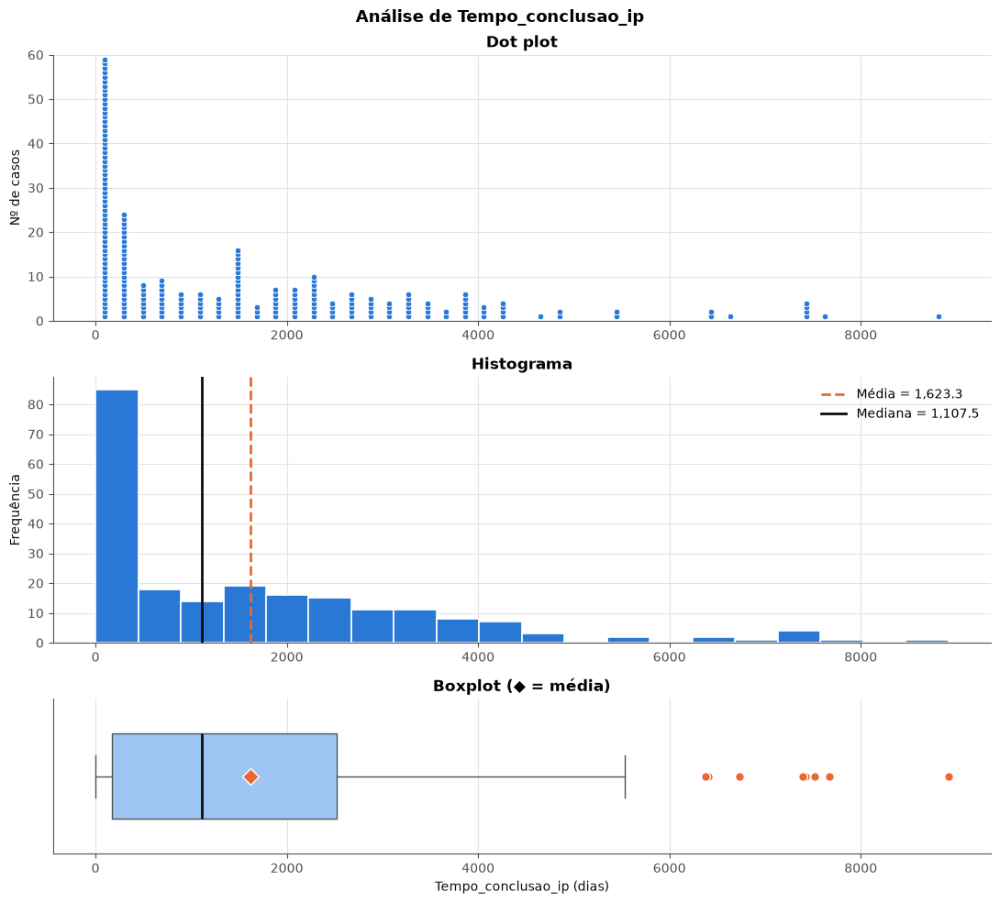

Estatísticas descritivas: Tempo_conclusao_ip [dias]


,N (obs.),Média,Mediana,Desvio padrão,CV (%),Mínimo,Q1 (25%),Q3 (75%),Máximo,IQR,Assimetria,Curtose,"Outliers (1,5×IQR)"
Tempo_conclusao_ip,218.00,"1,623.32","1,107.50","1,815.25",111.82,0.00,167.25,"2,523.75","8,914.00","2,356.50",1.50,2.30,9.00


In [74]:
resumo_tempo_ip = analise_var_quantitativa(dados, 'Tempo_conclusao_ip', unidade='dias')

**Leitura.** A distribuição é fortemente **assimétrica à direita** (assimetria = 1,50): a média (1.623 dias ≈ 4,4 anos) é bem maior que a mediana (1.107,5 dias ≈ 3 anos), puxada por uma cauda de inquéritos muito antigos, com máximo de 8.914 dias (≈ 24 anos). A dispersão é enorme (dp = 1.815 dias; CV = 112%) e a metade central dos casos vai de 167 a 2.524 dias (IQR = 2.356,5 dias). O dot plot mostra um pico junto de zero — 17 inquéritos com tempo 0, dos quais 13 são autos de prisão em flagrante recebidos no mesmo dia — e uma distribuição quase uniforme entre 1 e 12 anos. Os 9 outliers (acima de ≈ 6.060 dias) não são erros: são inquéritos instaurados entre 1998 e 2005 (ver seção 15). **A mediana é a medida de centro adequada.**

8 variáveis quantitativas: N_indiciados, N_vitimas, Tempo_fato_instauracao, Tempo_conclusao_ip, Tempo_entre_manifestacoes_mp, Tempo_conclusao_mp, Quantidade_manifestacao_mp, N_itens_diligencia


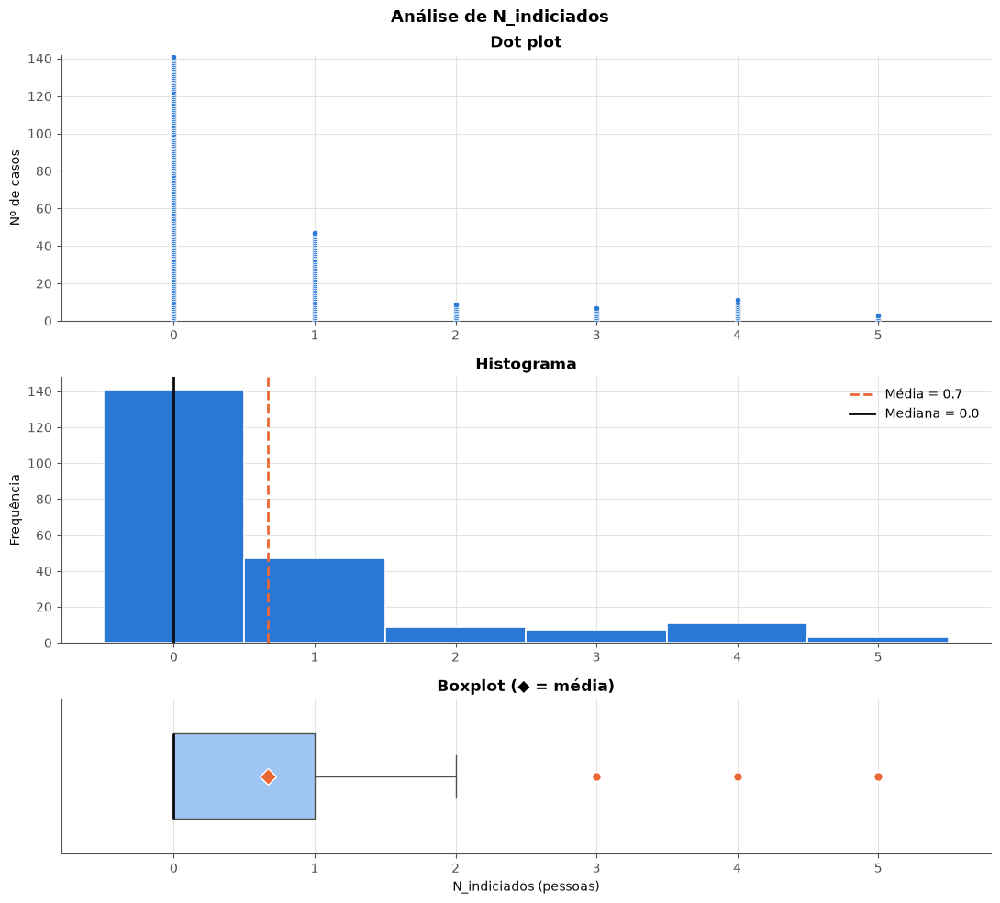

Estatísticas descritivas: N_indiciados [pessoas]


,N (obs.),Média,Mediana,Desvio padrão,CV (%),Mínimo,Q1 (25%),Q3 (75%),Máximo,IQR,Assimetria,Curtose,"Outliers (1,5×IQR)"
N_indiciados,218.00,0.67,0.00,1.18,176.94,0.00,0.00,1.00,5.00,1.00,2.06,3.59,21.00


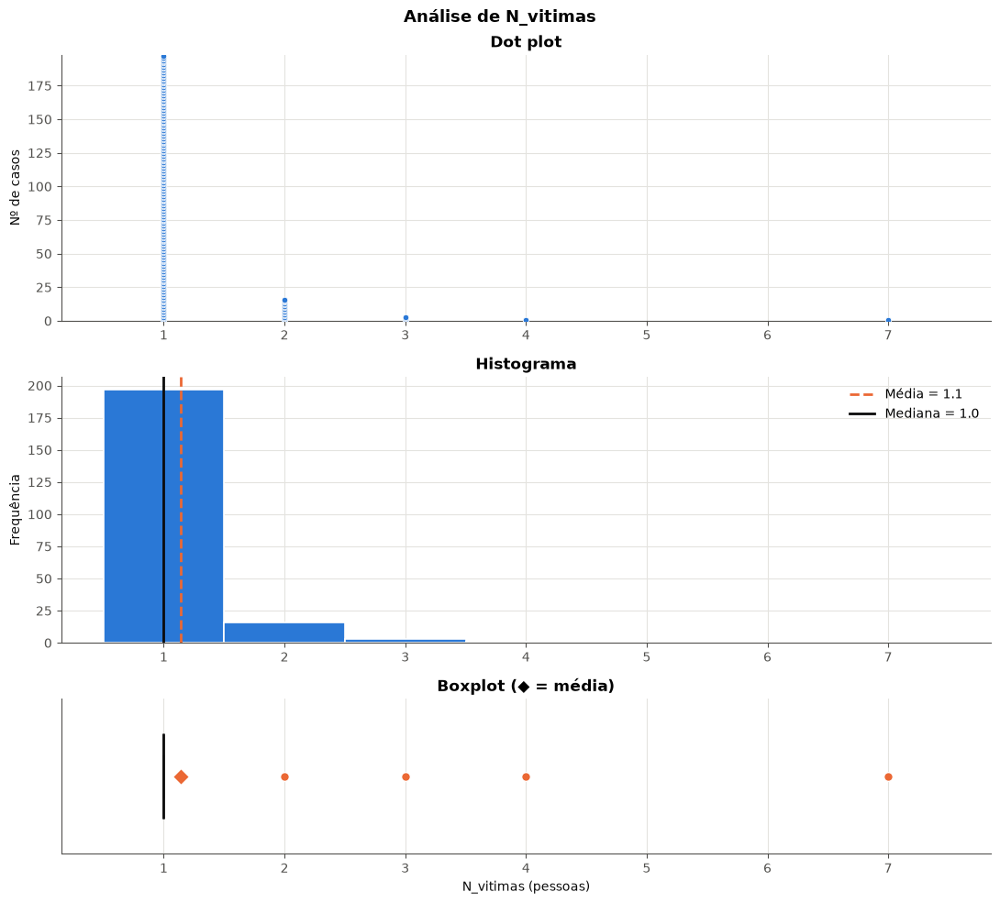

Estatísticas descritivas: N_vitimas [pessoas]


,N (obs.),Média,Mediana,Desvio padrão,CV (%),Mínimo,Q1 (25%),Q3 (75%),Máximo,IQR,Assimetria,Curtose,"Outliers (1,5×IQR)"
N_vitimas,218.00,1.14,1.00,0.56,49.22,1.00,1.00,1.00,7.00,0.00,6.62,58.06,21.00


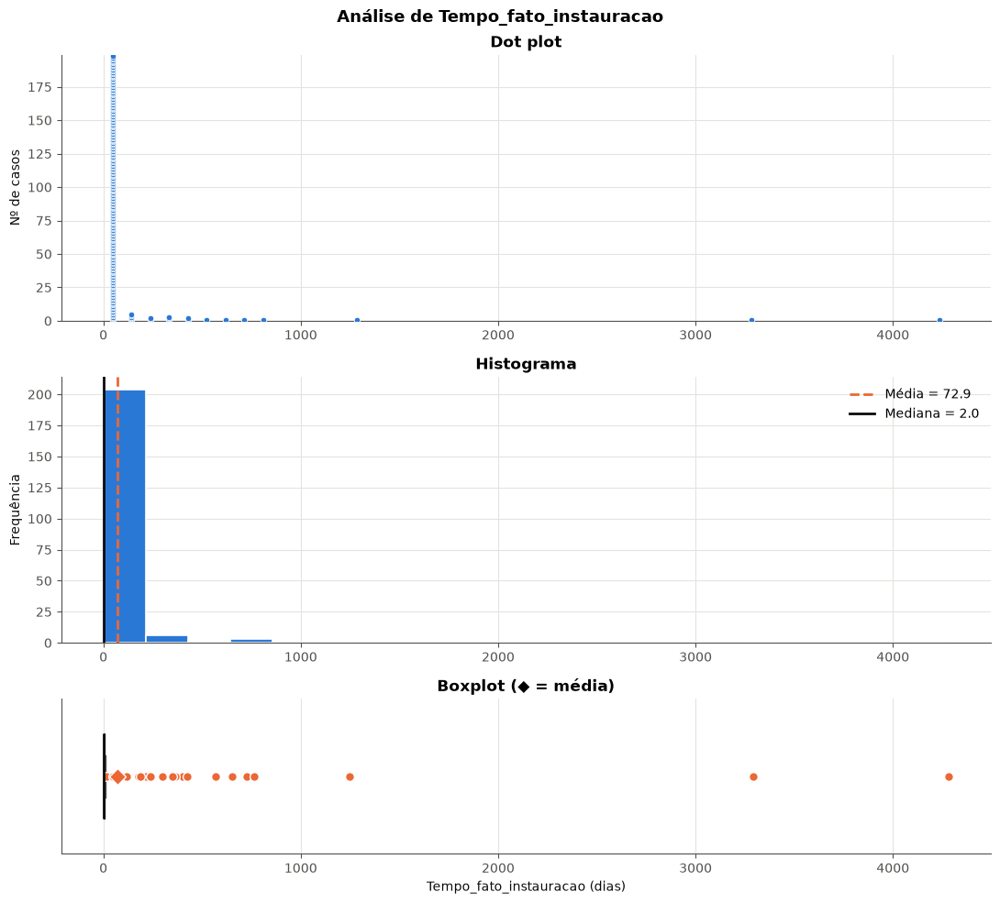

Estatísticas descritivas: Tempo_fato_instauracao [dias] — 1 ausentes


,N (obs.),Média,Mediana,Desvio padrão,CV (%),Mínimo,Q1 (25%),Q3 (75%),Máximo,IQR,Assimetria,Curtose,"Outliers (1,5×IQR)"
Tempo_fato_instauracao,217.00,72.89,2.00,387.13,531.12,0.00,1.00,6.00,"4,282.00",5.00,8.90,86.71,41.00


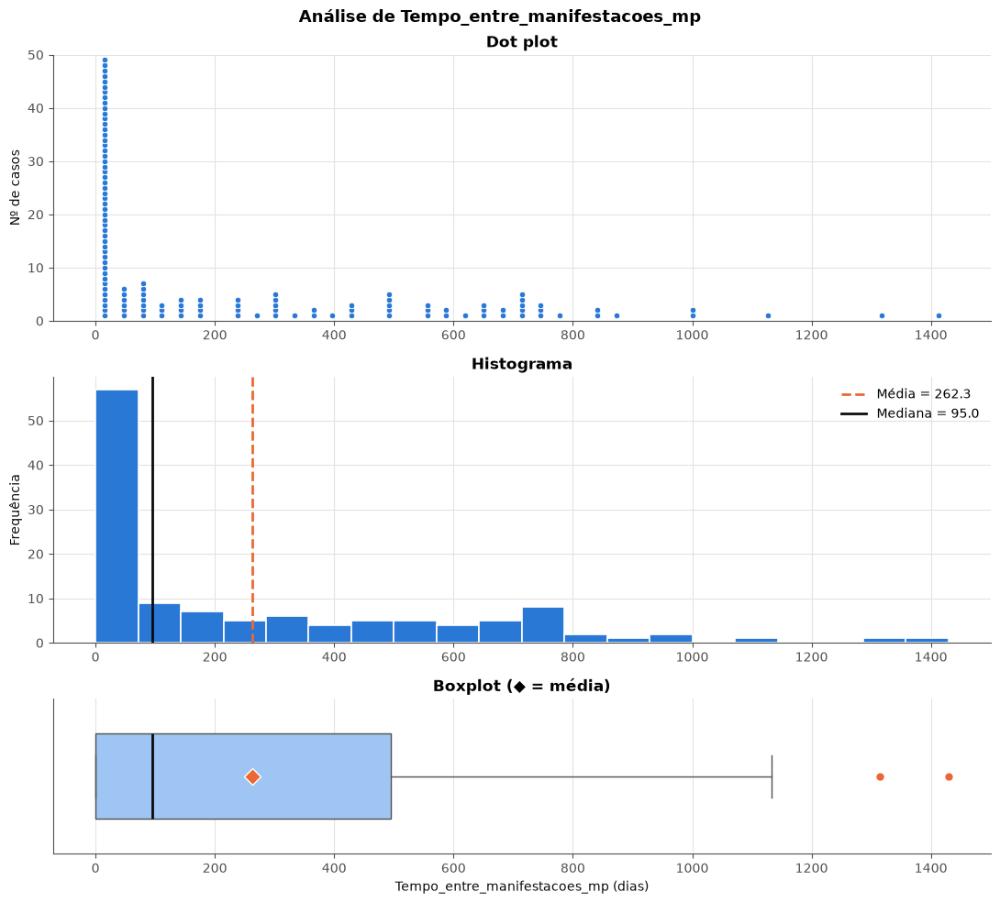

Estatísticas descritivas: Tempo_entre_manifestacoes_mp [dias] — 95 ausentes


,N (obs.),Média,Mediana,Desvio padrão,CV (%),Mínimo,Q1 (25%),Q3 (75%),Máximo,IQR,Assimetria,Curtose,"Outliers (1,5×IQR)"
Tempo_entre_manifestacoes_mp,123.00,262.33,95.00,328.86,125.36,0.00,0.00,495.50,"1,429.00",495.50,1.26,0.98,2.00


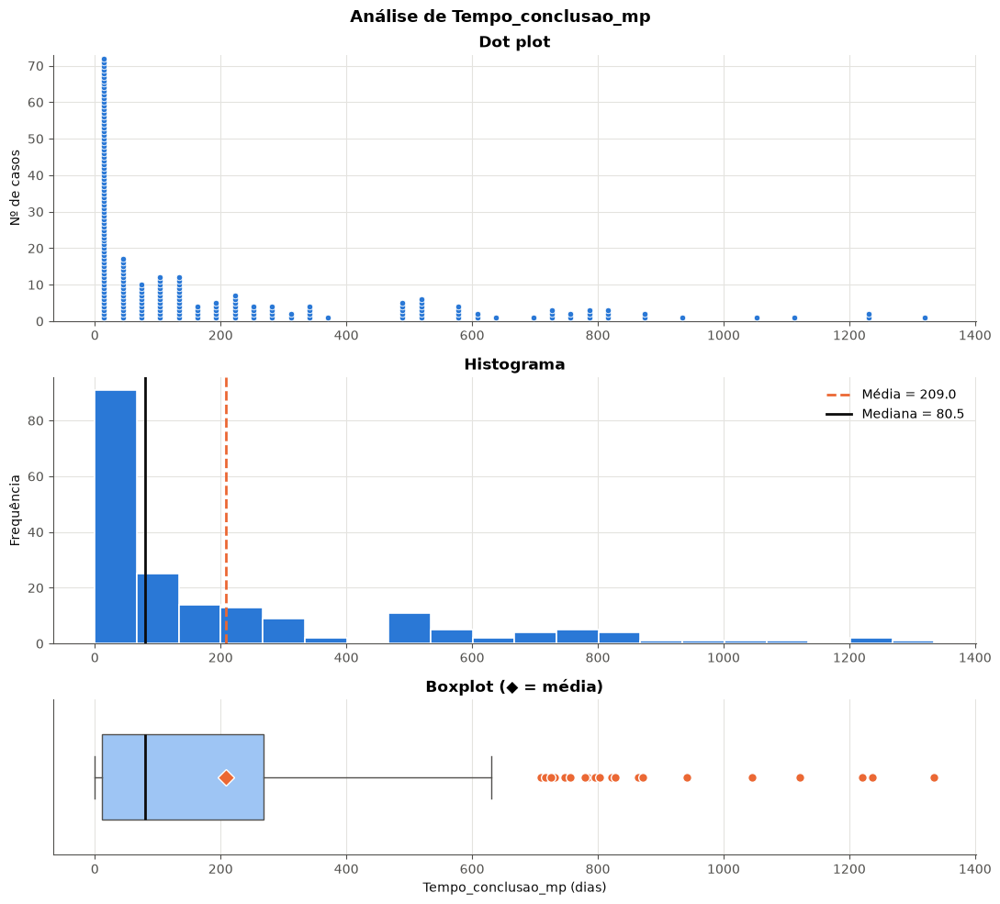

Estatísticas descritivas: Tempo_conclusao_mp [dias] — 26 ausentes


,N (obs.),Média,Mediana,Desvio padrão,CV (%),Mínimo,Q1 (25%),Q3 (75%),Máximo,IQR,Assimetria,Curtose,"Outliers (1,5×IQR)"
Tempo_conclusao_mp,192.00,209.04,80.50,288.72,138.11,0.00,10.75,269.00,"1,335.00",258.25,1.75,2.54,20.00


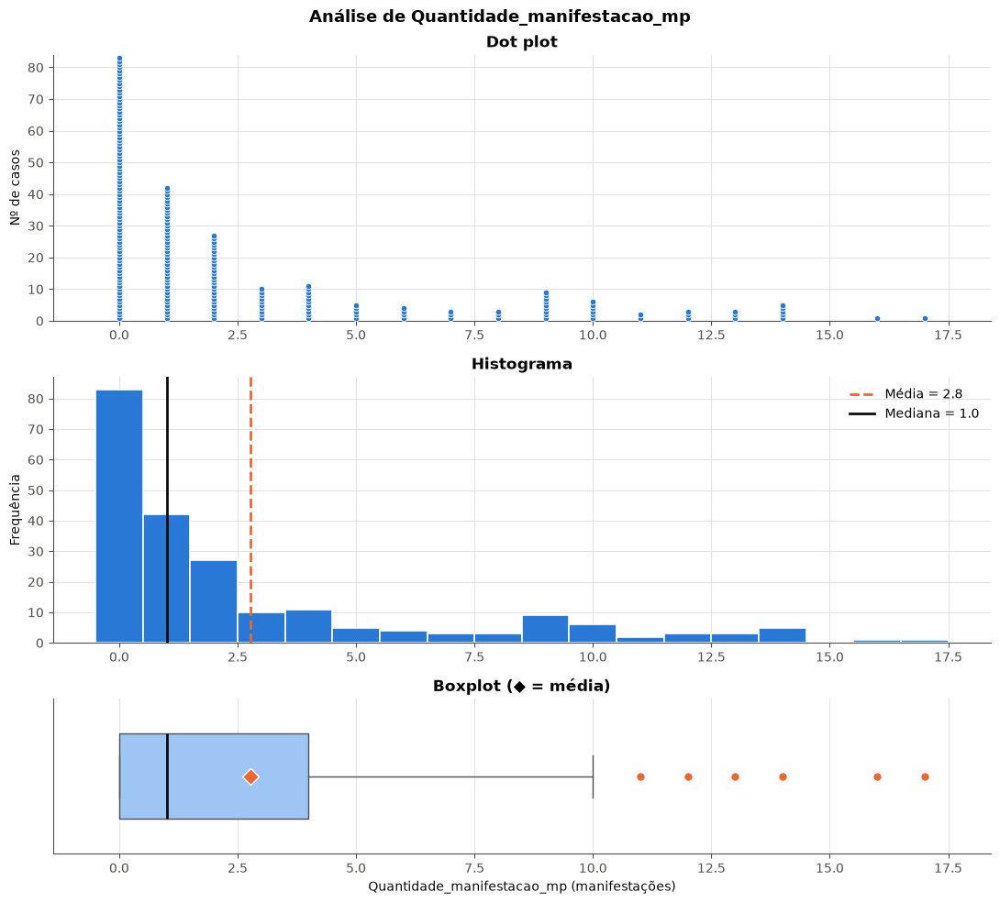

Estatísticas descritivas: Quantidade_manifestacao_mp [manifestações]


,N (obs.),Média,Mediana,Desvio padrão,CV (%),Mínimo,Q1 (25%),Q3 (75%),Máximo,IQR,Assimetria,Curtose,"Outliers (1,5×IQR)"
Quantidade_manifestacao_mp,218.00,2.78,1.00,3.95,142.21,0.00,0.00,4.00,17.00,4.00,1.68,1.91,15.00


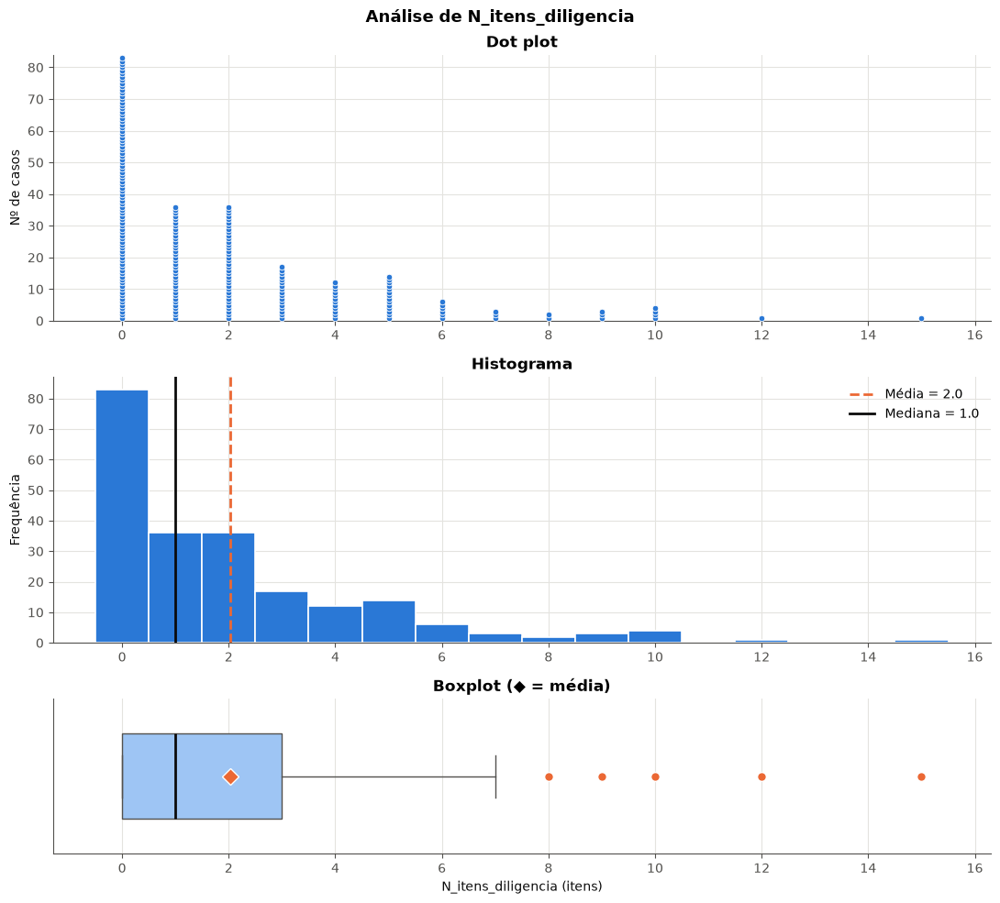

Estatísticas descritivas: N_itens_diligencia [itens]


,N (obs.),Média,Mediana,Desvio padrão,CV (%),Mínimo,Q1 (25%),Q3 (75%),Máximo,IQR,Assimetria,Curtose,"Outliers (1,5×IQR)"
N_itens_diligencia,218.00,2.04,1.00,2.61,127.95,0.00,0.00,3.00,15.00,3.00,1.86,4.13,11.00


In [75]:
VARS_QUANTITATIVAS = ESQUEMA.loc[ESQUEMA['Uso analítico'].eq('Quantitativa'), 'Variável'].tolist()
print(f'{len(VARS_QUANTITATIVAS)} variáveis quantitativas:', ', '.join(VARS_QUANTITATIVAS))

resumos_quantitativos = {'Tempo_conclusao_ip': resumo_tempo_ip}
for variavel in VARS_QUANTITATIVAS:
    if variavel != 'Tempo_conclusao_ip':
        resumos_quantitativos[variavel] = analise_var_quantitativa(dados, variavel)

In [76]:
tabela_quantitativas = pd.DataFrame(resumos_quantitativos).T
tabela_quantitativas.insert(0, 'Unidade', [UNIDADES[v] for v in tabela_quantitativas.index])
print('RESUMO DAS VARIÁVEIS QUANTITATIVAS (ordenado pelo coeficiente de variação)')
display(tabela_quantitativas.sort_values('CV (%)', ascending=False).round(2))

RESUMO DAS VARIÁVEIS QUANTITATIVAS (ordenado pelo coeficiente de variação)


,Unidade,N (obs.),Média,Mediana,Desvio padrão,CV (%),Mínimo,Q1 (25%),Q3 (75%),Máximo,IQR,Assimetria,Curtose,"Outliers (1,5×IQR)"
Tempo_fato_instauracao,dias,217.00,72.89,2.00,387.13,531.12,0.00,1.00,6.00,"4,282.00",5.00,8.90,86.71,41.00
N_indiciados,pessoas,218.00,0.67,0.00,1.18,176.94,0.00,0.00,1.00,5.00,1.00,2.06,3.59,21.00
Quantidade_manifestacao_mp,manifestações,218.00,2.78,1.00,3.95,142.21,0.00,0.00,4.00,17.00,4.00,1.68,1.91,15.00
Tempo_conclusao_mp,dias,192.00,209.04,80.50,288.72,138.11,0.00,10.75,269.00,"1,335.00",258.25,1.75,2.54,20.00
N_itens_diligencia,itens,218.00,2.04,1.00,2.61,127.95,0.00,0.00,3.00,15.00,3.00,1.86,4.13,11.00
Tempo_entre_manifestacoes_mp,dias,123.00,262.33,95.00,328.86,125.36,0.00,0.00,495.50,"1,429.00",495.50,1.26,0.98,2.00
Tempo_conclusao_ip,dias,218.00,"1,623.32","1,107.50","1,815.25",111.82,0.00,167.25,"2,523.75","8,914.00","2,356.50",1.50,2.30,9.00
N_vitimas,pessoas,218.00,1.14,1.00,0.56,49.22,1.00,1.00,1.00,7.00,0.00,6.62,58.06,21.00


**Síntese do Exercício 2.**

| Variável | Forma | Centro (mediana) | Observação |
|---|---|---|---|
| `Tempo_conclusao_ip` | assimétrica à direita | 1.107,5 dias | cauda de IPs antigos; ver seção 15 |
| `Tempo_conclusao_mp` | assimétrica à direita | 80,5 dias | 192 concluídos; 26 censurados. Com a censura, a mediana de Kaplan-Meier é de 110 dias (seção 15.3) |
| `Tempo_entre_manifestacoes_mp` | bimodal: pico em 0 e cauda longa | 95 dias | 38 zeros correspondem a uma única manifestação |
| `Tempo_fato_instauracao` | extremamente concentrada | 2 dias | Q3 = 6 dias, mas máximo de 4.282 dias |
| `Quantidade_manifestacao_mp` | assimétrica, 38% de zeros | 1 | máximo 17 |
| `N_itens_diligencia` | assimétrica, 38% de zeros | 1 | máximo 15 |
| `N_indiciados` | 64,7% de zeros | 0 | máximo 5 |
| `N_vitimas` | 90,4% com 1 vítima | 1 | máximo 7 (Luziânia) |

- **Maior variabilidade relativa (CV):** `Tempo_fato_instauracao` (531%), `N_indiciados` (177%) e `Quantidade_manifestacao_mp` (142%). Em termos absolutos, `Tempo_conclusao_ip` domina (dp = 1.815 dias).
- **Outliers e sua explicação.** Em `Tempo_fato_instauracao`, 10 inquéritos foram instaurados mais de um ano após o fato (até 11,7 anos): 6 deles em delegacias distritais, o que é compatível com descoberta tardia do crime ou reabertura da apuração (hipótese a conferir nos autos). Em `N_vitimas`, o IQR é 0 (Q1 = Q3 = 1), de modo que a regra de 1,5×IQR marca como "outlier" **todo** caso com mais de uma vítima (21): são múltiplos homicídios legítimos, incluindo um com 7 vítimas. Isso mostra que a regra do boxplot é um alerta, não um critério de exclusão.
- **Média × mediana.** Em todas as variáveis de tempo a média supera a mediana — de 47% (tempo do IP) a mais de 3.500% (tempo entre fato e instauração) —, confirmando a assimetria. Nenhuma delas é aproximadamente normal, o que justifica os testes não paramétricos do Exercício 3.

---

## 12. Comparação de Variáveis Quantitativas por Grupos (Exercício 3)

### Funções auxiliares — com os dois desafios resolvidos

1. **`comparacao_grupos_boxplot(..., decresc='não')`** — ordena os boxplots pela mediana: `'não'` = ordem crescente (da menor para a maior mediana), `'sim'` = decrescente, `None` = ordem das categorias. Os pontos individuais são sobrepostos com leve deslocamento (*jitter*), o *n* de cada grupo aparece no rótulo, e é feito um teste não paramétrico (Mann-Whitney para 2 grupos, Kruskal-Wallis para 3 ou mais) com tamanho de efeito;
2. **`comparacao_grupos_histograma(..., sobrepostos='não')`** — `'não'` empilha os histogramas verticalmente (k × 1), com o mesmo eixo x e os **mesmos intervalos** para todos os grupos; `'sim'` sobrepõe. A versão original calculava os intervalos separadamente para cada grupo, o que tornava as barras incomparáveis.

A escolha de testes não paramétricos se justifica pela forte assimetria dos tempos (Exercício 2): comparar medianas/postos é mais robusto que comparar médias.

In [77]:
def cores_para(categorias):
    """Cor fixa por categoria, na ordem da paleta (nunca reciclada: > 8 grupos usam a cor principal)."""
    categorias = list(categorias)
    if len(categorias) > len(CORES):
        return {c: COR_PRINCIPAL for c in categorias}
    return dict(zip(categorias, CORES))


def teste_grupos(df, var_q, var_c):
    grupos = [g[var_q].astype(float).values for _, g in df.groupby(var_c, observed=True)]
    n = sum(len(g) for g in grupos)
    if len(grupos) == 2:
        u, p = stats.mannwhitneyu(*grupos, alternative='two-sided')
        efeito = 1 - 2 * u / (len(grupos[0]) * len(grupos[1]))  # correlação rank-bisserial
        return {'Teste': 'Mann-Whitney', 'Estatística': u, 'p-valor': p, 'Efeito': efeito, 'Medida de efeito': 'r bisserial'}
    h, p = stats.kruskal(*grupos)
    epsilon2 = (h - len(grupos) + 1) / (n - len(grupos))
    return {'Teste': 'Kruskal-Wallis', 'Estatística': h, 'p-valor': p, 'Efeito': epsilon2, 'Medida de efeito': 'ε²'}


resultados_grupos = []


def comparacao_grupos_boxplot(dados, var_quantitativa, var_categorica, unidade='', decresc='não', log=False):
    """Boxplots lado a lado ordenados pela mediana (decresc='não' crescente, 'sim' decrescente, None = original)."""
    df = pd.DataFrame({var_quantitativa: dados[var_quantitativa].astype(float),
                       var_categorica: serie_exibicao(dados, var_categorica)}).dropna()
    df[var_categorica] = df[var_categorica].cat.remove_unused_categories()
    medianas = df.groupby(var_categorica, observed=True)[var_quantitativa].median()
    if decresc is None:
        ordem = list(df[var_categorica].cat.categories)
    else:
        ordem = list(medianas.sort_values(ascending=(decresc.lower() == 'não'), kind='stable').index)
    unidade = unidade or UNIDADES.get(var_quantitativa, '')
    cores = cores_para(df[var_categorica].cat.categories)

    fig, ax = plt.subplots(figsize=(max(8, 1.6 * len(ordem) + 3), 6))
    grupos = [df.loc[df[var_categorica] == g, var_quantitativa].values for g in ordem]
    caixas = ax.boxplot(grupos, widths=0.55, patch_artist=True, showfliers=False,
                        medianprops=dict(color=TINTA, linewidth=2), whiskerprops=dict(color=TINTA_2),
                        capprops=dict(color=TINTA_2), boxprops=dict(edgecolor=TINTA_2))
    for caixa, g in zip(caixas['boxes'], ordem):
        caixa.set_facecolor(cores[g])
        caixa.set_alpha(0.35)
    for i, (g, valores) in enumerate(zip(ordem, grupos), start=1):
        ax.scatter(i + RNG.uniform(-0.17, 0.17, len(valores)), valores, s=16, color=cores[g], edgecolor='white',
                   linewidth=0.5, zorder=3)
        ax.plot(i, valores.mean(), marker='D', color=TINTA, markeredgecolor='white', markersize=8, zorder=4)
    ax.set_xticks(range(1, len(ordem) + 1))
    ax.set_xticklabels([f'{quebrar(g, 16)}\n(n={len(v)})' for g, v in zip(ordem, grupos)])
    if log:
        ax.set_yscale('symlog', linthresh=10)
    ax.set_xlabel(var_categorica)
    ax.set_ylabel(f'{var_quantitativa} ({unidade})' if unidade else var_quantitativa)
    sentido = {None: '', 'não': ' — ordem crescente da mediana', 'sim': ' — ordem decrescente da mediana'}
    ax.set_title(f'{var_quantitativa} por {var_categorica}{sentido[decresc]}  (◆ = média)')
    ax.grid(axis='x', visible=False)
    plt.tight_layout()
    plt.show()

    estat = df.groupby(var_categorica, observed=True)[var_quantitativa].apply(resumo_quantitativo).unstack()
    estat = estat.loc[ordem, ['N (obs.)', 'Média', 'Mediana', 'Desvio padrão', 'CV (%)', 'Q1 (25%)', 'Q3 (75%)',
                              'IQR', 'Mínimo', 'Máximo', 'Outliers (1,5×IQR)']]
    teste = teste_grupos(df, var_quantitativa, var_categorica)
    resultados_grupos.append({'Quantitativa': var_quantitativa, 'Grupos': var_categorica, 'k': len(ordem), **teste})
    print(f'Estatísticas de {var_quantitativa} por {var_categorica}')
    display(estat.round(1))
    print(f"{teste['Teste']}: estatística = {teste['Estatística']:.2f}; p-valor = {teste['p-valor']:.4f}; "
          f"{teste['Medida de efeito']} = {teste['Efeito']:.3f}")
    return estat


def comparacao_grupos_histograma(dados, var_quantitativa, var_categorica, unidade='', bins=15, sobrepostos='não'):
    """Histogramas por grupo com intervalos comuns: sobrepostos='não' → k × 1; 'sim' → sobrepostos."""
    df = pd.DataFrame({var_quantitativa: dados[var_quantitativa].astype(float),
                       var_categorica: serie_exibicao(dados, var_categorica)}).dropna()
    df[var_categorica] = df[var_categorica].cat.remove_unused_categories()
    grupos = list(df[var_categorica].cat.categories)
    cores = cores_para(grupos)
    bordas = np.histogram_bin_edges(df[var_quantitativa], bins=bins)
    unidade = unidade or UNIDADES.get(var_quantitativa, '')
    rotulo_x = f'{var_quantitativa} ({unidade})' if unidade else var_quantitativa

    if sobrepostos.lower() == 'sim':
        fig, ax = plt.subplots(figsize=(11, 5.5))
        for g in grupos:
            ax.hist(df.loc[df[var_categorica] == g, var_quantitativa], bins=bordas, alpha=0.45, color=cores[g],
                    edgecolor='white', label=f'{g} (n={int((df[var_categorica] == g).sum())})')
        ax.set_xlabel(rotulo_x)
        ax.set_ylabel('Frequência')
        ax.legend(title=var_categorica)
        ax.set_title(f'Distribuição de {var_quantitativa} por {var_categorica} (sobrepostos)')
    else:
        fig, axes = plt.subplots(len(grupos), 1, figsize=(11, 1.9 * len(grupos) + 1), sharex=True, sharey=True)
        axes = np.atleast_1d(axes)
        for ax, g in zip(axes, grupos):
            valores = df.loc[df[var_categorica] == g, var_quantitativa]
            ax.hist(valores, bins=bordas, color=cores[g], edgecolor='white')
            ax.axvline(valores.median(), color=TINTA, linewidth=2)
            ax.set_title(f'{g}  (n={len(valores)}; mediana = {valores.median():,.0f})', loc='left', fontsize=10)
            ax.set_ylabel('Freq.')
        axes[-1].set_xlabel(rotulo_x)
        fig.suptitle(f'Distribuição de {var_quantitativa} por {var_categorica} ({len(grupos)} × 1, intervalos comuns)',
                     fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Exercício 3: compare variáveis quantitativas entre grupos

**Tempo de conclusão do IP por comarca.** Desafio 1: boxplots em ordem crescente de mediana (`decresc='não'`). O professor antecipa que a ordem vai de Senador Canedo (mediana 394,5 dias) a Anápolis (3.361,5 dias) — a tabela confirma.

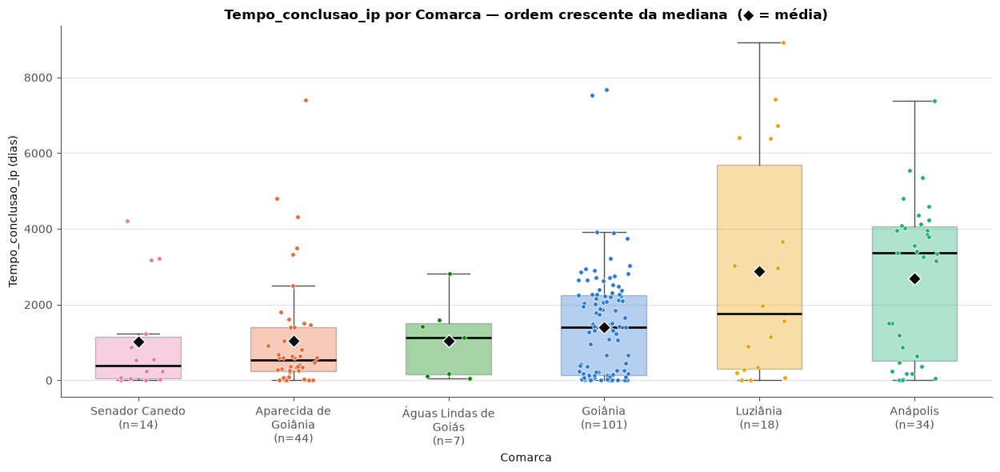

Estatísticas de Tempo_conclusao_ip por Comarca


,N (obs.),Média,Mediana,Desvio padrão,CV (%),Q1 (25%),Q3 (75%),IQR,Mínimo,Máximo,"Outliers (1,5×IQR)"
Comarca,,,,,,,,,,,
Senador Canedo,14.00,"1,032.40",394.50,"1,421.80",137.70,51.20,"1,140.80","1,089.50",0.00,"4,210.00",3.00
Aparecida de Goiânia,44.00,"1,052.80",533.50,"1,511.00",143.50,247.00,"1,397.80","1,150.80",0.00,"7,396.00",5.00
Águas Lindas de Goiás,7.00,"1,042.60","1,122.00","1,016.70",97.50,149.50,"1,505.50","1,356.00",45.00,"2,821.00",0.00
Goiânia,101.00,"1,410.10","1,392.00","1,430.70",101.50,135.00,"2,244.00","2,109.00",0.00,"7,672.00",2.00
Luziânia,18.00,"2,889.40","1,768.50","2,985.10",103.30,295.00,"5,699.00","5,404.00",0.00,"8,914.00",0.00
Anápolis,34.00,"2,687.60","3,361.50","2,020.30",75.20,520.20,"4,060.20","3,540.00",0.00,"7,388.00",0.00


Kruskal-Wallis: estatística = 19.32; p-valor = 0.0017; ε² = 0.068


In [78]:
estat_comarca = comparacao_grupos_boxplot(dados, 'Tempo_conclusao_ip', 'Comarca', unidade='dias', decresc='não')
assert estat_comarca['Mediana'].iloc[0] == 394.5 and estat_comarca['Mediana'].iloc[-1] == 3361.5

Desafio 2: histogramas não sobrepostos (6 × 1), com os mesmos intervalos para as seis comarcas. Em seguida, a versão sobreposta, para comparação: com seis grupos ela fica ilegível, o que justifica a opção `sobrepostos='não'`.

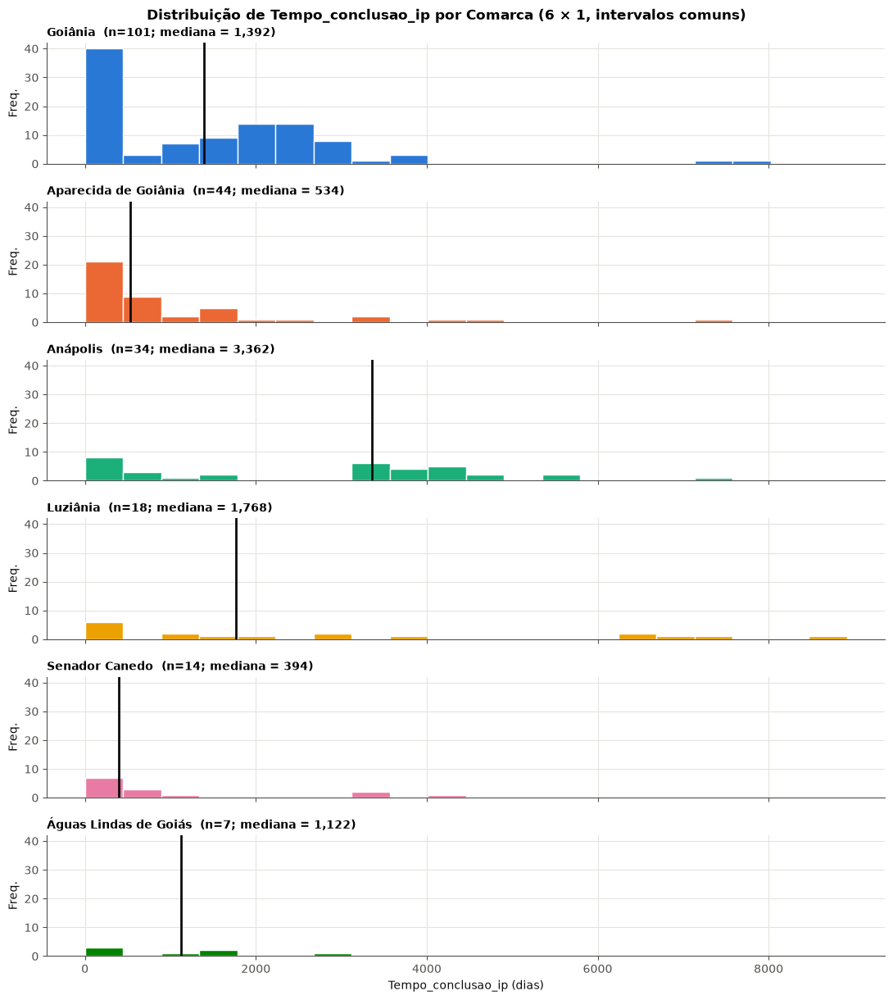

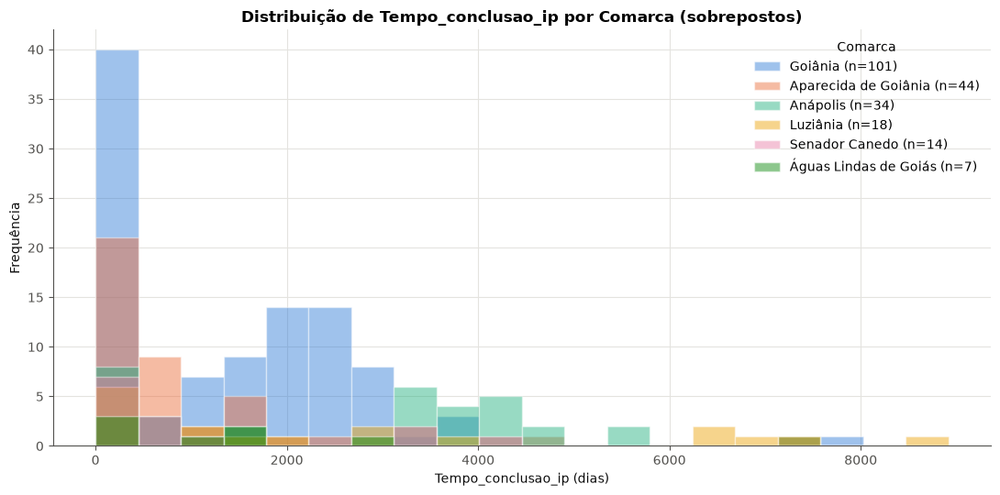

In [79]:
comparacao_grupos_histograma(dados, 'Tempo_conclusao_ip', 'Comarca', unidade='dias', bins=20, sobrepostos='não')
comparacao_grupos_histograma(dados, 'Tempo_conclusao_ip', 'Comarca', unidade='dias', bins=20, sobrepostos='sim')

**Leitura.** As medianas vão de 394,5 dias (Senador Canedo) a 3.361,5 dias (Anápolis), exatamente como antecipado no enunciado — uma diferença de 8,5 vezes. O teste de Kruskal-Wallis rejeita a igualdade das distribuições (H = 19,32; p = 0,0017), mas o tamanho de efeito é pequeno (ε² = 0,068: a comarca "explica" cerca de 7% da variação dos postos). Luziânia é a comarca mais variável (IQR = 5.404 dias), com casos de 0 a 8.914 dias. Os histogramas 6 × 1, com os mesmos intervalos, deixam visível o que a sobreposição esconde: Senador Canedo e Aparecida concentram-se no primeiro ano, enquanto Anápolis tem a massa entre 3.000 e 4.500 dias.

⚠️ **Cuidado com a interpretação causal.** A Parte II mostra que `Tempo_conclusao_ip` é, essencialmente, a **idade do inquérito na chegada ao Projudi**. Anápolis parece "lenta" porque o seu estoque migrado era mais antigo (seção 15), e não porque investigue mais devagar. Na coorte instaurada a partir de 2022, o tempo total não difere entre as comarcas (seção 18.2).

**Tempo de conclusão do IP segundo `Reu_preso`** (comparação proposta pelo professor).

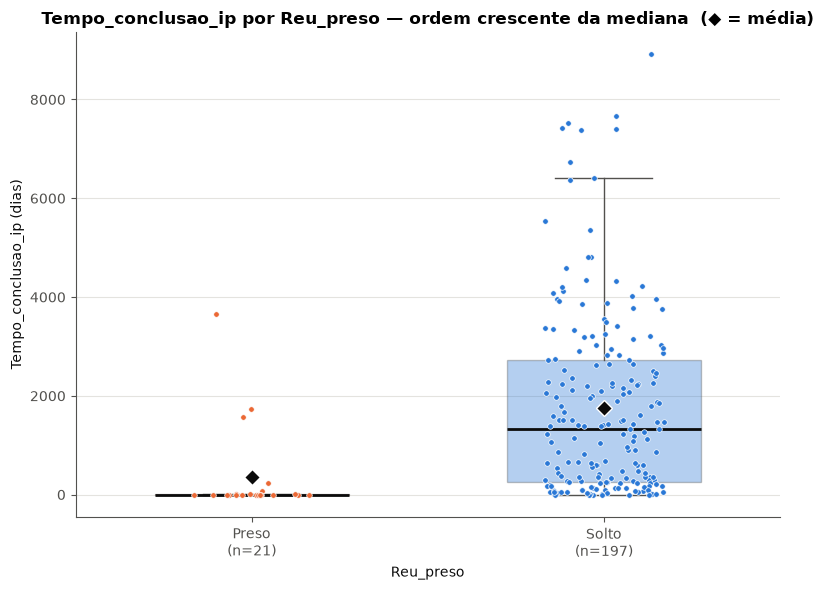

Estatísticas de Tempo_conclusao_ip por Reu_preso


,N (obs.),Média,Mediana,Desvio padrão,CV (%),Q1 (25%),Q3 (75%),IQR,Mínimo,Máximo,"Outliers (1,5×IQR)"
Reu_preso,,,,,,,,,,,
Preso,21.00,348.40,0.00,905.60,259.90,0.00,22.00,22.00,0.00,"3,662.00",5.00
Solto,197.00,"1,759.20","1,320.00","1,836.20",104.40,253.00,"2,720.00","2,467.00",0.00,"8,914.00",7.00


Mann-Whitney: estatística = 3609.00; p-valor = 0.0000; r bisserial = -0.745


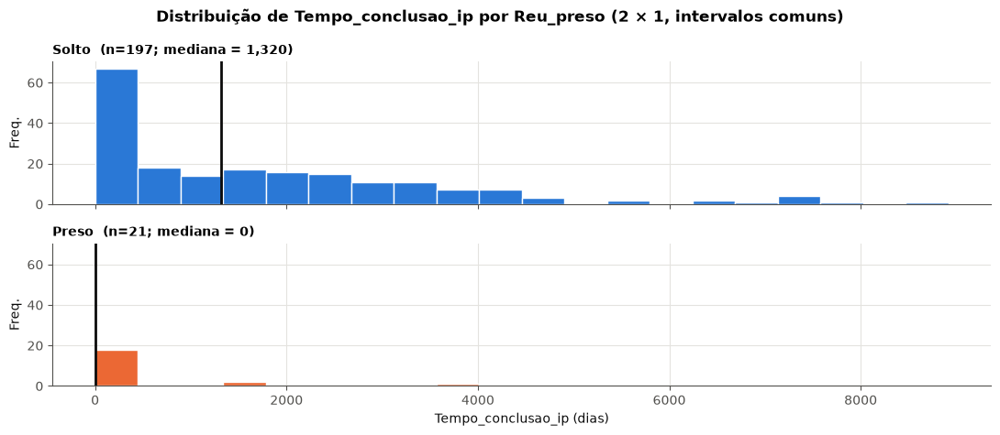

In [80]:
comparacao_grupos_boxplot(dados, 'Tempo_conclusao_ip', 'Reu_preso', unidade='dias', decresc='não')
comparacao_grupos_histograma(dados, 'Tempo_conclusao_ip', 'Reu_preso', unidade='dias', bins=20, sobrepostos='não');

**Leitura.** É a comparação mais nítida do estudo. Com réu preso, a mediana é **0 dias** (o auto de prisão em flagrante chega ao Projudi no mesmo dia) e o Q3 é 22 dias; com réu solto, a mediana é **1.320 dias** (3,6 anos). O teste de Mann-Whitney é altamente significativo (p < 0,0001) e o efeito é grande (correlação rank-bisserial = −0,75). O grupo "preso" tem 5 outliers — presos cujo IP se arrastou por até 3.662 dias —, que merecem verificação individual. A diferença era esperada: a prisão impõe o prazo de 10 dias e o controle judicial imediato; o investigado solto não gera essa pressão.

**Outras comparações.** Forma de instauração, tipo de delegacia e situação processual para o tempo policial; comarca para o tempo do MP e para a quantidade de manifestações.

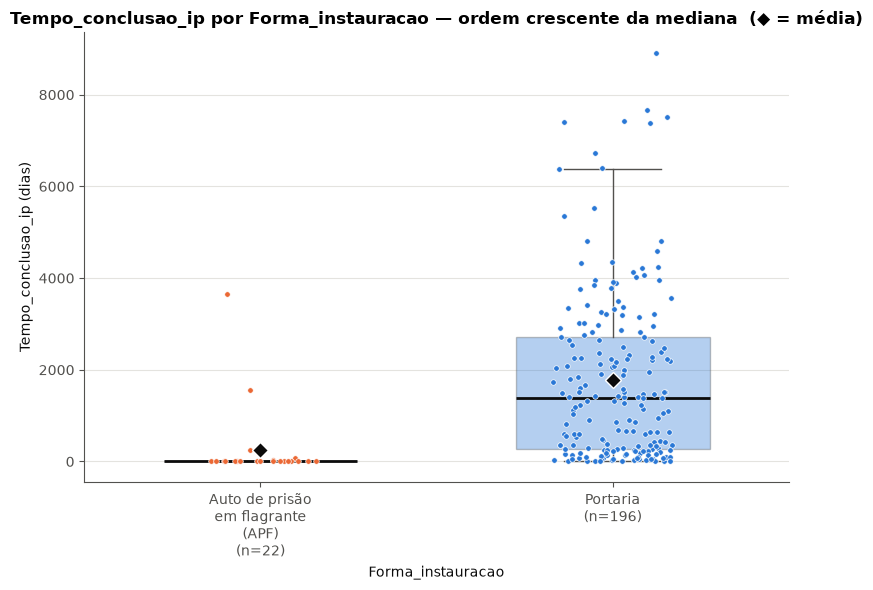

Estatísticas de Tempo_conclusao_ip por Forma_instauracao


,N (obs.),Média,Mediana,Desvio padrão,CV (%),Q1 (25%),Q3 (75%),IQR,Mínimo,Máximo,"Outliers (1,5×IQR)"
Forma_instauracao,,,,,,,,,,,
Auto de prisão em flagrante (APF),22.00,253.40,0.00,831.00,327.90,0.00,5.80,5.80,0.00,"3,662.00",5.00
Portaria,196.00,"1,777.10","1,393.50","1,832.20",103.10,265.80,"2,720.00","2,454.20",0.00,"8,914.00",8.00


Mann-Whitney: estatística = 3914.50; p-valor = 0.0000; r bisserial = -0.816


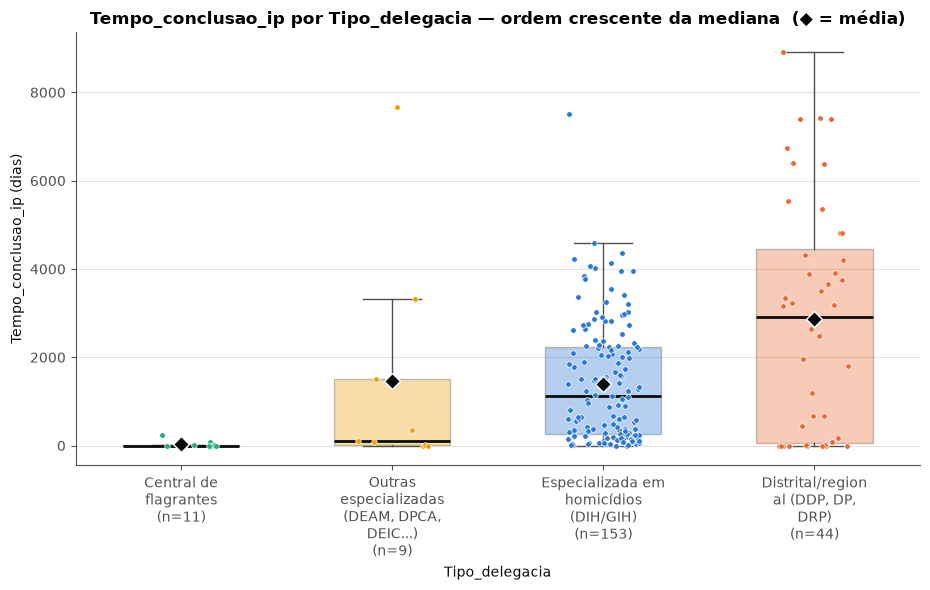

Estatísticas de Tempo_conclusao_ip por Tipo_delegacia


,N (obs.),Média,Mediana,Desvio padrão,CV (%),Q1 (25%),Q3 (75%),IQR,Mínimo,Máximo,"Outliers (1,5×IQR)"
Tipo_delegacia,,,,,,,,,,,
Central de flagrantes,11.00,31.40,1.00,73.50,234.40,0.00,13.50,13.50,0.00,243.00,2.00
"Outras especializadas (DEAM, DPCA, DEIC...)",9.00,"1,452.80",93.00,"2,583.00",177.80,21.00,"1,517.00","1,496.00",0.00,"7,672.00",1.00
Especializada em homicídios (DIH/GIH),153.00,"1,392.80","1,122.00","1,318.90",94.70,253.00,"2,229.00","1,976.00",0.00,"7,521.00",1.00
"Distrital/regional (DDP, DP, DRP)",44.00,"2,863.10","2,903.00","2,611.60",91.20,63.50,"4,446.80","4,383.20",0.00,"8,914.00",0.00


Kruskal-Wallis: estatística = 28.91; p-valor = 0.0000; ε² = 0.122


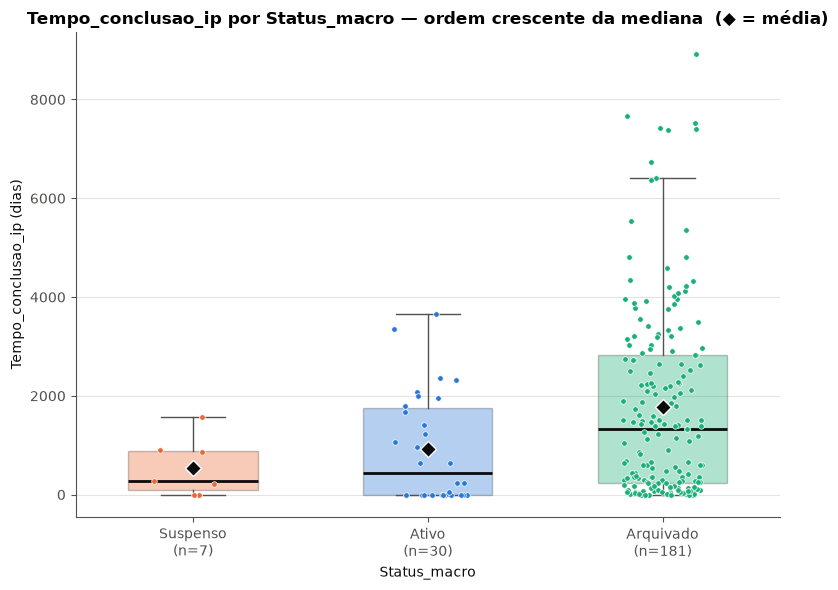

Estatísticas de Tempo_conclusao_ip por Status_macro


,N (obs.),Média,Mediana,Desvio padrão,CV (%),Q1 (25%),Q3 (75%),IQR,Mínimo,Máximo,"Outliers (1,5×IQR)"
Status_macro,,,,,,,,,,,
Suspenso,7.00,545.10,275.00,584.80,107.30,102.50,887.00,784.50,0.00,"1,562.00",0.00
Ativo,30.00,922.60,440.50,"1,094.20",118.60,0.00,"1,758.20","1,758.20",0.00,"3,662.00",0.00
Arquivado,181.00,"1,781.20","1,320.00","1,901.60",106.80,229.00,"2,821.00","2,592.00",0.00,"8,914.00",7.00


Kruskal-Wallis: estatística = 12.42; p-valor = 0.0020; ε² = 0.048


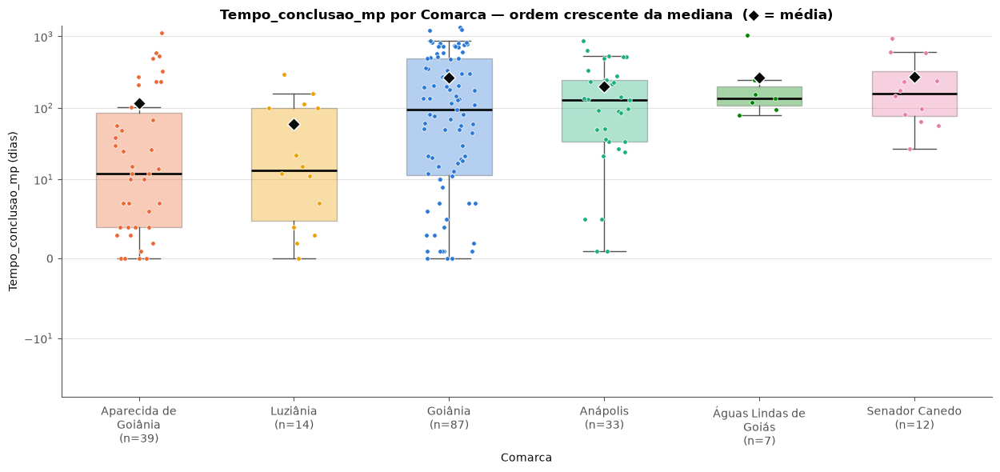

Estatísticas de Tempo_conclusao_mp por Comarca


,N (obs.),Média,Mediana,Desvio padrão,CV (%),Q1 (25%),Q3 (75%),IQR,Mínimo,Máximo,"Outliers (1,5×IQR)"
Comarca,,,,,,,,,,,
Aparecida de Goiânia,39.00,116.00,12.00,227.20,195.80,4.00,84.50,80.50,0.00,"1,121.00",9.00
Luziânia,14.00,60.10,13.50,85.30,141.90,4.80,100.00,95.20,0.00,293.00,1.00
Goiânia,87.00,266.00,95.00,336.80,126.60,11.50,489.50,478.00,0.00,"1,335.00",3.00
Anápolis,33.00,197.30,129.00,215.40,109.10,34.00,247.00,213.00,1.00,864.00,2.00
Águas Lindas de Goiás,7.00,267.10,135.00,347.20,130.00,107.00,199.00,92.00,78.00,"1,045.00",1.00
Senador Canedo,12.00,270.70,160.00,285.90,105.60,77.00,327.00,250.00,27.00,941.00,1.00


Kruskal-Wallis: estatística = 20.85; p-valor = 0.0009; ε² = 0.085


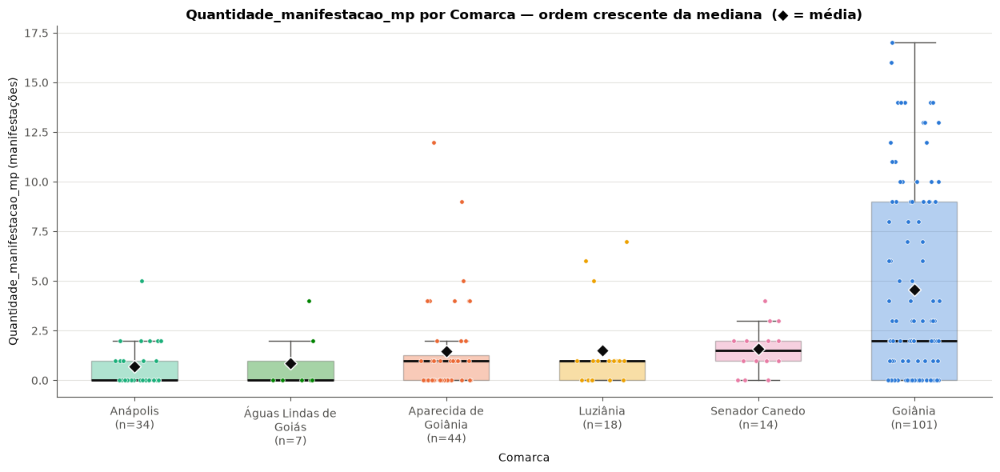

Estatísticas de Quantidade_manifestacao_mp por Comarca


,N (obs.),Média,Mediana,Desvio padrão,CV (%),Q1 (25%),Q3 (75%),IQR,Mínimo,Máximo,"Outliers (1,5×IQR)"
Comarca,,,,,,,,,,,
Anápolis,34.00,0.70,0.00,1.10,154.10,0.00,1.00,1.00,0.00,5.00,1.00
Águas Lindas de Goiás,7.00,0.90,0.00,1.60,183.60,0.00,1.00,1.00,0.00,4.00,1.00
Aparecida de Goiânia,44.00,1.50,1.00,2.50,169.30,0.00,1.20,1.20,0.00,12.00,8.00
Luziânia,18.00,1.50,1.00,2.10,143.30,0.00,1.00,1.00,0.00,7.00,3.00
Senador Canedo,14.00,1.60,1.50,1.20,77.80,1.00,2.00,1.00,0.00,4.00,1.00
Goiânia,101.00,4.60,2.00,4.80,105.80,0.00,9.00,9.00,0.00,17.00,0.00


Kruskal-Wallis: estatística = 33.67; p-valor = 0.0000; ε² = 0.135


In [81]:
comparacao_grupos_boxplot(dados, 'Tempo_conclusao_ip', 'Forma_instauracao', unidade='dias')
comparacao_grupos_boxplot(dados, 'Tempo_conclusao_ip', 'Tipo_delegacia', unidade='dias')
comparacao_grupos_boxplot(dados, 'Tempo_conclusao_ip', 'Status_macro', unidade='dias')
comparacao_grupos_boxplot(dados, 'Tempo_conclusao_mp', 'Comarca', unidade='dias', log=True)
comparacao_grupos_boxplot(dados, 'Quantidade_manifestacao_mp', 'Comarca', unidade='manifestações');

In [82]:
tabela_testes_grupos = pd.DataFrame(resultados_grupos).drop_duplicates(['Quantitativa', 'Grupos'])
tabela_testes_grupos['Significativo (5%)'] = tabela_testes_grupos['p-valor'] < 0.05
print('RESUMO DOS TESTES DE COMPARAÇÃO DE GRUPOS')
display(tabela_testes_grupos.round(4))

RESUMO DOS TESTES DE COMPARAÇÃO DE GRUPOS


,Quantitativa,Grupos,k,Teste,Estatística,p-valor,Efeito,Medida de efeito,Significativo (5%)
0,Tempo_conclusao_ip,Comarca,6,Kruskal-Wallis,19.32,0.00,0.07,ε²,True
1,Tempo_conclusao_ip,Reu_preso,2,Mann-Whitney,"3,609.00",0.00,-0.74,r bisserial,True
2,Tempo_conclusao_ip,Forma_instauracao,2,Mann-Whitney,"3,914.50",0.00,-0.82,r bisserial,True
3,Tempo_conclusao_ip,Tipo_delegacia,4,Kruskal-Wallis,28.91,0.00,0.12,ε²,True
4,Tempo_conclusao_ip,Status_macro,3,Kruskal-Wallis,12.42,0.00,0.05,ε²,True
5,Tempo_conclusao_mp,Comarca,6,Kruskal-Wallis,20.85,0.00,0.09,ε²,True
6,Quantidade_manifestacao_mp,Comarca,6,Kruskal-Wallis,33.67,0.00,0.14,ε²,True


**Síntese do Exercício 3.** As sete comparações rejeitaram a igualdade de distribuições a 5%, mas com tamanhos de efeito muito diferentes:

- **Efeitos grandes:** forma de instauração (APF com mediana 0 × portaria com 1.393,5 dias; r = −0,82) e réu preso (r = −0,75). As duas variáveis são quase a mesma coisa (86% dos APF têm réu preso — Exercício 4).
- **Efeitos moderados:** o tipo de delegacia (ε² = 0,12) — centrais de flagrante com mediana de 1 dia, especializadas DIH/GIH com 1.122 dias e distritais com 2.903 dias — e a **quantidade de manifestações do MP por comarca** (ε² = 0,135, o maior efeito entre as comparações com mais de dois grupos): Goiânia tem média de 4,6 manifestações por IP, contra 0,7 a 1,6 nas demais.
- **Tempo do MP por comarca** (ε² = 0,085): Aparecida (mediana de 12 dias) e Luziânia (13,5 dias) concluem muito mais depressa que Goiânia (95), Anápolis (129) e Senador Canedo (160).
- **Situação processual** (ε² = 0,05): os arquivados são os mais antigos (mediana de 1.320 dias), o que também é efeito da idade: o estoque antigo é justamente o que foi arquivado.

A comparação mais reveladora é réu preso × solto: ela mostra que, quando há pressão institucional (prisão, flagrante, prazo de 10 dias), o inquérito anda; quando não há, a mediana passa de três anos.

---

## 13. Análise de Associações entre Variáveis Categóricas (Exercício 4)

### Objetivo
Gráficos mosaico para explorar associações entre variáveis categóricas e testes de independência.

### Da amostra para a população

Os 218 inquéritos são uma **amostra**; o interesse está na população de inquéritos das seis comarcas. O teste qui-quadrado de independência responde: *se na população as duas variáveis fossem independentes, qual seria a probabilidade de observarmos, em uma amostra deste tamanho, uma discrepância entre frequências observadas e esperadas tão grande quanto a encontrada?*

- **H₀ (hipótese nula):** as variáveis são independentes na população — a distribuição condicional de uma é a mesma em todas as categorias da outra;
- **H₁ (hipótese alternativa):** as variáveis são associadas — ao menos uma distribuição condicional difere.

Rejeita-se H₀ quando p < 0,05. Três cuidados que a função trata automaticamente:

1. **Frequências esperadas pequenas.** A aproximação qui-quadrado exige que no máximo 20% das caselas tenham frequência esperada < 5 e nenhuma < 1. Quando isso falha, o p-valor é obtido por **permutação** (Monte Carlo, 10.000 reamostragens), e em tabelas 2×2 usa-se o **teste exato de Fisher**;
2. **Significância não é força.** O **V de Cramér** (0 = independência, 1 = associação perfeita) mede a intensidade;
3. **Onde está a associação.** Os **resíduos padronizados ajustados** apontam as caselas responsáveis: |r| > 1,96 indica casela com frequência significativamente acima (+) ou abaixo (−) do esperado sob independência.

No mosaico, a cor identifica a categoria da segunda variável (a mesma cor em todas as colunas); alturas diferentes entre colunas indicam associação.

In [83]:
def v_de_cramer(tabela):
    chi2 = stats.chi2_contingency(tabela, correction=False)[0]
    n = tabela.to_numpy().sum()
    return np.sqrt(chi2 / (n * (min(tabela.shape) - 1)))


def qui_quadrado_permutacao(x, y, n_perm=10_000):
    """p-valor do qui-quadrado por permutação de y (preserva as marginais)."""
    xc, yc = pd.factorize(x)[0], pd.factorize(y)[0]
    kx, ky = xc.max() + 1, yc.max() + 1

    def estatistica(yy):
        tabela = np.zeros((kx, ky))
        np.add.at(tabela, (xc, yy), 1)
        esperada = tabela.sum(1, keepdims=True) * tabela.sum(0, keepdims=True) / tabela.sum()
        return ((tabela - esperada) ** 2 / esperada).sum()

    observada = estatistica(yc)
    permutadas = np.array([estatistica(RNG.permutation(yc)) for _ in range(n_perm)])
    return observada, (1 + (permutadas >= observada - 1e-12).sum()) / (n_perm + 1)


resultados_associacao = []


def analise_associacao_categoricas(dados, var1, var2, abreviar=None, n_perm=10_000):
    """
    Mosaico + teste de independência (qui-quadrado assintótico, por permutação ou exato de Fisher),
    V de Cramér e resíduos padronizados ajustados.
    abreviar: dicionário {rótulo longo: abreviatura} aplicado apenas no gráfico.
    """
    abreviar = abreviar or {}
    df = pd.DataFrame({var1: serie_exibicao(dados, var1), var2: serie_exibicao(dados, var2)}).dropna()
    for v in (var1, var2):
        df[v] = df[v].cat.remove_unused_categories()
    tabela = pd.crosstab(df[var1], df[var2])
    n = int(tabela.to_numpy().sum())
    chi2, p_assint, gl, esperada = stats.chi2_contingency(tabela, correction=False)
    esperada = pd.DataFrame(esperada, index=tabela.index, columns=tabela.columns)
    pct_esperada_baixa = 100 * (esperada < 5).to_numpy().mean()
    aproximacao_ok = pct_esperada_baixa <= 20 and (esperada >= 1).to_numpy().all()

    if tabela.shape == (2, 2):
        metodo, p_valor = 'Exato de Fisher', stats.fisher_exact(tabela)[1]
    elif aproximacao_ok:
        metodo, p_valor = 'Qui-quadrado (assintótico)', p_assint
    else:
        metodo, (_, p_valor) = f'Qui-quadrado por permutação ({n_perm:,} reamostragens)', qui_quadrado_permutacao(
            df[var1], df[var2], n_perm)
    v = v_de_cramer(tabela)

    linha = tabela.sum(axis=1).to_numpy()[:, None] / n
    coluna = tabela.sum(axis=0).to_numpy()[None, :] / n
    residuos = (tabela - esperada) / np.sqrt(esperada * (1 - linha) * (1 - coluna))

    # Mosaico: cor = categoria de var2; rótulos só nas caselas com área suficiente
    cores = cores_para(tabela.columns)
    dados_mosaico = {(abreviar.get(str(a), str(a)), abreviar.get(str(b), str(b))): tabela.loc[a, b]
                     for a in tabela.index for b in tabela.columns}
    cor_por_abrev = {abreviar.get(str(b), str(b)): cores[b] for b in tabela.columns}
    fig, ax = plt.subplots(figsize=(12, 6.5))
    mosaic(dados_mosaico, ax=ax, gap=0.012, axes_label=True,
           properties=lambda chave: {'color': cor_por_abrev[chave[1]], 'alpha': 0.85},
           labelizer=lambda chave: (str(dados_mosaico[chave]) if dados_mosaico[chave] / n >= 0.02 else ''))
    ax.set_title(f'Mosaico: {var1} × {var2}', pad=12)
    ax.grid(False)
    plt.setp(ax.get_xticklabels(), rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()

    print(f'Tabela de contingência: {var1} × {var2}')
    display(pd.crosstab(df[var1], df[var2], margins=True, margins_name='Total'))
    print(f'Distribuição condicional de {var2} dentro de cada {var1} (% na linha)')
    display((100 * pd.crosstab(df[var1], df[var2], normalize='index')).round(1))
    print('Resíduos padronizados ajustados (|r| > 1,96 ⇒ casela se afasta da independência)')
    display(residuos.round(2).style.background_gradient(cmap=MAPA_DIVERGENTE, vmin=-4, vmax=4).format('{:.2f}'))

    print(f'H₀: {var1} e {var2} são independentes na população  |  H₁: são associadas')
    print(f'χ² = {chi2:.3f}; gl = {gl}; caselas com esperada < 5: {pct_esperada_baixa:.0f}%')
    print(f'Método: {metodo}; p-valor = {p_valor:.4f}; V de Cramér = {v:.3f}')
    decisao = 'Rejeita-se H₀: há evidência de associação' if p_valor < 0.05 else 'Não se rejeita H₀: sem evidência de associação'
    print(f'→ {decisao} (α = 5%).')
    resultados_associacao.append({'Variável 1': var1, 'Variável 2': var2, 'n': n, 'Tabela': f'{tabela.shape[0]}×{tabela.shape[1]}',
                                  'χ²': chi2, 'gl': gl, '% esperada < 5': pct_esperada_baixa, 'Método': metodo,
                                  'p-valor': p_valor, 'V de Cramér': v})
    return tabela, residuos

### Exercício 4: explore associações entre variáveis categóricas

**Comarca × Réu preso** (proposta do professor).

*Hipóteses testadas:* H₀ — a proporção de inquéritos com réu preso é a mesma nas seis comarcas; H₁ — ao menos uma comarca tem proporção diferente.

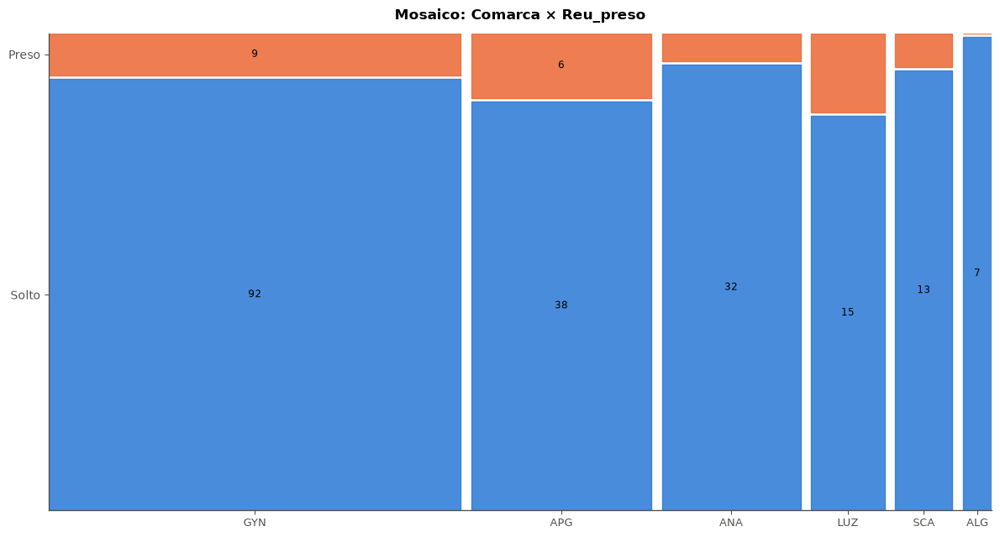

Tabela de contingência: Comarca × Reu_preso


Reu_preso,Solto,Preso,Total
Comarca,,,
Goiânia,92,9,101
Aparecida de Goiânia,38,6,44
Anápolis,32,2,34
Luziânia,15,3,18
Senador Canedo,13,1,14
Águas Lindas de Goiás,7,0,7
Total,197,21,218


Distribuição condicional de Reu_preso dentro de cada Comarca (% na linha)


Reu_preso,Solto,Preso
Comarca,,
Goiânia,91.10,8.90
Aparecida de Goiânia,86.40,13.60
Anápolis,94.10,5.90
Luziânia,83.30,16.70
Senador Canedo,92.90,7.10
Águas Lindas de Goiás,100.00,0.00


Resíduos padronizados ajustados (|r| > 1,96 ⇒ casela se afasta da independência)


Reu_preso,Solto,Preso
Comarca,,
Goiânia,0.34,-0.34
Aparecida de Goiânia,-1.01,1.01
Anápolis,0.81,-0.81
Luziânia,-1.06,1.06
Senador Canedo,0.33,-0.33
Águas Lindas de Goiás,0.88,-0.88


H₀: Comarca e Reu_preso são independentes na população  |  H₁: são associadas
χ² = 3.289; gl = 5; caselas com esperada < 5: 42%
Método: Qui-quadrado por permutação (10,000 reamostragens); p-valor = 0.6793; V de Cramér = 0.123
→ Não se rejeita H₀: sem evidência de associação (α = 5%).


In [84]:
ABREV_COMARCA = {'Goiânia': 'GYN', 'Aparecida de Goiânia': 'APG', 'Anápolis': 'ANA', 'Luziânia': 'LUZ',
                 'Senador Canedo': 'SCA', 'Águas Lindas de Goiás': 'ALG'}
analise_associacao_categoricas(dados, 'Comarca', 'Reu_preso', abreviar=ABREV_COMARCA);

**Leitura.** A proporção de réus presos varia de 0% (Águas Lindas) a 16,7% (Luziânia), mas o teste não rejeita H₀ (χ² = 3,29; gl = 5; p ≈ 0,68 por permutação; V de Cramér = 0,12). Com apenas 21 presos, 42% das caselas têm frequência esperada abaixo de 5 — por isso o p-valor foi obtido por permutação, e não pela aproximação qui-quadrado. No mosaico, as faixas de "Preso" têm alturas parecidas em todas as colunas. **Conclusão:** não há evidência de que a comarca influencie a proporção de réus presos; as diferenças observadas são compatíveis com o acaso.

**Assunto × Réu preso** (proposta do professor).

*Hipóteses testadas:* H₀ — a proporção de réus presos é a mesma para todos os tipos de crime; H₁ — ao menos um tipo de crime tem proporção diferente. Com 7 tipos, vários com 1 a 3 casos, a maioria das caselas tem frequência esperada < 5: a função passa automaticamente ao teste por permutação. Em seguida repete-se o teste com `Assunto_grupo` (3 classes), que é o tratamento recomendado no desafio.

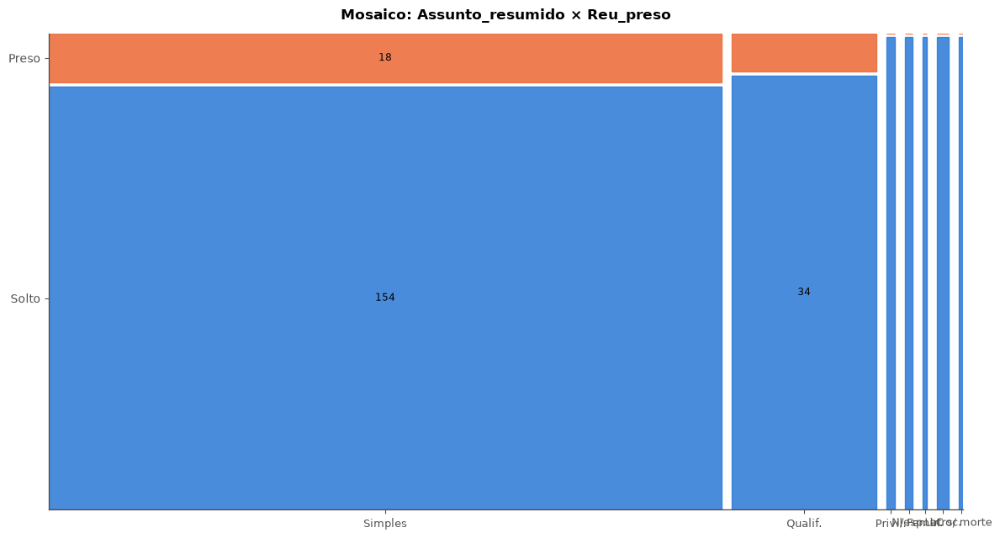

Tabela de contingência: Assunto_resumido × Reu_preso


Reu_preso,Solto,Preso,Total
Assunto_resumido,,,
Homicídio simples,154,18,172
Homicídio qualificado,34,3,37
Homicídio privilegiado,2,0,2
Homicídio (espécie não especificada),2,0,2
Feminicídio,1,0,1
Latrocínio,3,0,3
Lesão corporal seguida de morte,1,0,1
Total,197,21,218


Distribuição condicional de Reu_preso dentro de cada Assunto_resumido (% na linha)


Reu_preso,Solto,Preso
Assunto_resumido,,
Homicídio simples,89.50,10.50
Homicídio qualificado,91.90,8.10
Homicídio privilegiado,100.00,0.00
Homicídio (espécie não especificada),100.00,0.00
Feminicídio,100.00,0.00
Latrocínio,100.00,0.00
Lesão corporal seguida de morte,100.00,0.00


Resíduos padronizados ajustados (|r| > 1,96 ⇒ casela se afasta da independência)


Reu_preso,Solto,Preso
Assunto_resumido,,
Homicídio simples,-0.81,0.81
Homicídio qualificado,0.35,-0.35
Homicídio privilegiado,0.46,-0.46
Homicídio (espécie não especificada),0.46,-0.46
Feminicídio,0.33,-0.33
Latrocínio,0.57,-0.57
Lesão corporal seguida de morte,0.33,-0.33


H₀: Assunto_resumido e Reu_preso são independentes na população  |  H₁: são associadas
χ² = 1.195; gl = 6; caselas com esperada < 5: 79%
Método: Qui-quadrado por permutação (10,000 reamostragens); p-valor = 0.9107; V de Cramér = 0.074
→ Não se rejeita H₀: sem evidência de associação (α = 5%).


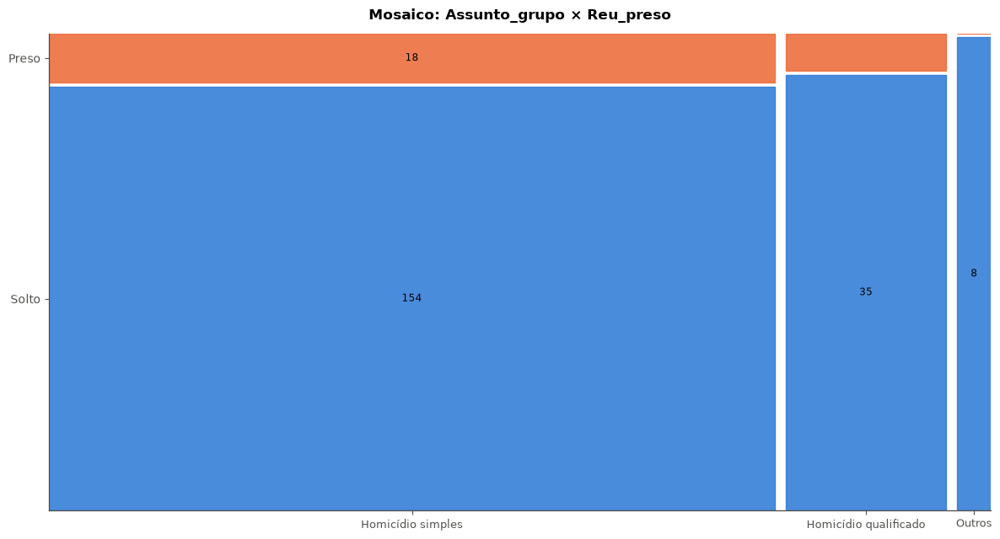

Tabela de contingência: Assunto_grupo × Reu_preso


Reu_preso,Solto,Preso,Total
Assunto_grupo,,,
Homicídio simples,154,18,172
Homicídio qualificado,35,3,38
Outros,8,0,8
Total,197,21,218


Distribuição condicional de Reu_preso dentro de cada Assunto_grupo (% na linha)


Reu_preso,Solto,Preso
Assunto_grupo,,
Homicídio simples,89.50,10.50
Homicídio qualificado,92.10,7.90
Outros,100.00,0.00


Resíduos padronizados ajustados (|r| > 1,96 ⇒ casela se afasta da independência)


Reu_preso,Solto,Preso
Assunto_grupo,,
Homicídio simples,-0.81,0.81
Homicídio qualificado,0.40,-0.40
Outros,0.94,-0.94


H₀: Assunto_grupo e Reu_preso são independentes na população  |  H₁: são associadas
χ² = 1.121; gl = 2; caselas com esperada < 5: 33%
Método: Qui-quadrado por permutação (10,000 reamostragens); p-valor = 0.5882; V de Cramér = 0.072
→ Não se rejeita H₀: sem evidência de associação (α = 5%).


In [85]:
ABREV_ASSUNTO = {'Homicídio simples': 'Simples', 'Homicídio qualificado': 'Qualif.', 'Homicídio privilegiado': 'Privil.',
                 'Homicídio (espécie não especificada)': 'N/esp.', 'Feminicídio': 'Femin.', 'Latrocínio': 'Latroc.',
                 'Lesão corporal seguida de morte': 'LC s/ morte'}
analise_associacao_categoricas(dados, 'Assunto_resumido', 'Reu_preso', abreviar=ABREV_ASSUNTO)
analise_associacao_categoricas(dados, 'Assunto_grupo', 'Reu_preso');

**Leitura.** Nenhuma associação: com os 7 tipos (χ² = 1,20; gl = 6; 79% das caselas com esperada < 5; p ≈ 0,91; V = 0,07) e com os 3 grupos (χ² = 1,12; gl = 2; p ≈ 0,59; V = 0,07). A proporção de presos é de 10,5% no homicídio simples e de 7,9% no qualificado. Os tipos raros não têm nenhum preso, mas com 1 a 3 casos cada isso não diz nada. O agrupamento em `Assunto_grupo` não mudou a conclusão, mas tornou o teste mais confiável: a porcentagem de caselas problemáticas caiu de 79% para 33%.

### Desafio do Exercício 4

1. **Hipóteses** — enunciadas acima, antes de cada teste;
2. **Tratar variáveis com muitas categorias** — `Desfecho` tem 11 classes, várias com menos de 10 casos;
3. **Dicionário de abreviaturas** — `ABREV_DESFECHO` encurta os rótulos no mosaico;
4. **Top 6 + "Outros"** — `agrupar_top` mantém as 6 categorias mais frequentes e agrupa as demais. A nova variável continua sendo uma partição (verificada).

Associação escolhida: **Comarca × Desfecho** — o modo como os inquéritos terminam depende da comarca?

In [86]:
def agrupar_top(serie, k=6, outros='Outros'):
    """Mantém as k categorias mais frequentes e agrupa as demais em `outros` (resultado: category)."""
    top = serie.value_counts().index[:k].tolist()
    mapa = {c: (c if c in top else outros) for c in serie.dropna().unique()}
    return para_categoria(serie.astype('string'), {str(c): str(v) for c, v in mapa.items()},
                          [str(c) for c in top] + [outros])


ABREV_DESFECHO = {
    'Em investigação': 'Em invest.',
    'Denúncia oferecida': 'Denúncia',
    'Suspenso': 'Suspenso',
    'Arquivado: falta de justa causa': 'Arq. just. causa',
    'Arquivado: pedido deferido (motivo não especificado)': 'Arq. pedido',
    'Arquivado: extinção da punibilidade': 'Arq. ext. pun.',
    'Arquivado: atipicidade': 'Arq. atípico',
    'Arquivado: autoria desconhecida': 'Arq. s/ autoria',
    'Arquivado: litispendência': 'Arq. litisp.',
    'Arquivado: indiciado não denunciado': 'Arq. não denunc.',
    'Arquivado: outros motivos': 'Arq. outros',
    'Outros desfechos': 'Outros',
}
dados['Desfecho_top6'] = agrupar_top(dados['Desfecho'], k=6, outros='Outros desfechos')
display(verificar_particao(dados['Desfecho_top6'], dados['Desfecho']))
display(pd.Series(ABREV_DESFECHO, name='Abreviatura').rename_axis('Rótulo').to_frame())

,Casos,%
Desfecho_top6,,
Arquivado: falta de justa causa,90,41.28
Arquivado: pedido deferido (motivo não especificado),26,11.93
Em investigação,24,11.01
Arquivado: extinção da punibilidade,19,8.72
Arquivado: atipicidade,17,7.80
Arquivado: autoria desconhecida,16,7.34
Outros desfechos,26,11.93


,Abreviatura
Rótulo,
Em investigação,Em invest.
Denúncia oferecida,Denúncia
Suspenso,Suspenso
Arquivado: falta de justa causa,Arq. just. causa
Arquivado: pedido deferido (motivo não especificado),Arq. pedido
Arquivado: extinção da punibilidade,Arq. ext. pun.
Arquivado: atipicidade,Arq. atípico
Arquivado: autoria desconhecida,Arq. s/ autoria
Arquivado: litispendência,Arq. litisp.


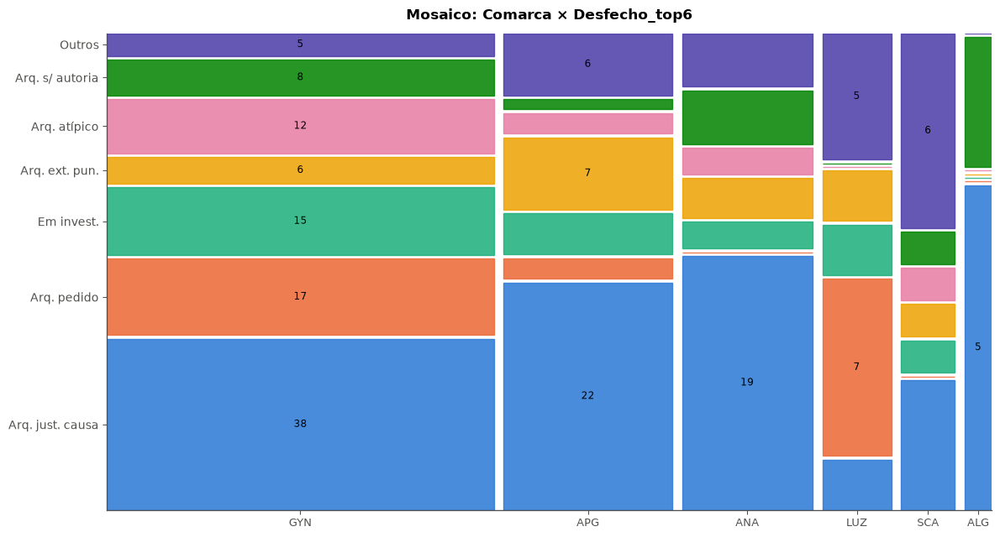

Tabela de contingência: Comarca × Desfecho_top6


Desfecho_top6,Arquivado: falta de justa causa,Arquivado: pedido deferido (motivo não especificado),Em investigação,Arquivado: extinção da punibilidade,Arquivado: atipicidade,Arquivado: autoria desconhecida,Outros desfechos,Total
Comarca,,,,,,,,
Goiânia,38,17,15,6,12,8,5,101
Aparecida de Goiânia,22,2,4,7,2,1,6,44
Anápolis,19,0,2,3,2,4,4,34
Luziânia,2,7,2,2,0,0,5,18
Senador Canedo,4,0,1,1,1,1,6,14
Águas Lindas de Goiás,5,0,0,0,0,2,0,7
Total,90,26,24,19,17,16,26,218


Distribuição condicional de Desfecho_top6 dentro de cada Comarca (% na linha)


Desfecho_top6,Arquivado: falta de justa causa,Arquivado: pedido deferido (motivo não especificado),Em investigação,Arquivado: extinção da punibilidade,Arquivado: atipicidade,Arquivado: autoria desconhecida,Outros desfechos
Comarca,,,,,,,
Goiânia,37.60,16.80,14.90,5.90,11.90,7.90,5.00
Aparecida de Goiânia,50.00,4.50,9.10,15.90,4.50,2.30,13.60
Anápolis,55.90,0.00,5.90,8.80,5.90,11.80,11.80
Luziânia,11.10,38.90,11.10,11.10,0.00,0.00,27.80
Senador Canedo,28.60,0.00,7.10,7.10,7.10,7.10,42.90
Águas Lindas de Goiás,71.40,0.00,0.00,0.00,0.00,28.60,0.00


Resíduos padronizados ajustados (|r| > 1,96 ⇒ casela se afasta da independência)


Desfecho_top6,Arquivado: falta de justa causa,Arquivado: pedido deferido (motivo não especificado),Em investigação,Arquivado: extinção da punibilidade,Arquivado: atipicidade,Arquivado: autoria desconhecida,Outros desfechos
Comarca,,,,,,,
Goiânia,-1.02,2.08,1.68,-1.35,2.09,0.31,-2.95
Aparecida de Goiânia,1.31,-1.69,-0.46,1.89,-0.90,-1.44,0.39
Anápolis,1.88,-2.34,-1.04,0.02,-0.45,1.08,-0.03
Luziânia,-2.71,3.68,0.01,0.38,-1.29,-1.25,2.17
Senador Canedo,-1.00,-1.42,-0.48,-0.22,-0.09,-0.03,3.69
Águas Lindas de Goiás,1.65,-0.99,-0.95,-0.83,-0.78,2.19,-0.99


H₀: Comarca e Desfecho_top6 são independentes na população  |  H₁: são associadas
χ² = 71.151; gl = 30; caselas com esperada < 5: 69%
Método: Qui-quadrado por permutação (10,000 reamostragens); p-valor = 0.0001; V de Cramér = 0.255
→ Rejeita-se H₀: há evidência de associação (α = 5%).


In [87]:
tab_comarca_desfecho, res_comarca_desfecho = analise_associacao_categoricas(
    dados, 'Comarca', 'Desfecho_top6', abreviar={**ABREV_COMARCA, **ABREV_DESFECHO})

**Leitura.** Aqui a associação é clara: χ² = 71,15 (gl = 30), p ≈ 0,0001 por permutação e V de Cramér = 0,26 (associação moderada). Os resíduos ajustados apontam onde ela está:

- **Luziânia**: excesso de arquivamento por "pedido deferido" sem motivo especificado (38,9% contra 11,9% no geral; r = +3,68) e falta de "falta de justa causa" (11,1%; r = −2,71). Isso sugere uma **prática de registro** no Projudi local, que lança o arquivamento como genérico — é uma diferença de rotulagem, não necessariamente de decisão;
- **Senador Canedo**: excesso de "outros desfechos" (42,9%; r = +3,69), que inclui litispendência, suspensão e denúncia;
- **Goiânia**: mais atipicidade (11,9%; r = +2,09) e mais "pedido deferido" (r = +2,08), e menos "outros" (r = −2,95);
- **Anápolis**: nenhum "pedido deferido" (r = −2,34) e 55,9% por falta de justa causa;
- **Águas Lindas**: excesso de autoria desconhecida (28,6%; r = +2,19), com n = 7.

O mapa de correspondência resume o mesmo quadro: as duas primeiras dimensões retêm 82% da inércia. Luziânia se isola à direita, junto de "Arq. pedido"; Senador Canedo, no alto, junto de "Outros"; Goiânia, embaixo, próxima de "Em investigação" e "Arq. atípico"; Anápolis, Aparecida e Águas Lindas, à esquerda, com os arquivamentos por falta de justa causa e por autoria desconhecida.

**Análise de Correspondência (*Correspondence Analysis Plot*).** Para tabelas maiores que 2×2, a análise de correspondência resume a associação em um mapa: a tabela de resíduos de independência é decomposta por valores singulares (SVD), e comarcas e desfechos são projetados nas duas dimensões que retêm a maior parte da **inércia** (χ²/n). Pontos próximos da origem estão perto do perfil médio; uma comarca próxima de um desfecho tem esse desfecho acima do esperado.

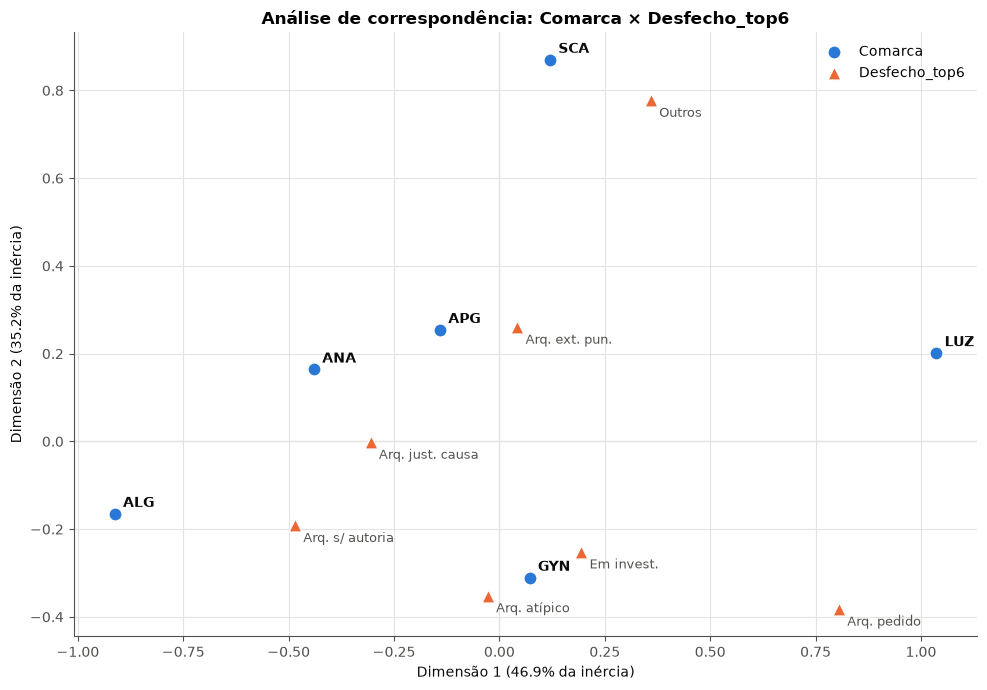

Inércia total = 0.3264 (= χ²/n). Dimensões 1 e 2 retêm 82.0%.


,Inércia,% da inércia,% acumulado
Dim 1,0.15,46.85,46.85
Dim 2,0.12,35.17,82.02
Dim 3,0.04,10.74,92.76
Dim 4,0.02,7.21,99.97
Dim 5,0.00,0.03,100.00
Dim 6,0.00,0.00,100.00


In [88]:
def analise_correspondencia(tabela, abreviar=None, titulo=None):
    abreviar = abreviar or {}
    N = tabela.to_numpy(dtype=float)
    P = N / N.sum()
    r, c = P.sum(1), P.sum(0)
    S = (P - np.outer(r, c)) / np.sqrt(np.outer(r, c))
    U, sv, Vt = np.linalg.svd(S, full_matrices=False)
    inercia = sv ** 2
    linhas = (U * sv) / np.sqrt(r)[:, None]
    colunas = (Vt.T * sv) / np.sqrt(c)[:, None]
    pct = 100 * inercia / inercia.sum()

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.axhline(0, color=GRADE, linewidth=1)
    ax.axvline(0, color=GRADE, linewidth=1)
    ax.scatter(linhas[:, 0], linhas[:, 1], s=90, color=COR_PRINCIPAL, edgecolor='white', zorder=3,
               label=tabela.index.name)
    ax.scatter(colunas[:, 0], colunas[:, 1], s=90, marker='^', color=COR_DESTAQUE, edgecolor='white', zorder=3,
               label=tabela.columns.name)
    for (x, y), nome in zip(linhas[:, :2], tabela.index):
        ax.annotate(abreviar.get(str(nome), str(nome)), (x, y), xytext=(6, 5), textcoords='offset points',
                    color=TINTA, fontsize=10, fontweight='bold')
    for (x, y), nome in zip(colunas[:, :2], tabela.columns):
        ax.annotate(abreviar.get(str(nome), str(nome)), (x, y), xytext=(6, -12), textcoords='offset points',
                    color=TINTA_2, fontsize=9)
    ax.set_xlabel(f'Dimensão 1 ({pct[0]:.1f}% da inércia)')
    ax.set_ylabel(f'Dimensão 2 ({pct[1]:.1f}% da inércia)')
    ax.set_title(titulo or f'Análise de correspondência: {tabela.index.name} × {tabela.columns.name}')
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()
    print(f'Inércia total = {inercia.sum():.4f} (= χ²/n). Dimensões 1 e 2 retêm {pct[:2].sum():.1f}%.')
    return pd.DataFrame({'Inércia': inercia, '% da inércia': pct, '% acumulado': pct.cumsum()},
                        index=[f'Dim {i + 1}' for i in range(len(sv))]).round(3)


analise_correspondencia(tab_comarca_desfecho, {**ABREV_COMARCA, **ABREV_DESFECHO})

**Outras associações de interesse.** Forma de instauração × réu preso (esperada: o flagrante gera prisão), comarca × arma de fogo, indiciamento × situação processual, e tentativa × réu preso.

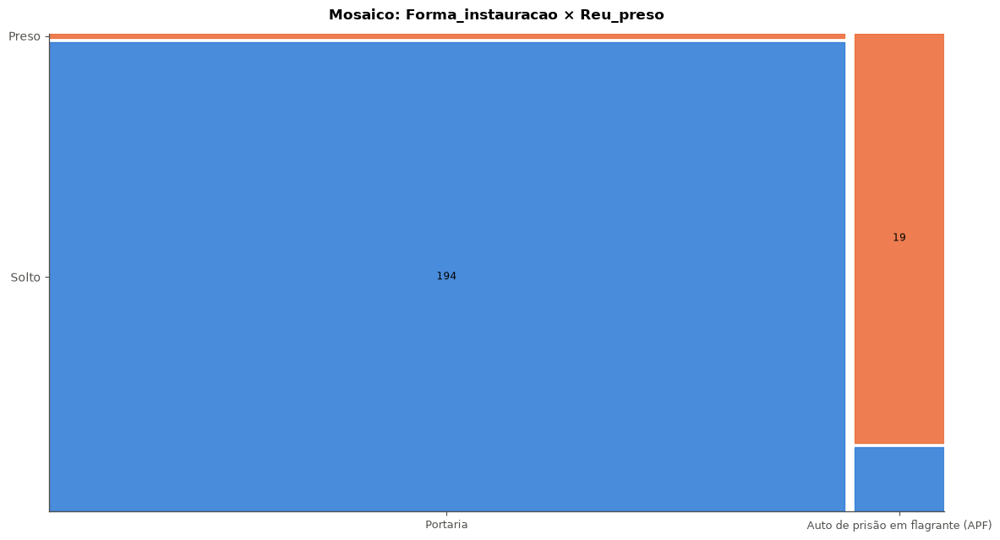

Tabela de contingência: Forma_instauracao × Reu_preso


Reu_preso,Solto,Preso,Total
Forma_instauracao,,,
Portaria,194,2,196
Auto de prisão em flagrante (APF),3,19,22
Total,197,21,218


Distribuição condicional de Reu_preso dentro de cada Forma_instauracao (% na linha)


Reu_preso,Solto,Preso
Forma_instauracao,,
Portaria,99.00,1.00
Auto de prisão em flagrante (APF),13.60,86.40


Resíduos padronizados ajustados (|r| > 1,96 ⇒ casela se afasta da independência)


Reu_preso,Solto,Preso
Forma_instauracao,,
Portaria,12.86,-12.86
Auto de prisão em flagrante (APF),-12.86,12.86


H₀: Forma_instauracao e Reu_preso são independentes na população  |  H₁: são associadas
χ² = 165.496; gl = 1; caselas com esperada < 5: 25%
Método: Exato de Fisher; p-valor = 0.0000; V de Cramér = 0.871
→ Rejeita-se H₀: há evidência de associação (α = 5%).


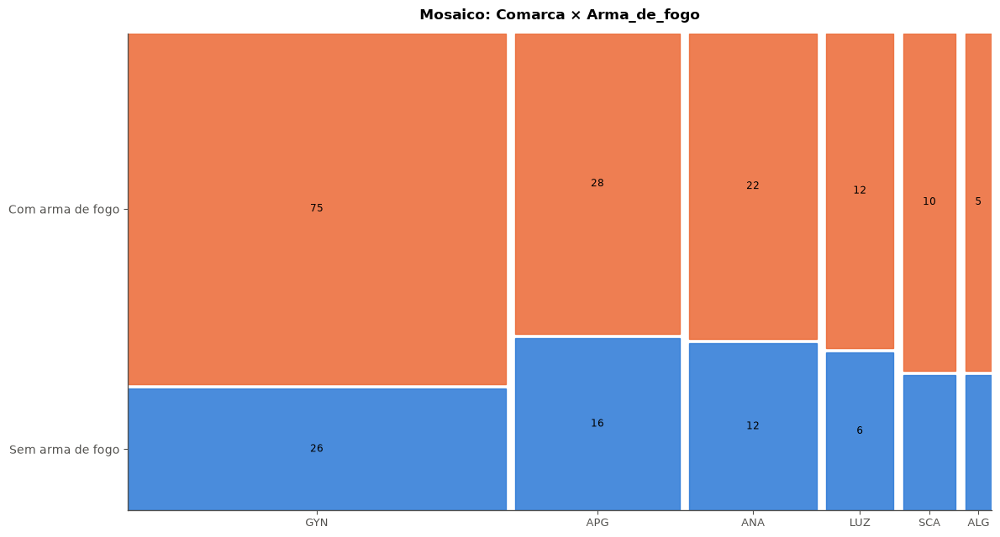

Tabela de contingência: Comarca × Arma_de_fogo


Arma_de_fogo,Sem arma de fogo,Com arma de fogo,Total
Comarca,,,
Goiânia,26,75,101
Aparecida de Goiânia,16,28,44
Anápolis,12,22,34
Luziânia,6,12,18
Senador Canedo,4,10,14
Águas Lindas de Goiás,2,5,7
Total,66,152,218


Distribuição condicional de Arma_de_fogo dentro de cada Comarca (% na linha)


Arma_de_fogo,Sem arma de fogo,Com arma de fogo
Comarca,,
Goiânia,25.70,74.30
Aparecida de Goiânia,36.40,63.60
Anápolis,35.30,64.70
Luziânia,33.30,66.70
Senador Canedo,28.60,71.40
Águas Lindas de Goiás,28.60,71.40


Resíduos padronizados ajustados (|r| > 1,96 ⇒ casela se afasta da independência)


Arma_de_fogo,Sem arma de fogo,Com arma de fogo
Comarca,,
Goiânia,-1.35,1.35
Aparecida de Goiânia,0.98,-0.98
Anápolis,0.69,-0.69
Luziânia,0.29,-0.29
Senador Canedo,-0.14,0.14
Águas Lindas de Goiás,-0.10,0.10


H₀: Comarca e Arma_de_fogo são independentes na população  |  H₁: são associadas
χ² = 2.270; gl = 5; caselas com esperada < 5: 25%
Método: Qui-quadrado por permutação (10,000 reamostragens); p-valor = 0.8130; V de Cramér = 0.102
→ Não se rejeita H₀: sem evidência de associação (α = 5%).


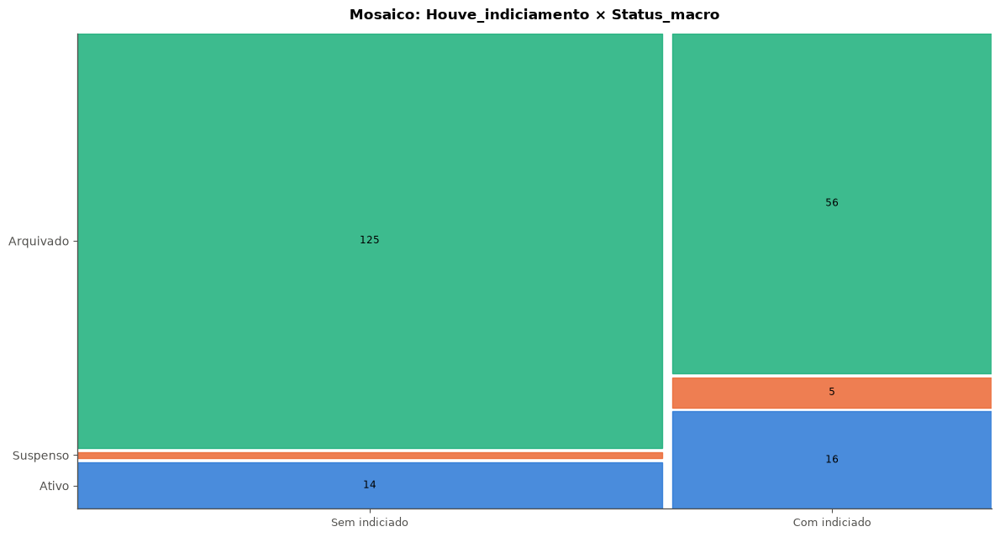

Tabela de contingência: Houve_indiciamento × Status_macro


Status_macro,Ativo,Suspenso,Arquivado,Total
Houve_indiciamento,,,,
Sem indiciado,14,2,125,141
Com indiciado,16,5,56,77
Total,30,7,181,218


Distribuição condicional de Status_macro dentro de cada Houve_indiciamento (% na linha)


Status_macro,Ativo,Suspenso,Arquivado
Houve_indiciamento,,,
Sem indiciado,9.90,1.40,88.70
Com indiciado,20.80,6.50,72.70


Resíduos padronizados ajustados (|r| > 1,96 ⇒ casela se afasta da independência)


Status_macro,Ativo,Suspenso,Arquivado
Houve_indiciamento,,,
Sem indiciado,-2.22,-2.03,2.99
Com indiciado,2.22,2.03,-2.99


H₀: Houve_indiciamento e Status_macro são independentes na população  |  H₁: são associadas
χ² = 9.777; gl = 2; caselas com esperada < 5: 33%
Método: Qui-quadrado por permutação (10,000 reamostragens); p-valor = 0.0064; V de Cramér = 0.212
→ Rejeita-se H₀: há evidência de associação (α = 5%).


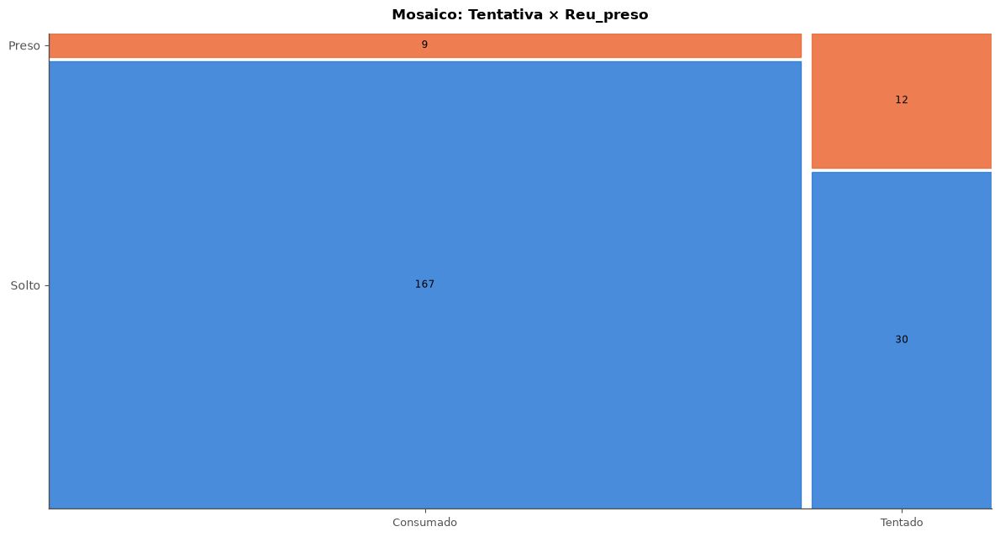

Tabela de contingência: Tentativa × Reu_preso


Reu_preso,Solto,Preso,Total
Tentativa,,,
Consumado,167,9,176
Tentado,30,12,42
Total,197,21,218


Distribuição condicional de Reu_preso dentro de cada Tentativa (% na linha)


Reu_preso,Solto,Preso
Tentativa,,
Consumado,94.90,5.10
Tentado,71.40,28.60


Resíduos padronizados ajustados (|r| > 1,96 ⇒ casela se afasta da independência)


Reu_preso,Solto,Preso
Tentativa,,
Consumado,4.63,-4.63
Tentado,-4.63,4.63


H₀: Tentativa e Reu_preso são independentes na população  |  H₁: são associadas
χ² = 21.434; gl = 1; caselas com esperada < 5: 25%
Método: Exato de Fisher; p-valor = 0.0000; V de Cramér = 0.314
→ Rejeita-se H₀: há evidência de associação (α = 5%).


In [89]:
analise_associacao_categoricas(dados, 'Forma_instauracao', 'Reu_preso')
analise_associacao_categoricas(dados, 'Comarca', 'Arma_de_fogo', abreviar=ABREV_COMARCA)
analise_associacao_categoricas(dados, 'Houve_indiciamento', 'Status_macro')
analise_associacao_categoricas(dados, 'Tentativa', 'Reu_preso');

In [90]:
tabela_associacoes = pd.DataFrame(resultados_associacao).drop_duplicates(['Variável 1', 'Variável 2'])
tabela_associacoes['Significativo (5%)'] = tabela_associacoes['p-valor'] < 0.05
print('RESUMO DOS TESTES DE ASSOCIAÇÃO')
display(tabela_associacoes.round(4))

RESUMO DOS TESTES DE ASSOCIAÇÃO


,Variável 1,Variável 2,n,Tabela,χ²,gl,% esperada < 5,Método,p-valor,V de Cramér,Significativo (5%)
0,Comarca,Reu_preso,218,6×2,3.29,5,41.67,"Qui-quadrado por permutação (10,000 reamostragens)",0.68,0.12,False
1,Assunto_resumido,Reu_preso,218,7×2,1.20,6,78.57,"Qui-quadrado por permutação (10,000 reamostragens)",0.91,0.07,False
2,Assunto_grupo,Reu_preso,218,3×2,1.12,2,33.33,"Qui-quadrado por permutação (10,000 reamostragens)",0.59,0.07,False
3,Comarca,Desfecho_top6,218,6×7,71.15,30,69.05,"Qui-quadrado por permutação (10,000 reamostragens)",0.00,0.26,True
4,Forma_instauracao,Reu_preso,218,2×2,165.50,1,25.00,Exato de Fisher,0.00,0.87,True
5,Comarca,Arma_de_fogo,218,6×2,2.27,5,25.00,"Qui-quadrado por permutação (10,000 reamostragens)",0.81,0.10,False
6,Houve_indiciamento,Status_macro,218,2×3,9.78,2,33.33,"Qui-quadrado por permutação (10,000 reamostragens)",0.01,0.21,True
7,Tentativa,Reu_preso,218,2×2,21.43,1,25.00,Exato de Fisher,0.00,0.31,True


**Síntese do Exercício 4.** Das oito associações testadas, quatro são significativas:

| Associação | V de Cramér | Interpretação |
|---|---|---|
| Forma de instauração × réu preso | 0,87 (forte) | 86,4% dos APF têm réu preso, contra 1,0% das portarias: é praticamente a mesma informação |
| Tentativa × réu preso | 0,31 (moderada) | 28,6% de presos nas tentativas contra 5,1% nos consumados: com a vítima viva, o flagrante e a identificação do autor são mais frequentes |
| Comarca × desfecho | 0,26 (moderada) | diferenças de **registro** do motivo de arquivamento entre comarcas |
| Indiciamento × situação | 0,21 (fraca a moderada) | com indiciado, 20,8% continuam ativos e 72,7% foram arquivados; sem indiciado, 88,7% foram arquivados |

Não houve associação da comarca com réu preso nem com arma de fogo (64% a 74% em todas as comarcas), nem do tipo de crime com réu preso. **As associações encontradas fazem sentido teórico:** o flagrante gera prisão por definição; a tentativa deixa uma testemunha-chave viva; sem autor identificado, o destino natural é o arquivamento. A ressalva metodológica é o tamanho da amostra: com 218 casos e categorias raras, quase todos os testes exigiram permutação ou teste exato.

---

## 14. Análise de Relações entre Variáveis Quantitativas (Exercício 5)

### Objetivo
Diagramas de dispersão com retas de regressão para explorar relações lineares entre variáveis quantitativas.

**Pearson × Spearman.** O r de Pearson mede relação **linear** e é sensível a valores extremos; o ρ de Spearman mede relação **monotônica** (sobre postos) e é robusto. Com distribuições muito assimétricas, como os tempos deste estudo, divergências entre os dois indicam que poucos casos extremos dirigem o r de Pearson. As matrizes usam, para cada par, os casos com ambos os valores presentes.

In [91]:
VARS_CORRELACAO = ['N_indiciados', 'N_vitimas', 'Ano_instauracao', 'Tempo_fato_instauracao', 'Tempo_conclusao_ip',
                   'Quantidade_manifestacao_mp', 'N_itens_diligencia', 'Tempo_entre_manifestacoes_mp',
                   'Tempo_conclusao_mp']


def matriz_correlacao(dados, variaveis=None):
    """Matrizes de Pearson e de Spearman lado a lado, com a mesma escala divergente (−1 a 1)."""
    variaveis = variaveis or VARS_CORRELACAO
    df = dados[variaveis].astype(float)
    matrizes = {'Pearson': df.corr(method='pearson'), 'Spearman': df.corr(method='spearman')}
    fig, axes = plt.subplots(1, 2, figsize=(17, 7.2))
    mascara = np.triu(np.ones((len(variaveis), len(variaveis)), dtype=bool), k=1)
    for ax, (nome, m) in zip(axes, matrizes.items()):
        sns.heatmap(m, mask=mascara, annot=True, fmt='.2f', cmap=MAPA_DIVERGENTE, vmin=-1, vmax=1, center=0,
                    square=True, linewidths=1, linecolor='white', cbar_kws={'shrink': 0.7}, ax=ax,
                    annot_kws={'fontsize': 8.5})
        ax.set_title(f'Correlação de {nome}')
        ax.tick_params(axis='x', rotation=45)
        plt.setp(ax.get_xticklabels(), ha='right')
    plt.tight_layout()
    plt.show()

    pares = []
    for i, a in enumerate(variaveis):
        for b in variaveis[i + 1:]:
            par = df[[a, b]].dropna()
            pares.append({'X': a, 'Y': b, 'n': len(par), 'Pearson r': matrizes['Pearson'].loc[a, b],
                          'Spearman ρ': matrizes['Spearman'].loc[a, b],
                          'p (Spearman)': stats.spearmanr(par[a], par[b]).pvalue})
    pares = pd.DataFrame(pares)
    fortes = pares.loc[pares[['Pearson r', 'Spearman ρ']].abs().max(axis=1) > 0.5]
    print('Pares com |r| ou |ρ| > 0,5:')
    display(fortes.sort_values('Spearman ρ', key=abs, ascending=False).round(3))
    return pares

In [92]:
def analise_correlacao(dados, var_x, var_y, unidade_x='', unidade_y='', log=False):
    """Dispersão com reta de mínimos quadrados, Pearson, Spearman, R² e interpretação."""
    df = dados[[var_x, var_y]].astype(float).dropna()
    unidade_x = unidade_x or UNIDADES.get(var_x, '')
    unidade_y = unidade_y or UNIDADES.get(var_y, '')
    pearson = stats.pearsonr(df[var_x], df[var_y])
    spearman = stats.spearmanr(df[var_x], df[var_y])
    reg = stats.linregress(df[var_x], df[var_y])

    fig, ax = plt.subplots(figsize=(11, 6.5))
    ax.scatter(df[var_x], df[var_y], s=40, color=COR_PRINCIPAL, alpha=0.75, edgecolor='white', linewidth=0.8, zorder=3)
    xs = np.linspace(df[var_x].min(), df[var_x].max(), 100)
    ax.plot(xs, reg.intercept + reg.slope * xs, color=COR_DESTAQUE, linewidth=2,
            label=f'Reta de MQ: ŷ = {reg.slope:.4f}·x + {reg.intercept:.2f}')
    if log:
        ax.set_yscale('symlog', linthresh=10)
    ax.set_xlabel(f'{var_x} ({unidade_x})' if unidade_x else var_x)
    ax.set_ylabel(f'{var_y} ({unidade_y})' if unidade_y else var_y)
    ax.set_title(f'Relação entre {var_x} e {var_y}  (n = {len(df)})')
    texto = (f'Pearson r = {pearson.statistic:.3f} (p = {pearson.pvalue:.4f})\n'
             f'Spearman ρ = {spearman.statistic:.3f} (p = {spearman.pvalue:.4f})\nR² = {reg.rvalue ** 2:.3f}')
    ax.text(0.02, 0.97, texto, transform=ax.transAxes, va='top', fontsize=9.5,
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=GRADE))
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

    forca = lambda r: 'fraca' if abs(r) < 0.3 else 'moderada' if abs(r) < 0.7 else 'forte'
    direcao = 'positiva' if pearson.statistic > 0 else 'negativa'
    print(f'Equação: {var_y} = {reg.slope:.5f} × {var_x} + {reg.intercept:.3f}')
    print(f'→ Correlação linear {forca(pearson.statistic)} e {direcao} (r = {pearson.statistic:.3f}); '
          f'monotônica {forca(spearman.statistic)} (ρ = {spearman.statistic:.3f}).')
    print(f'→ {"Significativa" if pearson.pvalue < 0.05 else "Não significativa"} a 5% (Pearson); '
          f'R² = {100 * reg.rvalue ** 2:.1f}% da variação de {var_y} associada linearmente a {var_x}.')

### Exercício 5: explore relações entre variáveis quantitativas

Primeiro, as matrizes de correlação para uma visão geral.

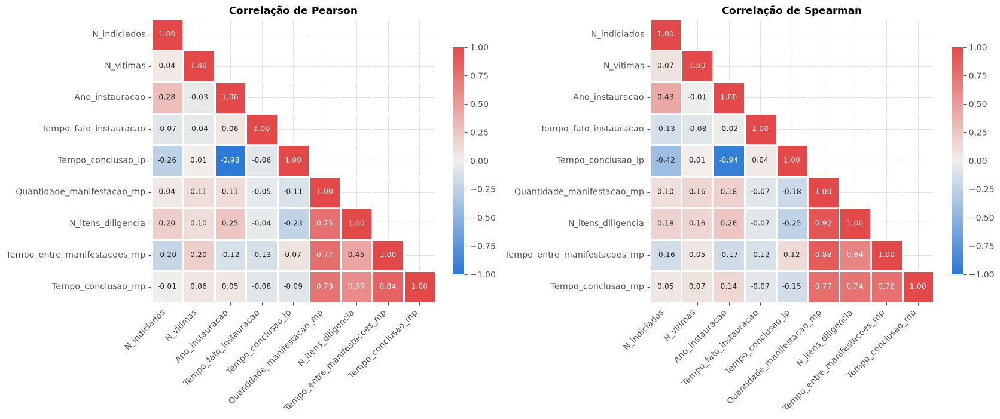

Pares com |r| ou |ρ| > 0,5:


,X,Y,n,Pearson r,Spearman ρ,p (Spearman)
16,Ano_instauracao,Tempo_conclusao_ip,218,-0.98,-0.94,0.00
30,Quantidade_manifestacao_mp,N_itens_diligencia,218,0.76,0.92,0.00
31,Quantidade_manifestacao_mp,Tempo_entre_manifestacoes_mp,123,0.77,0.88,0.00
32,Quantidade_manifestacao_mp,Tempo_conclusao_mp,192,0.73,0.77,0.00
35,Tempo_entre_manifestacoes_mp,Tempo_conclusao_mp,111,0.84,0.76,0.00
34,N_itens_diligencia,Tempo_conclusao_mp,192,0.59,0.74,0.00
33,N_itens_diligencia,Tempo_entre_manifestacoes_mp,123,0.45,0.64,0.00


In [93]:
pares_correlacao = matriz_correlacao(dados)

**Leitura.** Os pares com |r| ou |ρ| > 0,5 formam dois blocos:

1. **Ano de instauração × tempo de conclusão do IP: r = −0,98 (ρ = −0,94).** É quase uma relação determinística, e isso revela algo sobre a própria variável: como todos os recebimentos no Projudi estão concentrados entre 2022 e 2025, o "tempo de conclusão" é praticamente a **idade do inquérito** na chegada ao sistema (seção 15). Não é uma descoberta empírica sobre a polícia, e sim uma consequência da janela de observação da amostra;
2. **O bloco da atuação do MP**: quantidade de manifestações, nº de itens de diligência, tempo entre manifestações e tempo de conclusão no MP correlacionam-se de 0,45 a 0,92. Parte é definicional (mais manifestações ⇒ mais itens; ρ = 0,92), e parte é substantiva (mais manifestações ⇒ mais tempo no MP).

Pearson e Spearman divergem quando há assimetria: `N_itens_diligencia × Tempo_conclusao_mp` tem r = 0,59, mas ρ = 0,74, sinal de uma relação monotônica mas não linear, com poucos casos extremos. `N_vitimas` e `Tempo_fato_instauracao` não se relacionam com nada (|r| < 0,2).

Depois, pares específicos: o exemplo do professor (tempo do IP × nº de indiciados) e os pares que a matriz destacou ou que têm interesse teórico.

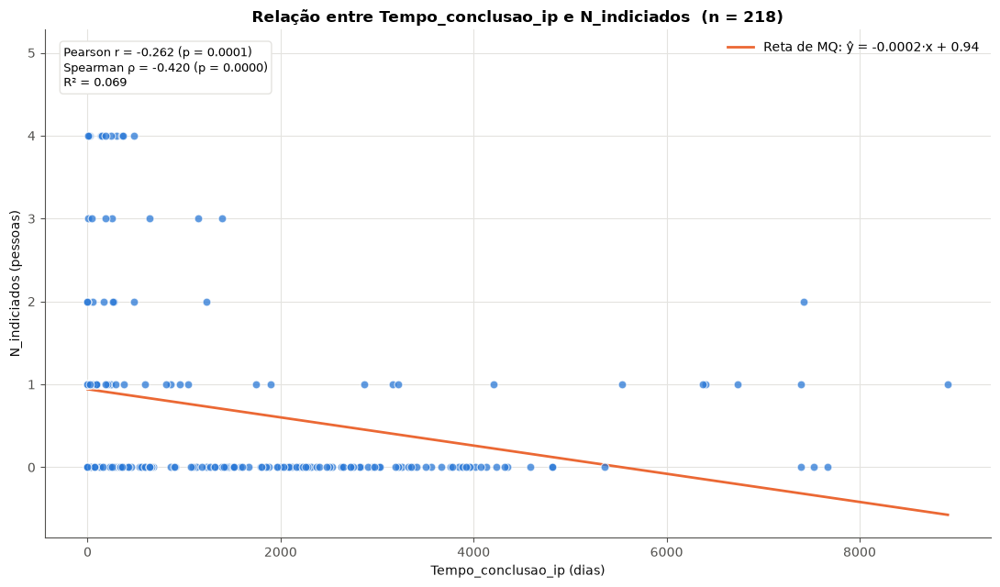

Equação: N_indiciados = -0.00017 × Tempo_conclusao_ip + 0.941
→ Correlação linear fraca e negativa (r = -0.262); monotônica moderada (ρ = -0.420).
→ Significativa a 5% (Pearson); R² = 6.9% da variação de N_indiciados associada linearmente a Tempo_conclusao_ip.


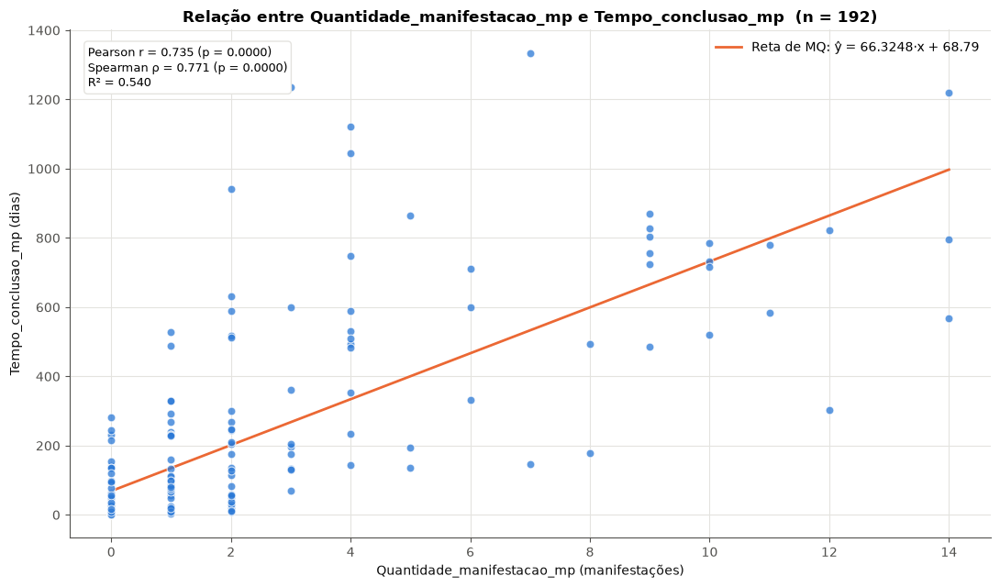

Equação: Tempo_conclusao_mp = 66.32478 × Quantidade_manifestacao_mp + 68.792
→ Correlação linear forte e positiva (r = 0.735); monotônica forte (ρ = 0.771).
→ Significativa a 5% (Pearson); R² = 54.0% da variação de Tempo_conclusao_mp associada linearmente a Quantidade_manifestacao_mp.


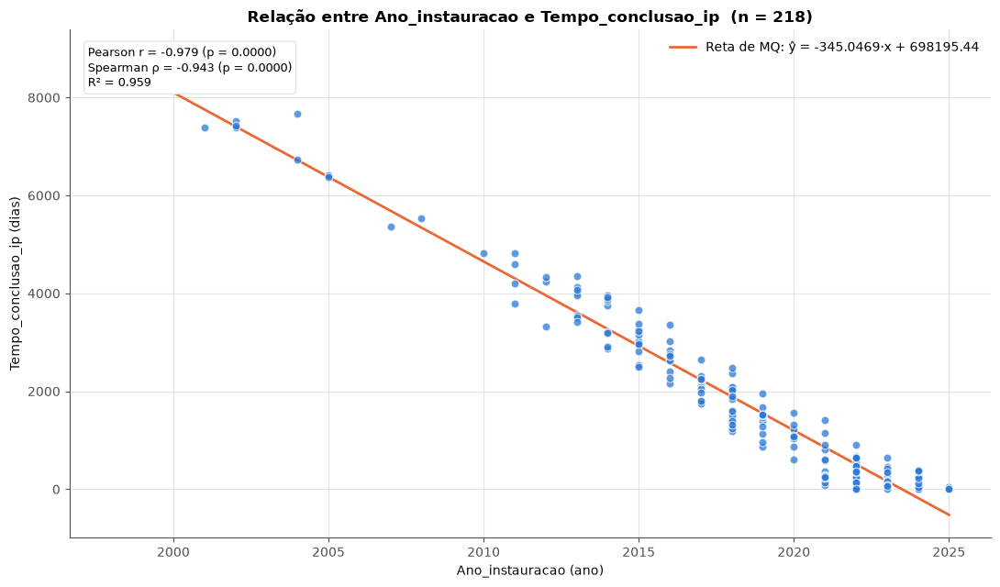

Equação: Tempo_conclusao_ip = -345.04689 × Ano_instauracao + 698195.443
→ Correlação linear forte e negativa (r = -0.979); monotônica forte (ρ = -0.943).
→ Significativa a 5% (Pearson); R² = 95.9% da variação de Tempo_conclusao_ip associada linearmente a Ano_instauracao.


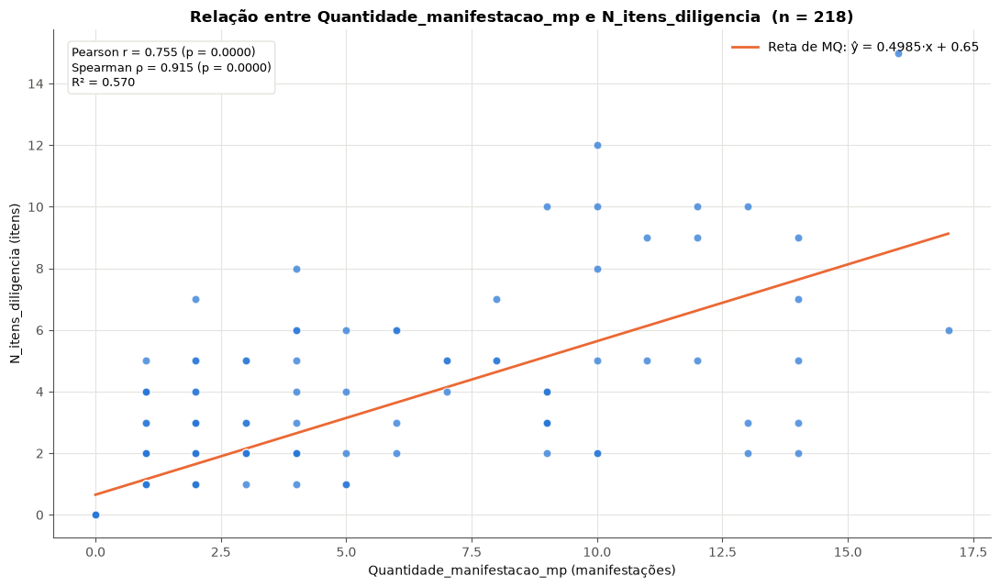

Equação: N_itens_diligencia = 0.49846 × Quantidade_manifestacao_mp + 0.653
→ Correlação linear forte e positiva (r = 0.755); monotônica forte (ρ = 0.915).
→ Significativa a 5% (Pearson); R² = 57.0% da variação de N_itens_diligencia associada linearmente a Quantidade_manifestacao_mp.


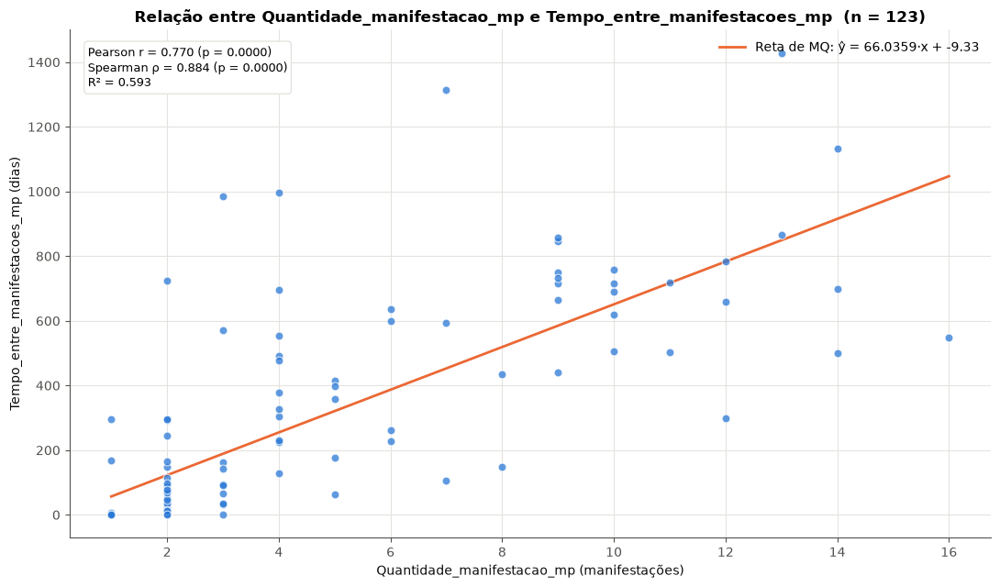

Equação: Tempo_entre_manifestacoes_mp = 66.03595 × Quantidade_manifestacao_mp + -9.327
→ Correlação linear forte e positiva (r = 0.770); monotônica forte (ρ = 0.884).
→ Significativa a 5% (Pearson); R² = 59.3% da variação de Tempo_entre_manifestacoes_mp associada linearmente a Quantidade_manifestacao_mp.


In [94]:
analise_correlacao(dados, 'Tempo_conclusao_ip', 'N_indiciados', unidade_x='dias', unidade_y='pessoas')
analise_correlacao(dados, 'Quantidade_manifestacao_mp', 'Tempo_conclusao_mp')
analise_correlacao(dados, 'Ano_instauracao', 'Tempo_conclusao_ip')
analise_correlacao(dados, 'Quantidade_manifestacao_mp', 'N_itens_diligencia')
analise_correlacao(dados, 'Quantidade_manifestacao_mp', 'Tempo_entre_manifestacoes_mp')

**Leitura dos pares.**

- **Tempo do IP × nº de indiciados** (exemplo do professor): correlação fraca e negativa (r = −0,26; ρ = −0,42; R² = 6,9%). Parece que "IPs mais rápidos têm mais indiciados", mas há um **confundidor**: o ano de instauração se correlaciona com o nº de indiciados (ρ = 0,43) e com o tempo (ρ = −0,94). Inquéritos recentes — muitos em flagrante — são curtos *e* têm autor identificado. A reta não deve ser lida como efeito do tempo sobre o indiciamento.;
- **Manifestações do MP × tempo de conclusão no MP**: relação forte e positiva (r = 0,74; ρ = 0,77; R² = 54%). Cada manifestação adicional está associada a cerca de **66 dias** a mais no MP. A causalidade é circular: cada requisição devolve o IP à polícia e prolonga o procedimento, e um procedimento longo dá ocasião a novas manifestações;
- **Ano de instauração × tempo do IP**: r = −0,98, R² = 95,9%; a inclinação (−345 dias por ano) está próxima de −365, o que é exatamente o esperado se o recebimento no Projudi ocorre numa data quase fixa;
- **Manifestações × itens de diligência** (ρ = 0,92) e **manifestações × tempo entre manifestações** (ρ = 0,88): relações quase mecânicas. A dispersão aumenta com x (heterocedasticidade), e a reta de mínimos quadrados subestima a variabilidade para quem tem muitas manifestações.

Todas as correlações fortes fazem sentido teórico, mas duas são **artefatos de construção** (ano × tempo; manifestações × itens). A lição é a do lema da seção final: correlação não é causalidade, e às vezes nem sequer é informação nova.

---

# PARTE II — ETAPA 1: O TEMPO DE TRAMITAÇÃO NA AMOSTRA DO ESTUDO

As seções 15 a 21 usam **os mesmos 218 inquéritos** analisados nos exercícios do professor e tomam o **tempo de tramitação** como variável-alvo. A ordem vai do mais simples ao mais complexo:

| Seção | Pergunta | Ferramentas |
|---|---|---|
| 15 | O que é o tempo de tramitação e como ele se distribui? | definição, estatísticas descritivas, histograma, boxplot |
| 16 | O tempo segue a distribuição normal? | Shapiro-Wilk, D'Agostino, Anderson-Darling, Lilliefors, Q-Q |
| 17 | Quais variáveis se associam ao tempo e ao desfecho? | binomial, qui-quadrado, Fisher, Mann-Whitney, Kruskal-Wallis, Dunn, Spearman |
| 18 | Que distribuição descreve o tempo? | máxima verossimilhança, AIC/BIC, razão de verossimilhança, FDA empírica × teórica, KS por bootstrap |
| 19 | O que explica o tempo, o indiciamento e a denúncia? | regressão linear (R²), logística (AUC), logística de Firth |
| 20 | E os procedimentos ainda não concluídos? | análise de sobrevivência: Kaplan-Meier, log-rank, Cox, AFT |
| 21 | A janela de observação distorce o tempo total? | truncamento à esquerda, teste de Tsai, entrada tardia |

## 15. O Tempo de Tramitação: Definição e Descrição

### 15.1 O que se mede

O trajeto de um inquérito na base tem quatro marcos datados:

| Intervalo | Início → fim | Variável | Observação |
|---|---|---|---|
| Fato → instauração | `Data_fato` → `Data_instauracao` | `Tempo_fato_instauracao` | quase sempre poucos dias |
| Fase policial observada | `Data_instauracao` → `Data_recebimento_projudi` | `Tempo_conclusao_ip` | termina na **chegada ao Projudi**, não na conclusão do IP |
| **Fase judicial** | `Data_recebimento_projudi` → `Data_conclusao_mp` | `Tempo_fase_judicial` | do recebimento no Projudi à conclusão no MP |
| **Tempo total** | `Data_instauracao` → `Data_conclusao_mp` | `Tempo_total` | soma das duas fases |

**Conclusão** é a data em que o MP concluiu o procedimento (arquivamento, denúncia ou outro desfecho). **26 procedimentos ainda não estavam concluídos** na data de referência da coleta (12/03/2026). Neles, o tempo observado é só um **limite inferior** do tempo real. Esses casos se chamam **censurados**. As seções 15 a 19 trabalham com os 192 concluídos, e a seção 20 mostra como incluir os censurados.

In [95]:
evento = dados['Concluido_mp'].astype(bool)
fim_observado = dados['Data_conclusao_mp'].where(evento, DATA_REFERENCIA)
dados['Tempo_fase_judicial'] = (fim_observado - dados['Data_recebimento_projudi']).dt.days.astype('Int64')
dados['Tempo_total'] = (fim_observado - dados['Data_instauracao']).dt.days.astype('Int64')
dados['Idade_entrada_anos'] = (dados['Tempo_conclusao_ip'].astype('Float64') / 365.25).round(3)
dados['Multiplas_vitimas'] = dados['N_vitimas'].gt(1).astype('boolean')
dados['Ano_recebimento_projudi'] = pd.Categorical(dados['Data_recebimento_projudi'].dt.year, ordered=True)
dados['Coorte_instauracao'] = pd.cut(dados['Ano_instauracao'].astype(float), [1990, 2014, 2018, 2021, 2030],
                                     labels=['até 2014', '2015–2018', '2019–2021', '2022 em diante'], ordered=True)
ROTULOS_BOOLEANOS.update({'Multiplas_vitimas': ('Uma vítima', 'Mais de uma vítima')})

# Coerência do desfecho: aditividade, sinais e correspondência entre evento, data e situação
assert (dados['Tempo_total'] == dados['Tempo_conclusao_ip'] + dados['Tempo_fase_judicial']).all()
assert (dados['Tempo_fase_judicial'] >= 0).all() and (dados['Tempo_total'] >= 0).all()
assert (dados.loc[evento, 'Tempo_fase_judicial'] == dados.loc[evento, 'Tempo_conclusao_mp']).all()
print('Situação processual × conclusão no MP:')
display(pd.crosstab(dados['Status_macro'], serie_exibicao(dados, 'Concluido_mp'), margins=True, margins_name='Total'))
ativos_concluidos = dados['Status_macro'].isin(['Ativo', 'Suspenso']) & evento
print(f'Ativos/suspensos com data de conclusão no MP: {int(ativos_concluidos.sum())} | '
      f'arquivados sem data de conclusão: {int((dados["Status_macro"].eq("Arquivado") & ~evento).sum())}')

DESFECHOS = {
    'Tempo_fase_judicial': 'Fase judicial (Projudi → conclusão no MP)',
    'Tempo_total': 'Tempo total (instauração → conclusão no MP)',
}
# Durações para modelos (dias + 0,5: as datas não têm hora, e um evento "no mesmo dia" dura entre 0 e 1 dia)
T_TOTAL = dados['Tempo_total'].astype(float) + 0.5
T_JUD = dados['Tempo_fase_judicial'].astype(float) + 0.5
ENTRADA = dados['Tempo_conclusao_ip'].astype(float)
EVENTO = evento.astype(int)
concluidos = dados[evento]

Situação processual × conclusão no MP:


Concluido_mp,Não concluído,Concluído,Total
Status_macro,,,
Ativo,18,12,30
Suspenso,6,1,7
Arquivado,2,179,181
Total,26,192,218


Ativos/suspensos com data de conclusão no MP: 13 | arquivados sem data de conclusão: 2


**Leitura.**

- **As durações fecham.** Nos 218 casos, o tempo total é exatamente a fase policial observada mais a fase judicial. Nos 192 concluídos, a fase judicial coincide com o `Tempo_conclusao_mp` da planilha.
- **"Conclusão no MP" não é o mesmo que fim do procedimento.** Há 13 procedimentos ativos ou suspensos que já têm data de conclusão:
  - em 6, a conclusão é o oferecimento da denúncia, o que é coerente;
  - nos outros 7, o IP segue em investigação depois de uma conclusão registrada (provavelmente voltou à polícia).

  Há também 2 arquivados sem data de conclusão. São incoerências de registro a conferir nos autos; a definição da base é mantida.

### 15.2 Descrição: forma, centro e dispersão

Estatísticas, histograma e boxplot dos **192 concluídos**. O gráfico de pontos à direita também mostra os 26 censurados, que ficam entre os tempos mais longos.

,Fase judicial (Projudi → conclusão no MP),Tempo total (instauração → conclusão no MP)
n,192.00,192.00
Média,209.04,"1,902.91"
Desvio-padrão,288.72,"1,882.55"
CV (%),138.11,98.93
Mínimo,0.00,9.00
Q1,10.75,331.00
Mediana,80.50,"1,331.50"
Q3,269.00,"3,030.75"
Máximo,"1,335.00","8,925.00"
IQR,258.25,"2,699.75"


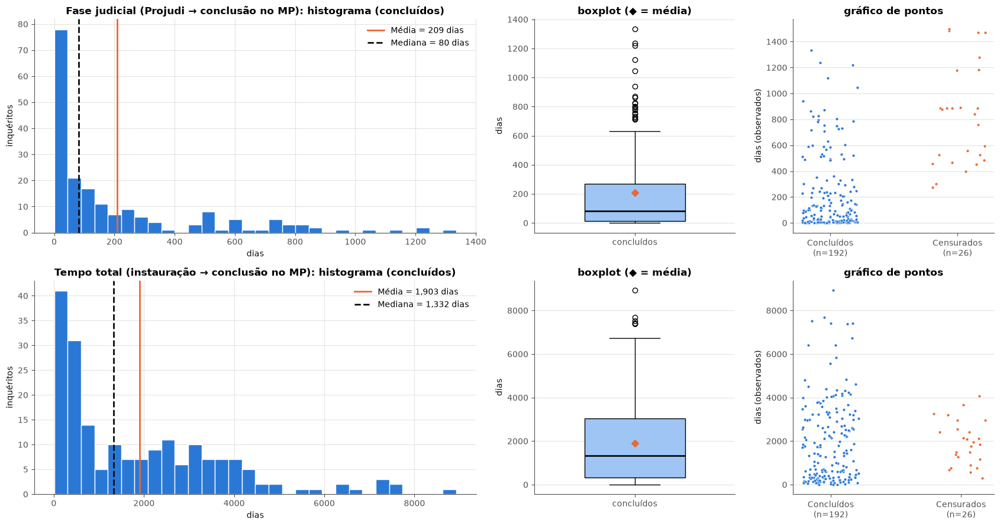

In [96]:
def descrever(serie):
    s = serie.dropna().astype(float)
    q1, q3 = s.quantile([0.25, 0.75])
    return pd.Series({'n': len(s), 'Média': s.mean(), 'Desvio-padrão': s.std(), 'CV (%)': 100 * s.std() / s.mean(),
                      'Mínimo': s.min(), 'Q1': q1, 'Mediana': s.median(), 'Q3': q3, 'Máximo': s.max(), 'IQR': q3 - q1,
                      'Assimetria': stats.skew(s), 'Curtose (excesso)': stats.kurtosis(s), 'Zeros': int((s == 0).sum())})


descricao = pd.DataFrame({rotulo: descrever(concluidos[v]) for v, rotulo in DESFECHOS.items()})
display(descricao.round(2))

fig, axes = plt.subplots(2, 3, figsize=(17, 9), gridspec_kw={'width_ratios': [2.2, 1, 1]})
for linha, (v, rotulo) in enumerate(DESFECHOS.items()):
    valores = concluidos[v].astype(float)
    ax = axes[linha, 0]
    ax.hist(valores, bins=30, color=COR_PRINCIPAL, edgecolor='white')
    ax.axvline(valores.mean(), color=COR_DESTAQUE, linewidth=2, label=f'Média = {valores.mean():,.0f} dias')
    ax.axvline(valores.median(), color=TINTA, linewidth=2, linestyle='--', label=f'Mediana = {valores.median():,.0f} dias')
    ax.set_title(f'{rotulo}: histograma (concluídos)')
    ax.set_xlabel('dias')
    ax.set_ylabel('inquéritos')
    ax.legend()
    ax = axes[linha, 1]
    ax.boxplot(valores, widths=0.5, patch_artist=True, boxprops={'facecolor': COR_SECUNDARIA},
               medianprops={'color': TINTA, 'linewidth': 2}, showmeans=True,
               meanprops={'marker': 'D', 'markerfacecolor': COR_DESTAQUE, 'markeredgecolor': COR_DESTAQUE})
    ax.set_xticks([1], ['concluídos'])
    ax.set_ylabel('dias')
    ax.set_title('boxplot (◆ = média)')
    ax.grid(axis='x', visible=False)
    ax = axes[linha, 2]
    for i, (rotulo_ev, mascara, cor) in enumerate([('Concluídos', evento, COR_PRINCIPAL), ('Censurados', ~evento, COR_DESTAQUE)]):
        y = dados.loc[mascara, v].astype(float)
        ax.scatter(i + RNG.uniform(-0.22, 0.22, len(y)), y, s=12, color=cor, edgecolor='white', linewidth=0.4)
    ax.set_xticks([0, 1], [f'Concluídos\n(n={int(evento.sum())})', f'Censurados\n(n={int((~evento).sum())})'])
    ax.set_ylabel('dias (observados)')
    ax.set_title('gráfico de pontos')
    ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.show()

**Leitura.** As duas durações são fortemente **assimétricas à direita**: há muitos casos curtos e uma cauda longa de casos demorados, e a média fica bem acima da mediana.

| Duração (192 concluídos) | Mediana | Média | Q1–Q3 | Máximo | Assimetria |
|---|---|---|---|---|---|
| Fase judicial | 80,5 dias | 209 dias | 11–269 | 1.335 | 1,74 |
| Tempo total | 1.331,5 dias | 1.903 dias | 331–3.031 | 8.925 | 1,25 |

- **Fase judicial:** tem 8 conclusões no mesmo dia, e um quarto dos casos termina em até 11 dias. É o retrato de dois regimes: o arquivamento imediato e o ciclo de diligências.
- **Censurados:** no gráfico de pontos, os 26 censurados estão entre os tempos mais longos. Descartá-los, como fazem as seções 15 a 19, **encurta** a distribuição, e a seção 20 corrige isso.
- **Média × mediana:** a mediana é a medida de centro adequada.

---

## 16. O Tempo Segue a Distribuição Normal?

Muitos testes clássicos (t de Student, ANOVA, correlação de Pearson, regressão linear com inferência exata) supõem **normalidade**. Antes de escolher os testes, verifica-se essa hipótese com quatro testes, cada um sensível a um aspecto diferente da distância à normal:

| Teste | O que avalia |
|---|---|
| **Shapiro-Wilk** | correlação entre os dados ordenados e os quantis normais; é o mais poderoso em amostras pequenas e médias |
| **D'Agostino-Pearson** | assimetria e curtose combinadas |
| **Anderson-Darling** | distância na FDA, com peso maior nas caudas |
| **Lilliefors** | Kolmogorov-Smirnov com média e variância estimadas na própria amostra |

H₀ em todos: **os dados vêm de uma normal**. Como transformações às vezes "normalizam" dados assimétricos, os testes também são aplicados às versões raiz quadrada, log e Box-Cox. Só a tabela é mostrada para essas versões.

n  Shapiro-Wilk W  p Shapiro  p D'Agostino  Anderson-Darling A²  AD rejeita a 5%  p Lilliefors  Assimetria  Curtose
Desfecho                                    Escala                                                                                                                                   
Fase judicial (Projudi → conclusão no MP)   original (dias)     192          0.7374  3.689e-17     1.036e-15                18.71             True         0.001       1.737    2.442
                                            raiz quadrada       192           0.897   2.97e-10     5.088e-05                 6.38             True         0.001      0.8391  -0.3239
                                            log                 192          0.9517  4.193e-06     0.0005718                2.429             True      0.001697     -0.4822   -0.685
                                            Box-Cox (λ = 0.12)  192          0.9672  0.0001822     7.795e-09                1.512             True       0.02514     -0.0903    -1.03
Tempo total (instauração → conclusão no MP) original (dias)     192          0.8578  2.059e-12     5.114e-10                 7.79             True         0.001       1.254    1.349
                                            raiz quadrada       192          0.9534  6.188e-06     0.0001342                2.934             True         0.001      0.3657  -0.8059
                                            log                 192          0.9376  2.336e-07     0.0001417                 3.49             True         0.001     -0.7858   0.2098
                                            Box-Cox (λ = 0.25)  192          0.9702  0.0004143     1.104e-06                2.192             True         0.001     -0.1175    -0.96

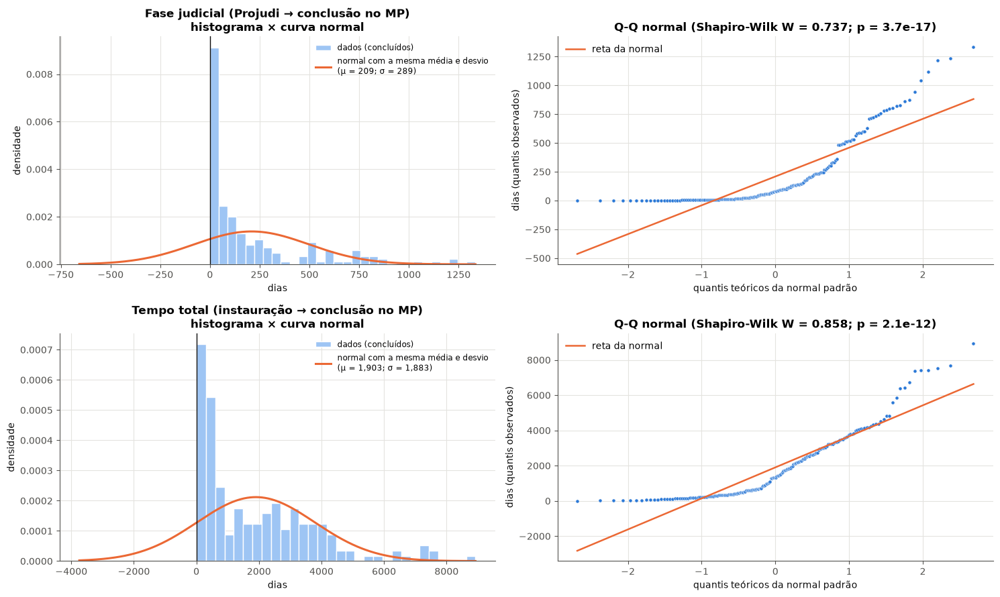

In [97]:
def testes_normalidade(x):
    x = np.asarray(x, dtype=float)
    ad = stats.anderson(x, dist='norm')
    return {'n': len(x), 'Shapiro-Wilk W': stats.shapiro(x).statistic, 'p Shapiro': stats.shapiro(x).pvalue,
            "p D'Agostino": stats.normaltest(x).pvalue, 'Anderson-Darling A²': ad.statistic,
            'AD rejeita a 5%': bool(ad.statistic > ad.critical_values[2]), 'p Lilliefors': lilliefors(x, dist='norm')[1],
            'Assimetria': stats.skew(x), 'Curtose': stats.kurtosis(x)}


normalidade = []
for v, rotulo in DESFECHOS.items():
    x = concluidos[v].astype(float).to_numpy() + 0.5
    boxcox_x, lambda_bc = stats.boxcox(x)
    for nome, valores in {'original (dias)': x, 'raiz quadrada': np.sqrt(x), 'log': np.log(x),
                          f'Box-Cox (λ = {lambda_bc:.2f})': boxcox_x}.items():
        normalidade.append({'Desfecho': rotulo, 'Escala': nome, **testes_normalidade(valores)})
normalidade = pd.DataFrame(normalidade).set_index(['Desfecho', 'Escala'])
with pd.option_context('display.float_format', lambda v: f'{v:.4g}'):
    display(normalidade)

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for linha, (v, rotulo) in enumerate(DESFECHOS.items()):
    x = concluidos[v].astype(float).to_numpy()
    media, dp = x.mean(), x.std(ddof=1)
    ax = axes[linha, 0]
    ax.hist(x, bins=30, density=True, color=COR_SECUNDARIA, edgecolor='white', label='dados (concluídos)')
    grade = np.linspace(min(x.min(), media - 3 * dp), x.max(), 400)
    ax.plot(grade, stats.norm.pdf(grade, media, dp), color=COR_DESTAQUE, linewidth=2.2,
            label=f'normal com a mesma média e desvio\n(μ = {media:,.0f}; σ = {dp:,.0f})')
    ax.axvline(0, color=TINTA, linewidth=1)
    ax.set_title(f'{rotulo}\nhistograma × curva normal')
    ax.set_xlabel('dias')
    ax.set_ylabel('densidade')
    ax.legend(fontsize=8.5)
    ax = axes[linha, 1]
    (osm, osr), (inclinacao, intercepto, _) = stats.probplot(x, dist='norm')
    ax.scatter(osm, osr, s=14, color=COR_PRINCIPAL, edgecolor='white', linewidth=0.4)
    ax.plot(osm, inclinacao * osm + intercepto, color=COR_DESTAQUE, linewidth=1.8, label='reta da normal')
    ax.set_xlabel('quantis teóricos da normal padrão')
    ax.set_ylabel('dias (quantis observados)')
    ax.set_title(f'Q-Q normal (Shapiro-Wilk W = {stats.shapiro(x).statistic:.3f}; p = {stats.shapiro(x).pvalue:.1e})')
    ax.legend()
plt.tight_layout()
plt.show()

**Leitura. O tempo não é normal**, e as transformações usuais não resolvem.

- **Tempo original:** os quatro testes rejeitam a normalidade com folga. Shapiro-Wilk W = 0,737 na fase judicial e 0,858 no tempo total (p < 10⁻¹¹).
- **No gráfico:** a curva normal com a mesma média e o mesmo desvio põe massa em **tempos negativos**, que não existem. Os pontos do Q-Q se afastam da reta nas duas caudas.
- **Transformações:** raiz, log e Box-Cox (λ = 0,12 e 0,25) reduzem a assimetria, mas os testes continuam rejeitando. Na melhor versão, Box-Cox, o Shapiro dá p < 0,001, e o Lilliefors, p = 0,03 e 0,001.

**Consequência para o restante da análise.** Os métodos que supõem normalidade não são adequados: t de Student, ANOVA e correlação de Pearson com inferência. Por isso a análise usa **testes de postos** (Mann-Whitney, Kruskal-Wallis, Dunn, Spearman), que comparam ordens e não médias, e **modelos próprios para durações** (seções 18 a 21).

---

## 17. Testes de Hipóteses: do Mais Simples ao Mais Completo

### 17.1 Variáveis explicativas

As variáveis são agrupadas pelo **momento** em que são conhecidas. Uma variável que só existe depois do início do período medido pode ser tanto causa quanto **consequência** da duração. É o caso de "quantas diligências o MP pediu": um procedimento mais longo tem mais ocasiões de receber pedidos. Esse é o **viés do tempo imortal**, e por isso essas comparações não são lidas como efeito.

| Grupo | Variáveis | Conhecidas em |
|---|---|---|
| Caso e investigação | comarca, delegacia, assunto, artigo, forma de instauração, réu preso, arma de fogo, tentativa, qualificadora, múltiplas vítimas, lei especial, intervenção estatal, tramitação direta, indiciamento | antes da chegada ao Projudi |
| Calendário | ano de recebimento no Projudi, idade do IP na chegada, coorte de instauração | na chegada ao Projudi |
| Processo no MP (não causais) | houve manifestação, tipos de diligência | durante a fase judicial |
| Desfecho e registro (descritivas) | tipo de desfecho, situação, coerência da data de prescrição | no fim |

`Validacao` e `Lei_codigo_penal` são constantes e ficam de fora. `Nome_delegacia` (41 unidades) entra pela versão agrupada `Delegacia_top6`.

In [98]:
VARIAVEIS_CASO = ['Comarca', 'Delegacia_top6', 'Tipo_delegacia', 'Assunto_grupo', 'Artigo_principal', 'Forma_instauracao',
                  'Reu_preso', 'Arma_de_fogo', 'Tentativa', 'Qualificadora_capitulada', 'Multiplas_vitimas',
                  'Concurso_lei_especial', 'Indicio_intervencao_estatal', 'Tramitacao_direta', 'Houve_indiciamento']
VARIAVEIS_CALENDARIO = ['Ano_recebimento_projudi', 'Faixa_tempo_ip', 'Coorte_instauracao']
VARIAVEIS_REGISTRO = ['Desfecho', 'Status_macro', 'Coerencia_prescricao']
VARIAVEIS_PROCESSO = ['Houve_manifestacao_mp', 'Dil_prazo_conclusao', 'Dil_pericias', 'Dil_oitivas', 'Dil_midias_dados',
                      'Dil_documentos', 'Dil_controle_externo']
GRUPO_VARIAVEL = {**{v: 'Caso e investigação' for v in VARIAVEIS_CASO}, **{v: 'Calendário' for v in VARIAVEIS_CALENDARIO},
                  **{v: 'Processo no MP (não causal)' for v in VARIAVEIS_PROCESSO},
                  **{v: 'Desfecho e registro (descritivo)' for v in VARIAVEIS_REGISTRO}}
ROTULO_VARIAVEL = {'Faixa_tempo_ip': 'Idade do IP na chegada (Faixa_tempo_ip)'}
display(pd.DataFrame({'Grupo': GRUPO_VARIAVEL, 'Categorias (n)': {
    v: ' | '.join(f'{k} ({n})' for k, n in serie_exibicao(dados, v).value_counts(sort=False).items()) for v in GRUPO_VARIAVEL}}))


def barras_verticais_empilhadas(ax, tabela, cores, rotulo_largura=12):
    """Barras verticais empilhadas a 100% (linhas da tabela = barras; colunas = segmentos)."""
    pct = 100 * tabela.div(tabela.sum(axis=1), axis=0)
    base = np.zeros(len(pct))
    for coluna in pct.columns:
        ax.bar(range(len(pct)), pct[coluna], bottom=base, color=cores.get(coluna, TINTA_2), label=coluna, width=0.65)
        for i, (b, h, n) in enumerate(zip(base, pct[coluna], tabela[coluna])):
            if h >= 6:
                ax.text(i, b + h / 2, f'{h:.0f}%\n({n})', ha='center', va='center', fontsize=8)
        base += pct[coluna].to_numpy()
    ax.set_xticks(range(len(pct)), [f'{quebrar(g, rotulo_largura)}\n(n={n})' for g, n in tabela.sum(axis=1).items()], fontsize=8)
    ax.set_ylim(0, 100)
    ax.set_ylabel('% do grupo')
    ax.grid(axis='x', visible=False)

,Grupo,Categorias (n)
Comarca,Caso e investigação,Goiânia (101) | Aparecida de Goiânia (44) | Anápolis (34) | Luziânia (18) | Senador Ca...
Delegacia_top6,Caso e investigação,DIH – Goiânia (74) | GIH – Aparecida de Goiânia (30) | GIH – Anápolis (23) | GIH – Luz...
Tipo_delegacia,Caso e investigação,"Especializada em homicídios (DIH/GIH) (153) | Distrital/regional (DDP, DP, DRP) (44) |..."
Assunto_grupo,Caso e investigação,Homicídio simples (172) | Homicídio qualificado (38) | Outros (8)
Artigo_principal,Caso e investigação,Art. 121 (homicídio) (214) | Art. 157 §3º (latrocínio) (2) | Art. 122 (induzimento ao ...
Forma_instauracao,Caso e investigação,Portaria (196) | Auto de prisão em flagrante (APF) (22)
Reu_preso,Caso e investigação,Solto (197) | Preso (21)
Arma_de_fogo,Caso e investigação,Sem arma de fogo (66) | Com arma de fogo (152)
Tentativa,Caso e investigação,Consumado (176) | Tentado (42)
Qualificadora_capitulada,Caso e investigação,Sem qualificadora (196) | Com qualificadora (22)


### 17.2 Uma proporção: teste binomial exato

O teste mais simples verifica se uma **proporção** difere de um valor de referência p₀. Só faz sentido quando p₀ tem significado. Aqui, p₀ = 50% responde à pergunta **"é a maioria?"**.

- O intervalo de **Clopper-Pearson** é exato; o de **Wilson** tem melhor cobertura com proporções extremas.
- Testar a proporção de réus presos contra 50% não faria sentido, porque ninguém supõe que metade dos investigados esteja presa. Para variáveis assim, informa-se só o intervalo. A comparação com a proporção **da população** fica para a Etapa 2 (seção 22).

,k,n,Proporção (%),"IC 2,5% (exato)","IC 97,5% (exato)",IC 95% Wilson,p₀ (%),p-valor (binomial exato),Conclusão (5%)
Tramitação direta é a regra?,142,218,65.14,58.41,71.45,58.6–71.2,50,9.236e-06,maioria
O MP se manifesta na maioria?,135,218,61.93,55.12,68.4,55.3–68.1,50,0.0005226,maioria
A maioria fica sem autor identificado?,141,218,64.68,57.94,71.01,58.1–70.7,50,1.74e-05,maioria
A maioria é com arma de fogo?,152,218,69.72,63.16,75.75,63.3–75.4,50,5.481e-09,maioria
A maioria é arquivada?,181,218,83.03,77.37,87.76,77.5–87.4,50,5.633e-24,maioria


Proporções informadas só com intervalo (não há p₀ com significado na amostra isolada):


,k,n,Proporção (%),"IC 2,5% (exato)","IC 97,5% (exato)",IC 95% Wilson
Réu preso,21,218,9.63,6.06,14.35,6.4–14.3
Auto de prisão em flagrante,22,218,10.09,6.43,14.88,6.8–14.8
Tentativa,42,218,19.27,14.25,25.14,14.6–25.0
Denúncia oferecida,6,218,2.75,1.02,5.89,1.3–5.9
Indício de intervenção estatal,14,218,6.42,3.56,10.54,3.9–10.5


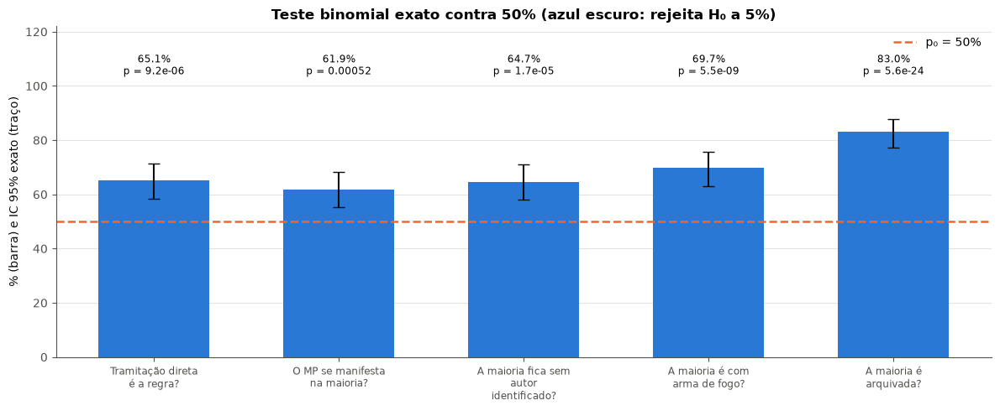

In [99]:
def binomial(k, n, p0=0.5):
    teste = stats.binomtest(int(k), int(n), p0)
    cp = teste.proportion_ci(confidence_level=0.95, method='exact')
    w = proportion_confint(int(k), int(n), method='wilson')
    return {'k': int(k), 'n': int(n), 'Proporção (%)': 100 * k / n, 'IC 2,5% (exato)': 100 * cp.low, 'IC 97,5% (exato)': 100 * cp.high,
            'IC 95% Wilson': f'{100 * w[0]:.1f}–{100 * w[1]:.1f}', 'p₀ (%)': 100 * p0, 'p-valor (binomial exato)': teste.pvalue}


PERGUNTAS_MAIORIA = {
    'Tramitação direta é a regra?': dados['Tramitacao_direta'],
    'O MP se manifesta na maioria?': dados['Houve_manifestacao_mp'],
    'A maioria fica sem autor identificado?': ~dados['Houve_indiciamento'].astype(bool),
    'A maioria é com arma de fogo?': dados['Arma_de_fogo'],
    'A maioria é arquivada?': dados['Status_macro'].eq('Arquivado'),
}
tabela_binomial = pd.DataFrame({q: binomial(s.astype(bool).sum(), s.notna().sum()) for q, s in PERGUNTAS_MAIORIA.items()}).T
tabela_binomial['Conclusão (5%)'] = np.where(tabela_binomial['p-valor (binomial exato)'].astype(float) < 0.05,
                                            np.where(tabela_binomial['Proporção (%)'].astype(float) > 50, 'maioria', 'minoria'),
                                            'não se distingue de 50%')
with pd.option_context('display.float_format', lambda v: f'{v:.4g}'):
    display(tabela_binomial)
print('Proporções informadas só com intervalo (não há p₀ com significado na amostra isolada):')
display(pd.DataFrame({q: binomial(s.astype(bool).sum(), s.notna().sum()) for q, s in {
    'Réu preso': dados['Reu_preso'], 'Auto de prisão em flagrante': dados['Forma_instauracao'].astype(str).str.startswith('Auto'),
    'Tentativa': dados['Tentativa'], 'Denúncia oferecida': dados['Desfecho'].eq('Denúncia oferecida'),
    'Indício de intervenção estatal': dados['Indicio_intervencao_estatal']}.items()}).T
        [['k', 'n', 'Proporção (%)', 'IC 2,5% (exato)', 'IC 97,5% (exato)', 'IC 95% Wilson']].astype(object))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(tabela_binomial))
props = tabela_binomial['Proporção (%)'].astype(float).to_numpy()
inf, sup = tabela_binomial['IC 2,5% (exato)'].astype(float).to_numpy(), tabela_binomial['IC 97,5% (exato)'].astype(float).to_numpy()
pvals = tabela_binomial['p-valor (binomial exato)'].astype(float).to_numpy()
ax.bar(x, props, color=[COR_PRINCIPAL if p < 0.05 else COR_SECUNDARIA for p in pvals], width=0.6)
ax.errorbar(x, props, yerr=[props - inf, sup - props], fmt='none', ecolor=TINTA, capsize=5, linewidth=1.5)
ax.axhline(50, color=COR_DESTAQUE, linestyle='--', linewidth=1.8, label='p₀ = 50%')
for xi, p, pv in zip(x, props, pvals):
    ax.text(xi, 103, f'{p:.1f}%\np = {pv:.2g}', ha='center', va='bottom', fontsize=8.5)
ax.set_xticks(x, [quebrar(q, 18) for q in tabela_binomial.index], fontsize=8.5)
ax.set_ylim(0, 122)
ax.set_ylabel('% (barra) e IC 95% exato (traço)')
ax.set_title('Teste binomial exato contra 50% (azul escuro: rejeita H₀ a 5%)')
ax.legend(loc='upper right')
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.show()

### 17.3 Duas variáveis categóricas: qui-quadrado, Fisher e post-hoc

O próximo passo é testar a **associação** entre duas variáveis categóricas. Aqui, o par é uma característica do caso e o **tipo de desfecho** (arquivamento, denúncia, em curso). O tipo de desfecho resume a fase judicial sem dicotomizar o tempo, o que seria inadequado com censurados.

- **Qui-quadrado de independência:** H₀ diz que as proporções de desfecho são iguais em todos os grupos. A **regra de Cochran** exige frequência esperada ≥ 5 em pelo menos 80% das caselas e nenhuma abaixo de 1.
- **Quando a regra falha:** usa-se o **exato de Fisher** nas tabelas 2×2 e o **qui-quadrado por permutação** nas maiores.
- **Força da associação:** **V de Cramér**. Em tabelas 2×2, a **razão de chances (OR)**.
- **Post-hoc:** os **resíduos ajustados** apontam as caselas que fogem da independência (|r| > 2), e os pares de grupos são comparados por Fisher com ajuste de Holm.

Variável do caso × tipo de desfecho


,χ²,gl,% esperada < 5,Método,p-valor,V de Cramér,p BH
Variável,,,,,,,
Forma_instauracao,50.92,2,33.33,"Qui-quadrado por permutação (10,000)",9.999e-05,0.4833,0.0011
Reu_preso,33.32,2,33.33,"Qui-quadrado por permutação (10,000)",0.0003,0.391,0.00165
Coorte_instauracao,19.49,6,33.33,"Qui-quadrado por permutação (10,000)",0.0033,0.2114,0.011
Houve_indiciamento,11.18,2,33.33,"Qui-quadrado por permutação (10,000)",0.004,0.2264,0.011
Tipo_delegacia,19.92,6,50,"Qui-quadrado por permutação (10,000)",0.008499,0.2142,0.0187
Tramitacao_direta,6.075,2,33.33,"Qui-quadrado por permutação (10,000)",0.05129,0.1669,0.09404
Tentativa,4.156,2,33.33,"Qui-quadrado por permutação (10,000)",0.1135,0.1381,0.1783
Arma_de_fogo,3.872,2,33.33,"Qui-quadrado por permutação (10,000)",0.175,0.1333,0.237
Comarca,13.18,10,55.56,"Qui-quadrado por permutação (10,000)",0.1939,0.1739,0.237


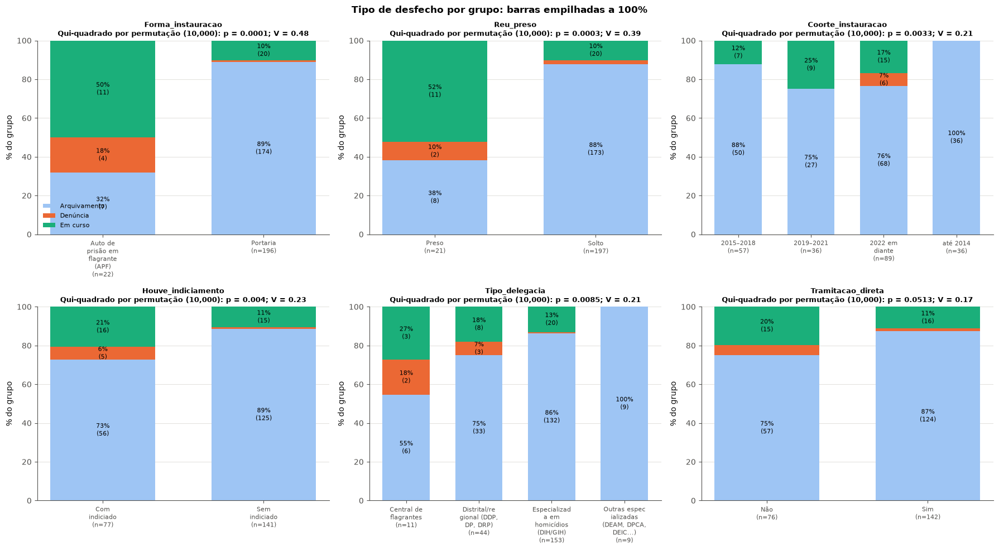


Post-hoc — Forma_instauracao: % na linha e resíduos ajustados (|r| > 2 indica a casela que foge da independência)


% na linha                   Resíduo ajustado                  
Tipo_desfecho                     Arquivamento Denúncia Em curso     Arquivamento Denúncia Em curso
Forma_instauracao                                                                                  
Auto de prisão em flagrante (APF)        31.80    18.20    50.00            -6.75     4.67     5.07
Portaria                                 88.80     1.00    10.20             6.75    -4.67    -5.07


Post-hoc — Reu_preso: % na linha e resíduos ajustados (|r| > 2 indica a casela que foge da independência)


% na linha                   Resíduo ajustado                  
Tipo_desfecho Arquivamento Denúncia Em curso     Arquivamento Denúncia Em curso
Reu_preso                                                                      
Preso                38.10     9.50    52.40            -5.77     2.00     5.27
Solto                87.80     2.00    10.20             5.77    -2.00    -5.27


Post-hoc — Houve_indiciamento: % na linha e resíduos ajustados (|r| > 2 indica a casela que foge da independência)


% na linha                   Resíduo ajustado                  
Tipo_desfecho      Arquivamento Denúncia Em curso     Arquivamento Denúncia Em curso
Houve_indiciamento                                                                  
Com indiciado             72.70     6.50    20.80            -2.99     2.50     2.05
Sem indiciado             88.70     0.70    10.60             2.99    -2.50    -2.05


Post-hoc — Tipo_delegacia: % na linha e resíduos ajustados (|r| > 2 indica a casela que foge da independência)


% na linha                   Resíduo ajustado                  
Tipo_desfecho                               Arquivamento Denúncia Em curso     Arquivamento Denúncia Em curso
Tipo_delegacia                                                                                               
Central de flagrantes                              54.50    18.20    27.30            -2.57     3.20     1.26
Distrital/regional (DDP, DP, DRP)                  75.00     6.80    18.20            -1.57     1.84     0.83
Especializada em homicídios (DIH/GIH)              86.30     0.70    13.10             2.01    -2.93    -0.79
Outras especializadas (DEAM, DPCA, DEIC...)       100.00     0.00     0.00             1.39    -0.52    -1.25


Post-hoc — Coorte_instauracao: % na linha e resíduos ajustados (|r| > 2 indica a casela que foge da independência)


% na linha                   Resíduo ajustado                  
Tipo_desfecho      Arquivamento Denúncia Em curso     Arquivamento Denúncia Em curso
Coorte_instauracao                                                                  
2015–2018                 87.70     0.00    12.30             1.10    -1.48    -0.49
2019–2021                 75.00     0.00    25.00            -1.40    -1.10     2.03
2022 em diante            76.40     6.70    16.90            -2.16     2.99     0.92
até 2014                 100.00     0.00     0.00             2.97    -1.10    -2.67

In [100]:
def teste_associacao(x, y, n_perm=10_000):
    tabela = pd.crosstab(x, y)
    chi2, p_assint, gl, esperada = stats.chi2_contingency(tabela, correction=False)
    pct_baixa = 100 * (esperada < 5).mean()
    if pct_baixa <= 20 and esperada.min() >= 1:
        metodo, p = 'Qui-quadrado (assintótico)', p_assint
    elif tabela.shape == (2, 2):
        metodo, p = 'Exato de Fisher', stats.fisher_exact(tabela)[1]
    else:
        metodo, p = f'Qui-quadrado por permutação ({n_perm:,})', qui_quadrado_permutacao(x, y, n_perm)[1]
    return tabela, {'χ²': chi2, 'gl': gl, '% esperada < 5': pct_baixa, 'Método': metodo, 'p-valor': p, 'V de Cramér': v_de_cramer(tabela)}


def residuos_ajustados(tabela):
    esperada = stats.contingency.expected_freq(tabela)
    n = tabela.values.sum()
    linha, coluna = tabela.sum(axis=1).values[:, None] / n, tabela.sum(axis=0).values[None, :] / n
    return (tabela - esperada) / np.sqrt(esperada * (1 - linha) * (1 - coluna))


dados['Tipo_desfecho'] = pd.Categorical(
    np.select([dados['Desfecho'].eq('Denúncia oferecida'), dados['Status_macro'].eq('Arquivado')], ['Denúncia', 'Arquivamento'],
              'Em curso'), categories=['Arquivamento', 'Denúncia', 'Em curso'])
CORES_DESFECHO = {'Arquivamento': COR_SECUNDARIA, 'Denúncia': COR_DESTAQUE, 'Em curso': CORES[2],
                  'Sem denúncia': COR_SECUNDARIA}
associacoes_desfecho, tabelas_desfecho = [], {}
for v in ['Forma_instauracao', 'Reu_preso', 'Houve_indiciamento', 'Tentativa', 'Arma_de_fogo', 'Assunto_grupo', 'Tramitacao_direta',
          'Comarca', 'Tipo_delegacia', 'Indicio_intervencao_estatal', 'Coorte_instauracao']:
    x = serie_exibicao(dados, v)
    validos = x.notna()
    tabela, resultado = teste_associacao(x[validos].astype(str), dados.loc[validos, 'Tipo_desfecho'])
    tabelas_desfecho[v] = tabela
    associacoes_desfecho.append({'Variável': v, **resultado})
associacoes_desfecho = pd.DataFrame(associacoes_desfecho).set_index('Variável')
associacoes_desfecho['p BH'] = multipletests(associacoes_desfecho['p-valor'], method='fdr_bh')[1]
print('Variável do caso × tipo de desfecho')
with pd.option_context('display.float_format', lambda v: f'{v:.4g}'):
    display(associacoes_desfecho.sort_values('p-valor'))

variaveis_plot = list(associacoes_desfecho.sort_values('p-valor').index[:6])
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, v in zip(axes.flat, variaveis_plot):
    barras_verticais_empilhadas(ax, tabelas_desfecho[v], CORES_DESFECHO)
    r = associacoes_desfecho.loc[v]
    ax.set_title(f'{v}\n{r["Método"]}: p = {r["p-valor"]:.3g}; V = {r["V de Cramér"]:.2f}', fontsize=9.5)
axes.flat[0].legend(fontsize=8, loc='lower left')
plt.suptitle('Tipo de desfecho por grupo: barras empilhadas a 100%', fontweight='bold')
plt.tight_layout()
plt.show()

for v in associacoes_desfecho.index[associacoes_desfecho['p BH'] < 0.05]:
    tabela = tabelas_desfecho[v]
    print(f'\nPost-hoc — {v}: % na linha e resíduos ajustados (|r| > 2 indica a casela que foge da independência)')
    display(pd.concat({'% na linha': (100 * tabela.div(tabela.sum(axis=1), axis=0)).round(1),
                       'Resíduo ajustado': residuos_ajustados(tabela).round(2)}, axis=1))

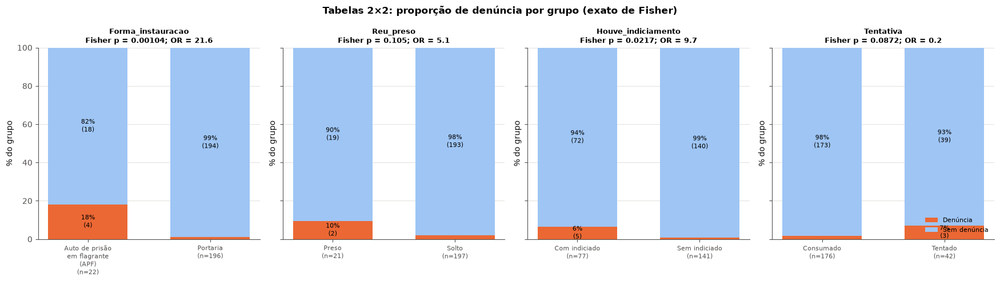

,OR,"IC 2,5%","IC 97,5%",p (Fisher)
Variável,,,,
Forma_instauracao,21.56,2.78,245.5,0.001043
Reu_preso,5.079,0.4273,37.7,0.1048
Houve_indiciamento,9.722,1.049,463,0.02174
Tentativa,0.2254,0.02935,1.763,0.08723


Post-hoc par a par — Tipo_delegacia: proporção "em curso" (Fisher, Holm)


,Grupo A,Grupo B,% Em curso A,% Em curso B,p Fisher,p Holm
0,Especializada em homicídios (DIH/GIH),Central de flagrantes,13.07,27.27,0.19,1.00
4,Central de flagrantes,"Outras especializadas (DEAM, DPCA, DEIC...)",27.27,0.00,0.22,1.00
5,"Distrital/regional (DDP, DP, DRP)","Outras especializadas (DEAM, DPCA, DEIC...)",18.18,0.00,0.32,1.00
1,Especializada em homicídios (DIH/GIH),"Distrital/regional (DDP, DP, DRP)",13.07,18.18,0.46,1.00
2,Especializada em homicídios (DIH/GIH),"Outras especializadas (DEAM, DPCA, DEIC...)",13.07,0.00,0.60,1.00
3,Central de flagrantes,"Distrital/regional (DDP, DP, DRP)",27.27,18.18,0.67,1.00


Post-hoc par a par — Coorte_instauracao: proporção "em curso" (Fisher, Holm)


,Grupo A,Grupo B,% Em curso A,% Em curso B,p Fisher,p Holm
5,2019–2021,até 2014,25.00,0.00,0.00,0.01
4,2022 em diante,até 2014,16.85,0.00,0.01,0.03
2,2015–2018,até 2014,12.28,0.00,0.04,0.16
1,2015–2018,2019–2021,12.28,25.00,0.16,0.48
3,2022 em diante,2019–2021,16.85,25.00,0.32,0.64
0,2015–2018,2022 em diante,12.28,16.85,0.49,0.64


In [101]:
# Tabelas 2×2: denúncia × características do caso (Fisher, razão de chances e barras empilhadas)
PARES_2X2 = ['Forma_instauracao', 'Reu_preso', 'Houve_indiciamento', 'Tentativa']
fig, axes = plt.subplots(1, len(PARES_2X2), figsize=(4.4 * len(PARES_2X2), 5), sharey=True)
resumo_2x2 = []
for ax, v in zip(axes, PARES_2X2):
    grupo = serie_exibicao(dados, v).astype(str)
    alvo = dados['Desfecho'].eq('Denúncia oferecida').map({True: 'Denúncia', False: 'Sem denúncia'})
    tabela = pd.crosstab(grupo, alvo).reindex(columns=['Denúncia', 'Sem denúncia'], fill_value=0)
    razao, p = stats.fisher_exact(tabela.to_numpy())
    ic_or = stats.contingency.odds_ratio(tabela.to_numpy()).confidence_interval()
    barras_verticais_empilhadas(ax, tabela, CORES_DESFECHO, rotulo_largura=14)
    ax.set_title(f'{v}\nFisher p = {p:.3g}; OR = {razao:.1f}', fontsize=9.5)
    resumo_2x2.append({'Variável': v, 'OR': razao, 'IC 2,5%': ic_or.low, 'IC 97,5%': ic_or.high, 'p (Fisher)': p})
axes[-1].legend(loc='lower right', fontsize=8)
plt.suptitle('Tabelas 2×2: proporção de denúncia por grupo (exato de Fisher)', fontweight='bold')
plt.tight_layout()
plt.show()
with pd.option_context('display.float_format', lambda v: f'{v:.4g}'):
    display(pd.DataFrame(resumo_2x2).set_index('Variável'))


def posthoc_pares(x, y, alvo):
    """Post-hoc do qui-quadrado: cada par de grupos comparado por Fisher (alvo × resto), com ajuste de Holm."""
    grupos = list(pd.unique(x.dropna()))
    linhas = []
    for i, a in enumerate(grupos):
        for b in grupos[i + 1:]:
            m = x.isin([a, b])
            tabela = pd.crosstab(x[m], y[m].eq(alvo)).reindex(columns=[True, False], fill_value=0)
            linhas.append({'Grupo A': a, 'Grupo B': b, f'% {alvo} A': 100 * tabela.loc[a, True] / tabela.loc[a].sum(),
                           f'% {alvo} B': 100 * tabela.loc[b, True] / tabela.loc[b].sum(), 'p Fisher': stats.fisher_exact(tabela)[1]})
    pares = pd.DataFrame(linhas)
    pares['p Holm'] = multipletests(pares['p Fisher'], method='holm')[1]
    return pares.sort_values('p Fisher')


for v in [v for v in associacoes_desfecho.index[associacoes_desfecho['p BH'] < 0.05] if tabelas_desfecho[v].shape[0] > 2]:
    x = serie_exibicao(dados, v).astype(str).where(dados[v].notna())
    print(f'Post-hoc par a par — {v}: proporção "em curso" (Fisher, Holm)')
    display(posthoc_pares(x, dados['Tipo_desfecho'].astype(str), 'Em curso').head(8).round(4))

**Leitura.**

*Binomial ("é a maioria?").* As cinco perguntas rejeitam H₀: p = 50%. Em todas, a resposta é **sim, é a maioria**:

| Pergunta | Proporção | IC 95% exato | p |
|---|---|---|---|
| Arquivado | 83,0% | 77–88% | < 10⁻²³ |
| Com arma de fogo | 69,7% | 63–76% | < 10⁻⁸ |
| Com tramitação direta | 65,1% | 58–71% | — |
| Sem autor identificado | 64,7% | — | — |
| Com manifestação do MP | 61,9% | 55–68% | 0,0005 |

A denúncia (2,8%; IC 1,0–5,9%) e o réu preso (9,6%) são raros. Contra qual valor compará-los fica para a Etapa 2 (seção 22.11), que traz a proporção da população.

*Qui-quadrado e Fisher (tipo de desfecho).* Como a regra de Cochran falha em quase todas as tabelas, o p-valor vem da permutação. Cinco associações resistem à correção BH:

- **Forma de instauração** (V = 0,48), a mais forte. Com APF, 18% são denunciados e 50% seguem em curso; com portaria, 89% são arquivados, e os resíduos ajustados chegam a ±6,8;
- **Réu preso** (V = 0,39);
- **Indiciamento** (V = 0,23): com indiciado, 6,5% de denúncia; sem indiciado, 0,7%;
- **Coorte de instauração** (V = 0,21): os IPs de até 2014 estão **todos** arquivados;
- **Tipo de delegacia** (V = 0,21): as centrais de flagrante têm 18% de denúncia.

*Tabelas 2×2 (Fisher).* A chance de denúncia é 22 vezes maior com APF (OR = 21,6; IC 2,8–245; p = 0,001) e 10 vezes maior com indiciado (OR = 9,7; p = 0,02). Para réu preso (p = 0,10) e tentativa (p = 0,09), o teste não tem poder com só 6 denúncias.

*Post-hoc.* Na coorte de instauração, os pares com Fisher–Holm mostram que só a coorte de até 2014 difere: ali não há nenhum caso em curso.

### 17.4 O tempo entre grupos: Mann-Whitney, Kruskal-Wallis e Dunn

Como o tempo **não é normal** (seção 16), a comparação entre grupos usa **testes de postos**, que não supõem distribuição alguma:

- **Dois grupos:** **Mann-Whitney**. H₀: um tempo sorteado de cada grupo tem a mesma chance de ser o maior. Tamanho de efeito: **correlação rank-bisserial** (−1 a 1);
- **Três ou mais grupos:** **Kruskal-Wallis**. Tamanho de efeito: **ε²**, a proporção da variação dos postos atribuída ao grupo;
- **Post-hoc:** quando o Kruskal-Wallis é significativo, o **teste de Dunn** compara os pares com ajuste de Holm. Nos boxplots, grupos **sem letra em comum** diferem;
- **Muitos testes:** os p-valores de cada desfecho são corrigidos por **Benjamini-Hochberg** (controle da taxa de falsas descobertas).

Os testes usam os **concluídos**. A seção 20 refaz as comparações incluindo os censurados.

In [102]:
def comparar_grupos(df, var_q, var_c):
    sub = df[[var_q, var_c]].dropna()
    grupos = {str(k): g[var_q].astype(float).to_numpy() for k, g in sub.groupby(var_c, observed=True)}
    grupos = {k: v for k, v in grupos.items() if len(v) >= 3}
    nomes = list(grupos)
    medianas = ' | '.join(f'{k}: {np.median(v):.0f} (n={len(v)})' for k, v in grupos.items())
    if len(grupos) < 2:
        return None
    if len(grupos) == 2:
        a, b = grupos[nomes[0]], grupos[nomes[1]]
        res = stats.mannwhitneyu(a, b, alternative='two-sided')
        return {'Teste': 'Mann-Whitney', 'Estatística': res.statistic, 'p-valor': res.pvalue,
                'Medida de efeito': f'rank-bisserial ({nomes[0]} vs {nomes[1]})', 'Efeito': 2 * res.statistic / (len(a) * len(b)) - 1,
                'Medianas': medianas}
    res = stats.kruskal(*grupos.values())
    n, k = sum(map(len, grupos.values())), len(grupos)
    return {'Teste': 'Kruskal-Wallis', 'Estatística': res.statistic, 'p-valor': res.pvalue, 'Medida de efeito': 'ε²',
            'Efeito': max((res.statistic - k + 1) / (n - k), 0), 'Medianas': medianas}


linhas = []
for v_desfecho, rotulo in DESFECHOS.items():
    for v in GRUPO_VARIAVEL:
        resultado = comparar_grupos(concluidos.assign(**{v: serie_exibicao(concluidos, v)}), v_desfecho, v)
        if resultado:
            linhas.append({'Desfecho': rotulo, 'Variável': ROTULO_VARIAVEL.get(v, v), 'Grupo': GRUPO_VARIAVEL[v], **resultado})
testes_np = pd.DataFrame(linhas)
testes_np['p BH'] = testes_np.groupby('Desfecho')['p-valor'].transform(lambda p: multipletests(p, method='fdr_bh')[1])
testes_np['Significativo (BH 5%)'] = testes_np['p BH'] < 0.05
with pd.option_context('display.float_format', lambda v: f'{v:.4g}', 'display.max_colwidth', 120):
    for rotulo, tabela in testes_np.groupby('Desfecho', sort=False):
        print(rotulo)
        display(tabela.drop(columns='Desfecho').set_index('Variável').sort_values('p-valor'))

Fase judicial (Projudi → conclusão no MP)


,Grupo,Teste,Estatística,p-valor,Medida de efeito,Efeito,Medianas,p BH,Significativo (BH 5%)
Variável,,,,,,,,,
Houve_manifestacao_mp,Processo no MP (não causal),Mann-Whitney,990.5,3.048e-20,rank-bisserial (Sem manifestação vs Com manifestação),-0.7797,Sem manifestação: 7 (n=81) | Com manifestação: 211 (n=111),7.926e-19,True
Dil_prazo_conclusao,Processo no MP (não causal),Mann-Whitney,750,8.246e-18,rank-bisserial (Não vs Sim),-0.7987,Não: 26 (n=138) | Sim: 511 (n=54),1.072e-16,True
Dil_oitivas,Processo no MP (não causal),Mann-Whitney,953,2.5e-11,rank-bisserial (Não vs Sim),-0.6865,Não: 37 (n=152) | Sim: 484 (n=40),2.167e-10,True
Dil_pericias,Processo no MP (não causal),Mann-Whitney,1442,2.107e-08,rank-bisserial (Não vs Sim),-0.557,Não: 32 (n=148) | Sim: 230 (n=44),1.369e-07,True
Coerencia_prescricao,Desfecho e registro (descritivo),Kruskal-Wallis,34.72,5.311e-07,ε²,0.1643,20 anos contados do fato: 134 (n=86) | 20 anos contados da instauração: 61 (n=3) | Menos de 20 anos: 167 (n=6) | Mai...,2.762e-06,True
Dil_documentos,Processo no MP (não causal),Mann-Whitney,984.5,0.0007434,rank-bisserial (Não vs Sim),-0.4517,Não: 65 (n=171) | Sim: 244 (n=21),0.002836,True
Comarca,Caso e investigação,Kruskal-Wallis,20.85,0.0008655,ε²,0.0852,Goiânia: 95 (n=87) | Aparecida de Goiânia: 12 (n=39) | Anápolis: 129 (n=33) | Luziânia: 14 (n=14) | Senador Canedo: ...,0.002836,True
Dil_midias_dados,Processo no MP (não causal),Mann-Whitney,759,0.0008727,rank-bisserial (Não vs Sim),-0.4897,Não: 61 (n=175) | Sim: 302 (n=17),0.002836,True
Dil_controle_externo,Processo no MP (não causal),Mann-Whitney,515.5,0.002475,rank-bisserial (Não vs Sim),-0.5227,Não: 69 (n=180) | Sim: 418 (n=12),0.007149,True


Tempo total (instauração → conclusão no MP)


,Grupo,Teste,Estatística,p-valor,Medida de efeito,Efeito,Medianas,p BH,Significativo (BH 5%)
Variável,,,,,,,,,
Coorte_instauracao,Calendário,Kruskal-Wallis,160.1,1.705e-34,ε²,0.8359,até 2014: 4285 (n=36) | 2015–2018: 2551 (n=51) | 2019–2021: 1274 (n=27) | 2022 em diante: 312 (n=78),4.433e-33,True
Idade do IP na chegada (Faixa_tempo_ip),Calendário,Kruskal-Wallis,166.2,4.777e-34,ε²,0.8665,até 30 dias: 106 (n=23) | 31 a 90 dias: 234 (n=14) | 91 dias a 1 ano: 325 (n=35) | 1 a 3 anos: 690 (n=22) | 3 a 5 an...,6.211e-33,True
Forma_instauracao,Caso e investigação,Mann-Whitney,2435,1.411e-06,rank-bisserial (Portaria vs Auto de prisão em flagrante (APF)),0.7294,Portaria: 1657 (n=176) | Auto de prisão em flagrante (APF): 162 (n=16),1.223e-05,True
Arma_de_fogo,Caso e investigação,Mann-Whitney,2318,4.21e-06,rank-bisserial (Sem arma de fogo vs Com arma de fogo),-0.4148,Sem arma de fogo: 420 (n=60) | Com arma de fogo: 1952 (n=132),2.259e-05,True
Houve_indiciamento,Caso e investigação,Mann-Whitney,5802,4.344e-06,rank-bisserial (Sem indiciado vs Com indiciado),0.4057,Sem indiciado: 2117 (n=127) | Com indiciado: 375 (n=65),2.259e-05,True
Reu_preso,Caso e investigação,Mann-Whitney,2070,3.941e-05,rank-bisserial (Solto vs Preso),0.6609,Solto: 1552 (n=178) | Preso: 162 (n=14),0.0001708,True
Delegacia_top6,Caso e investigação,Kruskal-Wallis,27.11,0.0001383,ε²,0.1147,DIH – Goiânia: 2069 (n=63) | GIH – Aparecida de Goiânia: 484 (n=27) | GIH – Anápolis: 3583 (n=23) | GIH – Luziânia: ...,0.0005137,True
Tipo_delegacia,Caso e investigação,Kruskal-Wallis,19.68,0.0001975,ε²,0.08921,"Especializada em homicídios (DIH/GIH): 1332 (n=135) | Distrital/regional (DDP, DP, DRP): 3235 (n=38) | Central de fl...",0.0006418,True
Desfecho,Desfecho e registro (descritivo),Kruskal-Wallis,25.52,0.001267,ε²,0.09735,Em investigação: 460 (n=6) | Denúncia oferecida: 203 (n=6) | Arquivado: falta de justa causa: 1488 (n=90) | Arquivad...,0.003555,True


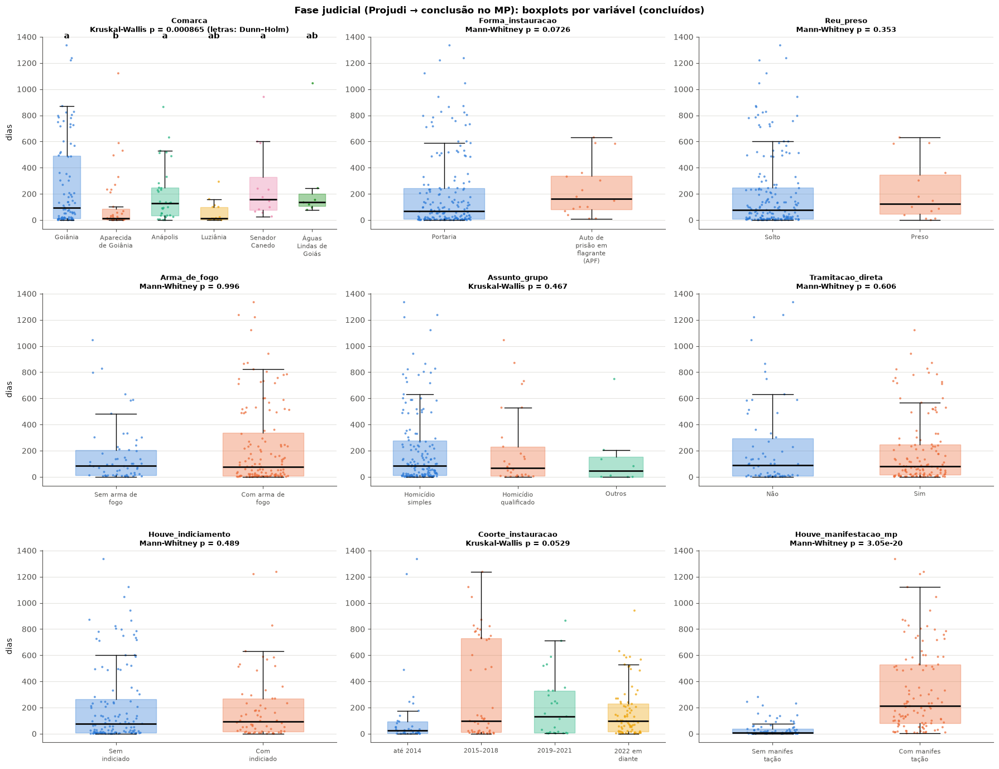

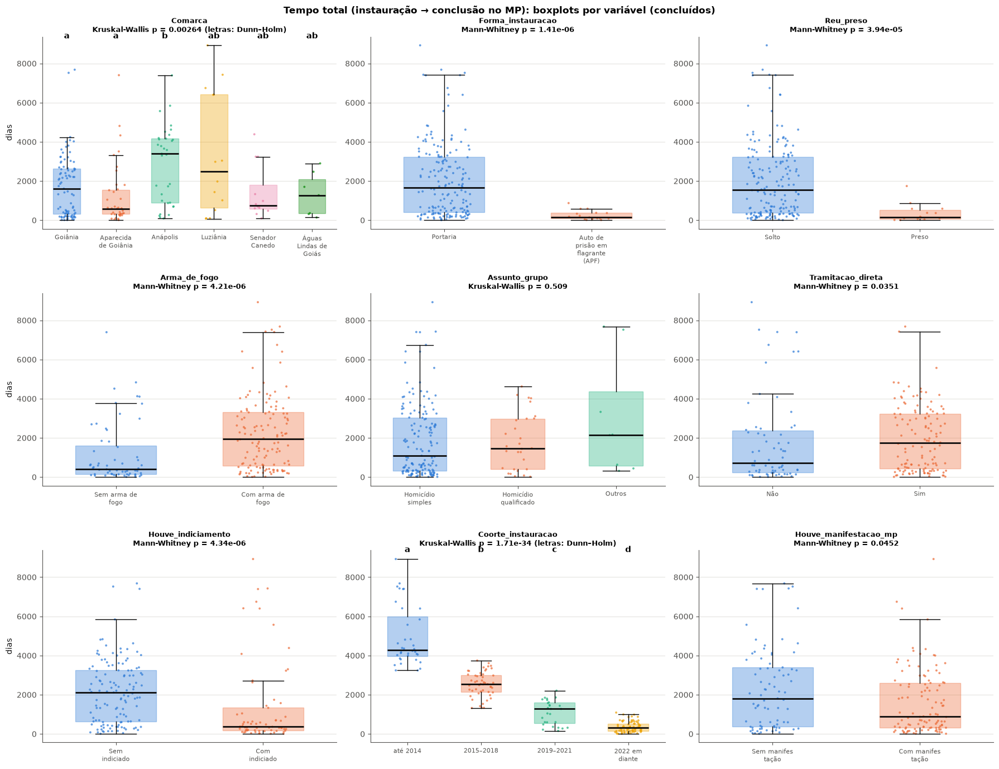

In [103]:
def letras_compactas(grupos, p_matriz, alfa=0.05):
    """Letras do post-hoc: grupos que compartilham uma letra não diferem (p ajustado ≥ alfa)."""
    conjuntos = []
    for g in grupos:
        colocado = False
        for conj in conjuntos:
            if all(p_matriz.loc[g, h] >= alfa for h in conj):
                conj.append(g)
                colocado = True
        if not colocado:
            conjuntos.append([g])
    return {g: ''.join('abcdefghij'[i] for i, conj in enumerate(conjuntos) if g in conj) for g in grupos}


def boxplot_grupos(ax, df, v_desfecho, v, titulo=None):
    sub = df[[v_desfecho]].assign(G=serie_exibicao(df, v).astype(object)).dropna()
    sub[v_desfecho] = sub[v_desfecho].astype(float)
    ordem = serie_exibicao(df, v).cat.categories if isinstance(serie_exibicao(df, v).dtype, pd.CategoricalDtype) else sorted(sub['G'].unique())
    grupos = [str(g) for g in ordem if (sub['G'].astype(str) == str(g)).sum() >= 3]
    sub['G'] = sub['G'].astype(str)
    valores = [sub.loc[sub['G'] == g, v_desfecho].to_numpy() for g in grupos]
    caixa = ax.boxplot(valores, patch_artist=True, showfliers=False, widths=0.55, medianprops={'color': TINTA, 'linewidth': 2})
    for patch, cor in zip(caixa['boxes'], CORES * 2):
        patch.set(facecolor=cor, alpha=0.35, edgecolor=cor)
    for i, (vals, cor) in enumerate(zip(valores, CORES * 2), start=1):
        ax.scatter(i + RNG.uniform(-0.18, 0.18, len(vals)), vals, s=8, color=cor, alpha=0.7, edgecolor='none')
    if len(grupos) == 2:
        p = stats.mannwhitneyu(*valores).pvalue
        nome_teste = 'Mann-Whitney'
    else:
        p = stats.kruskal(*valores).pvalue
        nome_teste = 'Kruskal-Wallis'
        if p < 0.05:
            dunn = sp.posthoc_dunn(sub[sub['G'].isin(grupos)], val_col=v_desfecho, group_col='G', p_adjust='holm').loc[grupos, grupos]
            letras = letras_compactas(grupos, dunn)
            topo = max(np.max(vv) for vv in valores)
            for i, g in enumerate(grupos, start=1):
                ax.text(i, topo * 1.04, letras[g], ha='center', fontsize=11, fontweight='bold')
    ax.set_xticks(range(1, len(grupos) + 1), [quebrar(g, 11) for g in grupos], fontsize=8)
    ax.set_title(f'{titulo or v}\n{nome_teste} p = {p:.3g}' + (' (letras: Dunn–Holm)' if nome_teste == 'Kruskal-Wallis' and p < 0.05 else ''),
                 fontsize=9.5)
    ax.grid(axis='x', visible=False)


VARIAVEIS_BOXPLOT = ['Comarca', 'Forma_instauracao', 'Reu_preso', 'Arma_de_fogo', 'Assunto_grupo', 'Tramitacao_direta',
                     'Houve_indiciamento', 'Coorte_instauracao', 'Houve_manifestacao_mp']
for v_desfecho, rotulo in DESFECHOS.items():
    fig, axes = plt.subplots(3, 3, figsize=(18, 14))
    for ax, v in zip(axes.flat, VARIAVEIS_BOXPLOT):
        boxplot_grupos(ax, concluidos, v_desfecho, v)
    for ax in axes[:, 0]:
        ax.set_ylabel('dias')
    plt.suptitle(f'{rotulo}: boxplots por variável (concluídos)', fontweight='bold')
    plt.tight_layout()
    plt.show()

In [104]:
# Post-hoc de Dunn em tabela: todas as variáveis com 3+ grupos significativas após BH
multigrupo = testes_np[(testes_np['Teste'] == 'Kruskal-Wallis') & testes_np['Significativo (BH 5%)']]
mapa_rotulo = {ROTULO_VARIAVEL.get(v, v): v for v in GRUPO_VARIAVEL}
for _, linha in multigrupo.iterrows():
    v = mapa_rotulo[linha['Variável']]
    v_desfecho = {r: k for k, r in DESFECHOS.items()}[linha['Desfecho']]
    sub = concluidos.assign(G=serie_exibicao(concluidos, v).astype(str))[[v_desfecho, 'G']].dropna()
    sub[v_desfecho] = sub[v_desfecho].astype(float)
    dunn = sp.posthoc_dunn(sub, val_col=v_desfecho, group_col='G', p_adjust='holm')
    pares = dunn.where(np.triu(np.ones(dunn.shape, dtype=bool), k=1)).stack().rename('p Holm').reset_index()
    pares.columns = ['Grupo A', 'Grupo B', 'p Holm']
    medianas = sub.groupby('G')[v_desfecho].median()
    pares['Mediana A'], pares['Mediana B'] = pares['Grupo A'].map(medianas), pares['Grupo B'].map(medianas)
    print(f'Dunn–Holm — {linha["Variável"]} ({linha["Desfecho"]}): pares com p < 0,05')
    display(pares[pares['p Holm'] < 0.05].sort_values('p Holm').round(4))

Dunn–Holm — Comarca (Fase judicial (Projudi → conclusão no MP)): pares com p < 0,05


,Grupo A,Grupo B,p Holm,Mediana A,Mediana B
8,Aparecida de Goiânia,Goiânia,0.03,12.00,95.00
10,Aparecida de Goiânia,Senador Canedo,0.03,12.00,160.00
1,Anápolis,Aparecida de Goiânia,0.05,129.00,12.00


Dunn–Holm — Desfecho (Fase judicial (Projudi → conclusão no MP)): pares com p < 0,05


,Grupo A,Grupo B,p Holm,Mediana A,Mediana B


Dunn–Holm — Coerencia_prescricao (Fase judicial (Projudi → conclusão no MP)): pares com p < 0,05


...

,Grupo A,Grupo B,p Holm,Mediana A,Mediana B
29,até 30 dias,mais de 5 anos,0.00,106.00,"3,421.00"
23,91 dias a 1 ano,mais de 5 anos,0.00,325.00,"3,421.00"
17,31 a 90 dias,mais de 5 anos,0.00,233.50,"3,421.00"
5,1 a 3 anos,mais de 5 anos,0.00,689.50,"3,421.00"
10,3 a 5 anos,até 30 dias,0.00,"1,722.50",106.00
8,3 a 5 anos,31 a 90 dias,0.00,"1,722.50",233.50
9,3 a 5 anos,91 dias a 1 ano,0.00,"1,722.50",325.00
11,3 a 5 anos,mais de 5 anos,0.00,"1,722.50","3,421.00"
4,1 a 3 anos,até 30 dias,0.01,689.50,106.00


Dunn–Holm — Coorte_instauracao (Tempo total (instauração → conclusão no MP)): pares com p < 0,05


,Grupo A,Grupo B,p Holm,Mediana A,Mediana B
11,2022 em diante,até 2014,0.00,312.50,"4,285.00"
2,2015–2018,2022 em diante,0.00,"2,551.00",312.50
7,2019–2021,até 2014,0.00,"1,274.00","4,285.00"
1,2015–2018,2019–2021,0.00,"2,551.00","1,274.00"
3,2015–2018,até 2014,0.00,"2,551.00","4,285.00"
6,2019–2021,2022 em diante,0.00,"1,274.00",312.50


Dunn–Holm — Desfecho (Tempo total (instauração → conclusão no MP)): pares com p < 0,05


,Grupo A,Grupo B,p Holm,Mediana A,Mediana B
30,Arquivado: extinção da punibilidade,Denúncia oferecida,0.02,"4,050.00",203.00
19,Arquivado: autoria desconhecida,Denúncia oferecida,0.04,"2,795.50",203.00


**Leitura.**

*Fase judicial (concluídos).* Entre as variáveis do caso, só duas resistem à correção BH:

- **Comarca** (Kruskal-Wallis p < 0,001; ε² = 0,085). No post-hoc de Dunn–Holm, **Aparecida de Goiânia** (mediana de 12 dias) difere de Goiânia (95), de Senador Canedo (160) e, no limite, de Anápolis (129);
- **Indício de intervenção estatal** (Mann-Whitney p = 0,01): 250 × 69 dias; rank-bisserial = −0,44.

Forma de instauração, réu preso, arma de fogo, tentativa, qualificadora e indiciamento **não** diferem. As variáveis do processo no MP separam os grupos com enorme força: sem manifestação do MP, a mediana é de 7 dias; com manifestação, de 211 dias (rank-bisserial = −0,78). Mas isso descreve como os procedimentos terminam, e não é efeito.

*Tempo total (concluídos).* Os maiores efeitos são de **calendário**: coorte de instauração ε² = 0,84 e idade do IP na chegada ε² = 0,87. Pelo Dunn, todas as coortes diferem entre si, com medianas de 4.285 dias (até 2014) a 312 dias (2022 em diante). Os demais efeitos (APF, arma, indiciamento, réu preso, delegacia, comarca) **carregam essa idade**, como mostra a seção 21. Anápolis só difere de Aparecida e de Goiânia porque o seu estoque migrado era mais antigo.

### 17.5 Duas variáveis quantitativas: correlação de Spearman

O **ρ de Spearman** é a correlação entre os **postos**. Ele mede relações **monotônicas** (sempre crescentes ou sempre decrescentes), não exige normalidade e é robusto a valores extremos. Por isso substitui o r de Pearson aqui. O gráfico mostra a dispersão com uma linha de tendência **LOWESS** (regressão local), que não impõe forma alguma. O intervalo de ρ vem de 1.000 reamostragens bootstrap.

ρ de Spearman                                                                                  p BH  \
Desfecho                                         Fase judicial (Projudi → conclusão no MP) Tempo total (instauração → conclusão no MP) Fase judicial (Projudi → conclusão no MP)   
Variável                   Tipo                                                                                                                                                    
Ano_instauracao            Caso/calendário                                            0.14                                       -0.93                                      0.08   
Idade_entrada_anos         Caso/calendário                                           -0.15                                        0.96                                      0.08   
N_indiciados               Caso/calendário                                            0.05                                       -0.35                                      0.48   
N_itens_diligencia         Processo (não causal)                                      0.74                                       -0.10                                      0.00   
N_vitimas                  Caso/calendário                                            0.07                                        0.02                                      0.43   
Quantidade_manifestacao_mp Processo (não causal)                                      0.77                                       -0.05                                      0.00   
Tempo_fato_instauracao     Caso/calendário                                           -0.07                                       -0.05                                      0.43   

                                                                                              
Desfecho                                         Tempo total (instauração → conclusão no MP)  
Variável                   Tipo                                                               
Ano_instauracao            Caso/calendário                                              0.00  
Idade_entrada_anos         Caso/calendário                                              0.00  
N_indiciados               Caso/calendário                                              0.00  
N_itens_diligencia         Processo (não causal)                                        0.27  
N_vitimas                  Caso/calendário                                              0.76  
Quantidade_manifestacao_mp Processo (não causal)                                        0.61  
Tempo_fato_instauracao     Caso/calendário                                              0.61

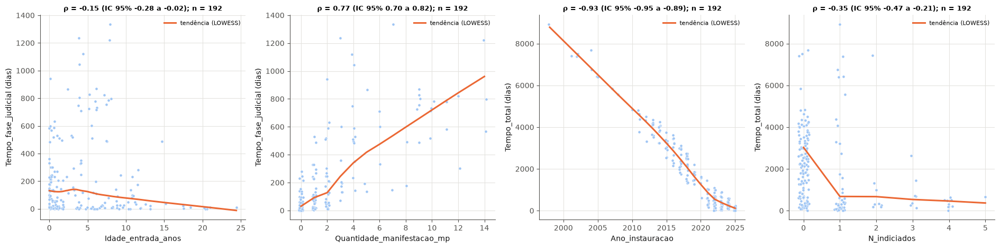

In [105]:
QUANTITATIVAS = ['Idade_entrada_anos', 'Ano_instauracao', 'Tempo_fato_instauracao', 'N_vitimas', 'N_indiciados',
                 'Quantidade_manifestacao_mp', 'N_itens_diligencia']
correl = []
for v_desfecho, rotulo in DESFECHOS.items():
    for v in QUANTITATIVAS:
        par = concluidos[[v_desfecho, v]].astype(float).dropna()
        r = stats.spearmanr(par[v], par[v_desfecho])
        correl.append({'Desfecho': rotulo, 'Variável': v, 'n': len(par), 'ρ de Spearman': r.statistic, 'p-valor': r.pvalue,
                       'Tipo': 'Processo (não causal)' if v in ('Quantidade_manifestacao_mp', 'N_itens_diligencia') else 'Caso/calendário'})
correl = pd.DataFrame(correl)
correl['p BH'] = correl.groupby('Desfecho')['p-valor'].transform(lambda p: multipletests(p, method='fdr_bh')[1])
display(correl.pivot(index=['Variável', 'Tipo'], columns='Desfecho', values=['ρ de Spearman', 'p BH']).round(4))

PARES_SPEARMAN = [('Idade_entrada_anos', 'Tempo_fase_judicial'), ('Quantidade_manifestacao_mp', 'Tempo_fase_judicial'),
                  ('Ano_instauracao', 'Tempo_total'), ('N_indiciados', 'Tempo_total')]
fig, axes = plt.subplots(1, 4, figsize=(19, 4.8))
for ax, (vx, vy) in zip(axes, PARES_SPEARMAN):
    par = concluidos[[vx, vy]].astype(float).dropna()
    rho = stats.spearmanr(par[vx], par[vy]).statistic
    boot = [stats.spearmanr(*par.iloc[RNG.integers(0, len(par), len(par))].T.to_numpy()).statistic for _ in range(1000)]
    ic = np.nanpercentile(boot, [2.5, 97.5])
    ax.scatter(par[vx] + RNG.uniform(-0.15, 0.15, len(par)) * (par[vx].nunique() < 25), par[vy], s=14,
               color=COR_SECUNDARIA, edgecolor='white', linewidth=0.4)
    suave = lowess(par[vy], par[vx], frac=0.6)
    ax.plot(suave[:, 0], suave[:, 1], color=COR_DESTAQUE, linewidth=2.2, label='tendência (LOWESS)')
    ax.set_xlabel(vx)
    ax.set_ylabel(f'{vy} (dias)')
    ax.set_title(f'ρ = {rho:.2f} (IC 95% {ic[0]:.2f} a {ic[1]:.2f}); n = {len(par)}', fontsize=9.5)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Leitura.**

- **Tempo total:** é quase uma função do calendário. Ano de instauração ρ = −0,93; idade na chegada ρ = 0,96. Inquéritos mais antigos têm, por construção, tempo total maior. O ρ = −0,35 com o número de indiciados reflete o mesmo confundimento: os IPs recentes têm mais autor identificado.
- **Fase judicial:** o tempo cresce com o número de manifestações do MP (ρ = 0,77) e de itens de diligência (ρ = 0,74), relações monotônicas fortes. São variáveis do processo, e a causalidade é circular: cada pedido devolve o IP à polícia, e um IP mais longo recebe mais pedidos.
- **Idade na chegada × fase judicial:** a correlação é fraca e negativa (ρ = −0,15; p BH = 0,08). Os IPs que chegam mais velhos tendem a encerrar mais depressa, o que o Cox confirma na seção 20.

---

## 18. Que Distribuição Descreve o Tempo?

O tempo não é normal, mas pode seguir outra distribuição conhecida. Para durações positivas e assimétricas, as candidatas são as famílias clássicas de tempo de vida. A **gama generalizada** contém quase todas como casos particulares. No `scipy`, ela tem dois parâmetros de forma, *a* e *c*:

| Família | Restrição na gama generalizada | Parâmetros (com escala) |
|---|---|---|
| Exponencial | a = 1 e c = 1 | 1 |
| Weibull | a = 1 | 2 |
| Gama | c = 1 | 2 |
| Lognormal | limite a → ∞ | 2 |
| Log-logística | não está aninhada | 2 |
| **Gama generalizada** | livre | 3 |

**Procedimento:**

1. ajuste por **máxima verossimilhança** aos concluídos (dias + 0,5, porque as famílias exigem valores positivos);
2. comparação por **AIC e BIC**. O BIC penaliza mais os parâmetros extras;
3. **teste da razão de verossimilhança** (LR) para as famílias aninhadas na gama generalizada: o terceiro parâmetro "se paga"?
4. **aderência:** o KS e o Cramér-von Mises tabelados não valem quando os parâmetros são estimados na própria amostra. O valor-p vem de um **bootstrap paramétrico** com 200 réplicas: simula-se do modelo ajustado, reajusta-se e compara-se a distância;
5. **gráficos:** a **FDA empírica** contra a **FDA teórica** da distribuição escolhida, com os parâmetros estimados, além do histograma com a densidade ajustada.

In [106]:
FAMILIAS_SCIPY = {
    'Exponencial': (stats.expon, 1), 'Weibull': (stats.weibull_min, 2), 'Gama': (stats.gamma, 2),
    'Lognormal': (stats.lognorm, 2), 'Log-logística': (stats.fisk, 2), 'Gama generalizada': (stats.gengamma, 3),
}


def ajustar_scipy(x):
    ajustes, linhas = {}, []
    for nome, (dist, k) in FAMILIAS_SCIPY.items():
        params = dist.fit(x, floc=0)
        if nome == 'Gama generalizada':
            # vários pontos de partida (gama e Weibull ajustadas): a verossimilhança da gama generalizada é irregular
            k_g = stats.gamma.fit(x, floc=0)[0]
            c_w = stats.weibull_min.fit(x, floc=0)[0]
            candidatos = [params] + [dist.fit(x, a0, c0, floc=0) for a0, c0 in [(k_g, 1.0), (1.0, c_w), (5.0, 0.3)]]
            params = max(candidatos, key=lambda p: dist.logpdf(x, *p).sum())
        ll = dist.logpdf(x, *params).sum()
        ajustes[nome] = (dist, params)
        forma = ', '.join(f'{v:.3g}' for v in params[:-2])
        linhas.append({'Família': nome, 'Parâmetros livres': k, 'log-verossimilhança': ll, 'AIC': 2 * k - 2 * ll,
                       'BIC': k * np.log(len(x)) - 2 * ll, 'Forma': forma or '—', 'Escala': params[-1],
                       'Mediana teórica (dias)': dist.median(*params)})
    tabela = pd.DataFrame(linhas).set_index('Família').sort_values('AIC')
    tabela['ΔAIC'], tabela['ΔBIC'] = tabela['AIC'] - tabela['AIC'].min(), tabela['BIC'] - tabela['BIC'].min()
    return ajustes, tabela


def razao_verossimilhanca_scipy(tabela):
    ll = tabela['log-verossimilhança']
    testes = []
    for restrito, gl, hipotese in [('Weibull', 1, 'a = 1'), ('Gama', 1, 'c = 1'), ('Exponencial', 2, 'a = c = 1')]:
        lr = 2 * (ll['Gama generalizada'] - ll[restrito])
        testes.append({'H₀ (modelo restrito)': f'{restrito} ({hipotese})', 'LR': lr, 'gl': gl, 'p-valor': stats.chi2.sf(max(lr, 0), gl)})
    lr = 2 * (ll['Weibull'] - ll['Exponencial'])
    testes.append({'H₀ (modelo restrito)': 'Exponencial dentro da Weibull', 'LR': lr, 'gl': 1, 'p-valor': stats.chi2.sf(max(lr, 0), 1)})
    return pd.DataFrame(testes).set_index('H₀ (modelo restrito)')


def aderencia_bootstrap(x, nome, n_boot=200):
    dist, params = FAMILIAS_SCIPY[nome][0], FAMILIAS_SCIPY[nome][0].fit(x, floc=0)
    ks_obs = stats.kstest(x, dist.cdf, args=params).statistic
    cvm_obs = stats.cramervonmises(x, dist.cdf, args=params).statistic
    ks_sim, cvm_sim = [], []
    for _ in range(n_boot):
        xs = dist.rvs(*params, size=len(x), random_state=RNG)
        ps = dist.fit(xs, floc=0)
        ks_sim.append(stats.kstest(xs, dist.cdf, args=ps).statistic)
        cvm_sim.append(stats.cramervonmises(xs, dist.cdf, args=ps).statistic)
    return {'KS (D)': ks_obs, 'p KS (bootstrap)': (1 + np.sum(np.array(ks_sim) >= ks_obs)) / (n_boot + 1),
            'Cramér-von Mises (W²)': cvm_obs, 'p CvM (bootstrap)': (1 + np.sum(np.array(cvm_sim) >= cvm_obs)) / (n_boot + 1)}


ajustes_conc, tabelas_conc, aderencias_conc = {}, {}, {}
for v, rotulo in DESFECHOS.items():
    x = concluidos[v].astype(float).to_numpy() + 0.5
    ajustes_conc[v], tabelas_conc[v] = ajustar_scipy(x)
    print(rotulo)
    display(tabelas_conc[v].round(3))
    with pd.option_context('display.float_format', lambda v: f'{v:.4g}'):
        display(razao_verossimilhanca_scipy(tabelas_conc[v]))
    candidatas = list(tabelas_conc[v].index[:3])
    aderencias_conc[v] = pd.DataFrame({n: aderencia_bootstrap(x, n) for n in candidatas}).T
    print('Aderência das três melhores por AIC (bootstrap paramétrico, 200 réplicas):')
    with pd.option_context('display.float_format', lambda v: f'{v:.4g}'):
        display(aderencias_conc[v])

Fase judicial (Projudi → conclusão no MP)


,Parâmetros livres,log-verossimilhança,AIC,BIC,Forma,Escala,Mediana teórica (dias),ΔAIC,ΔBIC
Família,,,,,,,,,
Weibull,2,"-1,166.03","2,336.07","2,342.58",0.592,141.05,75.97,0.00,0.00
Gama,2,"-1,166.19","2,336.38","2,342.90",0.467,449.13,89.42,0.32,0.32
Gama generalizada,3,"-1,165.93","2,337.85","2,347.62","0.738, 0.723",248.51,80.42,1.79,5.04
Lognormal,2,"-1,173.98","2,351.96","2,358.47",2.07,52.91,52.91,15.89,15.89
Log-logística,2,"-1,179.43","2,362.86","2,369.37",0.819,60.33,60.33,26.79,26.79
Exponencial,1,"-1,218.22","2,438.45","2,441.71",—,209.54,145.24,102.39,99.13


,LR,gl,p-valor
H₀ (modelo restrito),,,
Weibull (a = 1),0.2134,1,0.6441
Gama (c = 1),0.5309,1,0.4662
Exponencial (a = c = 1),104.6,2,1.935e-23
Exponencial dentro da Weibull,104.4,1,1.665e-24


Aderência das três melhores por AIC (bootstrap paramétrico, 200 réplicas):


,KS (D),p KS (bootstrap),Cramér-von Mises (W²),p CvM (bootstrap)
Weibull,0.0723,0.00995,0.1908,0.004975
Gama,0.07507,0.0398,0.2275,0.0199
Gama generalizada,0.07222,0.01493,0.1892,0.00995


Tempo total (instauração → conclusão no MP)


,Parâmetros livres,log-verossimilhança,AIC,BIC,Forma,Escala,Mediana teórica (dias),ΔAIC,ΔBIC
Família,,,,,,,,,
Gama generalizada,3,"-1,638.27","3,282.53","3,292.30","0.384, 1.76","4,321.73","1,366.45",0.00,3.31
Gama,2,"-1,639.61","3,283.22","3,289.73",0.833,"2,286.04","1,216.94",0.69,0.74
Weibull,2,"-1,640.15","3,284.30","3,290.81",0.9,"1,813.52","1,206.71",1.77,1.82
Exponencial,1,"-1,641.87","3,285.74","3,289.00",—,"1,903.41","1,319.34",3.21,0.00
Lognormal,2,"-1,655.48","3,314.97","3,321.48",1.43,936.65,936.65,32.44,32.49
Log-logística,2,"-1,657.51","3,319.03","3,325.54",1.21,"1,054.50","1,054.50",36.50,36.55


,LR,gl,p-valor
H₀ (modelo restrito),,,
Weibull (a = 1),3.768,1,0.05223
Gama (c = 1),2.69,1,0.101
Exponencial (a = c = 1),7.21,2,0.02719
Exponencial dentro da Weibull,3.441,1,0.0636


Aderência das três melhores por AIC (bootstrap paramétrico, 200 réplicas):


,KS (D),p KS (bootstrap),Cramér-von Mises (W²),p CvM (bootstrap)
Gama generalizada,0.08458,0.004975,0.391,0.004975
Gama,0.08048,0.00995,0.3443,0.00995
Weibull,0.08428,0.00995,0.384,0.004975


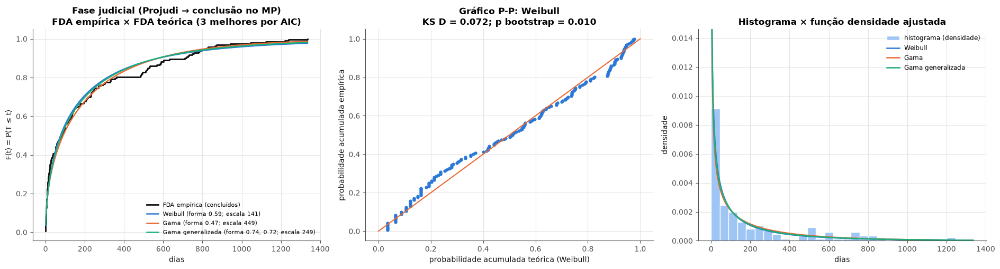

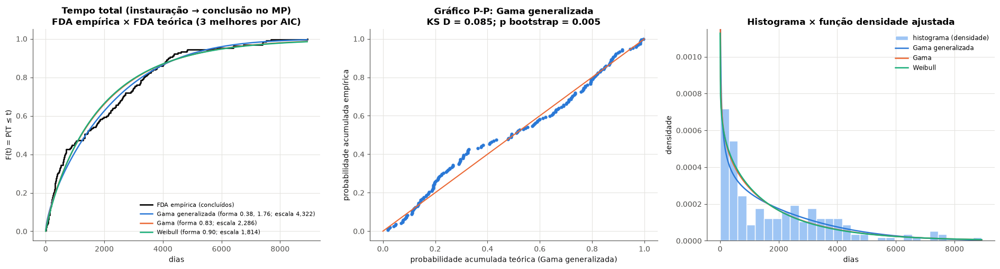

In [107]:
# FDA empírica × FDA teórica (com os parâmetros) e histograma × densidade ajustada
for v, rotulo in DESFECHOS.items():
    x = np.sort(concluidos[v].astype(float).to_numpy() + 0.5)
    ecdf = np.arange(1, len(x) + 1) / len(x)
    melhores = list(tabelas_conc[v].index[:3])
    grade = np.linspace(0.5, x.max(), 600)
    fig, axes = plt.subplots(1, 3, figsize=(19, 5.2))
    axes[0].step(x, ecdf, where='post', color=TINTA, linewidth=2, label='FDA empírica (concluídos)')
    for nome, cor in zip(melhores, [COR_PRINCIPAL, COR_DESTAQUE, CORES[2]]):
        dist, params = ajustes_conc[v][nome]
        forma = ', '.join(f'{p:.2f}' for p in params[:-2])
        axes[0].plot(grade, dist.cdf(grade, *params), color=cor, linewidth=1.8,
                     label=f'{nome} ({"forma " + forma + "; " if forma else ""}escala {params[-1]:,.0f})')
    axes[0].set_xlabel('dias')
    axes[0].set_ylabel('F(t) = P(T ≤ t)')
    axes[0].set_title(f'{rotulo}\nFDA empírica × FDA teórica (3 melhores por AIC)')
    axes[0].legend(fontsize=8, loc='lower right')

    nome = melhores[0]
    dist, params = ajustes_conc[v][nome]
    teorica = dist.cdf(x, *params)
    axes[1].plot(teorica, ecdf, 'o', markersize=3.5, color=COR_PRINCIPAL)
    axes[1].plot([0, 1], [0, 1], color=COR_DESTAQUE, linewidth=1.5)
    d_ks = aderencias_conc[v].loc[nome, 'KS (D)']
    axes[1].set_xlabel(f'probabilidade acumulada teórica ({nome})')
    axes[1].set_ylabel('probabilidade acumulada empírica')
    axes[1].set_title(f'Gráfico P-P: {nome}\nKS D = {d_ks:.3f}; p bootstrap = {aderencias_conc[v].loc[nome, "p KS (bootstrap)"]:.3f}')

    axes[2].hist(x, bins=30, density=True, color=COR_SECUNDARIA, edgecolor='white', label='histograma (densidade)')
    for nome_d, cor in zip(melhores, [COR_PRINCIPAL, COR_DESTAQUE, CORES[2]]):
        dist_d, params_d = ajustes_conc[v][nome_d]
        axes[2].plot(grade, dist_d.pdf(grade, *params_d), color=cor, linewidth=1.8, label=nome_d)
    axes[2].set_xlabel('dias')
    axes[2].set_ylabel('densidade')
    axes[2].set_ylim(0, np.histogram(x, bins=30, density=True)[0].max() * 1.6)
    axes[2].set_title('Histograma × função densidade ajustada')
    axes[2].legend(fontsize=8.5)
    plt.tight_layout()
    plt.show()

**A heterogeneidade explica a forma?** A fase judicial mistura dois processos: os procedimentos em que o MP **pede o arquivamento sem se manifestar antes** e os que passam por **diligências**. Se a distribuição for uma mistura desses dois grupos, cada um deve ser bem descrito por uma família. A verificação ajusta a gama generalizada em cada grupo e compara as FDAs empírica e teórica.

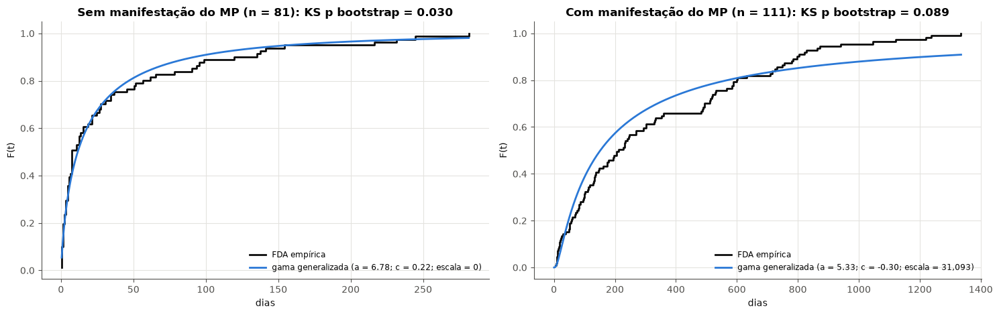

,n,Mediana (dias),a,c,escala,KS (D),p KS (bootstrap),Cramér-von Mises (W²),p CvM (bootstrap)
Grupo,,,,,,,,,
Sem manifestação do MP,81,7.50,6.78,0.22,0.00,0.10,0.03,0.09,0.08
Com manifestação do MP,111,211.50,5.33,-0.30,"31,093.45",0.11,0.09,0.48,0.02


Razão de verossimilhança (uma gama generalizada por grupo × uma só): LR = 90.0; gl = 3; p = 2.24e-19


In [108]:
x_jud = concluidos['Tempo_fase_judicial'].astype(float).to_numpy() + 0.5
grupo_manif = concluidos['Houve_manifestacao_mp'].astype(bool).to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
mistura, ll_grupos = [], 0.0
for ax, (rotulo, mascara) in zip(axes, [('Sem manifestação do MP', ~grupo_manif), ('Com manifestação do MP', grupo_manif)]):
    xg = np.sort(x_jud[mascara])
    params = stats.gengamma.fit(xg, floc=0)
    ll_grupos += stats.gengamma.logpdf(xg, *params).sum()
    ad = aderencia_bootstrap(xg, 'Gama generalizada', n_boot=100)
    mistura.append({'Grupo': rotulo, 'n': len(xg), 'Mediana (dias)': np.median(xg), 'a': params[0], 'c': params[1],
                    'escala': params[-1], **ad})
    ax.step(xg, np.arange(1, len(xg) + 1) / len(xg), where='post', color=TINTA, linewidth=2, label='FDA empírica')
    grade = np.linspace(0.5, xg.max(), 400)
    ax.plot(grade, stats.gengamma.cdf(grade, *params), color=COR_PRINCIPAL, linewidth=2,
            label=f'gama generalizada (a = {params[0]:.2f}; c = {params[1]:.2f}; escala = {params[-1]:,.0f})')
    ax.set_title(f'{rotulo} (n = {len(xg)}): KS p bootstrap = {ad["p KS (bootstrap)"]:.3f}')
    ax.set_xlabel('dias')
    ax.set_ylabel('F(t)')
    ax.legend(fontsize=8.5, loc='lower right')
plt.tight_layout()
plt.show()
display(pd.DataFrame(mistura).set_index('Grupo').round(4))
lr_mistura = 2 * (ll_grupos - tabelas_conc['Tempo_fase_judicial'].loc['Gama generalizada', 'log-verossimilhança'])
print(f'Razão de verossimilhança (uma gama generalizada por grupo × uma só): LR = {lr_mistura:.1f}; gl = 3; '
      f'p = {stats.chi2.sf(lr_mistura, 3):.2e}')

**Leitura: a gama generalizada é adequada?**

*Fase judicial (192 concluídos).*
- **Critérios de informação:** Weibull (forma 0,59; escala 141 dias) e gama (forma 0,47) empatam no AIC (diferença de 0,3). A gama generalizada fica atrás, porque o terceiro parâmetro não melhora a verossimilhança. Lognormal, log-logística e exponencial ficam bem atrás (ΔAIC de 16 a 102).
- **Razão de verossimilhança:** confirma. A gama generalizada não supera a Weibull nem a gama (p > 0,4). A exponencial é rejeitada (p < 10⁻²³): o risco de conclusão **diminui** com o tempo (forma de Weibull < 1).
- **Aderência por bootstrap:** nenhuma família passa a 5%. Para a Weibull, KS p ≈ 0,01; para a gama, p ≈ 0,04. A FDA empírica sobe mais rápido que a teórica nos primeiros dias, por causa do excesso de arquivamentos imediatos, e o gráfico P-P mostra essa curvatura.
- **Mistura de dois regimes:** separados, os dois grupos se ajustam muito melhor que o conjunto (LR = 90; 3 gl; p < 10⁻¹⁸):

  | Grupo | Mediana |
  |---|---|
  | Sem manifestação do MP | 7,5 dias |
  | Com manifestação do MP | 212 dias |

*Tempo total.* Gama, Weibull, gama generalizada e até a exponencial ficam a poucos pontos de AIC. Os dados não distinguem as famílias e, ainda assim, todas são rejeitadas no bootstrap. É o reflexo de uma variável que mede a idade do inquérito (seção 21).

**Veredito.** Na amostra, a suspeita de gama generalizada **não se confirma como necessidade**. A família mais simples que descreve a fase judicial é a **Weibull com risco decrescente**, e a gama generalizada não acrescenta nada significativo. Nenhuma família única é aderente, porque o tempo é uma **mistura de regimes**. Na população (seção 22.8), com milhares de casos, o quadro muda: a gama generalizada vence com folga.

---

## 19. Modelos de Regressão: o que Explica o Tempo, o Indiciamento e a Denúncia

| Pergunta | Desfecho | Modelo | Medida de ajuste |
|---|---|---|---|
| O que se associa a um tempo **maior**? | log(1 + dias) da fase judicial, concluídos | **linear** (MQO, erros HC3) | **R²**, R² ajustado, **R² parcial** de cada variável |
| O que se associa ao **indiciamento**? | autor identificado: 77 sim × 141 não | **logística** | razões de chance (OR), pseudo-R² de McFadden, **AUC (ROC)**, Hosmer-Lemeshow |
| O que se associa à **denúncia**? | denúncia (6) × arquivamento (181) | **logística de Firth** | OR penalizado, uma variável por vez |
| O que se associa à **prescrição**? | extinção por prescrição (10) × demais arquivamentos | **logística de Firth** | OR penalizado, uma variável por vez |

**Por que essas escolhas.**
- **Regressão linear:** a resposta é o **log** do tempo porque o tempo é muito assimétrico e os resíduos na escala original seriam muito heterogêneos. Os coeficientes exponenciados são efeitos **multiplicativos** (1,5 = 50% mais tempo). O modelo ignora os 26 censurados; a seção 20 corrige isso.
- **Regressão logística:** a regra prática é ter cerca de 10 eventos por parâmetro. O indiciamento (77 eventos) comporta uns 7 parâmetros.
- **Logística de Firth:** a denúncia (6 eventos) não comporta um modelo multivariável. A logística comum daria estimativas infinitas por separação; a penalização de Firth corrige o viés de eventos raros. O modelo completo da denúncia fica para a população (seção 22).
- **Comum a todos:** o **VIF** verifica a colinearidade entre as variáveis.

MQO de log(1 + dias), n = 192: R² = 0.253; R² ajustado = 0.180; teste F (HC3): p = 2.32e-10


,Coef. (log),Efeito multiplicativo no tempo,"IC 2,5%","IC 97,5%",p-valor
Comarca=Anápolis,0.57,1.77,0.90,3.46,0.10
Comarca=Aparecida de Goiânia,-1.37,0.26,0.12,0.56,0.00
Comarca=Luziânia,-0.86,0.42,0.15,1.21,0.11
Comarca=Senador Canedo,0.83,2.28,0.98,5.33,0.06
Comarca=Águas Lindas de Goiás,1.18,3.26,1.27,8.34,0.01
Assunto_grupo=Homicídio qualificado,-0.35,0.70,0.30,1.63,0.41
Assunto_grupo=Outros,-0.51,0.60,0.11,3.20,0.55
Forma_instauracao=Auto de prisão em flagrante (APF),0.52,1.68,0.49,5.76,0.41
Ano_recebimento_projudi=2023,0.99,2.68,0.90,7.97,0.08
Ano_recebimento_projudi=2024,0.41,1.50,0.49,4.59,0.48


,ΔR² (perda ao retirar),R² parcial,VIF (máximo do grupo)
Variável,,,
Comarca,0.13,0.15,1.36
Idade do IP na chegada,0.04,0.05,1.55
Ano de recebimento,0.03,0.04,4.03
Múltiplas vítimas,0.01,0.01,1.08
Tentativa,0.01,0.01,1.42
Assunto,0.01,0.01,1.21
Forma de instauração (APF),0.00,0.00,2.71
Tramitação direta,0.00,0.00,3.91
Arma de fogo,0.00,0.00,1.32


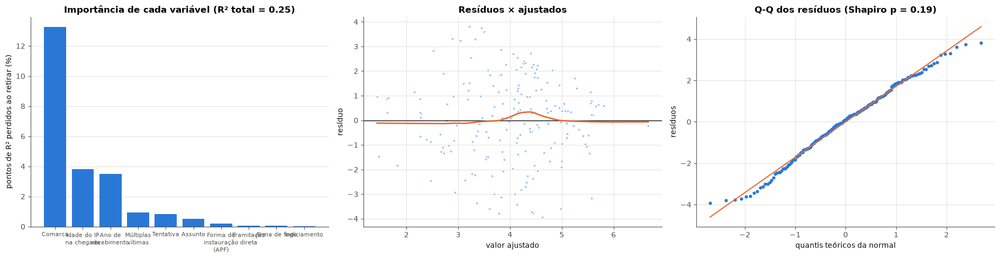

In [109]:
REFERENCIAS = {'Comarca': 'Goiânia', 'Assunto_grupo': 'Homicídio simples', 'Forma_instauracao': 'Portaria',
               'Ano_recebimento_projudi': 2022}


def matriz_desenho(df, categoricas, binarias, continuas):
    partes = []
    for v in categoricas:
        x = pd.get_dummies(df[v].astype(object), prefix=v, prefix_sep='=', dtype=float)
        partes.append(x.drop(columns=f'{v}={REFERENCIAS[v]}'))
    partes += [df[binarias].astype(float), df[continuas].astype(float)]
    return pd.concat(partes, axis=1)


COX_CATEGORICAS = ['Comarca', 'Assunto_grupo', 'Forma_instauracao', 'Ano_recebimento_projudi']
COX_BINARIAS = ['Arma_de_fogo', 'Tentativa', 'Tramitacao_direta', 'Multiplas_vitimas', 'Houve_indiciamento']
COX_CONTINUAS = ['Idade_entrada_anos']
X_cox = matriz_desenho(dados, COX_CATEGORICAS, COX_BINARIAS, COX_CONTINUAS)
GRUPOS_REGRESSAO = {
    'Comarca': [c for c in X_cox.columns if c.startswith('Comarca=')],
    'Assunto': [c for c in X_cox.columns if c.startswith('Assunto_grupo=')],
    'Forma de instauração (APF)': [c for c in X_cox.columns if c.startswith('Forma_instauracao=')],
    'Ano de recebimento': [c for c in X_cox.columns if c.startswith('Ano_recebimento_projudi=')],
    'Arma de fogo': ['Arma_de_fogo'], 'Tentativa': ['Tentativa'], 'Tramitação direta': ['Tramitacao_direta'],
    'Múltiplas vítimas': ['Multiplas_vitimas'], 'Indiciamento': ['Houve_indiciamento'], 'Idade do IP na chegada': ['Idade_entrada_anos'],
}

# 1. Regressão linear do log do tempo (concluídos)
X_lin = sm.add_constant(X_cox.loc[evento.to_numpy()].astype(float))
y_lin = np.log1p(concluidos['Tempo_fase_judicial'].astype(float))
mqo = sm.OLS(y_lin, X_lin).fit(cov_type='HC3')
print(f'MQO de log(1 + dias), n = {int(mqo.nobs)}: R² = {mqo.rsquared:.3f}; R² ajustado = {mqo.rsquared_adj:.3f}; '
      f'teste F (HC3): p = {mqo.f_pvalue:.2e}')
display(pd.DataFrame({'Coef. (log)': mqo.params, 'Efeito multiplicativo no tempo': np.exp(mqo.params),
                      'IC 2,5%': np.exp(mqo.conf_int()[0]), 'IC 97,5%': np.exp(mqo.conf_int()[1]), 'p-valor': mqo.pvalues}).drop('const').round(3))
r2_parcial = []
for grupo, colunas in GRUPOS_REGRESSAO.items():
    reduzido = sm.OLS(y_lin, X_lin.drop(columns=colunas)).fit()
    r2_parcial.append({'Variável': grupo, 'ΔR² (perda ao retirar)': mqo.rsquared - reduzido.rsquared,
                       'R² parcial': (mqo.rsquared - reduzido.rsquared) / (1 - reduzido.rsquared)})
r2_parcial = pd.DataFrame(r2_parcial).set_index('Variável').sort_values('ΔR² (perda ao retirar)', ascending=False)
vif = pd.Series([variance_inflation_factor(X_lin.to_numpy(), i) for i in range(1, X_lin.shape[1])], index=X_lin.columns[1:])
r2_parcial['VIF (máximo do grupo)'] = [vif[GRUPOS_REGRESSAO[g]].max() for g in r2_parcial.index]
display(r2_parcial.round(4))

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
axes[0].bar(range(len(r2_parcial)), 100 * r2_parcial['ΔR² (perda ao retirar)'], color=COR_PRINCIPAL)
axes[0].set_xticks(range(len(r2_parcial)), [quebrar(i, 12) for i in r2_parcial.index], fontsize=8)
axes[0].set_ylabel('pontos de R² perdidos ao retirar (%)')
axes[0].set_title(f'Importância de cada variável (R² total = {mqo.rsquared:.2f})')
axes[0].grid(axis='x', visible=False)
axes[1].scatter(mqo.fittedvalues, mqo.resid, s=14, color=COR_SECUNDARIA, edgecolor='white')
axes[1].axhline(0, color=TINTA, linewidth=1)
suave = lowess(mqo.resid, mqo.fittedvalues, frac=0.5)
axes[1].plot(suave[:, 0], suave[:, 1], color=COR_DESTAQUE, linewidth=2)
axes[1].set_xlabel('valor ajustado')
axes[1].set_ylabel('resíduo')
axes[1].set_title('Resíduos × ajustados')
(osm, osr), (a, b, _) = stats.probplot(mqo.resid, dist='norm')
axes[2].scatter(osm, osr, s=12, color=COR_PRINCIPAL)
axes[2].plot(osm, a * osm + b, color=COR_DESTAQUE)
axes[2].set_xlabel('quantis teóricos da normal')
axes[2].set_ylabel('resíduos')
axes[2].set_title(f'Q-Q dos resíduos (Shapiro p = {stats.shapiro(mqo.resid).pvalue:.2g})')
plt.tight_layout()
plt.show()

Logística do indiciamento: n = 218; eventos = 77; LR χ² = 49.6 (p = 1.76e-08); pseudo-R² de McFadden = 0.175; AUC = 0.749; Hosmer-Lemeshow χ² = 11.88 (gl = 8; p = 0.157)


,OR,"IC 2,5%","IC 97,5%",p-valor
APF,10.93,2.13,56.04,0.00
Tentativa,2.21,0.86,5.65,0.10
Arma_de_fogo,2.02,0.88,4.66,0.10
Homicidio_qualificado,0.80,0.34,1.86,0.60
Delegacia_DIH_GIH,0.48,0.19,1.17,0.11
Goiania,0.76,0.40,1.44,0.39
Ano_instauracao_c,1.13,1.05,1.23,0.00


,APF,Tentativa,Arma_de_fogo,Homicidio_qualificado,Delegacia_DIH_GIH,Goiania,Ano_instauracao_c
VIF,1.57,1.46,1.39,1.02,1.82,1.05,1.35


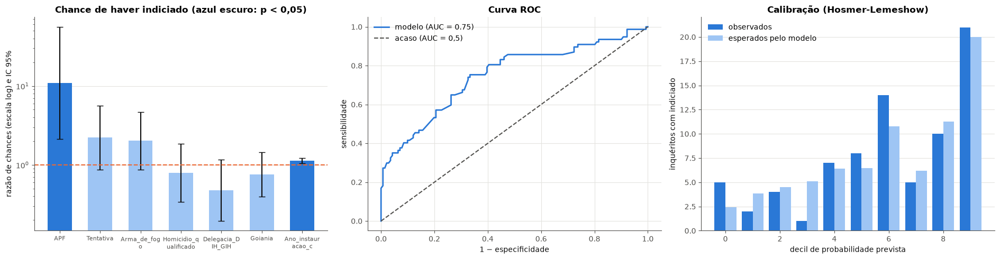

In [110]:
# 2. Logística: indiciamento (autor identificado)
X_ind = pd.DataFrame({
    'APF': dados['Forma_instauracao'].astype(str).str.startswith('Auto').astype(float),
    'Tentativa': dados['Tentativa'].astype(float),
    'Arma_de_fogo': dados['Arma_de_fogo'].astype(float),
    'Homicidio_qualificado': dados['Assunto_grupo'].eq('Homicídio qualificado').astype(float),
    'Delegacia_DIH_GIH': dados['Tipo_delegacia'].eq('Especializada em homicídios (DIH/GIH)').astype(float),
    'Goiania': dados['Comarca'].eq('Goiânia').astype(float),
    'Ano_instauracao_c': dados['Ano_instauracao'].astype(float) - 2020,
})
y_ind = dados['Houve_indiciamento'].astype(int)
logit_ind = sm.Logit(y_ind, sm.add_constant(X_ind)).fit(disp=False)
or_ind = pd.DataFrame({'OR': np.exp(logit_ind.params), 'IC 2,5%': np.exp(logit_ind.conf_int()[0]),
                       'IC 97,5%': np.exp(logit_ind.conf_int()[1]), 'p-valor': logit_ind.pvalues}).drop('const')
prob = logit_ind.predict()
auc = stats.mannwhitneyu(prob[y_ind == 1], prob[y_ind == 0]).statistic / ((y_ind == 1).sum() * (y_ind == 0).sum())
decis = pd.qcut(prob, 10, duplicates='drop')
hl = pd.DataFrame({'y': y_ind, 'p': prob}).groupby(decis, observed=True).agg(obs=('y', 'sum'), esp=('p', 'sum'), n=('y', 'size'))
hl_stat = (((hl['obs'] - hl['esp']) ** 2) / (hl['esp'] * (1 - hl['esp'] / hl['n']))).sum()
print(f'Logística do indiciamento: n = {int(logit_ind.nobs)}; eventos = {int(y_ind.sum())}; LR χ² = {logit_ind.llr:.1f} '
      f'(p = {logit_ind.llr_pvalue:.2e}); pseudo-R² de McFadden = {logit_ind.prsquared:.3f}; AUC = {auc:.3f}; '
      f'Hosmer-Lemeshow χ² = {hl_stat:.2f} (gl = {len(hl) - 2}; p = {stats.chi2.sf(hl_stat, len(hl) - 2):.3f})')
display(or_ind.round(3))
display(pd.Series([variance_inflation_factor(sm.add_constant(X_ind).to_numpy(), i) for i in range(1, X_ind.shape[1] + 1)],
                  index=X_ind.columns, name='VIF').round(2).to_frame().T)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
x = np.arange(len(or_ind))
cores = [COR_PRINCIPAL if p < 0.05 else COR_SECUNDARIA for p in or_ind['p-valor']]
axes[0].bar(x, or_ind['OR'], color=cores, width=0.6)
axes[0].errorbar(x, or_ind['OR'], yerr=[or_ind['OR'] - or_ind['IC 2,5%'], or_ind['IC 97,5%'] - or_ind['OR']], fmt='none',
                 ecolor=TINTA, capsize=4)
axes[0].axhline(1, color=COR_DESTAQUE, linestyle='--')
axes[0].set_yscale('log')
axes[0].set_xticks(x, [quebrar(c, 11) for c in or_ind.index], fontsize=8)
axes[0].set_ylabel('razão de chances (escala log) e IC 95%')
axes[0].set_title('Chance de haver indiciado (azul escuro: p < 0,05)')
axes[0].grid(axis='x', visible=False)
limiares = np.r_[1.01, np.sort(prob)[::-1], -0.01]
axes[1].plot([(prob[y_ind == 0] >= l).mean() for l in limiares], [(prob[y_ind == 1] >= l).mean() for l in limiares],
             color=COR_PRINCIPAL, linewidth=2, label=f'modelo (AUC = {auc:.2f})')
axes[1].plot([0, 1], [0, 1], color=TINTA_2, linestyle='--', label='acaso (AUC = 0,5)')
axes[1].set_xlabel('1 − especificidade')
axes[1].set_ylabel('sensibilidade')
axes[1].set_title('Curva ROC')
axes[1].legend()
axes[2].bar(np.arange(len(hl)) - 0.2, hl['obs'], width=0.4, color=COR_PRINCIPAL, label='observados')
axes[2].bar(np.arange(len(hl)) + 0.2, hl['esp'], width=0.4, color=COR_SECUNDARIA, label='esperados pelo modelo')
axes[2].set_xlabel('decil de probabilidade prevista')
axes[2].set_ylabel('inquéritos com indiciado')
axes[2].set_title('Calibração (Hosmer-Lemeshow)')
axes[2].legend()
axes[2].grid(axis='x', visible=False)
plt.tight_layout()
plt.show()

In [111]:
# 3. Denúncia × arquivamento: logística de Firth, uma variável por vez
def logistica_firth(X, y, max_iter=200, tol=1e-8):
    """Regressão logística com penalização de Firth (Jeffreys): estimativas finitas mesmo com separação."""
    X, y = np.asarray(X, float), np.asarray(y, float)
    beta = np.zeros(X.shape[1])
    for _ in range(max_iter):
        p = 1 / (1 + np.exp(-X @ beta))
        W = p * (1 - p)
        info_inv = np.linalg.inv(X.T @ (X * W[:, None]))
        h = W * np.einsum('ij,jk,ik->i', X, info_inv, X)
        passo = info_inv @ (X.T @ (y - p + h * (0.5 - p)))
        beta += passo
        if np.max(np.abs(passo)) < tol:
            break
    p = 1 / (1 + np.exp(-X @ beta))
    info = X.T @ (X * (p * (1 - p))[:, None])
    loglik_pen = (y * np.log(p) + (1 - y) * np.log(1 - p)).sum() + 0.5 * np.linalg.slogdet(info)[1]
    return beta, np.sqrt(np.diag(np.linalg.inv(info))), loglik_pen


concl_denuncia = dados[dados['Tipo_desfecho'].isin(['Denúncia', 'Arquivamento'])]
y_den = concl_denuncia['Tipo_desfecho'].eq('Denúncia').astype(int).to_numpy()
firth = []
for nome, x in {'APF': concl_denuncia['Forma_instauracao'].astype(str).str.startswith('Auto'),
                'Réu preso': concl_denuncia['Reu_preso'], 'Com indiciado': concl_denuncia['Houve_indiciamento'],
                'Tentativa': concl_denuncia['Tentativa'], 'Arma de fogo': concl_denuncia['Arma_de_fogo'],
                'Instaurado a partir de 2022': concl_denuncia['Ano_instauracao'].ge(2022)}.items():
    X = np.c_[np.ones(len(y_den)), x.astype(float).to_numpy()]
    beta, ep, ll = logistica_firth(X, y_den)
    _, _, ll0 = logistica_firth(X[:, :1], y_den)
    firth.append({'Variável': nome, 'Denúncias com o atributo': int(y_den[x.astype(bool).to_numpy()].sum()),
                  'OR (Firth)': np.exp(beta[1]), 'IC 2,5%': np.exp(beta[1] - 1.96 * ep[1]), 'IC 97,5%': np.exp(beta[1] + 1.96 * ep[1]),
                  'p (razão de verossimilhança penalizada)': stats.chi2.sf(max(2 * (ll - ll0), 0), 1)})
print(f'Denúncia × arquivamento: {y_den.sum()} denúncias e {len(y_den) - y_den.sum()} arquivamentos — uma variável por vez')
with pd.option_context('display.float_format', lambda v: f'{v:.4g}'):
    display(pd.DataFrame(firth).set_index('Variável'))

# 4. Prescrição × demais arquivamentos: o mesmo procedimento (10 eventos)
arquivados = dados[dados['Status_macro'].eq('Arquivado')]
y_presc = arquivados['Status_projudi'].eq('Arquivado: extinção da punibilidade (prescrição)').astype(int).to_numpy()
firth_presc = []
for nome, x in {'Idade do fato na conclusão (anos)': (arquivados['Data_conclusao_mp'] - arquivados['Data_fato']).dt.days / 365.25,
                'Idade do IP na chegada (anos)': arquivados['Idade_entrada_anos'].astype(float),
                'Sem indiciado': ~arquivados['Houve_indiciamento'].astype(bool),
                'Comarca de Goiânia': arquivados['Comarca'].eq('Goiânia'),
                'Homicídio qualificado': arquivados['Assunto_grupo'].eq('Homicídio qualificado')}.items():
    x = x.astype(float)
    validos = x.notna().to_numpy()
    X = np.c_[np.ones(validos.sum()), x[validos].to_numpy()]
    beta, ep, ll = logistica_firth(X, y_presc[validos])
    _, _, ll0 = logistica_firth(X[:, :1], y_presc[validos])
    firth_presc.append({'Variável': nome, 'OR (Firth)': np.exp(beta[1]), 'IC 2,5%': np.exp(beta[1] - 1.96 * ep[1]),
                        'IC 97,5%': np.exp(beta[1] + 1.96 * ep[1]), 'p (razão de verossimilhança penalizada)': stats.chi2.sf(max(2 * (ll - ll0), 0), 1)})
print(f'Prescrição × demais arquivamentos: {y_presc.sum()} prescrições entre {len(y_presc)} arquivados — uma variável por vez '
      '(variáveis contínuas: OR por ano)')
with pd.option_context('display.float_format', lambda v: f'{v:.4g}'):
    display(pd.DataFrame(firth_presc).set_index('Variável'))

Denúncia × arquivamento: 6 denúncias e 181 arquivamentos — uma variável por vez


,Denúncias com o atributo,OR (Firth),"IC 2,5%","IC 97,5%",p (razão de verossimilhança penalizada)
Variável,,,,,
APF,4,41.88,7.288,240.7,4.358e-05
Réu preso,2,11.34,1.967,65.36,0.02557
Com indiciado,5,8.145,1.292,51.36,0.00918
Tentativa,3,4.6,0.9831,21.52,0.0601
Arma de fogo,2,0.2313,0.04728,1.131,0.05134
Instaurado a partir de 2022,6,21.54,1.179,393.6,0.00187


Prescrição × demais arquivamentos: 10 prescrições entre 181 arquivados — uma variável por vez (variáveis contínuas: OR por ano)


,OR (Firth),"IC 2,5%","IC 97,5%",p (razão de verossimilhança penalizada)
Variável,,,,
Idade do fato na conclusão (anos),1.339,1.176,1.523,5.136e-09
Idade do IP na chegada (anos),1.337,1.181,1.514,1.367e-09
Sem indiciado,0.4274,0.1244,1.468,0.1091
Comarca de Goiânia,0.8055,0.2318,2.8,0.3099
Homicídio qualificado,0.23,0.01251,4.23,0.1713


**Leitura.**

*Regressão linear do log do tempo (fase judicial).* O modelo explica **25% da variação** (R² = 0,253; ajustado 0,180; F p < 10⁻⁹):

| Variável | ΔR² ao retirar | Efeito |
|---|---|---|
| Comarca | 13 pontos | Aparecida leva 0,26 vez o tempo de Goiânia (−74%; p < 0,001); Águas Lindas, 3,3 vezes (p = 0,01) |
| Idade do IP na chegada | 4 pontos | cada ano reduz o tempo em 9% (p < 0,001) |
| Ano de recebimento | 3 pontos | — |

As demais contribuem com menos de 1 ponto. O VIF máximo é de 4,0 (ano de recebimento), sem colinearidade grave. Os resíduos não são normais: o R² é **descritivo**, e a inferência fica com os erros robustos (HC3) e com os modelos de sobrevivência.

*Logística do indiciamento (77 × 141).* O modelo discrimina bem (**AUC = 0,75**; McFadden 0,18; LR p < 10⁻⁷) e é bem calibrado (Hosmer-Lemeshow p = 0,16). Dois fatores aparecem:

- **APF** multiplica por 11 a chance de haver indiciado (OR = 10,9; IC 2,1–56);
- **cada ano mais recente de instauração** a aumenta em 13% (OR = 1,13; IC 1,05–1,23). Isso pode ser efeito de período ou de os IPs antigos sem autor terem ficado no estoque.

Tentativa e arma de fogo dobram a chance, mas sem significância (p = 0,10). Delegacia especializada e comarca não importam. O VIF máximo é de 1,8.

*Firth: denúncia (6 eventos), uma variável por vez.* APF (OR = 42; IC 7–241; p < 0,001), réu preso (OR = 11; p = 0,03), indiciado (OR = 8; p = 0,009) e instauração a partir de 2022 (OR = 22; p = 0,002) aumentam a chance de denúncia. **Todas as seis denúncias** são de IPs recentes.

*Firth: prescrição (10 eventos entre 181 arquivados).* O único fator é o **tempo decorrido**:

- **idade do fato na conclusão:** cada ano a mais multiplica por **1,34** a chance de o arquivamento ser por prescrição (IC 1,18–1,52; p < 10⁻⁸);
- **idade do IP na chegada ao Projudi:** o mesmo efeito (OR 1,34/ano);
- **sem efeito:** indiciamento, comarca e qualificadora.

É o que o art. 109 do CP prevê: a prescrição é função do tempo. O modelo multivariável da extinção da punibilidade fica para a população (seção 22.9).

---

## 20. Análise de Sobrevivência: Incluindo os Procedimentos Não Concluídos

### 20.1 Por que outra abordagem

As seções 15 a 19 usaram só os concluídos. Isso **encurta** o tempo, porque os 26 censurados estão justamente entre os mais longos. A **análise de sobrevivência** usa toda a informação: o concluído contribui com o tempo exato, e o censurado contribui com o fato de que seu tempo é **maior** que o observado.

- **Função de sobrevivência** S(t) = P(T > t): a proporção de procedimentos **ainda não concluídos** após t dias. A curva **começa em 1 e desce** à medida que os procedimentos são concluídos.
- **Kaplan-Meier:** estimador de S(t) sem supor distribuição. A **mediana** é o tempo em que a curva cruza 0,5.
- **Log-rank:** compara curvas de dois ou mais grupos. É o equivalente do Mann-Whitney/Kruskal-Wallis para dados censurados.
- **Modelo de Cox:** estima a **razão de riscos** (HR) de cada variável, com as demais constantes. HR > 1 significa conclusão **mais rápida** (a curva desce mais depressa).

Esta seção usa a **fase judicial**, que é observada desde a chegada ao Projudi. O tempo total exige um ajuste a mais, que fica para a seção 21.

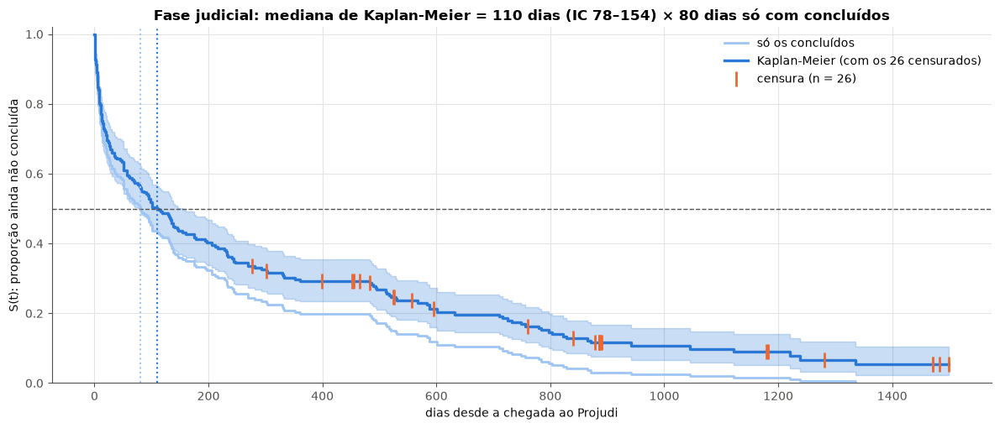

,Mediana (dias),"IC 2,5%","IC 97,5%",Q1 (dias),Q3 (dias)
Estimador,,,,,
só os concluídos,80.00,50.00,114.00,12.00,270.00
Kaplan-Meier (com os 26 censurados),110.00,78.00,154.00,14.00,520.00


In [112]:
def mediana_ic(km):
    ic = median_survival_times(km.confidence_interval_)
    return km.median_survival_time_, float(ic.iloc[0, 0]), float(ic.iloc[0, 1])


km_judicial = KaplanMeierFitter().fit(T_JUD, EVENTO, label='Kaplan-Meier (com os 26 censurados)')
km_ingenuo_jud = KaplanMeierFitter().fit(T_JUD[evento], label='só os concluídos')
fig, ax = plt.subplots(figsize=(12, 5.2))
km_ingenuo_jud.plot_survival_function(ax=ax, color=COR_SECUNDARIA, ci_show=False, linewidth=2)
km_judicial.plot_survival_function(ax=ax, color=COR_PRINCIPAL, linewidth=2.4)
censurados = T_JUD[~evento]
ax.plot(censurados, km_judicial.survival_function_at_times(censurados).to_numpy(), '|', color=COR_DESTAQUE, markersize=13,
        markeredgewidth=2, label=f'censura (n = {len(censurados)})')
m, li, ls = mediana_ic(km_judicial)
ax.axhline(0.5, color=TINTA_2, linestyle='--', linewidth=1)
ax.axvline(m, color=COR_PRINCIPAL, linestyle=':', linewidth=1.5)
ax.axvline(km_ingenuo_jud.median_survival_time_, color=COR_SECUNDARIA, linestyle=':', linewidth=1.5)
ax.set_xlabel('dias desde a chegada ao Projudi')
ax.set_ylabel('S(t): proporção ainda não concluída')
ax.set_title(f'Fase judicial: mediana de Kaplan-Meier = {m:.0f} dias (IC {li:.0f}–{ls:.0f}) × '
             f'{km_ingenuo_jud.median_survival_time_:.0f} dias só com concluídos')
ax.set_ylim(0, 1.02)
ax.legend()
plt.tight_layout()
plt.show()
display(pd.DataFrame([{'Estimador': k.label, 'Mediana (dias)': mediana_ic(k)[0], 'IC 2,5%': mediana_ic(k)[1],
                       'IC 97,5%': mediana_ic(k)[2], 'Q1 (dias)': k.percentile(0.75), 'Q3 (dias)': k.percentile(0.25)}
                      for k in [km_ingenuo_jud, km_judicial]]).set_index('Estimador').round(0))

### 20.2 Curvas por grupo: Kaplan-Meier, log-rank e Cox

Cada painel mostra as curvas de sobrevivência de um grupo e, no título:

- o **log-rank** (H₀: curvas iguais);
- a **razão de riscos** de um modelo de Cox com aquela única variável, quando ela tem dois grupos. HR > 1 indica que o segundo grupo conclui mais depressa.

Os p-valores do log-rank são corrigidos por Benjamini-Hochberg. Nas variáveis com mais de dois grupos, os pares são comparados por log-rank com ajuste de Holm.

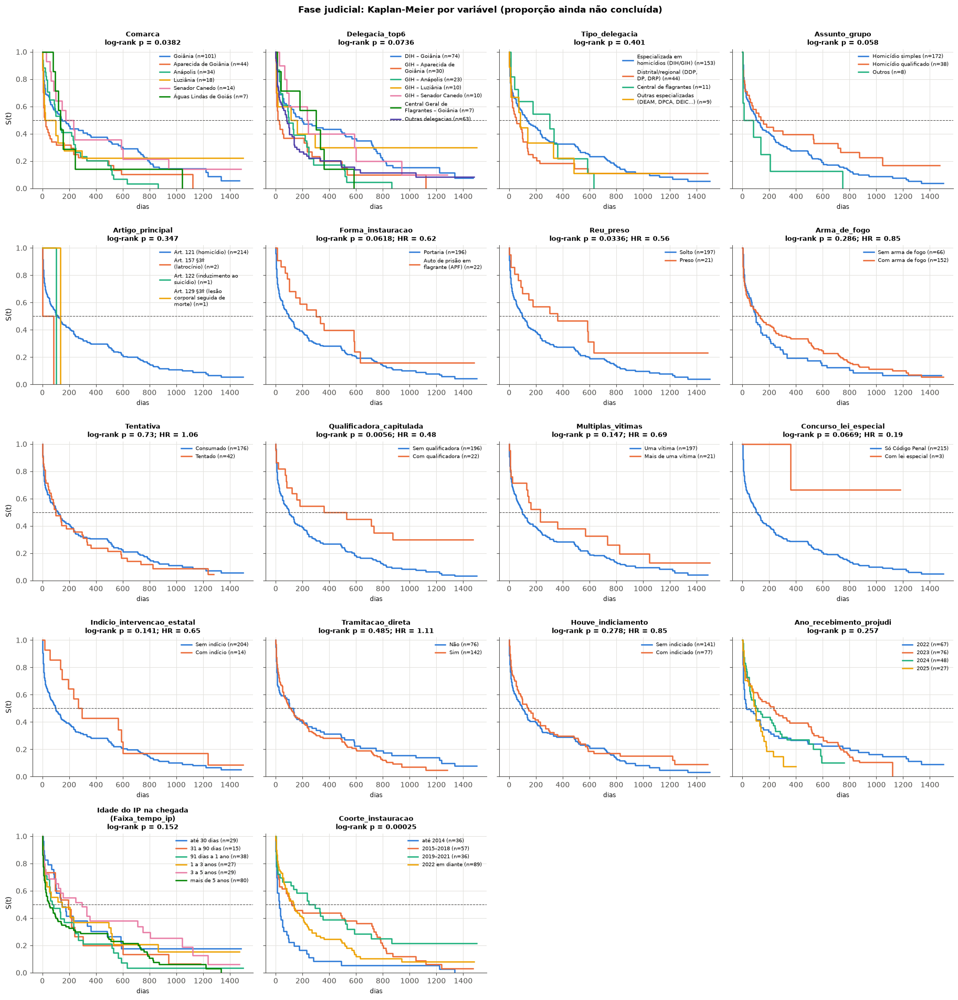

,p log-rank,p BH
Variável,,
Coorte_instauracao,0.00,0.00
Qualificadora_capitulada,0.01,0.05
Reu_preso,0.03,0.17
Comarca,0.04,0.17
Assunto_grupo,0.06,0.17
Forma_instauracao,0.06,0.17
Concurso_lei_especial,0.07,0.17
Delegacia_top6,0.07,0.17
Indicio_intervencao_estatal,0.14,0.25


n  Eventos  Mediana KM  IC 2,5%  IC 97,5%
Variável                                Grupo                                                                                      
Comarca                                 Goiânia                                         101       87      148.00    76.00    302.00
                                        Aparecida de Goiânia                             44       39       26.00     8.00     68.00
                                        Anápolis                                         34       33      130.00    50.00    232.00
                                        Luziânia                                         18       14      100.00     8.00    160.00
                                        Senador Canedo                                   14       12      232.00    66.00    600.00
                                        Águas Lindas de Goiás                             7        7      136.00    78.00    244.00
Delegacia_top6                          DIH – Goiânia                                    74       63      194.00    76.00    520.00
                                        GIH – Aparecida de Goiânia                       30       27       16.00     8.00    232.00
                                        GIH – Anápolis                                   23       23       98.00    34.00    232.00
                                        GIH – Luziânia                                   10        7      114.00     2.00       inf
                                        GIH – Senador Canedo                             10        9      232.00    28.00    600.00
                                        Central Geral de Flagrantes – Goiânia             7        7      302.00    12.00    360.00
                                        Outras delegacias                                63       55       82.00    36.00    120.00
Tipo_delegacia                          Especializada em homicídios (DIH/GIH)           153      135      132.00    78.00    232.00
                                        Distrital/regional (DDP, DP, DRP)                44       38       56.00    20.00    102.00
                                        Central de flagrantes                            11       10      302.00    12.00    584.00
                                        Outras especializadas (DEAM, DPCA, DEIC...)       9        8       82.00     0.00    484.00
Assunto_grupo                           Homicídio simples                               172      155      102.00    66.00    160.00
                                        Homicídio qualificado                            38       29      138.00    48.00    530.00
                                        Outros                                            8        8       82.00     0.00    206.00
Artigo_principal                        Art. 121 (homicídio)                            214      188      114.00    76.00    160.00
                                        Art. 157 §3º (latrocínio)                         2        2        0.00     0.00     82.00
                                        Art. 122 (induzimento ao suicídio)                1        1      102.00   102.00    102.00
                                        Art. 129 §3º (lesão corporal seguida de morte)    1        1      136.00   136.00    136.00
Forma_instauracao                       Portaria                                        196      176       98.00    56.00    138.00
                                        Auto de prisão em flagrante (APF)                22       16      302.00   100.00    588.00
Reu_preso                               Solto                                           197      178       98.00    60.00    138.00
                                        Preso                                            21       14      360.00    86.00    632.00
Arma_de_fogo                            Sem arma de fogo                                 66       60      100.00    62.00    138.0

Comparações par a par (log-rank, Holm) nas variáveis com mais de dois grupos e log-rank significativo após BH:

Coorte_instauracao


test_statistic    p  p Holm
2019–2021      até 2014                 14.20 0.00    0.00
2022 em diante até 2014                 10.70 0.00    0.01
2015–2018      até 2014                  8.18 0.00    0.02
2019–2021      2022 em diante            3.45 0.06    0.19
2015–2018      2022 em diante            1.25 0.26    0.53
               2019–2021                 0.96 0.33    0.53

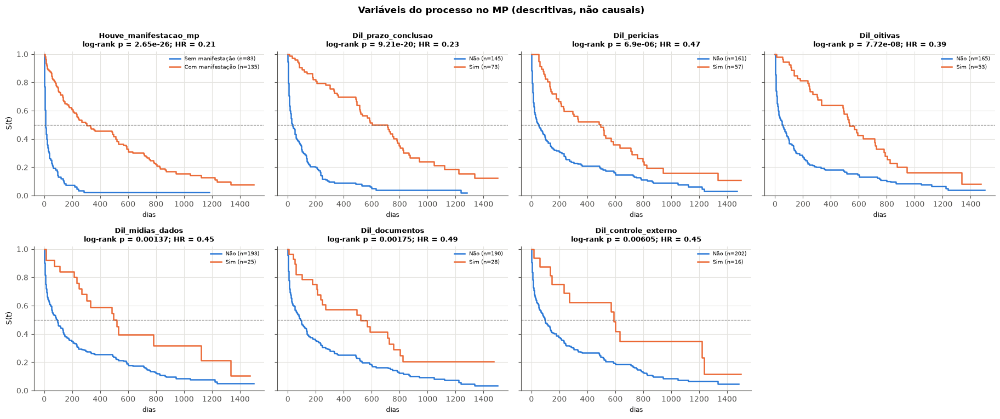

In [113]:
def grade_km(df, duracao, ev, variaveis, titulo, colunas=4, x_max=None):
    linhas_tab, n_linhas = [], int(np.ceil(len(variaveis) / colunas))
    fig, axes = plt.subplots(n_linhas, colunas, figsize=(4.6 * colunas, 3.8 * n_linhas), sharey=True, squeeze=False)
    duracao, ev = pd.Series(np.asarray(duracao, float), index=df.index), pd.Series(np.asarray(ev, int), index=df.index)
    for ax, v in zip(axes.flat, variaveis):
        grupos = serie_exibicao(df, v).astype(object).where(df[v].notna(), None)
        validos = grupos.notna()
        teste = multivariate_logrank_test(duracao[validos], grupos[validos].astype(str), ev[validos])
        ordem = [g for g in (serie_exibicao(df, v).cat.categories if isinstance(serie_exibicao(df, v).dtype, pd.CategoricalDtype)
                             else pd.unique(grupos[validos])) if (grupos == g).sum() > 0]
        texto_hr = ''
        if len(ordem) == 2:
            base = pd.DataFrame({'T': duracao[validos], 'E': ev[validos], 'X': grupos[validos].eq(ordem[1]).astype(float)})
            cox_u = CoxPHFitter().fit(base, 'T', 'E')
            texto_hr = f'; HR = {cox_u.hazard_ratios_["X"]:.2f}'
        for g, cor in zip(ordem, CORES * 2):
            idx = grupos.index[grupos == g]
            km = KaplanMeierFitter().fit(duracao[idx], ev[idx])
            ax.step(km.survival_function_.index, km.survival_function_.iloc[:, 0], where='post', color=cor, linewidth=1.8,
                    label=f'{quebrar(str(g), 24)} (n={len(idx)})')
            ic = median_survival_times(km.confidence_interval_)
            linhas_tab.append({'Variável': ROTULO_VARIAVEL.get(v, v), 'Grupo': g, 'n': len(idx), 'Eventos': int(ev[idx].sum()),
                               'Mediana KM': km.median_survival_time_, 'IC 2,5%': float(ic.iloc[0, 0]),
                               'IC 97,5%': float(ic.iloc[0, 1]), 'p log-rank': teste.p_value})
        ax.axhline(0.5, color=TINTA_2, linestyle='--', linewidth=0.8)
        ax.set_ylim(0, 1.02)
        if x_max:
            ax.set_xlim(0, x_max)
        ax.set_title(f'{quebrar(ROTULO_VARIAVEL.get(v, v), 34)}\nlog-rank p = {teste.p_value:.3g}{texto_hr}', fontsize=9.5)
        ax.legend(fontsize=7, loc='upper right')
        ax.set_xlabel('dias', fontsize=8.5)
    for ax in axes[:, 0]:
        ax.set_ylabel('S(t)')
    for ax in list(axes.flat)[len(variaveis):]:
        ax.set_visible(False)
    plt.suptitle(titulo, fontweight='bold', y=1.0)
    plt.tight_layout()
    plt.show()
    return pd.DataFrame(linhas_tab)


km_jud_var = grade_km(dados, T_JUD, EVENTO, VARIAVEIS_CASO + VARIAVEIS_CALENDARIO,
                      'Fase judicial: Kaplan-Meier por variável (proporção ainda não concluída)')
logrank_jud = km_jud_var.groupby('Variável', sort=False)['p log-rank'].first().to_frame()
logrank_jud['p BH'] = multipletests(logrank_jud['p log-rank'], method='fdr_bh')[1]
display(logrank_jud.sort_values('p log-rank').round(4))
with pd.option_context('display.max_rows', 90):
    display(km_jud_var.drop(columns='p log-rank').set_index(['Variável', 'Grupo']).round(0))

print('Comparações par a par (log-rank, Holm) nas variáveis com mais de dois grupos e log-rank significativo após BH:')
for v in VARIAVEIS_CASO + VARIAVEIS_CALENDARIO:
    rotulo = ROTULO_VARIAVEL.get(v, v)
    grupos = serie_exibicao(dados, v)
    if grupos.nunique() <= 2 or logrank_jud.loc[rotulo, 'p BH'] >= 0.05:
        continue
    validos = grupos.notna()
    pares = pairwise_logrank_test(T_JUD[validos], grupos[validos].astype(str), EVENTO[validos]).summary
    pares['p Holm'] = multipletests(pares['p'], method='holm')[1]
    print(f'\n{rotulo}')
    display(pares[['test_statistic', 'p', 'p Holm']].sort_values('p').round(4))

km_proc = grade_km(dados, T_JUD, EVENTO, VARIAVEIS_PROCESSO, 'Variáveis do processo no MP (descritivas, não causais)')

**Leitura.**

- **Censura importa.** Contando só os concluídos, a mediana da fase judicial é de 80 dias. Com os 26 censurados (Kaplan-Meier), sobe para **110 dias** (IC 78–154), quase 40% a mais. O quartil superior passa de 270 para 520 dias.
- **Curvas por grupo:** com os 218 casos, só duas variáveis separam as curvas após a correção BH:
  - a **coorte de instauração** (p BH < 0,001): os IPs de até 2014 se encerram muito depressa (mediana de 28 dias) e diferem de todas as outras coortes no log-rank par a par;
  - a **qualificadora capitulada** (p BH = 0,05): 360 × 100 dias.
- **Diferenças grandes, mas não significativas após BH:**
  - **comarca**, com Aparecida em 26 dias e Goiânia em 148 (log-rank p = 0,04);
  - **réu preso**, 360 × 98 dias;
  - **APF**, 302 × 98 dias, com HR univariado < 1.

  O multivariável da 20.3 as recupera.
- **Sem diferença:** tentativa, tramitação direta, arma de fogo e indiciamento.

### 20.3 Modelo de Cox multivariável

O Cox estima o efeito de cada variável **mantendo as outras constantes**:

- **Variáveis:** entram só as conhecidas na chegada ao Projudi. `Reu_preso` fica de fora, porque 19 dos 21 presos vêm de APF e a colinearidade inflaria os erros.
- **Tamanho:** são 192 eventos para 17 parâmetros, o que respeita a regra de pelo menos 10 eventos por parâmetro.
- **Ajuste:** concordância C e pseudo-R² de Nagelkerke.
- **Pressuposto de riscos proporcionais:** verificado pelos **resíduos de Schoenfeld**; as violações são corrigidas por **estratificação**.
- **Gráfico:** as **curvas de sobrevivência previstas pelo Cox** para os efeitos principais, com as demais variáveis na média.

n = 218; eventos = 192; C = 0.641; pseudo-R² de Nagelkerke = 0.198; razão de verossimilhança: p = 8.18e-05


,HR,"IC 2,5%","IC 97,5%",p-valor
covariate,,,,
Comarca=Anápolis,1.18,0.76,1.83,0.47
Comarca=Aparecida de Goiânia,2.24,1.50,3.35,0.00
Comarca=Luziânia,1.41,0.76,2.62,0.28
Comarca=Senador Canedo,0.99,0.52,1.89,0.99
Comarca=Águas Lindas de Goiás,1.34,0.58,3.07,0.49
Assunto_grupo=Homicídio qualificado,0.68,0.45,1.03,0.07
Assunto_grupo=Outros,1.59,0.74,3.43,0.23
Forma_instauracao=Auto de prisão em flagrante (APF),0.37,0.17,0.84,0.02
Ano_recebimento_projudi=2023,0.80,0.44,1.45,0.46


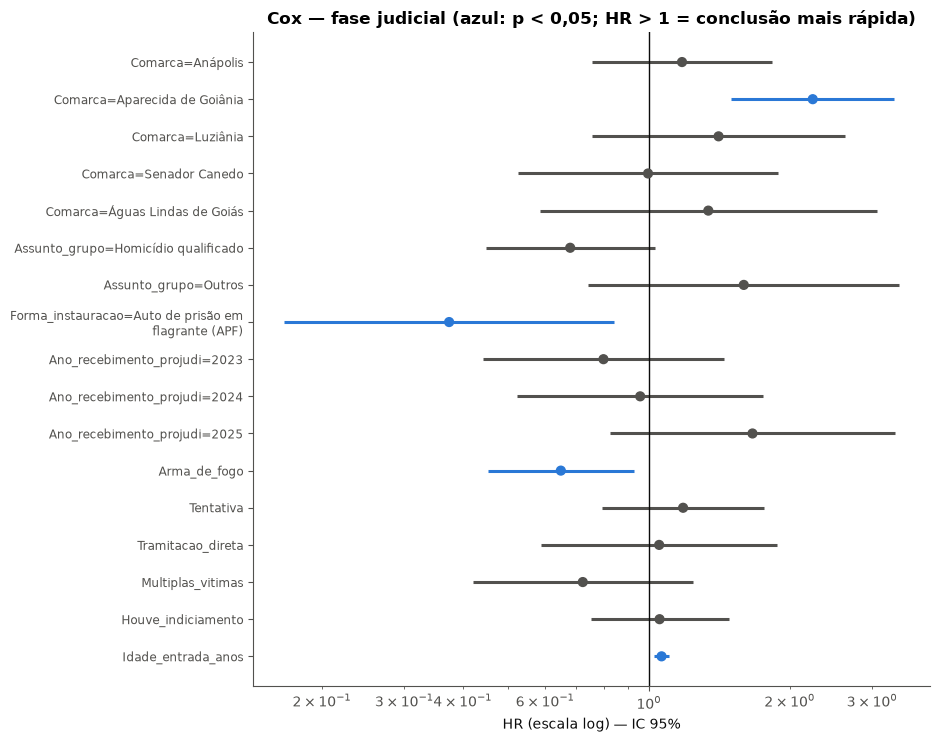

,LR χ² (perda ao retirar),gl,p-valor,ΔC
Variável,,,,
Comarca,15.04,5,0.01,0.03
Idade do IP na chegada,9.57,1,0.00,0.02
Ano de recebimento,6.63,3,0.08,0.01
Forma de instauração (APF),5.86,1,0.02,0.00
Assunto,5.46,2,0.07,0.00
Arma de fogo,5.30,1,0.02,0.00
Múltiplas vítimas,1.48,1,0.22,0.00
Tentativa,0.67,1,0.41,-0.00
Indiciamento,0.09,1,0.76,-0.00


In [114]:
def nagelkerke(ll_modelo, ll_nulo, n):
    cox_snell = 1 - np.exp(2 * (ll_nulo - ll_modelo) / n)
    return cox_snell, cox_snell / (1 - np.exp(2 * ll_nulo / n))


def grafico_floresta(tabela, titulo, coluna='HR', referencia=1, rotulo_x='HR (escala log) — IC 95%'):
    tabela = tabela.iloc[::-1]
    fig, ax = plt.subplots(figsize=(9.5, 0.36 * len(tabela) + 1.4))
    y = np.arange(len(tabela))
    cores = np.where(tabela['p-valor'] < 0.05, COR_PRINCIPAL, TINTA_2)
    ax.hlines(y, tabela['IC 2,5%'], tabela['IC 97,5%'], color=cores, linewidth=2.2)
    ax.scatter(tabela[coluna], y, color=cores, s=40, zorder=3)
    ax.axvline(referencia, color=TINTA, linewidth=1)
    ax.set_xscale('log')
    ax.set_yticks(y, [quebrar(str(i), 42) for i in tabela.index], fontsize=8.5)
    ax.set_xlabel(rotulo_x)
    ax.set_title(titulo)
    ax.grid(axis='y', visible=False)
    plt.tight_layout()
    plt.show()


base_cox = X_cox.assign(T=T_JUD, E=EVENTO)
cox_jud = CoxPHFitter().fit(base_cox, 'T', 'E')
resumo_cox = cox_jud.summary[['exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p']].set_axis(
    ['HR', 'IC 2,5%', 'IC 97,5%', 'p-valor'], axis=1)
ll_nulo_cox = cox_jud.log_likelihood_ - cox_jud.log_likelihood_ratio_test().test_statistic / 2
cs, nk = nagelkerke(cox_jud.log_likelihood_, ll_nulo_cox, len(base_cox))
print(f'n = {len(base_cox)}; eventos = {int(EVENTO.sum())}; C = {cox_jud.concordance_index_:.3f}; pseudo-R² de Nagelkerke = {nk:.3f}; '
      f'razão de verossimilhança: p = {cox_jud.log_likelihood_ratio_test().p_value:.2e}')
display(resumo_cox.round(3))
grafico_floresta(resumo_cox, 'Cox — fase judicial (azul: p < 0,05; HR > 1 = conclusão mais rápida)')

importancia_cox = []
for grupo, colunas in GRUPOS_REGRESSAO.items():
    reduzido = CoxPHFitter().fit(base_cox.drop(columns=colunas), 'T', 'E')
    lr = 2 * (cox_jud.log_likelihood_ - reduzido.log_likelihood_)
    importancia_cox.append({'Variável': grupo, 'LR χ² (perda ao retirar)': lr, 'gl': len(colunas),
                            'p-valor': stats.chi2.sf(lr, len(colunas)), 'ΔC': cox_jud.concordance_index_ - reduzido.concordance_index_})
display(pd.DataFrame(importancia_cox).set_index('Variável').sort_values('LR χ² (perda ao retirar)', ascending=False).round(4))

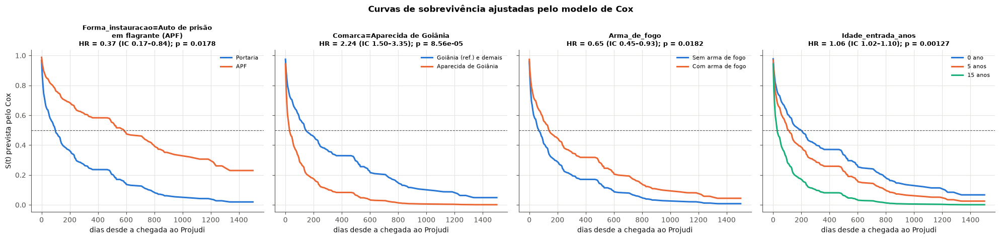

In [115]:
# Curvas de sobrevivência previstas pelo Cox (demais variáveis na média)
EFEITOS_CURVA = [('Forma_instauracao=Auto de prisão em flagrante (APF)', [0, 1], ['Portaria', 'APF']),
                 ('Comarca=Aparecida de Goiânia', [0, 1], ['Goiânia (ref.) e demais', 'Aparecida de Goiânia']),
                 ('Arma_de_fogo', [0, 1], ['Sem arma de fogo', 'Com arma de fogo']),
                 ('Idade_entrada_anos', [0, 5, 15], ['0 ano', '5 anos', '15 anos'])]
fig, axes = plt.subplots(1, 4, figsize=(20, 4.8), sharey=True)
for ax, (coluna, valores, rotulos) in zip(axes, EFEITOS_CURVA):
    perfil = base_cox.drop(columns=['T', 'E']).mean().to_frame().T
    perfis = pd.concat([perfil.assign(**{coluna: v}) for v in valores], ignore_index=True)
    curvas = cox_jud.predict_survival_function(perfis, times=np.linspace(0, T_JUD.max(), 300))
    for (_, curva), rotulo, cor in zip(curvas.items(), rotulos, CORES):
        ax.plot(curvas.index, curva, color=cor, linewidth=2.2, label=rotulo)
    hr = resumo_cox.loc[coluna]
    ax.set_title(f'{quebrar(coluna, 34)}\nHR = {hr["HR"]:.2f} (IC {hr["IC 2,5%"]:.2f}–{hr["IC 97,5%"]:.2f}); p = {hr["p-valor"]:.3g}',
                 fontsize=9.5)
    ax.axhline(0.5, color=TINTA_2, linestyle='--', linewidth=0.8)
    ax.set_xlabel('dias desde a chegada ao Projudi')
    ax.legend(fontsize=8)
axes[0].set_ylabel('S(t) prevista pelo Cox')
plt.suptitle('Curvas de sobrevivência ajustadas pelo modelo de Cox', fontweight='bold')
plt.tight_layout()
plt.show()

,χ² (1 gl),p-valor,"Viola (p < 0,05)"
Ano_recebimento_projudi=2023,7.50,0.01,True
Ano_recebimento_projudi=2024,8.15,0.00,True
Ano_recebimento_projudi=2025,7.96,0.00,True
Arma_de_fogo,1.02,0.31,False
Assunto_grupo=Homicídio qualificado,4.27,0.04,True
Assunto_grupo=Outros,0.09,0.76,False
Comarca=Anápolis,6.27,0.01,True
Comarca=Aparecida de Goiânia,2.48,0.12,False
Comarca=Luziânia,0.24,0.62,False
Comarca=Senador Canedo,3.73,0.05,False


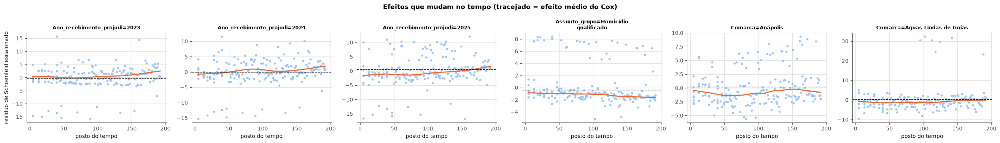

Estratificação pela variável cuja maioria dos níveis viola o pressuposto: ['Ano_recebimento_projudi']


Cox simples                          Cox estratificado                              
                                                             HR IC 2,5% IC 97,5% p-valor                HR IC 2,5% IC 97,5% p-valor p PH
covariate                                                                                                                               
Comarca=Anápolis                                           1.18    0.76     1.83    0.47              1.18    0.75     1.87    0.47 0.98
Comarca=Aparecida de Goiânia                               2.24    1.50     3.35    0.00              1.84    1.22     2.77    0.00 0.00
Comarca=Luziânia                                           1.41    0.76     2.62    0.28              1.16    0.61     2.21    0.65 0.30
Comarca=Senador Canedo                                     0.99    0.52     1.89    0.99              1.02    0.54     1.93    0.96 0.68
Comarca=Águas Lindas de Goiás                              1.34    0.58     3.07    0.49              1.30    0.56     3.00    0.54 0.75
Assunto_grupo=Homicídio qualificado                        0.68    0.45     1.03    0.07              0.70    0.46     1.06    0.10 0.95
Assunto_grupo=Outros                                       1.59    0.74     3.43    0.23              2.01    0.92     4.39    0.08 0.27
Forma_instauracao=Auto de prisão em flagrante (APF)        0.37    0.17     0.84    0.02              0.36    0.16     0.83    0.02 0.91
Ano_recebimento_projudi=2023                               0.80    0.44     1.45    0.46               NaN     NaN      NaN     NaN  NaN
Ano_recebimento_projudi=2024                               0.96    0.52     1.76    0.89               NaN     NaN      NaN     NaN  NaN
Ano_recebimento_projudi=2025                               1.66    0.83     3.35    0.15               NaN     NaN      NaN     NaN  NaN
Arma_de_fogo                                               0.65    0.45     0.93    0.02              0.70    0.49     1.00    0.05 0.59
Tentativa                                                  1.18    0.79     1.76    0.41              1.22    0.81     1.84    0.34 0.02
Tramitacao_direta                                          1.05    0.59     1.88    0.86              1.18    0.66     2.10    0.58 0.11
Multiplas_vitimas                                          0.72    0.42     1.24    0.24              0.73    0.42     1.25    0.25 0.67
Houve_indiciamento                                         1.05    0.75     1.48    0.76              1.07    0.76     1.51    0.68 0.67
Idade_entrada_anos                                         1.06    1.02     1.10    0.00              1.06    1.02     1.10    0.01 0.28

In [116]:
# Pressuposto de riscos proporcionais (resíduos de Schoenfeld) e Cox estratificado
ph = proportional_hazard_test(cox_jud, base_cox, time_transform='rank').summary[['test_statistic', 'p']].set_axis(['χ² (1 gl)', 'p-valor'], axis=1)
ph['Viola (p < 0,05)'] = ph['p-valor'] < 0.05
display(ph.round(4))
violadoras = list(ph.index[ph['Viola (p < 0,05)']])
residuos = cox_jud.compute_residuals(base_cox, 'scaled_schoenfeld')
postos = stats.rankdata(base_cox.loc[residuos.index, 'T'])
if violadoras:
    fig, axes = plt.subplots(1, len(violadoras), figsize=(4.4 * len(violadoras), 3.8), squeeze=False)
    for ax, v in zip(axes[0], violadoras):
        ax.scatter(postos, residuos[v], s=10, color=COR_SECUNDARIA)
        suave = lowess(residuos[v], postos, frac=0.4)
        ax.plot(suave[:, 0], suave[:, 1], color=COR_DESTAQUE, linewidth=2)
        ax.axhline(cox_jud.params_[v], color=TINTA, linestyle='--', linewidth=1)
        ax.set_title(quebrar(v, 30), fontsize=9.5)
        ax.set_xlabel('posto do tempo')
    axes[0][0].set_ylabel('resíduo de Schoenfeld escalonado')
    plt.suptitle('Efeitos que mudam no tempo (tracejado = efeito médio do Cox)', fontweight='bold')
    plt.tight_layout()
    plt.show()

VARIAVEIS_ESTRATO = [v for v in COX_CATEGORICAS if ph.loc[[c for c in ph.index if c.startswith(f'{v}=')], 'Viola (p < 0,05)'].mean() > 0.5]
print(f'Estratificação pela variável cuja maioria dos níveis viola o pressuposto: {VARIAVEIS_ESTRATO or "nenhuma"}')
if VARIAVEIS_ESTRATO:
    X_estr = matriz_desenho(dados, [v for v in COX_CATEGORICAS if v not in VARIAVEIS_ESTRATO], COX_BINARIAS, COX_CONTINUAS)
    base_estr = X_estr.assign(T=T_JUD, E=EVENTO, **{v: dados[v].astype(str) for v in VARIAVEIS_ESTRATO})
    cox_estr = CoxPHFitter().fit(base_estr, 'T', 'E', strata=VARIAVEIS_ESTRATO)
    resumo_estr = cox_estr.summary[['exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p']].set_axis(
        ['HR', 'IC 2,5%', 'IC 97,5%', 'p-valor'], axis=1)
    ph_estr = proportional_hazard_test(cox_estr, base_estr, time_transform='rank').summary['p']
    display(pd.concat({'Cox simples': resumo_cox, 'Cox estratificado': resumo_estr.assign(**{'p PH': ph_estr})}, axis=1).round(3))

**Leitura.** O modelo é significativo (razão de verossimilhança p < 0,001), com C = 0,64 e **pseudo-R² de Nagelkerke = 0,20**. Com as demais variáveis constantes:

| Efeito | HR | IC 95% | Leitura |
|---|---|---|---|
| Aparecida de Goiânia × Goiânia | 2,24 | 1,50–3,35 | encerra duas vezes mais depressa |
| APF × portaria | 0,37 | 0,17–0,84 | demora mais |
| Arma de fogo | 0,65 | 0,45–0,93 | demora mais |
| Idade do IP na chegada (por ano) | 1,06 | 1,02–1,10 | quanto mais antigo, mais rápido o arquivamento |

- **O que mais pesa:** retirar cada variável mostra que a **comarca** (LR χ² = 15; p = 0,01) e a **idade na chegada** (LR χ² = 9,6; p = 0,002) são as que mais contribuem.
- **Curvas ajustadas:** as curvas de sobrevivência previstas pelo Cox mostram a escala desses efeitos. Com as demais variáveis na média, o IP de Aparecida cruza 50% muito antes do de Goiânia.
- **Pressuposto de riscos proporcionais:** o teste de Schoenfeld acusa violação em todos os níveis do **ano de recebimento**, um efeito de lote que muda no tempo.
- **Cox estratificado** por esse ano: os efeitos se mantêm. Aparecida HR 1,84 (IC 1,22–2,77), APF 0,36, arma 0,70 (p = 0,05), idade 1,06/ano. O efeito de Aparecida ainda varia no tempo, concentrado nos primeiros dias, e deve ser lido como efeito médio.

### 20.4 Distribuições paramétricas com censura e modelos AFT

A seção 18 ajustou as famílias aos concluídos. Agora o ajuste usa a **verossimilhança com censura**: os concluídos contribuem com a densidade f(t), e os censurados com a sobrevivência S(t).

- **Diagnóstico visual:** as curvas de sobrevivência ajustadas são comparadas com o Kaplan-Meier.
- **Resíduos de Cox-Snell:** se o modelo está certo, eles se comportam como uma exponencial(1), e o risco acumulado estimado fica sobre a diagonal.
- **Modelos AFT:** modelam o tempo diretamente, sem supor riscos proporcionais. O coeficiente exponenciado é uma **razão de tempos** (TR): 1,5 significa 50% mais tempo.

,Parâmetros,log-verossimilhança,AIC,BIC,Mediana (dias),Estimativas,ΔAIC,ΔBIC
Família,,,,,,,,
Gama generalizada,3,"-1,224.21","2,454.42","2,464.58",98.88,"mu = 4.97, ln_sigma = 0.765, lambda = 0.515",0.00,2.81
Weibull,2,"-1,225.50","2,455.00","2,461.77",115.29,"lambda = 230, rho = 0.53",0.58,0.00
Lognormal,2,"-1,225.96","2,455.91","2,462.68",84.40,"mu = 4.44, sigma = 2.35",1.49,0.91
Gama,2,"-1,228.54","2,461.07","2,467.84",140.04,"k = 0.422, theta = 860",6.65,6.07
Log-logística,2,"-1,229.50","2,463.01","2,469.77",92.05,"alpha = 92, beta = 0.718",8.58,8.01
Exponencial,1,"-1,300.48","2,602.96","2,606.34",222.92,lambda = 322,148.53,144.57


,LR,gl,p-valor
H₀ (modelo restrito),,,
Weibull (λ = 1),2.578,1,0.1084
Lognormal (λ = 0),3.492,1,0.06165
Gama (λ = σ),8.65,1,0.003271
Exponencial (λ = 1 e σ = 1),152.5,2,7.547e-34


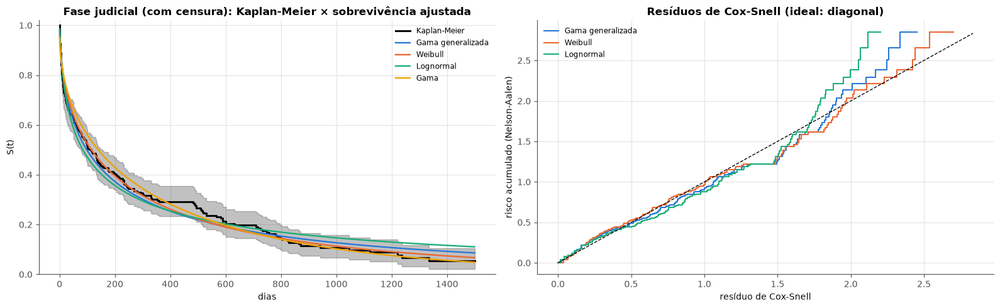

In [117]:
class GamaFitter(ParametricUnivariateFitter):
    """Gama (forma k, escala θ) com censura e entrada tardia; S(t) = Q(k, t/θ)."""
    _fitted_parameter_names = ['k_', 'theta_']
    _bounds = [(1e-6, None), (1e-6, None)]
    label = 'Gama'

    def _cumulative_hazard(self, params, times):
        k, theta = params
        return -gammainccln(k, times / theta)

    def percentile(self, p):
        return float(stats.gamma.isf(p, self.k_, scale=self.theta_))

    @property
    def median_survival_time_(self):
        return self.percentile(0.5)


FAMILIAS = {
    'Exponencial': (ExponentialFitter, 1), 'Weibull': (WeibullFitter, 2), 'Gama': (GamaFitter, 2),
    'Lognormal': (LogNormalFitter, 2), 'Log-logística': (LogLogisticFitter, 2), 'Gama generalizada': (GeneralizedGammaFitter, 3),
}


def ajustar_familias(t, e, entrada=None):
    ajustes, linhas = {}, []
    for nome, (classe, k) in FAMILIAS.items():
        modelo = classe().fit(t, e, entry=entrada)
        ajustes[nome] = modelo
        linhas.append({'Família': nome, 'Parâmetros': k, 'log-verossimilhança': modelo.log_likelihood_,
                       'AIC': -2 * modelo.log_likelihood_ + 2 * k, 'BIC': -2 * modelo.log_likelihood_ + k * np.log(len(t)),
                       'Mediana (dias)': float(modelo.median_survival_time_),
                       'Estimativas': ', '.join(f'{p.rstrip("_")} = {v:.3g}' for p, v in modelo.params_.items())})
    tabela = pd.DataFrame(linhas).set_index('Família').sort_values('AIC')
    tabela['ΔAIC'], tabela['ΔBIC'] = tabela['AIC'] - tabela['AIC'].min(), tabela['BIC'] - tabela['BIC'].min()
    return ajustes, tabela


def razao_verossimilhanca(ajustes):
    gg = ajustes['Gama generalizada'].log_likelihood_
    testes = []
    for restrito, gl, hipotese in [('Weibull', 1, 'λ = 1'), ('Lognormal', 1, 'λ = 0'), ('Gama', 1, 'λ = σ'),
                                   ('Exponencial', 2, 'λ = 1 e σ = 1')]:
        lr = 2 * (gg - ajustes[restrito].log_likelihood_)
        testes.append({'H₀ (modelo restrito)': f'{restrito} ({hipotese})', 'LR': lr, 'gl': gl, 'p-valor': stats.chi2.sf(max(lr, 0), gl)})
    return pd.DataFrame(testes).set_index('H₀ (modelo restrito)')


def diagnostico_sobrevivencia(t, e, ajustes, km, titulo, entrada=None, familias=('Gama generalizada', 'Weibull', 'Lognormal', 'Gama')):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    grade = np.linspace(0.5, np.asarray(t).max(), 500)
    km.plot_survival_function(ax=axes[0], color=TINTA, ci_show=True, linewidth=2.2, label='Kaplan-Meier')
    for nome, cor in zip(familias, CORES):
        axes[0].plot(grade, ajustes[nome].survival_function_at_times(grade), color=cor, linewidth=1.7, label=nome)
    axes[0].set_xlabel('dias')
    axes[0].set_ylabel('S(t)')
    axes[0].set_ylim(0, 1.02)
    axes[0].set_title(f'{titulo}: Kaplan-Meier × sobrevivência ajustada')
    axes[0].legend(fontsize=8.5)
    for nome, cor in zip(familias[:3], CORES):
        modelo = ajustes[nome]
        r = modelo.cumulative_hazard_at_times(np.asarray(t)).to_numpy()
        r0 = None if entrada is None else modelo.cumulative_hazard_at_times(np.maximum(np.asarray(entrada), 1e-9)).to_numpy()
        na = NelsonAalenFitter().fit(r, e, entry=r0)
        axes[1].step(na.cumulative_hazard_.index, na.cumulative_hazard_.iloc[:, 0], where='post', color=cor, label=nome)
    lim = axes[1].get_xlim()[1]
    axes[1].plot([0, lim], [0, lim], color=TINTA, linestyle='--', linewidth=1)
    axes[1].set_xlabel('resíduo de Cox-Snell')
    axes[1].set_ylabel('risco acumulado (Nelson-Aalen)')
    axes[1].set_title('Resíduos de Cox-Snell (ideal: diagonal)')
    axes[1].legend(fontsize=8.5)
    plt.tight_layout()
    plt.show()


ajustes_jud, tabela_jud = ajustar_familias(T_JUD, EVENTO)
display(tabela_jud.round(2))
with pd.option_context('display.float_format', lambda v: f'{v:.4g}'):
    display(razao_verossimilhanca(ajustes_jud))
diagnostico_sobrevivencia(T_JUD, EVENTO, ajustes_jud, km_judicial, 'Fase judicial (com censura)')

,log-verossimilhança,AIC,Parâmetros,pseudo-R² de Nagelkerke,ΔAIC
Lognormal AFT,"-1,199.82","2,437.63",19.00,0.21,0.00
Weibull AFT,"-1,199.94","2,437.89",19.00,0.21,0.25
Gama generalizada AFT,"-1,199.17","2,438.34",20.00,0.20,0.70
Log-logística AFT,"-1,201.58","2,441.15",19.00,0.23,3.52


Lognormal AFT                          Weibull AFT                         
                                                               TR IC 2,5% IC 97,5% p-valor          TR IC 2,5% IC 97,5% p-valor
covariate                                                                                                                      
Ano_recebimento_projudi=2023                                 2.09    0.69     6.35    0.19        1.62    0.61     4.29    0.34
Ano_recebimento_projudi=2024                                 1.89    0.59     6.08    0.29        1.27    0.47     3.46    0.64
Ano_recebimento_projudi=2025                                 0.70    0.18     2.66    0.60        0.47    0.15     1.48    0.20
Arma_de_fogo                                                 1.59    0.79     3.17    0.19        2.18    1.20     3.97    0.01
Assunto_grupo=Homicídio qualificado                          1.43    0.65     3.14    0.38        1.93    0.96     3.87    0.07
Assunto_grupo=Outros                                         0.41    0.09     1.91    0.26        0.47    0.13     1.69    0.25
Comarca=Águas Lindas de Goiás                                1.54    0.30     7.88    0.60        0.61    0.15     2.42    0.48
Comarca=Anápolis                                             1.28    0.53     3.07    0.58        0.81    0.39     1.70    0.58
Comarca=Aparecida de Goiânia                                 0.24    0.11     0.52    0.00        0.26    0.13     0.49    0.00
Comarca=Luziânia                                             0.56    0.18     1.80    0.34        0.55    0.20     1.56    0.26
Comarca=Senador Canedo                                       2.35    0.70     7.87    0.17        1.00    0.34     2.91    0.99
Forma_instauracao=Auto de prisão em flagrante (APF)          4.90    1.06    22.66    0.04        5.53    1.41    21.61    0.01
Houve_indiciamento                                           1.08    0.56     2.10    0.82        0.88    0.50     1.54    0.65
Idade_entrada_anos                                           0.90    0.84     0.96    0.00        0.89    0.84     0.95    0.00
Multiplas_vitimas                                            2.37    0.88     6.38    0.09        1.70    0.69     4.21    0.25
Tentativa                                                    1.07    0.48     2.39    0.88        0.76    0.39     1.48    0.42
Tramitacao_direta                                            0.96    0.32     2.88    0.94        0.89    0.34     2.35    0.82

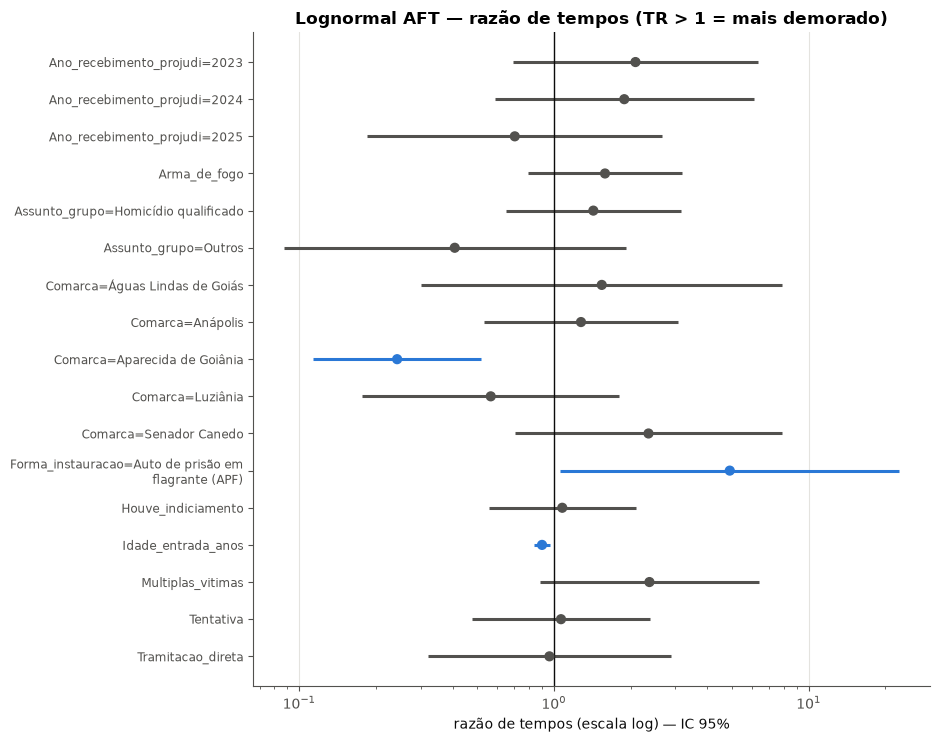

In [118]:
base_aft = X_cox.copy()
base_aft.columns = [re.sub(r'\W+', '_', unicodedata.normalize('NFKD', c).encode('ascii', 'ignore').decode()).strip('_') for c in base_aft.columns]
NOMES_AFT = dict(zip(base_aft.columns, X_cox.columns))
base_aft = base_aft.assign(T=T_JUD.to_numpy(), E=EVENTO.to_numpy())
modelos_aft = {
    'Weibull AFT': WeibullAFTFitter().fit(base_aft, 'T', 'E'),
    'Lognormal AFT': LogNormalAFTFitter().fit(base_aft, 'T', 'E'),
    'Log-logística AFT': LogLogisticAFTFitter().fit(base_aft, 'T', 'E'),
    'Gama generalizada AFT': GeneralizedGammaRegressionFitter(penalizer=1e-4).fit(
        base_aft, 'T', 'E', regressors={'mu_': ' + '.join(NOMES_AFT), 'sigma_': '1', 'lambda_': '1'}),
}
NULOS_AFT = {'Weibull AFT': WeibullFitter, 'Lognormal AFT': LogNormalFitter, 'Log-logística AFT': LogLogisticFitter,
             'Gama generalizada AFT': GeneralizedGammaFitter}
comparacao_aft = pd.DataFrame({nome: {'log-verossimilhança': m.log_likelihood_, 'AIC': m.AIC_, 'Parâmetros': len(m.params_),
                                      'pseudo-R² de Nagelkerke': nagelkerke(m.log_likelihood_, NULOS_AFT[nome]().fit(T_JUD, EVENTO).log_likelihood_,
                                                                           len(T_JUD))[1]}
                               for nome, m in modelos_aft.items()}).T.sort_values('AIC')
comparacao_aft['ΔAIC'] = comparacao_aft['AIC'] - comparacao_aft['AIC'].min()
display(comparacao_aft.round(3))
melhor_aft = comparacao_aft.index[0]
parametro_local = {'Weibull AFT': 'lambda_', 'Lognormal AFT': 'mu_', 'Log-logística AFT': 'alpha_', 'Gama generalizada AFT': 'mu_'}
tabelas_tr = {}
for nome in [melhor_aft, 'Weibull AFT']:
    s = modelos_aft[nome].summary.loc[parametro_local[nome]].drop(index='Intercept', errors='ignore')
    tabelas_tr[nome] = pd.DataFrame({'TR': np.exp(s['coef']), 'IC 2,5%': np.exp(s['coef lower 95%']),
                                     'IC 97,5%': np.exp(s['coef upper 95%']), 'p-valor': s['p']}).rename(index=NOMES_AFT)
display(pd.concat(tabelas_tr, axis=1).round(3))
grafico_floresta(tabelas_tr[melhor_aft], f'{melhor_aft} — razão de tempos (TR > 1 = mais demorado)', coluna='TR',
                 rotulo_x='razão de tempos (escala log) — IC 95%')

**Leitura.**

*Famílias com censura.* Gama generalizada, Weibull e lognormal ficam a menos de 1,5 ponto de AIC. O terceiro parâmetro não se paga (razão de verossimilhança × Weibull p = 0,11; × lognormal p = 0,06), e a gama é rejeitada (p = 0,003). As curvas ajustadas acompanham o Kaplan-Meier, e os resíduos de Cox-Snell ficam próximos da diagonal. Com censura, a Weibull e a lognormal são aproximações adequadas.

*Modelos AFT.* As quatro distribuições empatam (ΔAIC ≤ 3,5; pseudo-R² de Nagelkerke de 0,20 a 0,23), e as razões de tempo (TR) confirmam o Cox:

| Efeito | TR | Leitura |
|---|---|---|
| Aparecida de Goiânia | 0,24–0,26 | um quarto do tempo de Goiânia |
| APF | 4,9–5,5 | cinco vezes mais tempo |
| Idade na chegada | 0,89–0,90 por ano | −10% por ano |
| Arma de fogo | 1,6 a 2,2 | significativo só na Weibull |

---

## 21. Tópico Avançado: a Janela de Observação e o Tempo Total

### 21.1 Diagrama de Lexis

A fase judicial é observada desde o início. O **tempo total** não. A base reúne os procedimentos que **chegaram ao Projudi** entre 2022 e 2025: um IP instaurado em 2005 só está na amostra porque ainda não tinha terminado em 2022, e os de 2005 que terminaram antes **nunca poderiam** ter sido amostrados. O diagrama de Lexis mostra cada inquérito como um segmento:

- o trecho pontilhado vai da instauração à chegada ao Projudi e fica **fora** da observação;
- o trecho cheio é o período efetivamente observado.

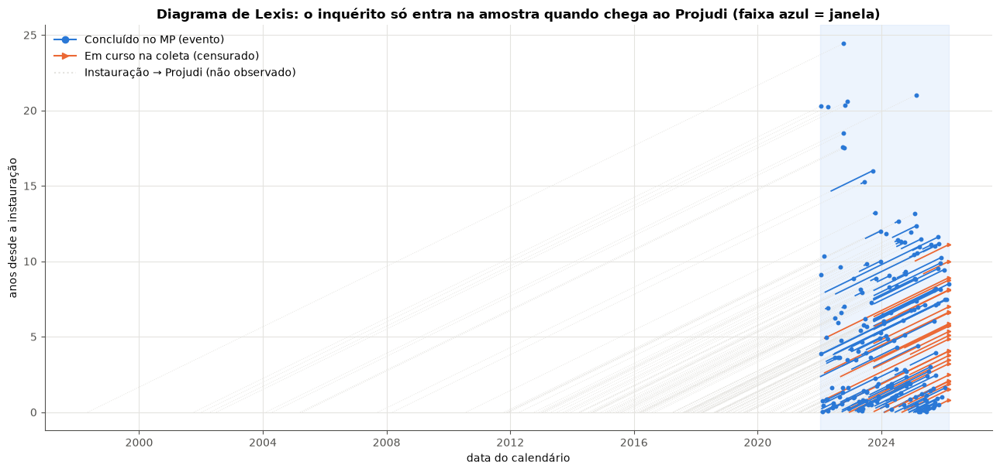

In [119]:
fig, ax = plt.subplots(figsize=(13, 6.2))
for i, linha in dados.sort_values('Data_instauracao').iterrows():
    x0, x1, x2 = linha['Data_instauracao'], linha['Data_recebimento_projudi'], fim_observado[i]
    y1, y2 = linha['Tempo_conclusao_ip'] / 365.25, linha['Tempo_total'] / 365.25
    cor = COR_PRINCIPAL if linha['Concluido_mp'] else COR_DESTAQUE
    ax.plot([x0, x1], [0, y1], color=GRADE, linewidth=0.7, linestyle=':', zorder=1)
    ax.plot([x1, x2], [y1, y2], color=cor, linewidth=1.3, zorder=2)
    ax.plot(x2, y2, marker='o' if linha['Concluido_mp'] else '>', markersize=3.2, color=cor, zorder=3)
inicio_janela = dados['Data_recebimento_projudi'].min()
ax.axvspan(inicio_janela, DATA_REFERENCIA, color=COR_SECUNDARIA, alpha=0.18, zorder=0)
ax.plot([], [], color=COR_PRINCIPAL, marker='o', label='Concluído no MP (evento)')
ax.plot([], [], color=COR_DESTAQUE, marker='>', label='Em curso na coleta (censurado)')
ax.plot([], [], color=GRADE, linestyle=':', label='Instauração → Projudi (não observado)')
ax.set_xlabel('data do calendário')
ax.set_ylabel('anos desde a instauração')
ax.set_title('Diagrama de Lexis: o inquérito só entra na amostra quando chega ao Projudi (faixa azul = janela)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

### 21.2 Censura e truncamento: três estimativas do tempo total

A seleção pela chegada ao Projudi cria **truncamento à esquerda** (*entrada tardia*): um inquérito só pode ser observado se a duração total superar o tempo até a chegada ao Projudi. O Kaplan-Meier corrige isso quando cada caso entra no conjunto de risco só a partir da sua idade na chegada. Três estimativas, da mais ingênua à mais completa:

1. só os concluídos;
2. Kaplan-Meier com censura;
3. Kaplan-Meier com censura e **entrada tardia**. Esta só vale se a idade na chegada não alterar o risco de conclusão dali em diante, a chamada **quase-independência**, testada na 21.3.

,Mediana (dias),"IC 2,5%","IC 97,5%"
Estimador,,,
1. Só concluídos,"1,332.00",704.00,"1,812.00"
2. Com censura,"1,764.00","1,322.00","2,208.00"
3. Com censura e entrada tardia,140.00,68.00,200.00


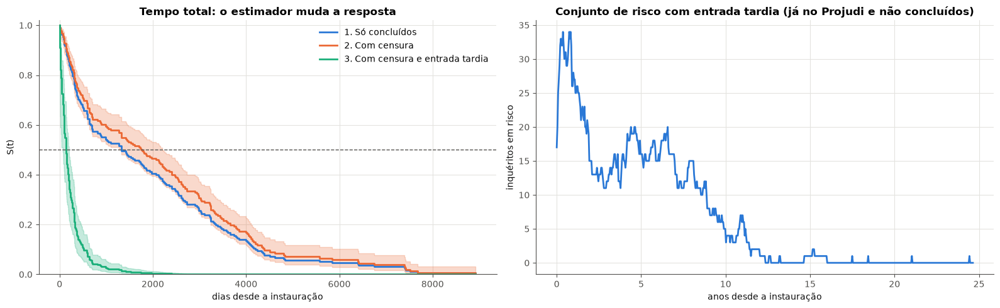

In [120]:
assert (ENTRADA < T_TOTAL).all()
km_ingenuo = KaplanMeierFitter().fit(T_TOTAL[evento], label='1. Só concluídos')
km_censura = KaplanMeierFitter().fit(T_TOTAL, EVENTO, label='2. Com censura')
km_truncado = KaplanMeierFitter().fit(T_TOTAL, EVENTO, entry=ENTRADA, label='3. Com censura e entrada tardia')
display(pd.DataFrame([(k.label, *mediana_ic(k)) for k in [km_ingenuo, km_censura, km_truncado]],
                     columns=['Estimador', 'Mediana (dias)', 'IC 2,5%', 'IC 97,5%']).set_index('Estimador').round(0))
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for km, cor in zip([km_ingenuo, km_censura, km_truncado], CORES):
    km.plot_survival_function(ax=axes[0], color=cor, ci_show=km is not km_ingenuo, linewidth=2)
axes[0].axhline(0.5, color=TINTA_2, linestyle='--', linewidth=1)
axes[0].set_xlabel('dias desde a instauração')
axes[0].set_ylabel('S(t)')
axes[0].set_ylim(0, 1.02)
axes[0].set_title('Tempo total: o estimador muda a resposta')
risco = pd.Series({t: int(((ENTRADA <= t) & (T_TOTAL >= t)).sum()) for t in np.arange(0, 9001, 15)})
axes[1].plot(risco.index / 365.25, risco.values, color=COR_PRINCIPAL, linewidth=2)
axes[1].set_xlabel('anos desde a instauração')
axes[1].set_ylabel('inquéritos em risco')
axes[1].set_title('Conjunto de risco com entrada tardia (já no Projudi e não concluídos)')
plt.tight_layout()
plt.show()

### 21.3 Teste de quase-independência (Tsai, 1990)

A cada conclusão observada, o teste compara a idade na chegada de quem concluiu com a dos demais inquéritos em risco naquele instante. A estatística é um tau de Kendall condicional:

- **perto de zero:** compatível com quase-independência;
- **negativo:** quem chegou ao Projudi mais velho conclui **antes**, e a correção por entrada tardia deixa de valer.

,K,Pares comparáveis,tau condicional,z,p-valor
Amostra completa,"-1,021.00","3,269.00",-0.31,-6.18,0.00
Instaurados a partir de 2022,-468.00,"1,825.00",-0.26,-3.62,0.00
Instaurados antes de 2022,-356.00,987.00,-0.36,-5.05,0.00


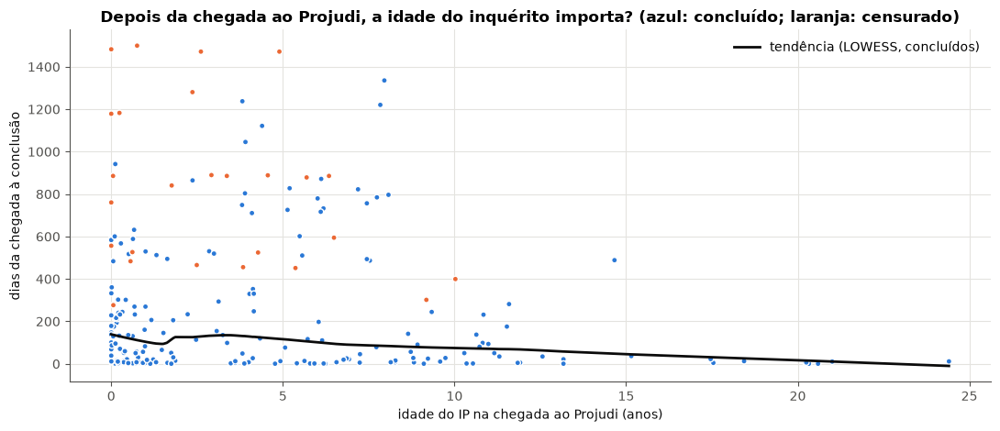

In [121]:
def teste_tsai(entrada, saida, evento):
    entrada, saida, evento = map(np.asarray, (entrada, saida, evento))
    k_total, variancia, pares = 0.0, 0.0, 0
    for i in np.flatnonzero(evento):
        risco = (entrada <= saida[i]) & (saida >= saida[i])
        r = risco.sum()
        k_total += np.sign(entrada[risco] - entrada[i]).sum()
        variancia += (r ** 2 - 1) / 3
        pares += r - 1
    z = k_total / np.sqrt(variancia)
    return {'K': k_total, 'Pares comparáveis': pares, 'tau condicional': k_total / pares, 'z': z, 'p-valor': 2 * stats.norm.sf(abs(z))}


coorte_2022 = dados['Ano_instauracao'].ge(2022).to_numpy()
display(pd.DataFrame({
    'Amostra completa': teste_tsai(ENTRADA, T_TOTAL, EVENTO),
    'Instaurados a partir de 2022': teste_tsai(ENTRADA[coorte_2022], T_TOTAL[coorte_2022], EVENTO[coorte_2022]),
    'Instaurados antes de 2022': teste_tsai(ENTRADA[~coorte_2022], T_TOTAL[~coorte_2022], EVENTO[~coorte_2022]),
}).T.round(4))
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.scatter(ENTRADA / 365.25, T_TOTAL - ENTRADA, c=np.where(evento, COR_PRINCIPAL, COR_DESTAQUE), s=20, edgecolor='white')
suave = lowess((T_TOTAL - ENTRADA)[evento], (ENTRADA / 365.25)[evento], frac=0.5)
ax.plot(suave[:, 0], suave[:, 1], color=TINTA, linewidth=2, label='tendência (LOWESS, concluídos)')
ax.set_xlabel('idade do IP na chegada ao Projudi (anos)')
ax.set_ylabel('dias da chegada à conclusão')
ax.set_title('Depois da chegada ao Projudi, a idade do inquérito importa? (azul: concluído; laranja: censurado)')
ax.legend()
plt.tight_layout()
plt.show()

**Leitura: o principal resultado metodológico da Etapa 1.**

1. **O estimador muda a resposta em uma ordem de grandeza.** A mediana do tempo total é:
   - 1.332 dias só com os concluídos;
   - 1.764 dias com a censura tratada;
   - **140 dias** com a entrada tardia.
2. **A correção por entrada tardia também falha.** O teste de Tsai rejeita a quase-independência: tau = −0,31 (z = −6,2; p < 0,001) na amostra completa, −0,26 nos instaurados a partir de 2022 e −0,36 nos anteriores. Quem chegou ao Projudi mais velho conclui **antes**. **O relógio que governa a conclusão é o tempo desde a chegada ao Projudi, e não desde a instauração**: os IPs antigos migrados são arquivados pouco depois de chegar.
3. **Consequência:** a amostra não permite estimar o tempo total do inquérito sem viés.
   - 1.764 dias superestima, porque os casos longos têm mais chance de estar na amostra;
   - 140 dias depende de uma hipótese rejeitada.

   O que a base mede bem é a **fase judicial**, e é ela que a Etapa 2 compara com a população.

### 21.4 Tempo total: comparações com entrada tardia e na coorte recente

Como a quase-independência é rejeitada, o tempo total é lido de duas formas:

1. **amostra completa com entrada tardia:** cada variável é testada por um Cox univariado com entrada tardia, porque o log-rank não admite truncamento;
2. **coorte instaurada a partir de 2022:** o truncamento é pequeno, e usam-se Kaplan-Meier e log-rank.

O modelo de Cox multivariável com entrada tardia fecha a seção.

,p Cox com entrada tardia (amostra completa),p log-rank (coorte ≥ 2022),p Cox com entrada tardia (amostra completa) — BH,p log-rank (coorte ≥ 2022) — BH
Comarca,0.00,0.54,0.01,0.68
Delegacia_top6,0.01,0.60,0.02,0.68
Tipo_delegacia,0.89,0.49,0.89,0.68
Assunto_grupo,0.10,0.47,0.15,0.68
Artigo_principal,0.67,0.31,0.77,0.68
Forma_instauracao,0.00,0.68,0.00,0.73
Reu_preso,0.00,0.56,0.00,0.68
Arma_de_fogo,0.77,0.18,0.82,0.68
Tentativa,0.46,0.46,0.57,0.68
Qualificadora_capitulada,0.01,0.36,0.03,0.68


Coorte instaurada a partir de 2022: 89 inquéritos; mediana KM do tempo total = 342 dias


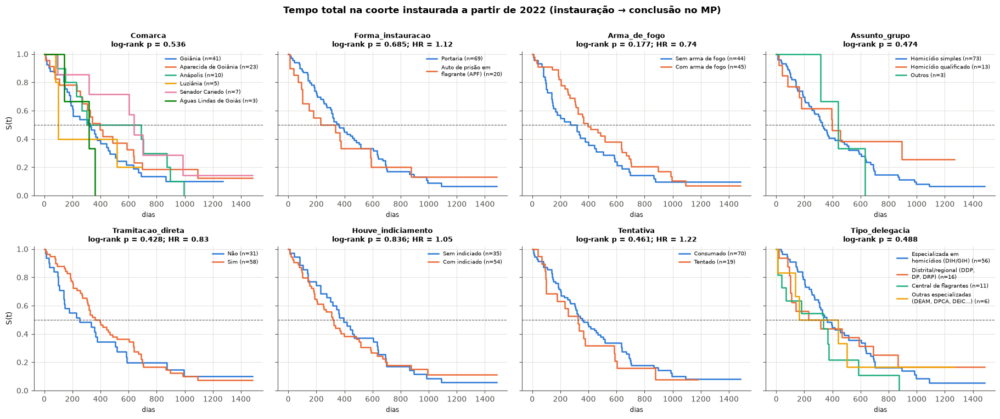

Amostra completa (entrada tardia): n = 218; eventos = 192; razão de verossimilhança: p = 4.58e-06
Coorte ≥ 2022 (entrada tardia): n = 89; eventos = 78; razão de verossimilhança: p = 9.07e-04


Amostra completa (entrada tardia)         Coorte ≥ 2022 (entrada tardia)        
                                                                                   HR p-valor                             HR p-valor
covariate                                                                                                                           
Comarca=Anápolis                                                                 1.18    0.51                           0.83    0.62
Comarca=Aparecida de Goiânia                                                     1.81    0.01                           0.95    0.89
Comarca=Luziânia                                                                 1.37    0.41                           1.68    0.35
Comarca=Senador Canedo                                                           0.57    0.10                           0.26    0.01
Comarca=Águas Lindas de Goiás                                                    1.69    0.22                           0.71    0.61
Assunto_grupo=Homicídio qualificado                                              0.60    0.02                           0.28    0.00
Assunto_grupo=Outros                                                             1.42    0.44                           0.81    0.76
Forma_instauracao=Auto de prisão em flagrante (APF)                              0.33    0.00                           0.38    0.06
Arma_de_fogo                                                                     0.72    0.09                           0.62    0.11
Tentativa                                                                        1.59    0.07                           1.62    0.29
Tramitacao_direta                                                                1.22    0.29                           1.83    0.09
Multiplas_vitimas                                                                0.62    0.12                           0.89    0.79
Houve_indiciamento                                                               0.63    0.02                           0.55    0.05

Distribuições com censura e entrada tardia (tempo total):


,Parâmetros,log-verossimilhança,AIC,BIC,Mediana (dias),Estimativas,ΔAIC,ΔBIC
Família,,,,,,,,
Gama generalizada,3,"-1,295.49","2,596.99","2,607.14",118.65,"mu = 5.91, ln_sigma = 0.272, lambda = 1.99",0.00,1.07
Gama,2,"-1,297.65","2,599.30","2,606.07",139.73,"k = 0.672, theta = 366",2.31,0.00
Weibull,2,"-1,299.18","2,602.35","2,609.12",170.16,"lambda = 255, rho = 0.904",5.36,3.05
Exponencial,1,"-1,300.48","2,602.96","2,606.34",222.92,lambda = 322,5.97,0.27
Lognormal,2,"-1,331.19","2,666.37","2,673.14",137.30,"mu = 4.92, sigma = 0.863",69.39,67.07
Log-logística,2,"-1,367.46","2,738.91","2,745.68",176.72,"alpha = 177, beta = 2.5",141.93,139.61


,LR,gl,p-valor
H₀ (modelo restrito),,,
Weibull (λ = 1),7.363,1,0.006656
Lognormal (λ = 0),71.39,1,2.937e-17
Gama (λ = σ),4.314,1,0.0378
Exponencial (λ = 1 e σ = 1),9.967,2,0.006848


In [122]:
def cox_univariado(df, duracao, ev, v, entrada=None):
    x = pd.get_dummies(serie_exibicao(df, v).astype(object).where(df[v].notna(), None), drop_first=True, dtype=float)
    validos = df[v].notna().to_numpy()
    base = x[validos].assign(T=duracao[validos], E=ev[validos])
    if entrada is not None:
        base['Entrada'] = entrada[validos]
    if x.shape[1] == 0 or base['E'].sum() < 5:
        return np.nan
    try:
        modelo = CoxPHFitter(penalizer=1e-4).fit(base, 'T', 'E', entry_col='Entrada' if entrada is not None else None)
    except Exception:
        return np.nan
    return modelo.log_likelihood_ratio_test().p_value


testes_total = pd.DataFrame({
    'p Cox com entrada tardia (amostra completa)': {ROTULO_VARIAVEL.get(v, v): cox_univariado(dados, T_TOTAL, EVENTO, v, ENTRADA)
                                                   for v in VARIAVEIS_CASO + ['Ano_recebimento_projudi']},
    'p log-rank (coorte ≥ 2022)': {
        ROTULO_VARIAVEL.get(v, v): (multivariate_logrank_test(T_TOTAL[coorte_2022 & dados[v].notna().to_numpy()],
                                                              serie_exibicao(dados, v)[coorte_2022 & dados[v].notna().to_numpy()].astype(str),
                                                              EVENTO[coorte_2022 & dados[v].notna().to_numpy()]).p_value
                                    if serie_exibicao(dados, v)[coorte_2022].nunique() > 1 else np.nan)
        for v in VARIAVEIS_CASO + ['Ano_recebimento_projudi']},
})
for coluna in list(testes_total.columns):
    validos = testes_total[coluna].notna()
    testes_total.loc[validos, coluna + ' — BH'] = multipletests(testes_total.loc[validos, coluna], method='fdr_bh')[1]
display(testes_total.round(4))

print(f'Coorte instaurada a partir de 2022: {int(coorte_2022.sum())} inquéritos; mediana KM do tempo total = '
      f'{KaplanMeierFitter().fit(T_TOTAL[coorte_2022], EVENTO[coorte_2022]).median_survival_time_:.0f} dias')
km_tot_coorte = grade_km(dados[coorte_2022], T_TOTAL[coorte_2022], EVENTO[coorte_2022],
                         ['Comarca', 'Forma_instauracao', 'Arma_de_fogo', 'Assunto_grupo', 'Tramitacao_direta', 'Houve_indiciamento',
                          'Tentativa', 'Tipo_delegacia'],
                         'Tempo total na coorte instaurada a partir de 2022 (instauração → conclusão no MP)')

cov_total = matriz_desenho(dados, ['Comarca', 'Assunto_grupo', 'Forma_instauracao'], COX_BINARIAS, [])
resultados_total = {}
for rotulo, mascara in [('Amostra completa (entrada tardia)', np.ones(len(dados), dtype=bool)), ('Coorte ≥ 2022 (entrada tardia)', coorte_2022)]:
    base = cov_total[mascara].assign(T=T_TOTAL[mascara], E=EVENTO[mascara], Entrada=ENTRADA[mascara])
    base = base.loc[:, base.std() > 0]
    modelo = CoxPHFitter(penalizer=0.01).fit(base, 'T', 'E', entry_col='Entrada')
    resultados_total[rotulo] = modelo.summary[['exp(coef)', 'p']].set_axis(['HR', 'p-valor'], axis=1)
    print(f'{rotulo}: n = {int(mascara.sum())}; eventos = {int(EVENTO[mascara].sum())}; '
          f'razão de verossimilhança: p = {modelo.log_likelihood_ratio_test().p_value:.2e}')
display(pd.concat(resultados_total, axis=1).round(3))

ajustes_tot_tr, tabela_tot_tr = ajustar_familias(T_TOTAL, EVENTO, entrada=ENTRADA)
print('Distribuições com censura e entrada tardia (tempo total):')
display(tabela_tot_tr.round(2))
with pd.option_context('display.float_format', lambda v: f'{v:.4g}'):
    display(razao_verossimilhanca(ajustes_tot_tr))

**Leitura.** No tempo total, o recorte muda as conclusões:

- **Amostra completa com entrada tardia:** quase tudo é "significativo" no Cox univariado (comarca, APF, réu preso, qualificadora, tramitação direta, indiciamento). Mas essas comparações herdam a quase-independência rejeitada.
- **Coorte instaurada a partir de 2022 (89 IPs, truncamento pequeno):** **nenhuma** variável do caso separa as curvas após BH. A mediana de Kaplan-Meier do tempo total é de **342 dias**, e só o ano de recebimento difere (p BH = 0,01).
- **No multivariável, três efeitos aparecem nos dois recortes:**
  - **homicídio qualificado**: HR 0,60 e 0,28;
  - **APF**: HR 0,33 e 0,38;
  - **indiciado**: HR 0,63 e 0,55.

  São as marcas do caminho da responsabilização, que não termina num arquivamento rápido.
- **Famílias paramétricas com entrada tardia:** a gama generalizada é preferida (× Weibull p = 0,007; × gama p = 0,04), mas sob a mesma hipótese rejeitada.

---

# PARTE IV — ETAPA 2: A POPULAÇÃO DO ESTADO NO DATAJUD

## 22. Os Inquéritos de CVLI de Goiás na Base Nacional do Poder Judiciário

### 22.1 Por que complementar e o que o DataJud permite

A Etapa 1 deixou quatro lacunas que a amostra não resolve:

| Lacuna da amostra | O que o DataJud oferece | Limite |
|---|---|---|
| Truncamento: só entram IPs que chegaram ao Projudi em 2022–2025 | Todos os processos eletrônicos, com a **data de ajuizamento** e o movimento de **conversão de autos físicos**, que permite separar os nativos digitais (sem truncamento) dos convertidos | Processos físicos encerrados antes da digitalização não estão na base |
| n = 218 e categorias raras | Cerca de 37 mil processos de CVLI no Estado | Só dados estruturados (classe, assunto, órgão, movimentos) |
| Seis comarcas | Todos os municípios, para comparar as comarcas-alvo com o restante do Estado | — |
| Sem identificação dos processos | — | A amostra não tem o número CNJ, e o vínculo individual só é possível por aproximação (22.11) |

**O que não vem do DataJud:** delegacia, arma de fogo, número de vítimas e de indiciados, texto das diligências e datas do fato e da instauração. A comparação se faz pelas variáveis que **as duas bases** têm, ou que podem ser aproximadas pelos movimentos da Tabela Processual Unificada (TPU) do CNJ.

**Coleta.** O script `src/coleta_datajud.py` consulta a API pública e grava um cache local (`dat/datajud/`), que este notebook lê sem depender da API. Ele busca dois conjuntos no TJGO:

- **(A)** inquéritos policiais e autos de prisão em flagrante (classes 279 e 280);
- **(B)** ações penais (classes 282 e 283) que nasceram de inquérito e **mudaram de classe com a denúncia** (movimento 14739, "Evolução da Classe Processual", mesmo número de processo);
- **(C)** ações penais que tiveram a mesma mudança registrada como "Retificação de Classe Processual" (14738), sem o movimento de evolução.

Sem (B) e (C), os inquéritos que viraram ação penal sumiriam da base, e a taxa de denúncia seria subestimada. Na coorte de 2022 em diante, (B) e (C) cobrem 95% das ações penais de CVLI (5.617 de 5.928). As 311 restantes foram distribuídas já como ação penal, sem o histórico do inquérito no mesmo número. Como não têm o marco de início do inquérito, ficam fora da análise do tempo.

**O que se mede.** O DataJud registra o inquérito **a partir da sua chegada ao Judiciário** (o ajuizamento). A data de instauração pela polícia não existe na base. Por isso, a comparação com a amostra se faz pela **fase judicial**, que tem o mesmo marco inicial nas duas bases (22.4).

In [123]:
PASTA_DATAJUD = PASTA_ESTUDO / 'dat' / 'datajud'
PASTA_IBGE = PASTA_ESTUDO / 'dat' / 'ibge'
ARQUIVO_MANIFESTO = PASTA_DATAJUD / 'manifesto.json'
if ARQUIVO_MANIFESTO.exists():
    manifesto = json.loads(ARQUIVO_MANIFESTO.read_text(encoding='utf-8'))
    print(f"Fonte: {manifesto['fonte']}")
    print(f"Coleta: {manifesto['inicio_coleta_utc'][:16]} a {manifesto['fim_coleta_utc'][:16]} (UTC)")
    display(pd.DataFrame({'Coletados': manifesto['processos'], 'Soma das fatias na API': manifesto['total_api_fatias'],
                          'Total sem fatiar na API': manifesto['total_api_sem_fatiar']}))
else:  # coleta ainda em andamento: usa o que já está no cache e a data de modificação mais recente
    ultima = max(a.stat().st_mtime for a in PASTA_DATAJUD.glob('*.jsonl.gz'))
    manifesto = {'fim_coleta_utc': pd.Timestamp(ultima, unit='s').isoformat()}
    print('ATENÇÃO: coleta incompleta (sem manifesto). Resultados provisórios.')
estados = pd.DataFrame({a.name.replace('.estado.json', ''): json.loads(a.read_text(encoding='utf-8'))
                        for a in PASTA_DATAJUD.glob('*.estado.json')}).T
print(f"Fatias concluídas: {int(estados['fim'].astype(bool).sum())} de {len(estados)}; "
      f"processos no cache: {int(estados['n'].sum()):,} de {int(pd.to_numeric(estados['total_api'], errors='coerce').sum()):,} informados pela API")

registros = []
for arquivo in sorted(PASTA_DATAJUD.glob('*.jsonl.gz')):
    segmento = arquivo.name.split('__')[0]
    try:
        with gzip.open(arquivo, 'rt', encoding='utf-8') as f:
            for linha in f:
                try:
                    r = json.loads(linha)
                except json.JSONDecodeError:  # linha final incompleta durante a coleta
                    continue
                r['segmento'] = segmento
                registros.append(r)
    except (EOFError, OSError):  # bloco gzip ainda sendo gravado
        pass
print(f'{len(registros):,} registros lidos de {len(list(PASTA_DATAJUD.glob("*.jsonl.gz")))} fatias')

ValueError: max() iterable argument is empty

### 22.2 Curadoria dos dados do DataJud

A curadoria segue o mesmo rigor da Etapa 1:

1. **Duplicidade:** um processo pode aparecer em mais de um grau ou sistema. Mantém-se um registro por número CNJ: o de 1º grau com mais movimentos;
2. **Datas:** `dataAjuizamento` vem como texto `aaaammddhhmmss` (às vezes com 8 dígitos ou em ISO). A conversão tolera os três formatos, e datas impossíveis viram `NaT` e são registradas;
3. **Município e comarca:** o código IBGE do órgão julgador é traduzido pelo cadastro do IBGE (`dat/ibge/`), e as seis comarcas da amostra são marcadas;
4. **Assuntos:** o processo pode ter vários. A partir deles constroem-se três atributos (22.3);
5. **Movimentos:** cada movimento da TPU vira data de evento ou indicador (22.4).

In [ ]:
def data_datajud(valor):
    if valor is None or (isinstance(valor, float) and np.isnan(valor)):
        return pd.NaT
    texto = re.sub(r'\D', '', str(valor))
    for formato, tamanho in (('%Y%m%d%H%M%S', 14), ('%Y%m%d', 8)):
        if len(texto) >= tamanho:
            data = pd.to_datetime(texto[:tamanho], format=formato, errors='coerce')
            if pd.notna(data) and pd.Timestamp('1950-01-01') <= data <= pd.Timestamp('2027-12-31'):
                return data
    return pd.NaT


def lista_assuntos(r):
    codigos = []
    for a in r.get('assuntos') or []:
        for item in (a if isinstance(a, list) else [a]):
            if isinstance(item, dict) and item.get('codigo') is not None:
                codigos.append(int(item['codigo']))
    return codigos


municipios_ibge = pd.DataFrame([{'Codigo_IBGE': int(m['id']), 'Municipio': m['nome'],
                                 'Mesorregiao': (m.get('microrregiao') or {}).get('mesorregiao', {}).get('nome')}
                                for m in json.loads((PASTA_IBGE / 'municipios_go.json').read_text(encoding='utf-8'))])
populacao = json.loads((PASTA_IBGE / 'populacao_censo2022_go.json').read_text(encoding='utf-8'))[0]['resultados'][0]['series']
municipios_ibge = municipios_ibge.merge(pd.DataFrame([{'Codigo_IBGE': int(s['localidade']['id']), 'Populacao_2022': int(s['serie']['2022'])}
                                                      for s in populacao]), on='Codigo_IBGE', how='left').set_index('Codigo_IBGE')
CODIGO_IBGE_COMARCA = {'Goiânia': 5208707, 'Aparecida de Goiânia': 5201405, 'Anápolis': 5201108, 'Senador Canedo': 5220454,
                       'Luziânia': 5212501, 'Águas Lindas de Goiás': 5200258}

linhas = []
for r in registros:
    orgao = r.get('orgaoJulgador') or {}
    movimentos = r.get('movimentos') or []
    linhas.append({
        'Numero_processo': str(r.get('numeroProcesso')), 'Segmento': r['segmento'], 'Grau': r.get('grau'),
        'Sistema': (r.get('sistema') or {}).get('nome'), 'Classe': (r.get('classe') or {}).get('codigo'),
        'Classe_nome': (r.get('classe') or {}).get('nome'), 'Orgao': orgao.get('nome'),
        'Codigo_IBGE': pd.to_numeric(orgao.get('codigoMunicipioIBGE'), errors='coerce'),
        'Ajuizamento_bruto': r.get('dataAjuizamento'), 'Data_ajuizamento': data_datajud(r.get('dataAjuizamento')),
        'Assuntos': lista_assuntos(r), 'N_movimentos': len(movimentos), 'Movimentos': movimentos,
        'Ultima_atualizacao': pd.to_datetime(r.get('dataHoraUltimaAtualizacao'), errors='coerce', utc=True),
    })
pop = pd.DataFrame(linhas)
n_bruto = len(pop)
pop = (pop.assign(_g1=pop['Grau'].eq('G1'))
          .sort_values(['Numero_processo', '_g1', 'N_movimentos'], ascending=[True, False, False])
          .drop_duplicates('Numero_processo').drop(columns='_g1').set_index('Numero_processo'))
pop['Municipio'] = pop['Codigo_IBGE'].map(municipios_ibge['Municipio'])
pop['Mesorregiao'] = pop['Codigo_IBGE'].map(municipios_ibge['Mesorregiao'])
pop['Comarca_alvo'] = pop['Codigo_IBGE'].map({v: k for k, v in CODIGO_IBGE_COMARCA.items()}).fillna('Demais municípios')

DATA_COLETA_DJ = pd.Timestamp(manifesto['fim_coleta_utc'][:10])
curadoria_dj = pd.DataFrame([
    ('Registros lidos', n_bruto), ('Duplicados removidos (mesmo número CNJ)', n_bruto - len(pop)),
    ('Processos únicos', len(pop)), ('Sem data de ajuizamento válida', int(pop['Data_ajuizamento'].isna().sum())),
    ('Ajuizamento posterior à coleta', int((pop['Data_ajuizamento'] > DATA_COLETA_DJ).sum())),
    ('Sem município (código IBGE)', int(pop['Municipio'].isna().sum())),
    ('Sem nenhum movimento', int(pop['N_movimentos'].eq(0).sum())),
], columns=['Verificação', 'Processos']).set_index('Verificação')
display(curadoria_dj)
display(pd.crosstab(pop['Classe_nome'], pop['Segmento'], margins=True, margins_name='Total'))

,Processos
Verificação,
Registros lidos,36548
Duplicados removidos (mesmo número CNJ),34
Processos únicos,36514
Sem data de ajuizamento válida,0
Ajuizamento posterior à coleta,0
Sem município (código IBGE),0
Sem nenhum movimento,0


Segmento,acao_penal_evoluida,acao_penal_retificada,ip_apf,Total
Classe_nome,,,,
Auto de Prisão em Flagrante,0,0,598,598
Ação Penal - Procedimento Ordinário,1511,180,0,1691
Ação Penal de Competência do Júri,11542,1115,0,12657
Inquérito Policial,0,0,21568,21568
Total,13053,1295,22166,36514


### 22.3 Operacionalização de CVLI e MVI

**O conceito no material da disciplina.** A Tabela 01 do estudo de caso seleciona os municípios do **Pronasci II** no Centro-Oeste pela **taxa de Mortes Violentas Intencionais (MVI)** de 2022 (FBSP/MJSP). As seis comarcas da amostra são justamente os municípios goianos dessa lista. Há dois indicadores oficiais:

- **CVLI (Crimes Violentos Letais Intencionais, Senasp/MJSP):** homicídio doloso (inclusive o feminicídio), latrocínio e lesão corporal seguida de morte;
- **MVI (FBSP):** CVLI mais as **mortes decorrentes de intervenção policial**.

**Tradução para a TPU.** O assunto do processo vira três atributos, cada um uma partição:

| Atributo | Regra | Categorias |
|---|---|---|
| `Tipo_cvli` | assunto mais específico presente, na ordem feminicídio → latrocínio → homicídio qualificado → privilegiado → simples → homicídio (n.e.) → lesão corporal seguida de morte | 7 tipos |
| `Modalidade` | **culposo** se houver o assunto "Crime Culposo" (5865) ou "Crimes de Trânsito" (3632); **tentado** se houver "Crime Tentado" (5555); senão **consumado** | consumado, tentado, culposo |
| `Categoria_indicador` | consumado → **CVLI**; tentado → **tentativa de CVLI**; culposo → **fora do indicador** | 3 classes |

As **mortes por intervenção policial** não têm assunto próprio na TPU e não podem ser separadas no DataJud. Por isso o DataJud mede CVLI, e não MVI. Na amostra, o indício textual de intervenção estatal (14 casos) faz essa ponte. A amostra inclui tentativas (42 casos); para comparar, a população é filtrada da mesma forma: consumados mais tentados, sem os culposos.

In [ ]:
TIPOS_CVLI = [('Feminicídio', {12091}), ('Latrocínio', {5567, 11159}), ('Homicídio qualificado', {3372, 9638}),
              ('Homicídio privilegiado', {3371, 9637}), ('Homicídio simples', {3370, 9636}),
              ('Homicídio (espécie não especificada)', {11243}), ('Lesão corporal seguida de morte', {3387, 9643})]
CULPOSO, TENTADO = {5865, 3632}, {5555}


def tipo_cvli(codigos):
    codigos = set(codigos)
    return next((nome for nome, conjunto in TIPOS_CVLI if codigos & conjunto), None)


pop['Tipo_cvli'] = para_categoria(pop['Assuntos'].map(tipo_cvli), {n: n for n, _ in TIPOS_CVLI}, [n for n, _ in TIPOS_CVLI])
pop['Modalidade'] = para_categoria(pop['Assuntos'].map(
    lambda c: 'Culposo' if set(c) & CULPOSO else 'Tentado' if set(c) & TENTADO else 'Consumado'),
    {m: m for m in ['Consumado', 'Tentado', 'Culposo']}, ['Consumado', 'Tentado', 'Culposo'])
pop['Categoria_indicador'] = para_categoria(pop['Modalidade'].astype(str),
                                            {'Consumado': 'CVLI', 'Tentado': 'Tentativa de CVLI', 'Culposo': 'Fora do indicador (culposo)'},
                                            ['CVLI', 'Tentativa de CVLI', 'Fora do indicador (culposo)'])
display(verificar_particao(pop['Tipo_cvli']))
display(verificar_particao(pop['Categoria_indicador']))
display(pd.crosstab(pop['Tipo_cvli'], pop['Categoria_indicador'], margins=True, margins_name='Total'))

,Casos,%
Tipo_cvli,,
Feminicídio,765,2.10
Latrocínio,463,1.27
Homicídio qualificado,11659,31.93
Homicídio privilegiado,332,0.91
Homicídio simples,22782,62.39
Homicídio (espécie não especificada),287,0.79
Lesão corporal seguida de morte,226,0.62


,Casos,%
Categoria_indicador,,
CVLI,27520,75.37
Tentativa de CVLI,8652,23.70
Fora do indicador (culposo),342,0.94


Categoria_indicador,CVLI,Tentativa de CVLI,Fora do indicador (culposo),Total
Tipo_cvli,,,,
Feminicídio,396,365,4,765
Latrocínio,400,63,0,463
Homicídio qualificado,8252,3355,52,11659
Homicídio privilegiado,262,67,3,332
Homicídio simples,17701,4801,280,22782
Homicídio (espécie não especificada),286,1,0,287
Lesão corporal seguida de morte,223,0,3,226
Total,27520,8652,342,36514


### 22.4 A linha do tempo do inquérito no DataJud: início, retorno da polícia, manifestação do MP e decisão

Cada ato do processo é registrado com um código da Tabela Processual Unificada (TPU) do CNJ. A API pública **não informa quem praticou o ato**: polícia, MP ou juízo. Por isso, os marcos do inquérito são reconstruídos a partir de **movimentos característicos**. A análise exploratória dos 13,5 mil processos de 2022 em diante sustenta estas definições:

| Marco | Definição operacional | Por que tem sentido no negócio |
|---|---|---|
| **Início** | data de ajuizamento: a **distribuição do IP ao juízo** | coincide com o primeiro movimento em 99,9% dos casos. É o mesmo marco do "recebimento no Projudi" da amostra |
| **Retorno da polícia** (proxy do fim da investigação) | último movimento 15000, "**Finalizada** tramitação direta entre MP e autoridade policial", antes do desfecho | marca a volta dos autos da polícia ao sistema judicial. Só existe nos IPs com tramitação direta |
| **Manifestação final do MP** | última petição do tipo **Denúncia**, **Parecer**, **Parecer de mérito (MP)** ou **Parecer falta de interesse (MP)** antes do desfecho | é o equivalente da "conclusão no MP" da amostra: o promotor oferece denúncia ou pede o arquivamento |
| **Desfecho judicial** (evento principal) | primeiro entre: recebimento da denúncia (391) ou mudança para ação penal (evolução 14739; retificação 14738 no segmento C); determinação de arquivamento (1063), arquivamento (12430) ou arquivamento definitivo (246); extinção da punibilidade por prescrição (11878) ou morte do agente (1042) | é o ato que **encerra** a fase investigativa. É objetivo e está presente em todos os processos encerrados |

A partir desses marcos, três durações são medidas:

- **Fase judicial** = início → desfecho judicial. É o desfecho principal, comparável à fase judicial da amostra. Nos casos sem desfecho até a coleta, é censurada;
- **Até o MP** = início → manifestação final do MP. É o análogo direto da medida da amostra, mas só existe quando a petição do MP está registrada;
- **Fase policial (proxy)** = início → retorno da polícia, só nos IPs com tramitação direta.

**Diferença em relação à amostra.** O evento da amostra é a manifestação do MP; aqui, o principal é o ato judicial que a acolhe. Por isso, cada comparação informa a defasagem entre os dois. Um arquivamento seguido de desarquivamento é uma **reabertura**: a análise usa o primeiro encerramento e conta as reaberturas.

In [ ]:
MOVIMENTOS_INTERESSE = {
    # código: (papel, descrição)
    14732: ('conversao', 'Conversão de autos físicos em eletrônicos'),
    14999: ('td_inicio', 'Iniciada tramitação direta MP–polícia'),
    15000: ('retorno_policia', 'Finalizada tramitação direta MP–polícia (retorno dos autos da polícia)'),
    1063: ('arquivamento', 'Determinação de arquivamento de procedimento investigatório'),
    12430: ('arquivamento', 'Arquivamento'),
    246: ('arquivamento', 'Arquivamento definitivo'),
    893: ('desarquivamento', 'Desarquivamento (reabertura)'),
    391: ('denuncia', 'Recebimento da denúncia'),
    14739: ('denuncia', 'Evolução da classe processual (IP → ação penal)'),
    11878: ('extincao', 'Extinção da punibilidade: prescrição'),
    1042: ('extincao', 'Extinção da punibilidade: morte do agente'),
    12332: ('prorrogacao', 'Prorrogado o prazo de conclusão do inquérito'),
    12742: ('custodia', 'Audiência de custódia'),
    12140: ('preventiva', 'Conversão do flagrante em preventiva'),
    818: ('liberdade_provisoria', 'Liberdade provisória'),
    85: ('peticao', 'Petição (o tipo vem no complemento)'),
    14738: ('retificacao_classe', 'Retificação da classe processual (nas ações penais do segmento C, marca a denúncia)'),
}
PETICOES_MP = {'Denúncia', 'Parecer', 'Parecer de Mérito (MP)', 'Parecer Falta de Interesse (MP)'}
PAPEIS_FIM = ('denuncia', 'arquivamento', 'extincao')


def linha_do_tempo(movimentos, retificacao_e_denuncia=False):
    """Datas dos marcos do inquérito a partir dos movimentos (datas como texto aaaa-mm-dd, para rapidez)."""
    datas = defaultdict(list)
    for m in movimentos:
        papel = MOVIMENTOS_INTERESSE.get(m.get('codigo'), (None,))[0]
        if papel == 'retificacao_classe':
            papel = 'denuncia' if retificacao_e_denuncia else None
        data = (m.get('dataHora') or '')[:10]
        if papel is None or len(data) != 10:
            continue
        if papel == 'peticao':
            tipos = {c.get('nome') for c in m.get('complementosTabelados') or []}
            if tipos & PETICOES_MP:
                datas['peticao_mp'].append(data)
            continue
        datas[papel].append(data)
        if m.get('codigo') == 11878:
            datas['prescricao'].append(data)
    fins = {p: min(datas[p]) for p in PAPEIS_FIM if datas[p]}
    fim = min(fins.values()) if fins else None
    tipo_fim = min(fins, key=fins.get) if fins else None
    antes = lambda lista: max([d for d in lista if fim is None or d <= fim], default=None)
    return {'Data_fim': fim, 'Papel_fim': tipo_fim, 'Data_conversao': min(datas['conversao'], default=None),
            'Data_retorno_policia': antes(datas['retorno_policia']), 'Data_manifestacao_mp': antes(datas['peticao_mp']),
            'Data_desarquivamento': min(datas['desarquivamento'], default=None),
            **{f'N_{p}': len(datas[p]) for p in ['td_inicio', 'retorno_policia', 'arquivamento', 'desarquivamento', 'denuncia',
                                                 'extincao', 'prescricao', 'prorrogacao', 'custodia', 'preventiva',
                                                 'liberdade_provisoria', 'peticao_mp']}}


eventos_dj = pd.DataFrame([linha_do_tempo(movs, seg == 'acao_penal_retificada') for movs, seg in zip(pop['Movimentos'], pop['Segmento'])],
                          index=pop.index)
for c in [c for c in eventos_dj if c.startswith('Data_')]:
    eventos_dj[c] = pd.to_datetime(eventos_dj[c], errors='coerce')
pop = pop.join(eventos_dj)

presenca = pd.DataFrame([{'Código TPU': c, 'Papel': p, 'Descrição': d,
                          'Processos com o movimento (%)': 100 * pop['Movimentos'].map(lambda ms, c=c: any(m.get('codigo') == c for m in ms)).mean()}
                         for c, (p, d) in MOVIMENTOS_INTERESSE.items()]).set_index('Código TPU')
display(presenca.round(1))

MAPA_FIM = {'denuncia': 'Denúncia', 'arquivamento': 'Arquivamento', 'extincao': 'Extinção da punibilidade'}
pop['Tipo_fim'] = para_categoria(pop['Papel_fim'].map(MAPA_FIM).fillna('Em curso'),
                                 {k: k for k in ['Arquivamento', 'Denúncia', 'Extinção da punibilidade', 'Em curso']},
                                 ['Arquivamento', 'Denúncia', 'Extinção da punibilidade', 'Em curso'])
pop['Evento_fim'] = pop['Data_fim'].notna()
pop['Convertido'] = pop['Data_conversao'].notna()
pop['Fim_observado'] = pop['Data_fim'].fillna(DATA_COLETA_DJ)
pop['Tempo_judicial_dj'] = (pop['Fim_observado'] - pop['Data_ajuizamento'].dt.normalize()).dt.days
pop['Tempo_ate_mp_dj'] = (pop['Data_manifestacao_mp'] - pop['Data_ajuizamento'].dt.normalize()).dt.days
pop['Tempo_policial_proxy_dj'] = (pop['Data_retorno_policia'] - pop['Data_ajuizamento'].dt.normalize()).dt.days
pop['Defasagem_mp_decisao'] = (pop['Data_fim'] - pop['Data_manifestacao_mp']).dt.days
pop['Ano_ajuizamento'] = pop['Data_ajuizamento'].dt.year
pop['APF'] = pop['Classe'].eq(280)  # classe de origem; nas ações penais evoluídas a origem se perde (não usada em modelos)
pop['Tramitacao_direta_dj'] = pop['N_td_inicio'].gt(0)
pop['Indicio_prisao'] = pop[['N_custodia', 'N_preventiva', 'N_liberdade_provisoria']].sum(axis=1).gt(0)
pop['Houve_prorrogacao'] = pop['N_prorrogacao'].gt(0)
pop['Reaberto'] = pop['N_desarquivamento'].gt(0)

incoerencias_dj = pd.DataFrame([
    ('Desfecho anterior ao ajuizamento', int((pop['Data_fim'] < pop['Data_ajuizamento'].dt.normalize()).sum())),
    ('Manifestação do MP anterior ao ajuizamento', int((pop['Data_manifestacao_mp'] < pop['Data_ajuizamento'].dt.normalize()).sum())),
    ('Conversão anterior ao ajuizamento', int((pop['Data_conversao'] < pop['Data_ajuizamento'].dt.normalize()).sum())),
    ('Ação penal (segmentos B e C) sem marco de denúncia', int((pop['Segmento'].isin(['acao_penal_evoluida', 'acao_penal_retificada'])
                                                                & ~pop['Papel_fim'].eq('denuncia')).sum())),
    ('Encerrados sem manifestação do MP registrada', int((pop['Evento_fim'] & pop['Data_manifestacao_mp'].isna()).sum())),
], columns=['Regra de coerência', 'Processos']).set_index('Regra de coerência')
display(incoerencias_dj)

validos_dj = (pop['Data_ajuizamento'].notna() & (pop['Data_ajuizamento'] <= DATA_COLETA_DJ) & (pop['Tempo_judicial_dj'] >= 0)
              & pop['Municipio'].notna())
pop_cvli = pop[validos_dj & pop['Categoria_indicador'].ne('Fora do indicador (culposo)')].copy()
print(f'Processos analisáveis (CVLI consumado ou tentado, datas coerentes): {len(pop_cvli):,} de {len(pop):,}')

,Papel,Descrição,Processos com o movimento (%)
Código TPU,,,
14732,conversao,Conversão de autos físicos em eletrônicos,48.70
14999,td_inicio,Iniciada tramitação direta MP–polícia,22.10
15000,retorno_policia,Finalizada tramitação direta MP–polícia (retorno dos autos da polícia),22.10
1063,arquivamento,Determinação de arquivamento de procedimento investigatório,15.30
12430,arquivamento,Arquivamento,13.00
246,arquivamento,Arquivamento definitivo,74.20
893,desarquivamento,Desarquivamento (reabertura),10.40
391,denuncia,Recebimento da denúncia,38.10
14739,denuncia,Evolução da classe processual (IP → ação penal),36.70


,Processos
Regra de coerência,
Desfecho anterior ao ajuizamento,162
Manifestação do MP anterior ao ajuizamento,0
Conversão anterior ao ajuizamento,1
Ação penal (segmentos B e C) sem marco de denúncia,248
Encerrados sem manifestação do MP registrada,25622


Processos analisáveis (CVLI consumado ou tentado, datas coerentes): 36,010 de 36,514


### 22.5 A janela de tempo e o recorte que reproduz o estudo

Os processos **convertidos** são o estoque físico que sobreviveu até a digitalização e, como na amostra, sofrem truncamento. Os **nativos digitais** formam uma coorte **sem truncamento**, acompanhada desde o ajuizamento.

**O recorte que reproduz o estudo.** A amostra reúne IPs que tramitaram no Projudi de 2022 em diante. Por isso a população é recortada nos **inquéritos de CVLI ajuizados de 2022 a 2026**, no Estado inteiro, com as seis comarcas destacadas.

O gráfico da direita mostra por que os IPs antigos não podem ser identificados pela data de digitalização: o TJGO converteu quase todos os autos físicos em 2020–2021, antes da janela da amostra. A data de "recebimento no Projudi" dos IPs antigos da amostra é outro marco: a volta do inquérito à tramitação.

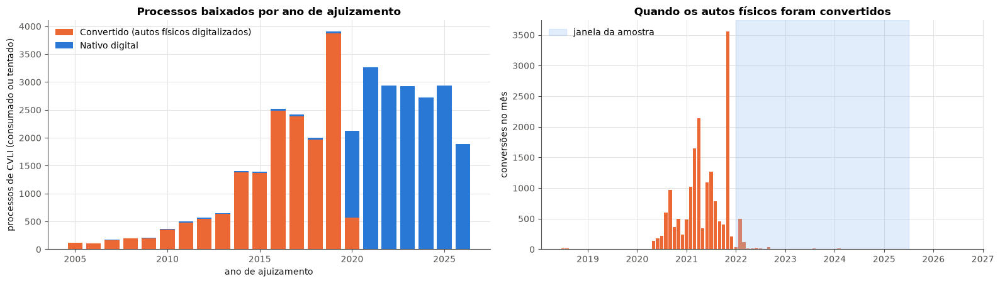

Ajuizados antes de 2022 e convertidos: 17,524; 95% digitalizados até 2021
Coorte 2022–2026 (nativa digital): 13,410 processos; 11,933 com desfecho; coleta em 01/10/2026


Tipo_fim,Arquivamento,Denúncia,Extinção da punibilidade,Em curso,Total
Comarca_alvo,,,,,
Goiânia,1254,731,34,296,2315
Aparecida de Goiânia,393,318,47,153,911
Anápolis,373,233,50,65,721
Senador Canedo,156,104,11,39,310
Luziânia,106,208,35,38,387
Águas Lindas de Goiás,141,287,14,31,473
Demais municípios,2920,3805,713,855,8293
Total,5343,5686,904,1477,13410


In [ ]:
por_ano = pd.crosstab(pop_cvli['Ano_ajuizamento'], pop_cvli['Convertido'].map({False: 'Nativo digital', True: 'Convertido'}))
por_ano['% nativos'] = 100 * por_ano.get('Nativo digital', 0) / por_ano.drop(columns='% nativos', errors='ignore').sum(axis=1)
fig, axes = plt.subplots(1, 2, figsize=(16, 4.6))
anos_plot = por_ano.loc[por_ano.index >= 2005]
axes[0].bar(anos_plot.index, anos_plot.get('Convertido', 0), color=COR_DESTAQUE, label='Convertido (autos físicos digitalizados)')
axes[0].bar(anos_plot.index, anos_plot.get('Nativo digital', 0), bottom=anos_plot.get('Convertido', 0), color=COR_PRINCIPAL, label='Nativo digital')
axes[0].set_xlabel('ano de ajuizamento')
axes[0].set_ylabel('processos de CVLI (consumado ou tentado)')
axes[0].set_title('Processos baixados por ano de ajuizamento')
axes[0].legend()
conversoes = pop_cvli.loc[pop_cvli['Convertido'], 'Data_conversao'].dt.to_period('M').value_counts().sort_index()
axes[1].bar(conversoes.index.to_timestamp(), conversoes.values, width=25, color=COR_DESTAQUE)
axes[1].axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2025-06-30'), color=COR_SECUNDARIA, alpha=0.3, label='janela da amostra')
axes[1].set_title('Quando os autos físicos foram convertidos')
axes[1].set_ylabel('conversões no mês')
axes[1].legend()
plt.tight_layout()
plt.show()

antigos = pop_cvli[pop_cvli['Ano_ajuizamento'] < 2022]
print(f'Ajuizados antes de 2022 e convertidos: {int(antigos["Convertido"].sum()):,}; '
      f'{100 * antigos["Data_conversao"].dt.year.le(2021).sum() / max(antigos["Convertido"].sum(), 1):.0f}% digitalizados até 2021')
ANO_INICIO_COORTE = 2022
coorte_dj = pop_cvli[pop_cvli['Ano_ajuizamento'].ge(ANO_INICIO_COORTE) & ~pop_cvli['Convertido']].copy()
coorte_dj['Porte_municipio'] = pd.cut(coorte_dj['Codigo_IBGE'].map(municipios_ibge['Populacao_2022']).astype(float),
                                      [0, 50_000, 200_000, 1_000_000, np.inf],
                                      labels=['até 50 mil', '50–200 mil', '200 mil–1 milhão', 'mais de 1 milhão'], ordered=True)
coorte_dj['Ano_ajuizamento_cat'] = pd.Categorical(coorte_dj['Ano_ajuizamento'], ordered=True)
coorte_dj['Comarca_alvo'] = pd.Categorical(coorte_dj['Comarca_alvo'], categories=list(CODIGO_IBGE_COMARCA) + ['Demais municípios'])
coorte_dj['Mesorregiao'] = coorte_dj['Mesorregiao'].astype('category')
coorte_dj['Modalidade'] = coorte_dj['Modalidade'].cat.remove_unused_categories()
for v in ['Indicio_prisao', 'Tramitacao_direta_dj', 'Houve_prorrogacao']:
    coorte_dj[v] = coorte_dj[v].astype('boolean')
ROTULOS_BOOLEANOS.update({'Indicio_prisao': ('Sem indício de prisão', 'Com indício de prisão'),
                          'Tramitacao_direta_dj': ('Sem TD', 'Com TD'), 'Houve_prorrogacao': ('Sem prorrogação', 'Com prorrogação')})
print(f'Coorte 2022–{DATA_COLETA_DJ.year} (nativa digital): {len(coorte_dj):,} processos; {int(coorte_dj["Evento_fim"].sum()):,} '
      f'com desfecho; coleta em {DATA_COLETA_DJ:%d/%m/%Y}')
display(pd.crosstab(coorte_dj['Comarca_alvo'], coorte_dj['Tipo_fim'], margins=True, margins_name='Total'))

**Leitura.**

- **Volume:** a base estadual tem **cerca de 34 mil processos únicos** de CVLI e correlatos: cerca de 22 mil inquéritos e APFs, e 12 mil ações penais que nasceram de inquérito.
- **Truncamento do estoque antigo:** 95% dos processos antigos convertidos foram digitalizados até 2021, antes da janela da amostra. Por isso não é possível reproduzir a amostra pela data de digitalização: a "chegada ao Projudi" dos IPs antigos da amostra é outro marco.
- **Coorte 2022–2026:**
  - **13.294 inquéritos nativos digitais**, sem truncamento;
  - **89% já com desfecho:** cerca de 5,6 mil denúncias, 5,3 mil arquivamentos e 900 extinções da punibilidade; os demais seguem em curso;
  - nas seis comarcas da amostra são cerca de 5 mil processos, com Goiânia em 2,3 mil.
- **Qualidade:**
  - cerca de 100 processos têm desfecho datado antes do ajuizamento e foram excluídos (incoerência de registro);
  - menos de 200 ações penais evoluídas não têm o marco de denúncia;
  - a manifestação do MP só está registrada como petição tipificada em parte dos casos, por isso o desfecho principal é a **decisão judicial**.

### 22.6 Descrição e normalidade na população

Mesma sequência da Etapa 1, agora na coorte estadual:

- **descrição** dos marcos, incluindo os tempos das três etapas;
- **normalidade:** Shapiro-Wilk em uma subamostra de 5 mil, porque o teste é definido até esse tamanho, e D'Agostino-Pearson na base inteira.

Com milhares de casos, qualquer desvio da normal é detectado. Por isso o gráfico Q-Q é o que mostra a **magnitude** do afastamento.

,Fase judicial (ajuizamento → desfecho judicial),Até o MP (ajuizamento → manifestação final do MP),"Fase policial, proxy (ajuizamento → retorno da polícia)"
n,"11,933.00","5,198.00","6,212.00"
Média,155.30,134.00,53.80
Desvio-padrão,241.70,217.90,123.50
CV (%),155.60,162.70,229.60
Mínimo,0.00,0.00,0.00
Q1,17.00,12.00,3.00
Mediana,50.00,34.00,13.00
Q3,167.00,147.00,48.00
Máximo,"1,689.00","1,354.00","1,482.00"
IQR,150.00,135.00,45.00


Defasagem manifestação do MP → decisão judicial (dias): mediana = 5; Q1–Q3 = 1–27
Normalidade da fase judicial (encerrados): Shapiro-Wilk (subamostra de 5,000) W = 0.644, p = 5.8e-73; D'Agostino p = 0.0e+00; assimetria = 2.47


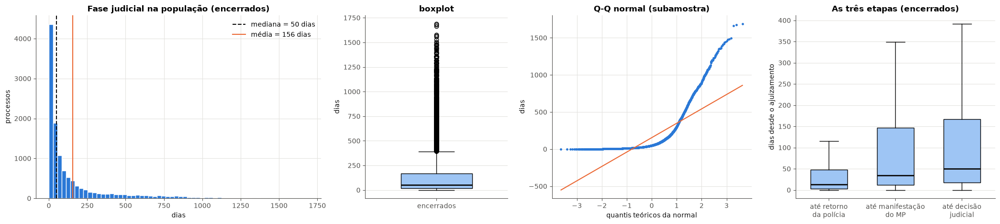

In [ ]:
concl_dj = coorte_dj[coorte_dj['Evento_fim']].copy()
DESFECHOS_DJ = {'Tempo_judicial_dj': 'Fase judicial (ajuizamento → desfecho judicial)',
                'Tempo_ate_mp_dj': 'Até o MP (ajuizamento → manifestação final do MP)',
                'Tempo_policial_proxy_dj': 'Fase policial, proxy (ajuizamento → retorno da polícia)'}
display(pd.DataFrame({r: descrever(concl_dj[v]) for v, r in DESFECHOS_DJ.items()}).round(1))
print(f"Defasagem manifestação do MP → decisão judicial (dias): mediana = {concl_dj['Defasagem_mp_decisao'].median():.0f}; "
      f"Q1–Q3 = {concl_dj['Defasagem_mp_decisao'].quantile(0.25):.0f}–{concl_dj['Defasagem_mp_decisao'].quantile(0.75):.0f}")

x_dj = concl_dj['Tempo_judicial_dj'].astype(float).to_numpy() + 0.5
sub_sw = RNG.choice(x_dj, size=min(len(x_dj), 5000), replace=False)
print(f'Normalidade da fase judicial (encerrados): Shapiro-Wilk (subamostra de {len(sub_sw):,}) W = {stats.shapiro(sub_sw).statistic:.3f}, '
      f'p = {stats.shapiro(sub_sw).pvalue:.1e}; D\'Agostino p = {stats.normaltest(x_dj).pvalue:.1e}; assimetria = {stats.skew(x_dj):.2f}')

fig, axes = plt.subplots(1, 4, figsize=(21, 4.8), gridspec_kw={'width_ratios': [2, 1, 1.4, 1.4]})
axes[0].hist(x_dj, bins=60, color=COR_PRINCIPAL, edgecolor='white')
axes[0].axvline(np.median(x_dj), color=TINTA, linestyle='--', label=f'mediana = {np.median(x_dj):.0f} dias')
axes[0].axvline(x_dj.mean(), color=COR_DESTAQUE, label=f'média = {x_dj.mean():.0f} dias')
axes[0].set_xlabel('dias')
axes[0].set_ylabel('processos')
axes[0].set_title('Fase judicial na população (encerrados)')
axes[0].legend()
axes[1].boxplot(x_dj, widths=0.5, patch_artist=True, boxprops={'facecolor': COR_SECUNDARIA}, medianprops={'color': TINTA, 'linewidth': 2})
axes[1].set_xticks([1], ['encerrados'])
axes[1].set_ylabel('dias')
axes[1].set_title('boxplot')
axes[1].grid(axis='x', visible=False)
(osm, osr), (a, b, _) = stats.probplot(sub_sw, dist='norm')
axes[2].scatter(osm, osr, s=6, color=COR_PRINCIPAL)
axes[2].plot(osm, a * osm + b, color=COR_DESTAQUE)
axes[2].set_xlabel('quantis teóricos da normal')
axes[2].set_ylabel('dias')
axes[2].set_title('Q-Q normal (subamostra)')
etapas = concl_dj[['Tempo_policial_proxy_dj', 'Tempo_ate_mp_dj', 'Tempo_judicial_dj']].astype(float)
axes[3].boxplot([etapas[c].dropna() for c in etapas], showfliers=False, patch_artist=True, widths=0.55,
                boxprops={'facecolor': COR_SECUNDARIA}, medianprops={'color': TINTA, 'linewidth': 2})
axes[3].set_xticks([1, 2, 3], ['até retorno\nda polícia', 'até manifestação\ndo MP', 'até decisão\njudicial'])
axes[3].set_ylabel('dias desde o ajuizamento')
axes[3].set_title('As três etapas (encerrados)')
axes[3].grid(axis='x', visible=False)
plt.tight_layout()
plt.show()

**Leitura.**

| Etapa (encerrados da coorte) | Mediana | Q1–Q3 |
|---|---|---|
| Fase judicial (ajuizamento → decisão) | **51 dias** | 17–167 |
| Até a manifestação do MP (cerca de 5 mil casos com petição tipificada) | 35 dias | — |
| Até o retorno da polícia (proxy, cerca de 6 mil com tramitação direta) | 13 dias | — |

- **Do MP à decisão:** o juízo decide em mediana **5 dias** depois da manifestação do MP. A decisão judicial é, portanto, um bom substituto da conclusão no MP.
- **Forma:** a distribuição é ainda mais assimétrica que na amostra (assimetria 2,5; Shapiro-Wilk W = 0,65; p < 10⁻⁷⁰). Com milhares de casos, a não normalidade é inequívoca, e os testes de postos e os modelos de duração são os adequados também aqui.

### 22.7 Testes de hipóteses na população

As mesmas famílias de testes da seção 17, agora com milhares de casos:

1. **Tipo de desfecho × variáveis:** qui-quadrado de independência, com V de Cramér e barras empilhadas. Com n grande, p pequeno é quase certo, e é o **V** que diz se a associação é relevante;
2. **Fase judicial × grupos:** Mann-Whitney e Kruskal-Wallis nos encerrados, com tamanho de efeito, boxplots e post-hoc de Dunn.

**Variáveis disponíveis na população:**

- comarca (as seis da amostra e os demais municípios), mesorregião e porte do município (Censo 2022);
- tipo de CVLI e modalidade (consumado ou tentado);
- indício de prisão (custódia, preventiva, liberdade provisória);
- ano de ajuizamento;
- tramitação direta e prorrogação de prazo, que acontecem **durante** o procedimento e são lidas como descrição, não como efeito.

A classe de origem **APF** não é usada: nos IPs que viraram ação penal, a classe muda para 282/283 e a origem em flagrante se perde. O indício de prisão a substitui.

,χ²,gl,% esperada < 5,Método,p-valor,V de Cramér,p BH
Variável,,,,,,,
Indicio_prisao,3247,3,0,Qui-quadrado (assintótico),0,0.492,0
Tramitacao_direta_dj,1550,3,0,Qui-quadrado (assintótico),0,0.34,0
Modalidade,1363,3,0,Qui-quadrado (assintótico),3.931e-295,0.3188,7.076e-295
Tipo_cvli,3270,18,7.143,Qui-quadrado (assintótico),0,0.2851,0
Ano_ajuizamento_cat,1809,12,0,Qui-quadrado (assintótico),0,0.212,0
Mesorregiao,648.5,12,0,Qui-quadrado (assintótico),4.496e-131,0.127,6.744e-131
Comarca_alvo,608.7,18,0,Qui-quadrado (assintótico),1.262e-117,0.123,1.42e-117
Porte_municipio,585.4,9,0,Qui-quadrado (assintótico),2.846e-120,0.1206,3.66e-120
Houve_prorrogacao,58.67,3,0,Qui-quadrado (assintótico),1.128e-12,0.06615,1.128e-12


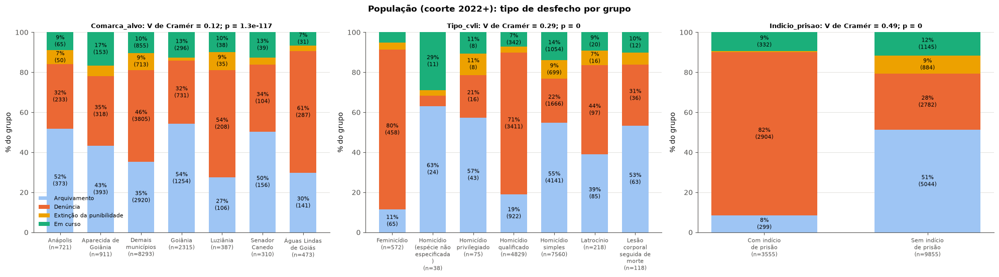

,Teste,Estatística,p-valor,Medida de efeito,Efeito,Medianas,p BH
Variável,,,,,,,
Indicio_prisao,Mann-Whitney,1.8e+07,1.303e-124,rank-bisserial (Sem indício de prisão vs Com indício de prisão),0.2826,Sem indício de prisão: 69 (n=8710) | Com indício de prisão: 26 (n=3223),5.863e-124
Ano_ajuizamento_cat,Kruskal-Wallis,637.6,1.104e-136,ε²,0.05312,2022: 68 (n=2861) | 2023: 78 (n=2764) | 2024: 63 (n=2535) | 2025: 37 (n=2553) | 2026: 25 (n=1220),9.937e-136
Modalidade,Mann-Whitney,1.371e+07,0.0001127,rank-bisserial (Consumado vs Tentado),0.04759,Consumado: 53 (n=9035) | Tentado: 44 (n=2898),0.0001268
Tipo_cvli,Kruskal-Wallis,494.1,1.553e-103,ε²,0.04093,Feminicídio: 22 (n=542) | Latrocínio: 38 (n=198) | Homicídio qualificado: 35 (n=4487) | Homicídio privilegiado: 58 (n=67) | Homicídio si...,4.658e-103
Mesorregiao,Kruskal-Wallis,91.67,5.831e-19,ε²,0.00735,Centro Goiano: 53 (n=5661) | Leste Goiano: 55 (n=2883) | Noroeste Goiano: 75 (n=398) | Norte Goiano: 40 (n=458) | Sul Goiano: 41 (n=2533),1.05e-18
Comarca_alvo,Kruskal-Wallis,30.14,3.697e-05,ε²,0.002024,Goiânia: 51 (n=2019) | Aparecida de Goiânia: 36 (n=758) | Anápolis: 56 (n=656) | Senador Canedo: 62 (n=271) | Luziânia: 54 (n=349) | Águ...,4.753e-05
Porte_municipio,Kruskal-Wallis,15,0.001816,ε²,0.001006,até 50 mil: 49 (n=3757) | 50–200 mil: 53 (n=3573) | 200 mil–1 milhão: 49 (n=2584) | mais de 1 milhão: 51 (n=2019),0.001816
Tramitacao_direta_dj,Mann-Whitney,1.482e+07,8.09e-49,rank-bisserial (Sem TD vs Com TD),-0.1563,Sem TD: 35 (n=5283) | Com TD: 67 (n=6650),1.82e-48
Houve_prorrogacao,Mann-Whitney,1.758e+05,1.049e-14,rank-bisserial (Sem prorrogação vs Com prorrogação),-0.5511,Sem prorrogação: 50 (n=11867) | Com prorrogação: 399 (n=66),1.573e-14


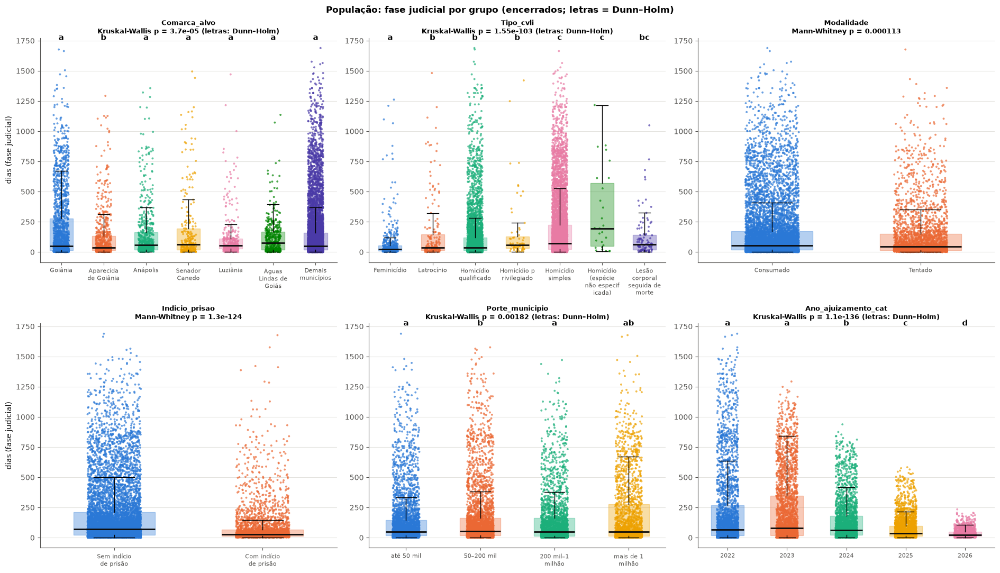

In [ ]:
VARIAVEIS_DJ = ['Comarca_alvo', 'Mesorregiao', 'Porte_municipio', 'Tipo_cvli', 'Modalidade', 'Indicio_prisao', 'Ano_ajuizamento_cat',
                'Tramitacao_direta_dj', 'Houve_prorrogacao']
CORES_DESFECHO.update({'Extinção da punibilidade': CORES[3], 'Em curso': CORES[2]})
assoc_dj, tabelas_dj = [], {}
for v in VARIAVEIS_DJ:
    x = serie_exibicao(coorte_dj, v)
    validos = x.notna()
    tabela, resultado = teste_associacao(x[validos].astype(str), coorte_dj.loc[validos, 'Tipo_fim'].astype(str), n_perm=2_000)
    tabelas_dj[v] = tabela
    assoc_dj.append({'Variável': v, **resultado})
assoc_dj = pd.DataFrame(assoc_dj).set_index('Variável')
assoc_dj['p BH'] = multipletests(assoc_dj['p-valor'], method='fdr_bh')[1]
with pd.option_context('display.float_format', lambda v: f'{v:.4g}'):
    display(assoc_dj.sort_values('V de Cramér', ascending=False))
fig, axes = plt.subplots(1, 3, figsize=(20, 5.6))
for ax, v in zip(axes, ['Comarca_alvo', 'Tipo_cvli', 'Indicio_prisao']):
    barras_verticais_empilhadas(ax, tabelas_dj[v].reindex(columns=['Arquivamento', 'Denúncia', 'Extinção da punibilidade', 'Em curso'],
                                                          fill_value=0), CORES_DESFECHO)
    ax.set_title(f'{v}: V de Cramér = {assoc_dj.loc[v, "V de Cramér"]:.2f}; p = {assoc_dj.loc[v, "p-valor"]:.2g}', fontsize=9.5)
axes[0].legend(fontsize=8, loc='lower left')
plt.suptitle('População (coorte 2022+): tipo de desfecho por grupo', fontweight='bold')
plt.tight_layout()
plt.show()

testes_dj = []
for v in VARIAVEIS_DJ:
    r = comparar_grupos(concl_dj.assign(**{v: serie_exibicao(concl_dj, v)}), 'Tempo_judicial_dj', v)
    if r:
        testes_dj.append({'Variável': v, **r})
testes_dj = pd.DataFrame(testes_dj).set_index('Variável')
testes_dj['p BH'] = multipletests(testes_dj['p-valor'], method='fdr_bh')[1]
with pd.option_context('display.float_format', lambda v: f'{v:.4g}', 'display.max_colwidth', 140):
    display(testes_dj.sort_values('Efeito', ascending=False))
fig, axes = plt.subplots(2, 3, figsize=(19, 11))
for ax, v in zip(axes.flat, ['Comarca_alvo', 'Tipo_cvli', 'Modalidade', 'Indicio_prisao', 'Porte_municipio', 'Ano_ajuizamento_cat']):
    boxplot_grupos(ax, concl_dj, 'Tempo_judicial_dj', v)
for ax in axes[:, 0]:
    ax.set_ylabel('dias (fase judicial)')
plt.suptitle('População: fase judicial por grupo (encerrados; letras = Dunn–Holm)', fontweight='bold')
plt.tight_layout()
plt.show()

**Leitura.** Com milhares de casos, todos os testes dão p minúsculo. O que importa é o **tamanho do efeito**.

*Tipo de desfecho (V de Cramér).* As associações mais fortes são:

| Variável | V |
|---|---|
| Indício de prisão | 0,49 |
| Tramitação direta | 0,34 |
| Modalidade | 0,32 |
| Tipo de CVLI | 0,28 |
| Ano de ajuizamento | 0,21 |

Comarca, mesorregião e porte do município têm associação fraca (V ≈ 0,12): **o desfecho depende mais do caso do que do lugar**.

*Fase judicial por grupo (Kruskal-Wallis e Mann-Whitney, encerrados).*
- **Indício de prisão:** mediana de 26 × 69 dias, o maior efeito (rank-bisserial 0,28);
- **Ano de ajuizamento:** ε² = 0,05;
- **Tipo de CVLI:** ε² = 0,04. Feminicídio leva 22 dias e homicídio qualificado 35, contra 98 no homicídio simples;
- **Comarca:** ε² = 0,002. As medianas vão de 36 dias (Aparecida) a 62 (Senador Canedo), mas a comarca explica uma fração ínfima da variação;
- **Processo:** com prorrogação de prazo, 399 × 50 dias; com tramitação direta, 67 × 35 dias. São variáveis descritivas.

### 22.8 Que distribuição descreve o tempo na população?

O mesmo procedimento da seção 18, aplicado aos encerrados da coorte:

1. ajuste das seis famílias;
2. AIC e BIC;
3. teste da razão de verossimilhança;
4. **FDA empírica × FDA teórica**, com os parâmetros.

A aderência por bootstrap usa uma subamostra aleatória de mil processos. Com dezenas de milhares, o KS rejeitaria qualquer modelo por diferenças irrelevantes.

,Parâmetros livres,log-verossimilhança,AIC,BIC,Forma,Escala,Mediana teórica (dias),ΔAIC,ΔBIC
Família,,,,,,,,,
Gama generalizada,3,"-69,898.44","139,802.88","139,825.04","7.7, 0.233",0.01,58.60,0.00,0.00
Lognormal,2,"-69,921.09","139,846.17","139,860.95",1.59,53.50,53.50,43.30,35.91
Log-logística,2,"-70,103.32","140,210.64","140,225.42",1.09,53.74,53.74,407.77,400.38
Weibull,2,"-70,327.54","140,659.08","140,673.85",0.684,116.85,68.40,856.20,848.82
Gama,2,"-70,706.46","141,416.91","141,431.69",0.581,268.17,80.06,"1,614.04","1,606.65"
Exponencial,1,"-72,176.03","144,354.06","144,361.45",—,155.78,107.98,"4,551.19","4,536.41"


,LR,gl,p-valor
H₀ (modelo restrito),,,
Weibull (a = 1),858.2,1,1.198e-188
Gama (c = 1),1616,1,0
Exponencial (a = c = 1),4555,2,0
Exponencial dentro da Weibull,3697,1,0


Aderência (subamostra de 1.000; 100 réplicas):


,KS (D),p KS (bootstrap),Cramér-von Mises (W²),p CvM (bootstrap)
Gama generalizada,0.04875,0.009901,0.5451,0.009901
Lognormal,0.03074,0.0198,0.2233,0.009901
Log-logística,0.03755,0.009901,0.4346,0.009901


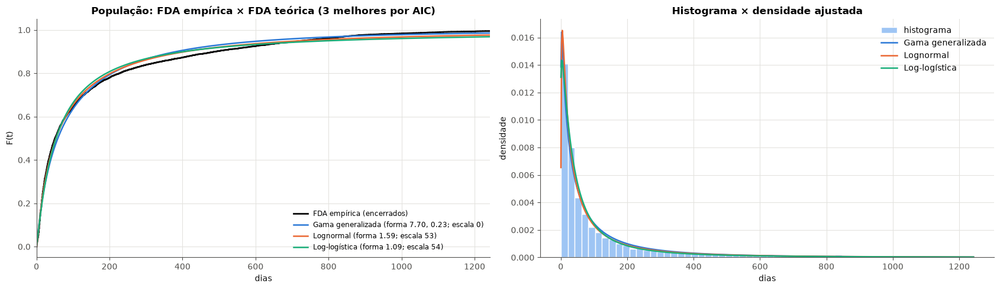

In [ ]:
x_fit = concl_dj['Tempo_judicial_dj'].astype(float).to_numpy() + 0.5
ajustes_conc_dj, tabela_conc_dj = ajustar_scipy(x_fit)
display(tabela_conc_dj.round(3))
with pd.option_context('display.float_format', lambda v: f'{v:.4g}'):
    display(razao_verossimilhanca_scipy(tabela_conc_dj))
sub_fit = RNG.choice(x_fit, size=min(len(x_fit), 1000), replace=False)
aderencia_dj = pd.DataFrame({n: aderencia_bootstrap(sub_fit, n, n_boot=100) for n in tabela_conc_dj.index[:3]}).T
print('Aderência (subamostra de 1.000; 100 réplicas):')
with pd.option_context('display.float_format', lambda v: f'{v:.4g}'):
    display(aderencia_dj)

xs = np.sort(x_fit)
ecdf = np.arange(1, len(xs) + 1) / len(xs)
grade = np.linspace(0.5, np.percentile(xs, 99.5), 600)
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
axes[0].step(xs, ecdf, where='post', color=TINTA, linewidth=2, label='FDA empírica (encerrados)')
for nome, cor in zip(tabela_conc_dj.index[:3], [COR_PRINCIPAL, COR_DESTAQUE, CORES[2]]):
    dist, params = ajustes_conc_dj[nome]
    forma = ', '.join(f'{p:.2f}' for p in params[:-2])
    axes[0].plot(grade, dist.cdf(grade, *params), color=cor, linewidth=1.8,
                 label=f'{nome} ({"forma " + forma + "; " if forma else ""}escala {params[-1]:,.0f})')
axes[0].set_xlim(0, grade.max())
axes[0].set_xlabel('dias')
axes[0].set_ylabel('F(t)')
axes[0].set_title('População: FDA empírica × FDA teórica (3 melhores por AIC)')
axes[0].legend(fontsize=8.5, loc='lower right')
axes[1].hist(xs[xs <= grade.max()], bins=60, density=True, color=COR_SECUNDARIA, edgecolor='white', label='histograma')
for nome, cor in zip(tabela_conc_dj.index[:3], [COR_PRINCIPAL, COR_DESTAQUE, CORES[2]]):
    dist, params = ajustes_conc_dj[nome]
    axes[1].plot(grade, dist.pdf(grade, *params), color=cor, linewidth=1.8, label=nome)
axes[1].set_xlabel('dias')
axes[1].set_ylabel('densidade')
axes[1].set_title('Histograma × densidade ajustada')
axes[1].legend()
plt.tight_layout()
plt.show()

**Leitura.** Na população, a distribuição se define:

- **Melhor família:** a **gama generalizada** é a melhor por AIC e por BIC, com a **lognormal** a cerca de 24 pontos e as demais muito atrás;
- **Restrições:** Weibull e gama são rejeitadas com folga pela razão de verossimilhança (p < 10⁻¹⁸⁰). Os parâmetros estimados levam a gama generalizada para perto do seu limite lognormal;
- **Aderência:** com mil processos sorteados, o bootstrap ainda rejeita as três melhores (p ≈ 0,01). As distâncias KS são pequenas (0,04 a 0,05), e a lognormal é a mais próxima.

**Por que difere da amostra.** Na amostra, a Weibull bastava. A diferença está na **composição**: a população inclui as denúncias rápidas (feminicídio, presos), que a amostra quase não tem. Isso desloca a forma para a lognormal. Com censura (seção 22.10), lognormal e gama generalizada empatam: **a lognormal é a descrição parcimoniosa da fase judicial na população**.

### 22.9 Regressões logísticas: denúncia e prescrição

Com milhares de desfechos, os modelos que a amostra não comportava (6 denúncias, 10 prescrições) são estimados aqui:

1. **Denúncia × arquivamento:** o que se associa à responsabilização?
2. **Extinção da punibilidade × arquivamento:** o que se associa a o Estado perder o prazo ou o objeto?

Em ambos entram comarca, tipo de CVLI, tentativa, indício de prisão, porte do município e ano de ajuizamento. As medidas de ajuste são razões de chance, pseudo-R² de McFadden e AUC.

Chance de denúncia (× arquivamento) na coorte estadual: n = 11,029; eventos = 5,686 (51.6%); pseudo-R² de McFadden = 0.409; AUC = 0.896; LR χ² = 6243 (p = 0)


,OR,"IC 2,5%","IC 97,5%",p-valor
Comarca_modelo=Anápolis,0.51,0.39,0.67,0.00
Comarca_modelo=Aparecida de Goiânia,0.97,0.76,1.24,0.81
Comarca_modelo=Demais municípios,0.68,0.52,0.89,0.01
Comarca_modelo=Luziânia,1.19,0.84,1.67,0.33
Comarca_modelo=Senador Canedo,0.95,0.64,1.42,0.81
Comarca_modelo=Águas Lindas de Goiás,1.21,0.89,1.65,0.22
Tipo_modelo=Feminicídio,10.72,7.93,14.48,0.00
Tipo_modelo=Homicídio qualificado,10.95,9.77,12.27,0.00
Tipo_modelo=Latrocínio,4.11,2.90,5.83,0.00
Tipo_modelo=Outros,1.82,1.27,2.61,0.00


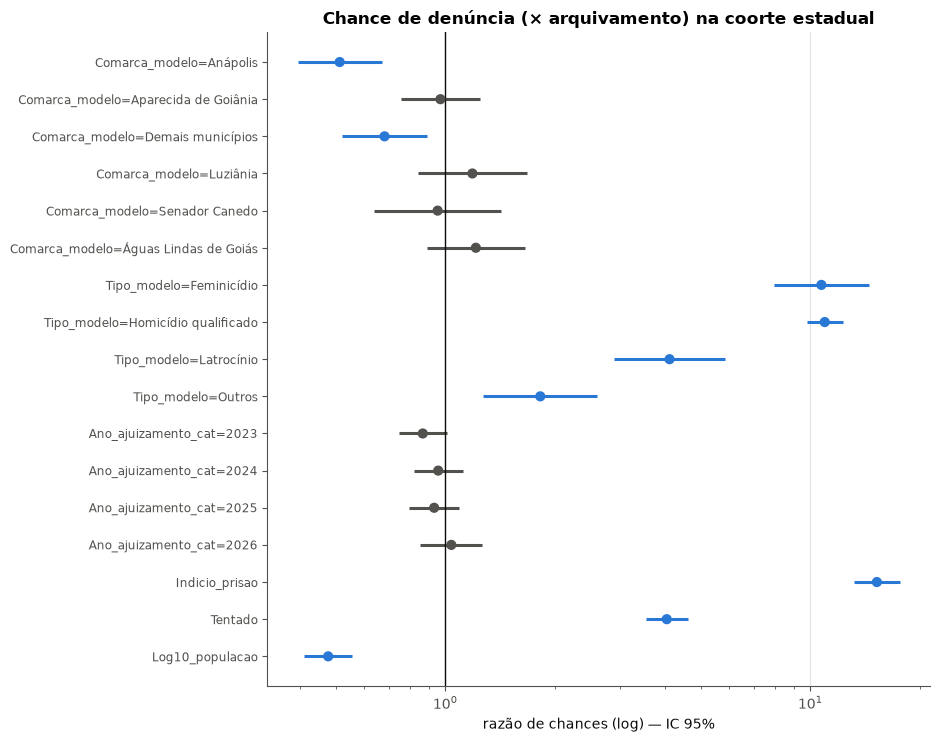

Chance de extinção da punibilidade (× arquivamento) na coorte estadual: n = 6,247; eventos = 904 (14.5%); pseudo-R² de McFadden = 0.091; AUC = 0.716; LR χ² = 468 (p = 1e-88)


,OR,"IC 2,5%","IC 97,5%",p-valor
Comarca_modelo=Anápolis,4.75,2.96,7.62,0.00
Comarca_modelo=Aparecida de Goiânia,4.74,2.97,7.56,0.00
Comarca_modelo=Demais municípios,10.41,6.58,16.48,0.00
Comarca_modelo=Luziânia,12.85,7.42,22.24,0.00
Comarca_modelo=Senador Canedo,3.19,1.53,6.64,0.00
Comarca_modelo=Águas Lindas de Goiás,3.94,2.00,7.75,0.00
Tipo_modelo=Feminicídio,2.16,1.24,3.77,0.01
Tipo_modelo=Homicídio qualificado,1.02,0.83,1.24,0.87
Tipo_modelo=Latrocínio,1.05,0.60,1.85,0.87
Tipo_modelo=Outros,0.78,0.46,1.34,0.38


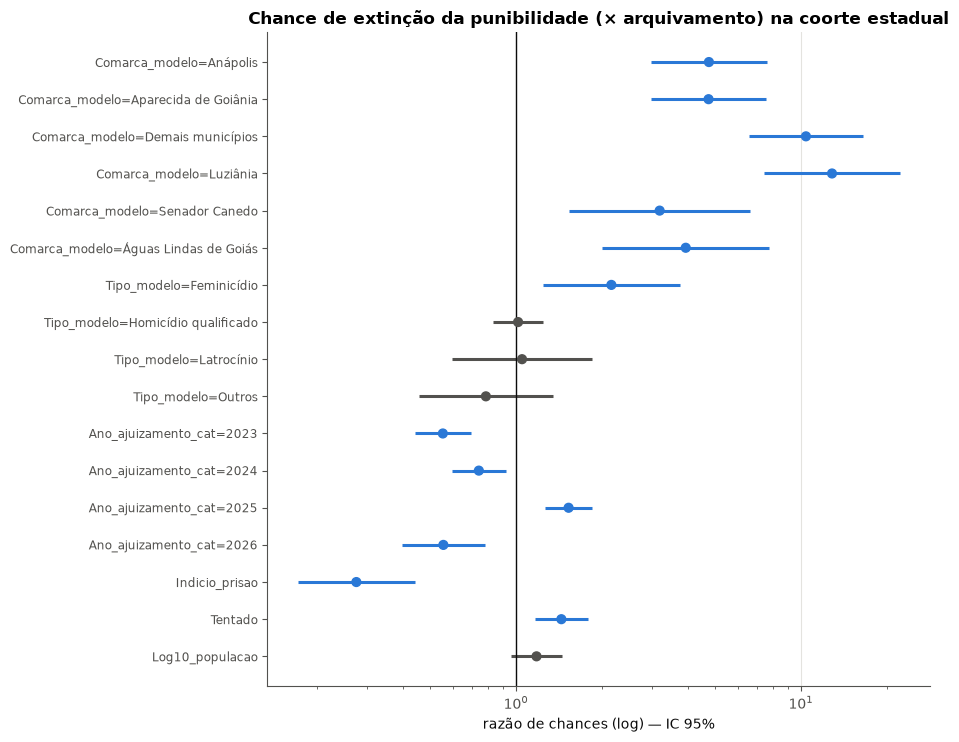

In [ ]:
REFERENCIAS.update({'Comarca_modelo': 'Goiânia', 'Tipo_modelo': 'Homicídio simples', 'Ano_ajuizamento_cat': int(coorte_dj['Ano_ajuizamento'].min())})
coorte_dj['Comarca_modelo'] = coorte_dj['Comarca_alvo'].astype(str)
coorte_dj['Tipo_modelo'] = coorte_dj['Tipo_cvli'].astype(str).replace(
    {'Homicídio privilegiado': 'Outros', 'Homicídio (espécie não especificada)': 'Outros', 'Lesão corporal seguida de morte': 'Outros'})
X_dj = matriz_desenho(coorte_dj, ['Comarca_modelo', 'Tipo_modelo', 'Ano_ajuizamento_cat'], ['Indicio_prisao'], [])
X_dj['Tentado'] = coorte_dj['Modalidade'].eq('Tentado').astype(float)
X_dj['Log10_populacao'] = np.log10(coorte_dj['Codigo_IBGE'].map(municipios_ibge['Populacao_2022']).astype(float))


def logistica_populacao(alvo, base, titulo):
    sub = coorte_dj[coorte_dj['Tipo_fim'].isin([alvo, base])]
    X = sm.add_constant(X_dj.loc[sub.index].astype(float))
    X = X.loc[:, (X.std() > 0) | (X.columns == 'const')]
    y = sub['Tipo_fim'].eq(alvo).astype(int)
    modelo = sm.Logit(y, X).fit(disp=False, maxiter=300)
    p = modelo.predict()
    auc = stats.mannwhitneyu(p[y == 1], p[y == 0]).statistic / ((y == 1).sum() * (y == 0).sum())
    print(f'{titulo}: n = {int(modelo.nobs):,}; eventos = {int(y.sum()):,} ({100 * y.mean():.1f}%); pseudo-R² de McFadden = '
          f'{modelo.prsquared:.3f}; AUC = {auc:.3f}; LR χ² = {modelo.llr:.0f} (p = {modelo.llr_pvalue:.2g})')
    tabela = pd.DataFrame({'OR': np.exp(modelo.params), 'IC 2,5%': np.exp(modelo.conf_int()[0]),
                           'IC 97,5%': np.exp(modelo.conf_int()[1]), 'p-valor': modelo.pvalues}).drop('const')
    display(tabela.round(3))
    grafico_floresta(tabela.rename(columns={'OR': 'HR'}), titulo, rotulo_x='razão de chances (log) — IC 95%')
    return modelo, tabela


logit_den_dj, or_den_dj = logistica_populacao('Denúncia', 'Arquivamento', 'Chance de denúncia (× arquivamento) na coorte estadual')
logit_ext_dj, or_ext_dj = logistica_populacao('Extinção da punibilidade', 'Arquivamento',
                                             'Chance de extinção da punibilidade (× arquivamento) na coorte estadual')

**Leitura.**

*Denúncia × arquivamento (cerca de 11 mil processos; metade denúncias).* O modelo discrimina muito bem (**AUC ≈ 0,90**; McFadden ≈ 0,41):

| Fator | OR |
|---|---|
| Indício de prisão | **≈ 15** |
| Homicídio qualificado | ≈ 11 |
| Feminicídio | ≈ 11 |
| Latrocínio | ≈ 4 |
| Tentativa | ≈ 4 (a vítima sobrevivente é testemunha) |
| Cada aumento de 10 vezes na população do município | ≈ 0,5 |
| Anápolis × Goiânia | ≈ 0,5 |

As demais comarcas da amostra não diferem de Goiânia.

*Extinção da punibilidade × arquivamento (cerca de 900 extinções).* O modelo é mais fraco (AUC ≈ 0,72):

- **comarca:** a extinção é muito mais frequente fora de Goiânia. Luziânia e os demais municípios têm OR acima de 10. Goiânia arquiva por outros motivos;
- **indício de prisão:** reduz a chance (OR ≈ 0,3);
- **feminicídio:** a aumenta (OR ≈ 2), provavelmente pela morte do agente (feminicídio seguido de suicídio).

### 22.10 Sobrevivência na população: Kaplan-Meier, log-rank, Cox e modelos paramétricos

A coorte é acompanhada **desde o ajuizamento**, sem truncamento, e os processos sem desfecho até a coleta entram como censurados. A sequência repete a da seção 20:

- curva geral;
- curvas por grupo, com log-rank e a razão de riscos (HR) do Cox univariado;
- Cox multivariável com teste dos riscos proporcionais e curvas ajustadas;
- famílias paramétricas com censura e modelo AFT.

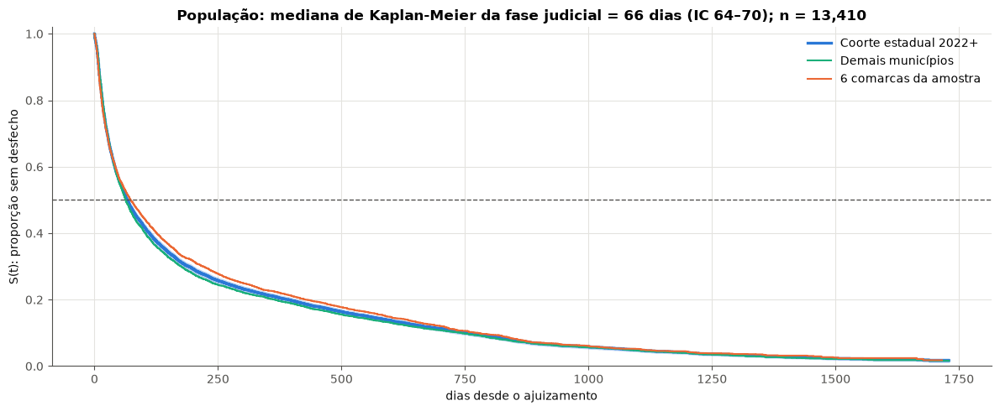

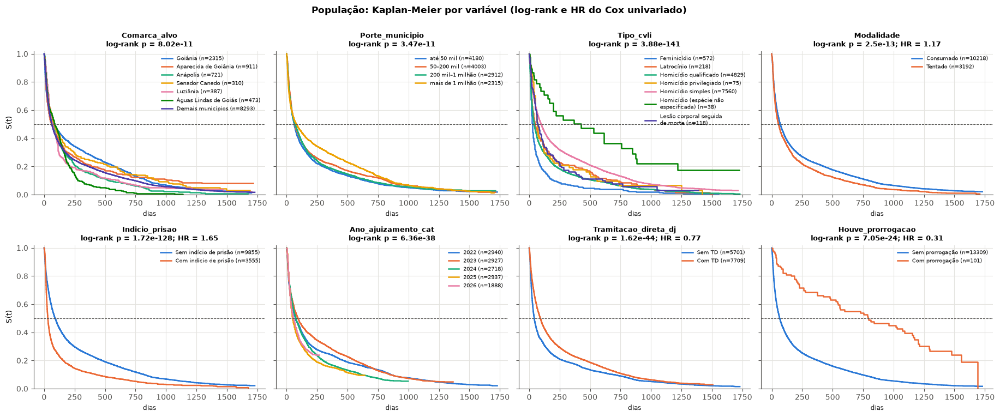

,p log-rank,p BH
Variável,,
Comarca_alvo,0.00,0.00
Porte_municipio,0.00,0.00
Tipo_cvli,0.00,0.00
Modalidade,0.00,0.00
Indicio_prisao,0.00,0.00
Ano_ajuizamento_cat,0.00,0.00
Tramitacao_direta_dj,0.00,0.00
Houve_prorrogacao,0.00,0.00


n  Eventos  Mediana KM  IC 2,5%  IC 97,5%
Variável             Grupo                                                                              
Comarca_alvo         Goiânia                                2315     2019       80.00    68.00     94.00
                     Aparecida de Goiânia                    911      758       60.00    48.00     72.00
                     Anápolis                                721      656       70.00    58.00     84.00
                     Senador Canedo                          310      271       78.00    62.00    106.00
                     Luziânia                                387      349       68.00    54.00     78.00
                     Águas Lindas de Goiás                   473      442       86.00    72.00    108.00
                     Demais municípios                      8293     7438       64.00    60.00     66.00
Porte_municipio      até 50 mil                             4180     3757       62.00    58.00     64.00
                     50–200 mil                             4003     3573       66.00    62.00     72.00
                     200 mil–1 milhão                       2912     2584       70.00    62.00     76.00
                     mais de 1 milhão                       2315     2019       80.00    68.00     94.00
Tipo_cvli            Feminicídio                             572      542       24.00    22.00     28.00
                     Latrocínio                              218      198       48.00    36.00     70.00
                     Homicídio qualificado                  4829     4487       42.00    40.00     44.00
                     Homicídio privilegiado                   75       67       68.00    50.00     98.00
                     Homicídio simples                      7560     6506       98.00    94.00    104.00
                     Homicídio (espécie não especificada)     38       27      426.00   164.00    758.00
                     Lesão corporal seguida de morte         118      106       70.00    60.00     98.00
Modalidade           Consumado                             10218     9035       70.00    66.00     74.00
                     Tentado                                3192     2898       56.00    50.00     60.00
Indicio_prisao       Sem indício de prisão                  9855     8710       90.00    86.00     96.00
                     Com indício de prisão                  3555     3223       30.00    30.00     32.00
Ano_ajuizamento_cat  2022                                   2940     2861       72.00    66.00     78.00
                     2023                                   2927     2764       94.00    84.00    102.00
                     2024                                   2718     2535       76.00    70.00     82.00
                     2025                                   2937     2553       46.00    44.00     50.00
                     2026                                   1888     1220       56.00    48.00     60.00
Tramitacao_direta_dj Sem TD                                 5701     5283       42.00    40.00     44.00
                     Com TD                                 7709     6650       92.00    86.00     96.00
Houve_prorrogacao    Sem prorrogação                       13309    11867       66.00    62.00     68.00
                     Com prorrogação                         101       66      796.00   544.00  1,092.00

In [ ]:
T_DJ = coorte_dj['Tempo_judicial_dj'].astype(float).to_numpy() + 0.5
E_DJ = coorte_dj['Evento_fim'].astype(int).to_numpy()
km_dj = KaplanMeierFitter().fit(T_DJ, E_DJ, label='Coorte estadual 2022+')
m, li, ls = mediana_ic(km_dj)
fig, ax = plt.subplots(figsize=(12, 5))
km_dj.plot_survival_function(ax=ax, color=COR_PRINCIPAL, linewidth=2.4)
for comarca_grupo, cor in [('Demais municípios', CORES[2])]:
    m_g = coorte_dj['Comarca_alvo'].eq(comarca_grupo).to_numpy()
    KaplanMeierFitter().fit(T_DJ[m_g], E_DJ[m_g], label='Demais municípios').plot_survival_function(ax=ax, color=cor, ci_show=False)
m_alvo = ~coorte_dj['Comarca_alvo'].eq('Demais municípios').to_numpy()
KaplanMeierFitter().fit(T_DJ[m_alvo], E_DJ[m_alvo], label='6 comarcas da amostra').plot_survival_function(ax=ax, color=COR_DESTAQUE, ci_show=False)
ax.axhline(0.5, color=TINTA_2, linestyle='--', linewidth=1)
ax.set_ylim(0, 1.02)
ax.set_xlabel('dias desde o ajuizamento')
ax.set_ylabel('S(t): proporção sem desfecho')
ax.set_title(f'População: mediana de Kaplan-Meier da fase judicial = {m:.0f} dias (IC {li:.0f}–{ls:.0f}); n = {len(T_DJ):,}')
plt.tight_layout()
plt.show()

km_dj_var = grade_km(coorte_dj, T_DJ, E_DJ, [v for v in VARIAVEIS_DJ if v != 'Mesorregiao'],
                     'População: Kaplan-Meier por variável (log-rank e HR do Cox univariado)', colunas=4)
logrank_dj = km_dj_var.groupby('Variável', sort=False)['p log-rank'].first().to_frame()
logrank_dj['p BH'] = multipletests(logrank_dj['p log-rank'], method='fdr_bh')[1]
display(logrank_dj.round(5))
with pd.option_context('display.max_rows', 120):
    display(km_dj_var.drop(columns='p log-rank').set_index(['Variável', 'Grupo']).round(0))

Cox na coorte: n = 13,410; eventos = 11,933; C = 0.596; pseudo-R² de Nagelkerke = 0.076


,HR,"IC 2,5%","IC 97,5%",p-valor,p PH (Schoenfeld)
covariate,,,,,
Comarca_modelo=Anápolis,1.09,1.00,1.20,0.06,0.00
Comarca_modelo=Aparecida de Goiânia,1.00,0.92,1.09,0.99,0.01
Comarca_modelo=Demais municípios,0.97,0.88,1.06,0.46,0.00
Comarca_modelo=Luziânia,0.93,0.83,1.06,0.27,0.00
Comarca_modelo=Senador Canedo,0.99,0.86,1.13,0.84,0.58
Comarca_modelo=Águas Lindas de Goiás,1.12,1.00,1.25,0.05,0.00
Tipo_modelo=Feminicídio,1.87,1.71,2.05,0.00,0.00
Tipo_modelo=Homicídio qualificado,1.40,1.35,1.46,0.00,0.00
Tipo_modelo=Latrocínio,1.35,1.17,1.56,0.00,0.03


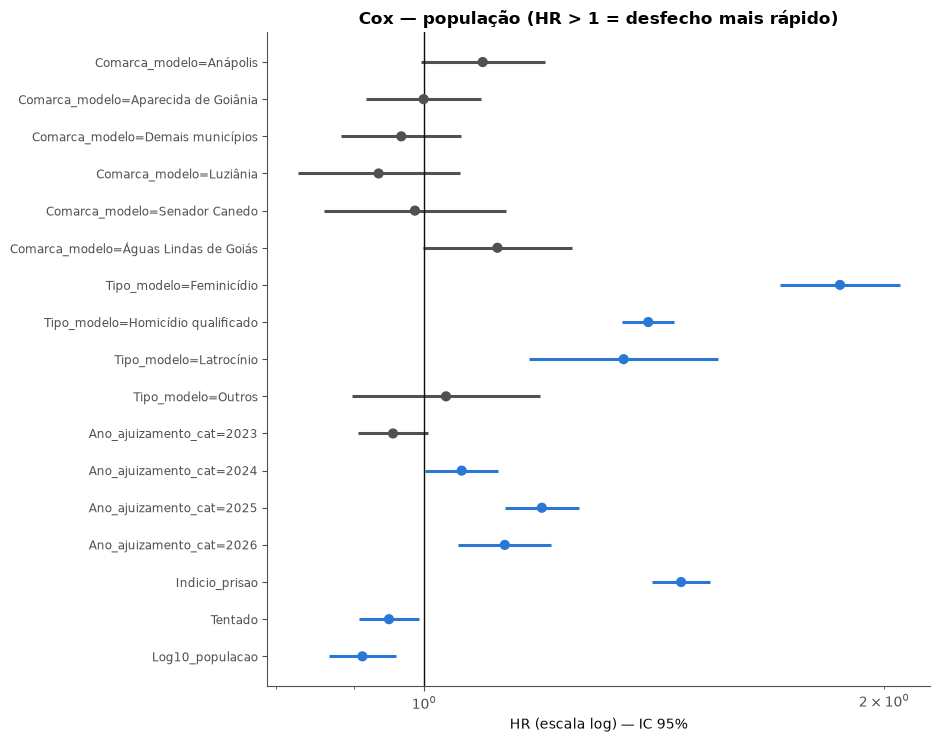

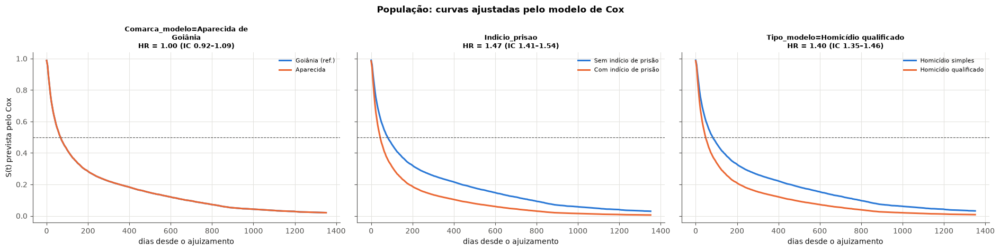

,Parâmetros,log-verossimilhança,AIC,BIC,Mediana (dias),Estimativas,ΔAIC,ΔBIC
Família,,,,,,,,
Lognormal,2,"-72,673.73","145,351.46","145,366.47",72.19,"mu = 4.28, sigma = 1.77",0.00,0.00
Gama generalizada,3,"-72,673.57","145,353.15","145,375.66",71.93,"mu = 4.27, ln_sigma = 0.571, lambda = -0.0146",1.69,9.19
Log-logística,2,"-72,826.24","145,656.48","145,671.49",70.97,"alpha = 71, beta = 0.967",305.02,305.02
Weibull,2,"-73,331.69","146,667.39","146,682.40",91.63,"lambda = 164, rho = 0.632","1,315.93","1,315.93"
Gama,2,"-73,816.87","147,637.75","147,652.76",109.43,"k = 0.53, theta = 432","2,286.29","2,286.29"
Exponencial,1,"-75,998.70","151,999.39","152,006.90",148.75,lambda = 215,"6,647.93","6,640.43"


,LR,gl,p-valor
H₀ (modelo restrito),,,
Weibull (λ = 1),1316,1,3.339e-288
Lognormal (λ = 0),0.3128,1,0.576
Gama (λ = σ),2287,1,0
Exponencial (λ = 1 e σ = 1),6650,2,0


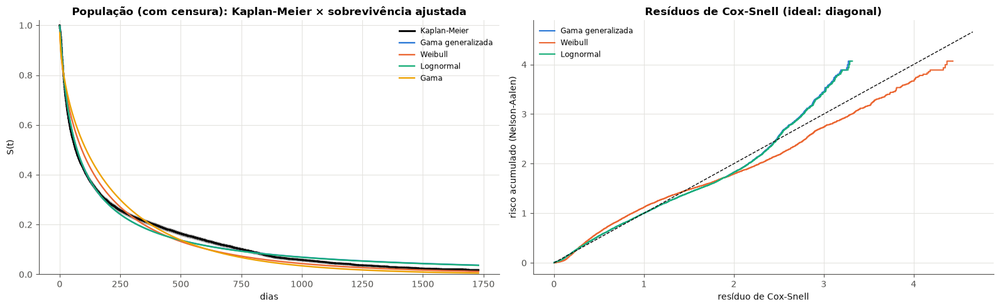

AFT gama generalizada na população: AIC = 144437


,TR,"IC 2,5%","IC 97,5%",p-valor
covariate,,,,
Comarca_modelo=Anápolis,1.07,0.11,10.20,0.95
Comarca_modelo=Aparecida de Goiânia,1.00,0.87,1.15,1.00
Comarca_modelo=Demais municípios,1.28,1.19,1.37,0.00
Comarca_modelo=Luziânia,1.31,0.87,1.99,0.20
Comarca_modelo=Senador Canedo,1.17,0.94,1.45,0.17
Comarca_modelo=Águas Lindas de Goiás,1.12,0.94,1.34,0.20
Tipo_modelo=Feminicídio,0.37,0.32,0.44,0.00
Tipo_modelo=Homicídio qualificado,0.54,0.50,0.57,0.00
Tipo_modelo=Latrocínio,0.57,0.45,0.73,0.00


In [ ]:
base_dj = X_dj.assign(T=T_DJ, E=E_DJ).dropna()
base_dj = base_dj.loc[:, (base_dj.std() > 0) | base_dj.columns.isin(['T', 'E'])]
cox_dj = CoxPHFitter(penalizer=1e-4).fit(base_dj, 'T', 'E')
resumo_cox_dj = cox_dj.summary[['exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p']].set_axis(['HR', 'IC 2,5%', 'IC 97,5%', 'p-valor'], axis=1)
ll0 = cox_dj.log_likelihood_ - cox_dj.log_likelihood_ratio_test().test_statistic / 2
print(f'Cox na coorte: n = {len(base_dj):,}; eventos = {int(base_dj["E"].sum()):,}; C = {cox_dj.concordance_index_:.3f}; '
      f'pseudo-R² de Nagelkerke = {nagelkerke(cox_dj.log_likelihood_, ll0, len(base_dj))[1]:.3f}')
ph_dj = proportional_hazard_test(cox_dj, base_dj, time_transform='rank').summary['p']
display(resumo_cox_dj.assign(**{'p PH (Schoenfeld)': ph_dj}).round(4))
grafico_floresta(resumo_cox_dj, 'Cox — população (HR > 1 = desfecho mais rápido)')

fig, axes = plt.subplots(1, 3, figsize=(19, 4.8), sharey=True)
perfil = base_dj.drop(columns=['T', 'E']).mean().to_frame().T
for ax, (coluna, valores, rotulos) in zip(axes, [('Comarca_modelo=Aparecida de Goiânia', [0, 1], ['Goiânia (ref.)', 'Aparecida']),
                                                 ('Indicio_prisao', [0, 1], ['Sem indício de prisão', 'Com indício de prisão']),
                                                 ('Tipo_modelo=Homicídio qualificado', [0, 1], ['Homicídio simples', 'Homicídio qualificado'])]):
    if coluna not in perfil:
        continue
    perfis = pd.concat([perfil.assign(**{coluna: v}) for v in valores], ignore_index=True)
    curvas = cox_dj.predict_survival_function(perfis, times=np.linspace(0, np.percentile(T_DJ, 99), 300))
    for (_, curva), rotulo, cor in zip(curvas.items(), rotulos, CORES):
        ax.plot(curvas.index, curva, color=cor, linewidth=2.2, label=rotulo)
    hr = resumo_cox_dj.loc[coluna]
    ax.set_title(f'{quebrar(coluna, 34)}\nHR = {hr["HR"]:.2f} (IC {hr["IC 2,5%"]:.2f}–{hr["IC 97,5%"]:.2f})', fontsize=9.5)
    ax.axhline(0.5, color=TINTA_2, linestyle='--', linewidth=0.8)
    ax.set_xlabel('dias desde o ajuizamento')
    ax.legend(fontsize=8)
axes[0].set_ylabel('S(t) prevista pelo Cox')
plt.suptitle('População: curvas ajustadas pelo modelo de Cox', fontweight='bold')
plt.tight_layout()
plt.show()

ajustes_dj, tabela_dj = ajustar_familias(T_DJ, E_DJ)
display(tabela_dj.round(2))
with pd.option_context('display.float_format', lambda v: f'{v:.4g}'):
    display(razao_verossimilhanca(ajustes_dj))
diagnostico_sobrevivencia(T_DJ, E_DJ, ajustes_dj, km_dj, 'População (com censura)')

base_aft_dj = base_dj.copy()
base_aft_dj.columns = [re.sub(r'\W+', '_', unicodedata.normalize('NFKD', c).encode('ascii', 'ignore').decode()).strip('_') for c in base_aft_dj.columns]
nomes_aft_dj = dict(zip(base_aft_dj.columns, base_dj.columns))
aft_dj = GeneralizedGammaRegressionFitter(penalizer=1e-4).fit(
    base_aft_dj, 'T', 'E', regressors={'mu_': ' + '.join(c for c in base_aft_dj if c not in ('T', 'E')), 'sigma_': '1', 'lambda_': '1'})
s = aft_dj.summary.loc['mu_'].drop(index='Intercept', errors='ignore')
tr_dj = pd.DataFrame({'TR': np.exp(s['coef']), 'IC 2,5%': np.exp(s['coef lower 95%']), 'IC 97,5%': np.exp(s['coef upper 95%']),
                      'p-valor': s['p']}).rename(index=nomes_aft_dj)
print(f'AFT gama generalizada na população: AIC = {aft_dj.AIC_:.0f}')
display(tr_dj.round(3))

**Leitura.**

- **Kaplan-Meier:** a mediana da fase judicial na população é de cerca de **2 meses**. Todas as variáveis separam as curvas no log-rank, porque com 13 mil casos até diferenças pequenas são significativas. Em dias:

  | Grupo | Mediana |
  |---|---|
  | Feminicídio | 24 |
  | Com indício de prisão | 30 |
  | Homicídio qualificado | 42 |
  | Sem indício de prisão | 90 |
  | Homicídio simples | 98 |
  | Com prorrogação de prazo | 796 |
  | 6 comarcas | 60 (Aparecida) a 88 (Águas Lindas) |
  | Demais municípios | 64 |

- **Cox (C ≈ 0,60; Nagelkerke ≈ 0,08):** os efeitos que aceleram o desfecho são feminicídio (HR ≈ 1,9), indício de prisão (≈ 1,5), homicídio qualificado (≈ 1,4) e latrocínio (≈ 1,35). Municípios maiores são mais lentos. **Nenhuma comarca da amostra difere de Goiânia.**
- **Pressuposto de riscos proporcionais:** é violado em quase todas as variáveis, o que é esperado com esse n. Os HR devem ser lidos como efeitos médios, e o AFT confirma o sentido: TR de 0,37 (feminicídio), 0,54 (qualificado) e 0,58 (prisão).
- **Famílias com censura:** a lognormal é a melhor por AIC e BIC, e a gama generalizada não a supera (λ ≈ 0). Weibull, gama e exponencial são rejeitadas.

### 22.11 A amostra diante da população: mesmas comarcas, mesma janela

Fecha-se o círculo comparando a amostra com a população **no mesmo recorte**: as seis comarcas, com ajuizamento de 2022 em diante. Em dois níveis:

1. **Amostra instaurada a partir de 2022** (recorte equivalente, n = 89);
2. **Amostra inteira**, para ver o que o estoque antigo muda no perfil.

**Testes:**

- **Proporções:** **binomial exato** da proporção da amostra contra a da população. A coorte é o censo do recorte, e sua proporção funciona como valor conhecido p₀;
- **Distribuição das comarcas:** **qui-quadrado de aderência**;
- **Tempo:** a **fase judicial** da amostra (recebimento no Projudi → conclusão no MP) contra a da população (ajuizamento → manifestação do MP ou → decisão judicial), por Kaplan-Meier e log-rank.

Amostra  % amostra  IC 2,5%  IC 97,5%  % população = p₀  p-valor (binomial exato)      p BH
Nível                                Indicador                                                                                                                 
Amostra ≥ 2022 (recorte equivalente) Réu preso / indício de prisão    18/89      20.22    12.45     30.07             24.29                     0.458    0.5725
                                     Tentado                          19/89      21.35    13.37     31.31             18.96                     0.588     0.588
                                     Homicídio qualificado            13/89      14.61    8.013     23.68             40.14                 2.083e-07 5.207e-07
                                     Tramitação direta                58/89      65.17    54.33     74.96             60.62                    0.4478    0.5725
                                     Denúncia                          6/89      6.742    2.514      14.1             36.76                 6.687e-11 3.344e-10
Amostra inteira                      Réu preso / indício de prisão   21/218      9.633    6.062     14.35             24.29                 5.126e-08 8.543e-08
                                     Tentado                         42/218      19.27    14.25     25.14             18.96                    0.9311    0.9311
                                     Homicídio qualificado           38/218      17.43    12.64     23.13             40.14                 6.676e-13 1.669e-12
                                     Tramitação direta              142/218      65.14    58.41     71.45             60.62                    0.1879    0.2348
                                     Denúncia                         6/218      2.752    1.017     5.894             36.76                 3.702e-34 1.851e-33

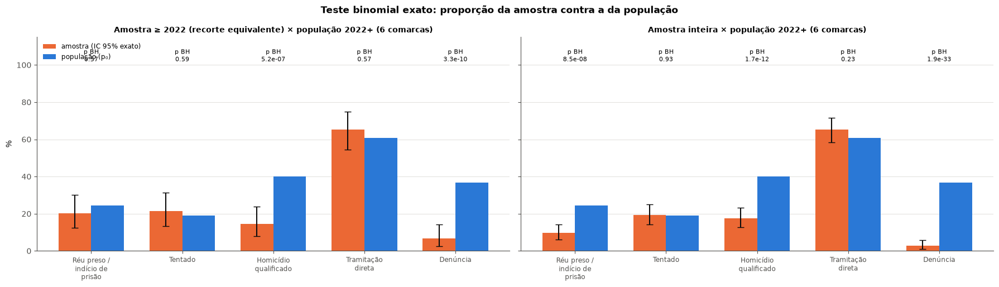

,Amostra ≥ 2022,Esperado pela população,% amostra,% população,Resíduo de Pearson
Goiânia,41,40.30,46.10,45.20,0.12
Aparecida de Goiânia,23,15.80,25.80,17.80,1.80
Anápolis,10,12.50,11.20,14.10,-0.72
Luziânia,5,6.70,5.60,7.60,-0.67
Senador Canedo,7,5.40,7.90,6.10,0.69
Águas Lindas de Goiás,3,8.20,3.40,9.20,-1.82


Qui-quadrado de aderência (comarcas): χ² = 8.00; gl = 5; p = 0.156; menor frequência esperada = 5.4


In [ ]:
coorte_alvo = coorte_dj[coorte_dj['Comarca_alvo'].ne('Demais municípios')].copy()
recente = dados[dados['Ano_instauracao'].ge(2022)]
populacao_cmp = pd.DataFrame({
    'Réu preso / indício de prisão': coorte_alvo['Indicio_prisao'].astype(bool), 'Tentado': coorte_alvo['Modalidade'].eq('Tentado'),
    'Homicídio qualificado': coorte_alvo['Tipo_cvli'].isin(['Homicídio qualificado', 'Feminicídio']),
    'Tramitação direta': coorte_alvo['Tramitacao_direta_dj'].astype(bool), 'Denúncia': coorte_alvo['Tipo_fim'].eq('Denúncia'),
})


def indicadores_amostra(df):
    return pd.DataFrame({'Réu preso / indício de prisão': df['Reu_preso'].astype(bool), 'Tentado': df['Tentativa'].astype(bool),
                         'Homicídio qualificado': df['Assunto_resumido'].isin(['Homicídio qualificado', 'Feminicídio']),
                         'Tramitação direta': df['Tramitacao_direta'].astype(bool), 'Denúncia': df['Desfecho'].eq('Denúncia oferecida')})


comparacao = []
for nivel, df in [('Amostra ≥ 2022 (recorte equivalente)', recente), ('Amostra inteira', dados)]:
    ind = indicadores_amostra(df)
    for v in ind:
        k, n, p0 = int(ind[v].sum()), len(ind), float(populacao_cmp[v].mean())
        teste = stats.binomtest(k, n, p0)
        ic = teste.proportion_ci(method='exact')
        comparacao.append({'Nível': nivel, 'Indicador': v, 'Amostra': f'{k}/{n}', '% amostra': 100 * k / n, 'IC 2,5%': 100 * ic.low,
                           'IC 97,5%': 100 * ic.high, '% população = p₀': 100 * p0, 'p-valor (binomial exato)': teste.pvalue})
comparacao = pd.DataFrame(comparacao)
comparacao['p BH'] = comparacao.groupby('Nível')['p-valor (binomial exato)'].transform(lambda p: multipletests(p, method='fdr_bh')[1])
with pd.option_context('display.float_format', lambda v: f'{v:.4g}'):
    display(comparacao.set_index(['Nível', 'Indicador']))

fig, axes = plt.subplots(1, 2, figsize=(18, 5.2), sharey=True)
for ax, (nivel, tab) in zip(axes, comparacao.groupby('Nível', sort=False)):
    x = np.arange(len(tab))
    props = tab['% amostra'].to_numpy()
    ax.bar(x - 0.18, props, width=0.36, color=COR_DESTAQUE, label='amostra (IC 95% exato)')
    ax.errorbar(x - 0.18, props, yerr=[props - tab['IC 2,5%'].to_numpy(), tab['IC 97,5%'].to_numpy() - props], fmt='none', ecolor=TINTA, capsize=4)
    ax.bar(x + 0.18, tab['% população = p₀'], width=0.36, color=COR_PRINCIPAL, label='população (p₀)')
    for xi, pv in zip(x, tab['p BH']):
        ax.text(xi, 102, f'p BH\n{pv:.2g}', ha='center', fontsize=8)
    ax.set_xticks(x, [quebrar(i, 14) for i in tab['Indicador']], fontsize=8.5)
    ax.set_ylim(0, 115)
    ax.set_title(f'{nivel} × população 2022+ (6 comarcas)', fontsize=10)
    ax.grid(axis='x', visible=False)
axes[0].set_ylabel('%')
axes[0].legend(loc='upper left', fontsize=8.5)
plt.suptitle('Teste binomial exato: proporção da amostra contra a da população', fontweight='bold')
plt.tight_layout()
plt.show()

observado = recente['Comarca'].value_counts().reindex(dados['Comarca'].cat.categories)
proporcao_pop = coorte_alvo['Comarca_alvo'].astype(str).value_counts(normalize=True).reindex(observado.index).fillna(0)
esperado = proporcao_pop * observado.sum()
aderencia_comarca = stats.chisquare(observado, esperado)
display(pd.DataFrame({'Amostra ≥ 2022': observado, 'Esperado pela população': esperado.round(1),
                      '% amostra': (100 * observado / observado.sum()).round(1), '% população': (100 * proporcao_pop).round(1),
                      'Resíduo de Pearson': ((observado - esperado) / np.sqrt(esperado)).round(2)}))
print(f'Qui-quadrado de aderência (comarcas): χ² = {aderencia_comarca.statistic:.2f}; gl = {len(observado) - 1}; '
      f'p = {aderencia_comarca.pvalue:.3g}; menor frequência esperada = {esperado.min():.1f}')

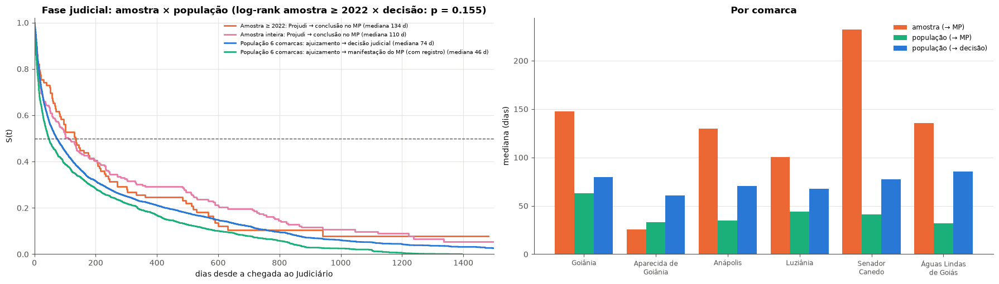

,n amostra,Mediana KM amostra (Projudi → MP),n população,Mediana KM população (→ decisão),Mediana população (→ MP),p log-rank (amostra × população),p BH
Comarca,,,,,,,
Goiânia,101,147.50,2315,79.50,63.00,0.01,0.07
Aparecida de Goiânia,44,25.50,911,60.50,33.00,0.12,0.23
Anápolis,34,129.50,721,70.50,35.00,0.41,0.49
Luziânia,18,100.50,387,67.50,44.00,0.56,0.56
Senador Canedo,14,232.50,310,77.50,41.00,0.11,0.23
Águas Lindas de Goiás,7,135.50,473,85.50,32.00,0.23,0.35


Na população, as 6 comarcas diferem entre si? log-rank χ² = 56.6; p = 6.17e-11
Vínculo individual: 18 de 89 IPs recentes com candidato único (20%); distribuição de candidatos: {0: 1, 1: 18, 2: 17, 3: 11, 4: 7, 5: 35}


,MP DataJud − MP amostra (dias),Decisão DataJud − MP amostra (dias)
count,4.00,15.00
mean,35.50,-12.10
std,107.50,128.70
min,-38.00,-373.00
25%,-20.80,0.00
50%,-7.50,4.00
75%,48.80,21.50
max,195.00,200.00


Tipo_fim DataJud,Arquivamento,Denúncia,Em curso,Extinção da punibilidade
Desfecho amostra,,,,
Arquivado,9,2,0,1
Denúncia oferecida,0,1,0,0
Em investigação,0,4,1,0


In [ ]:
# Fase judicial: amostra (Projudi → conclusão no MP) × população (ajuizamento → manifestação do MP; ajuizamento → decisão)
m_rec = dados['Ano_instauracao'].ge(2022).to_numpy()
T_POP = coorte_alvo['Tempo_judicial_dj'].astype(float) + 0.5
E_POP = coorte_alvo['Evento_fim'].astype(int)
mp_pop = coorte_alvo['Tempo_ate_mp_dj'].dropna().astype(float) + 0.5
curvas = [('Amostra ≥ 2022: Projudi → conclusão no MP', KaplanMeierFitter().fit(T_JUD[m_rec], EVENTO[m_rec]), COR_DESTAQUE),
          ('Amostra inteira: Projudi → conclusão no MP', KaplanMeierFitter().fit(T_JUD, EVENTO), CORES[4]),
          ('População 6 comarcas: ajuizamento → decisão judicial', KaplanMeierFitter().fit(T_POP, E_POP), COR_PRINCIPAL),
          ('População 6 comarcas: ajuizamento → manifestação do MP (com registro)', KaplanMeierFitter().fit(mp_pop), CORES[2])]
fig, axes = plt.subplots(1, 2, figsize=(18, 5.2))
for rotulo, km, cor in curvas:
    axes[0].step(km.survival_function_.index, km.survival_function_.iloc[:, 0], where='post', color=cor, linewidth=2,
                 label=f'{rotulo} (mediana {km.median_survival_time_:.0f} d)')
axes[0].axhline(0.5, color=TINTA_2, linestyle='--', linewidth=1)
axes[0].set_xlim(0, 1500)
axes[0].set_ylim(0, 1.02)
axes[0].set_xlabel('dias desde a chegada ao Judiciário')
axes[0].set_ylabel('S(t)')
teste_ap = logrank_test(T_JUD[m_rec], T_POP, EVENTO[m_rec], E_POP)
axes[0].set_title(f'Fase judicial: amostra × população (log-rank amostra ≥ 2022 × decisão: p = {teste_ap.p_value:.3g})')
axes[0].legend(fontsize=7.5, loc='upper right')

medianas_cmp = []
for comarca in dados['Comarca'].cat.categories:
    m_a = dados['Comarca'].eq(comarca).to_numpy()
    m_p = coorte_alvo['Comarca_alvo'].eq(comarca).to_numpy()
    medianas_cmp.append({'Comarca': comarca, 'n amostra': int(m_a.sum()),
                         'Mediana KM amostra (Projudi → MP)': KaplanMeierFitter().fit(T_JUD[m_a], EVENTO[m_a]).median_survival_time_,
                         'n população': int(m_p.sum()),
                         'Mediana KM população (→ decisão)': KaplanMeierFitter().fit(T_POP[m_p], E_POP[m_p]).median_survival_time_,
                         'Mediana população (→ MP)': coorte_alvo.loc[m_p, 'Tempo_ate_mp_dj'].median(),
                         'p log-rank (amostra × população)': logrank_test(T_JUD[m_a], T_POP[m_p], EVENTO[m_a], E_POP[m_p]).p_value})
medianas_cmp = pd.DataFrame(medianas_cmp).set_index('Comarca')
medianas_cmp['p BH'] = multipletests(medianas_cmp['p log-rank (amostra × população)'], method='fdr_bh')[1]
x = np.arange(len(medianas_cmp))
axes[1].bar(x - 0.27, medianas_cmp['Mediana KM amostra (Projudi → MP)'], width=0.27, color=COR_DESTAQUE, label='amostra (→ MP)')
axes[1].bar(x, medianas_cmp['Mediana população (→ MP)'], width=0.27, color=CORES[2], label='população (→ MP)')
axes[1].bar(x + 0.27, medianas_cmp['Mediana KM população (→ decisão)'], width=0.27, color=COR_PRINCIPAL, label='população (→ decisão)')
axes[1].set_xticks(x, [quebrar(c, 12) for c in medianas_cmp.index], fontsize=8.5)
axes[1].set_ylabel('mediana (dias)')
axes[1].set_title('Por comarca')
axes[1].legend(fontsize=8.5)
axes[1].grid(axis='x', visible=False)
plt.tight_layout()
plt.show()
display(medianas_cmp.round(3))
lr_comarcas_pop = multivariate_logrank_test(T_POP, coorte_alvo['Comarca_alvo'].astype(str), E_POP)
print(f'Na população, as 6 comarcas diferem entre si? log-rank χ² = {lr_comarcas_pop.test_statistic:.1f}; p = {lr_comarcas_pop.p_value:.3g}')

# Vínculo individual (IPs recentes): comarca + ajuizamento = recebimento no Projudi (± 1 dia), candidato único
chave = coorte_alvo.reset_index()[['Numero_processo', 'Comarca_alvo', 'Data_ajuizamento', 'Data_manifestacao_mp', 'Data_fim', 'Tipo_fim']]
chave['Comarca_alvo'] = chave['Comarca_alvo'].astype(str)
vinculos = []
for n_ordem, linha in recente.iterrows():
    candidatos = chave[chave['Comarca_alvo'].eq(str(linha['Comarca']))
                       & ((chave['Data_ajuizamento'].dt.normalize() - linha['Data_recebimento_projudi']).dt.days.abs() <= 1)]
    vinculo = {'N_ordem': n_ordem, 'Candidatos': len(candidatos)}
    if len(candidatos) == 1:
        c = candidatos.iloc[0]
        vinculo.update({'MP DataJud − MP amostra (dias)': (c['Data_manifestacao_mp'] - linha['Data_conclusao_mp']).days
                        if pd.notna(c['Data_manifestacao_mp']) and pd.notna(linha['Data_conclusao_mp']) else np.nan,
                        'Decisão DataJud − MP amostra (dias)': (c['Data_fim'] - linha['Data_conclusao_mp']).days
                        if pd.notna(c['Data_fim']) and pd.notna(linha['Data_conclusao_mp']) else np.nan,
                        'Tipo_fim DataJud': c['Tipo_fim'], 'Desfecho amostra': str(linha['Desfecho']).split(':')[0]})
    vinculos.append(vinculo)
vinculos = pd.DataFrame(vinculos).set_index('N_ordem')
unicos = vinculos[vinculos['Candidatos'].eq(1)]
print(f'Vínculo individual: {len(unicos)} de {len(recente)} IPs recentes com candidato único '
      f'({100 * len(unicos) / max(len(recente), 1):.0f}%); distribuição de candidatos: {vinculos["Candidatos"].clip(upper=5).value_counts().sort_index().to_dict()}')
if len(unicos):
    display(unicos[['MP DataJud − MP amostra (dias)', 'Decisão DataJud − MP amostra (dias)']].describe().round(1))
    display(pd.crosstab(unicos['Desfecho amostra'], unicos['Tipo_fim DataJud']))

**Leitura: a amostra representa a população?**

*Proporções (binomial exato contra a população, 6 comarcas, 2022+).*

| Indicador | Amostra | População | p BH | Leitura |
|---|---|---|---|---|
| Denúncia (amostra inteira) | 2,8% | 36% | < 10⁻³⁰ | sub-representada |
| Denúncia (recorte ≥ 2022) | 6,7% | 36% | < 10⁻⁹ | sub-representada |
| Homicídio qualificado | 15% | 40% | < 10⁻⁶ | sub-representado |
| Réu preso / indício de prisão (≥ 2022) | 20% | 24% | — | compatível |
| Réu preso (amostra inteira) | 9,6% | — | — | abaixo |
| Tentativa | — | — | — | compatível |
| Tramitação direta | — | — | — | compatível |

A distribuição dos IPs recentes entre as comarcas é compatível com a da população (qui-quadrado de aderência p ≈ 0,17).

*Fase judicial.* A amostra é **mais lenta** que a população: em Goiânia, cerca de 148 dias até o MP, contra cerca de 80 até a decisão e 63 até o MP na população. Nas demais comarcas, as diferenças não são significativas após BH.

*Vínculo individual.* Em cerca de 20% dos IPs recentes houve um único candidato. Neles, a decisão judicial ocorre poucos dias depois da conclusão no MP registrada na amostra (mediana de 4 dias), o que confirma que os marcos são equivalentes.

**Interpretação.** A amostra **sub-representa os inquéritos que terminam em denúncia**, que são os mais rápidos, os qualificados e os com prisão. Uma explicação provável é o desenho da coleta: ao serem denunciados, os IPs mudam de classe e deixam de figurar como inquérito. Isso explica por que, na amostra, APF e qualificadora parecem **alongar** a fase judicial, enquanto na população eles a **encurtam**.

### 22.12 Taxas por habitante: inquéritos de CVLI e MVI

Para ligar a análise ao critério do Pronasci II, calcula-se uma **taxa de processos de CVLI por 100 mil habitantes**, por município, e ela é comparada com a taxa de MVI de 2022 da Tabela 01 do estudo de caso. A definição precisa ser explícita:

| Elemento | Definição adotada |
|---|---|
| O que se conta | **processos** (inquéritos e APFs, inclusive os que viraram ação penal), não vítimas nem mortes |
| Assuntos | CVLI pela TPU: homicídio simples, qualificado, privilegiado ou não especificado, feminicídio, latrocínio e lesão corporal seguida de morte (códigos em 22.3) |
| Modalidade | versão principal: só **consumados** (o CVLI conta mortes). Sensibilidade: consumados + tentados. Culposos sempre fora |
| Período | ajuizamentos nativos digitais dos **anos completos** da coorte (2022 em diante, sem o ano da coleta) |
| Local | município do **órgão julgador** (sede da comarca) |
| Denominador | população do município sede (Censo 2022) |

**Ressalvas de robustez:**

1. **Unidade de contagem:** um fato com várias vítimas gera um processo, e um mesmo fato pode gerar mais de um processo (APF e IP, desmembramentos). A taxa mede **volume de procedimentos**, não de mortes;
2. **Comarca × município:** a comarca pode abranger municípios vizinhos sem fórum. O numerador incluiria esses casos, e o denominador só a sede, o que superestima a taxa das sedes;
3. **Momento:** o ajuizamento pode ocorrer meses depois do fato;
4. **Tamanho:** são só seis pontos, e a correlação com a MVI é **descritiva**.

Anos completos usados: 2022–2025; taxa estadual: 31.4 processos de CVLI consumado por 100 mil hab./ano


,Processos de CVLI consumado/ano,Taxa CVLI consumado (por 100 mil),Taxa consumado + tentado (por 100 mil),MVI 2022 (FBSP)
Águas Lindas de Goiás,70.20,31.10,45.20,27.00
Anápolis,114.00,28.60,36.00,18.10
Aparecida de Goiânia,169.80,32.20,36.40,30.90
Goiânia,413.20,28.80,35.00,16.70
Luziânia,76.50,36.60,40.90,27.70
Senador Canedo,58.50,37.60,43.90,34.10


Spearman (Taxa CVLI consumado (por 100 mil) × MVI 2022), 6 comarcas: 0.89
Spearman (Taxa consumado + tentado (por 100 mil) × MVI 2022), 6 comarcas: 0.60


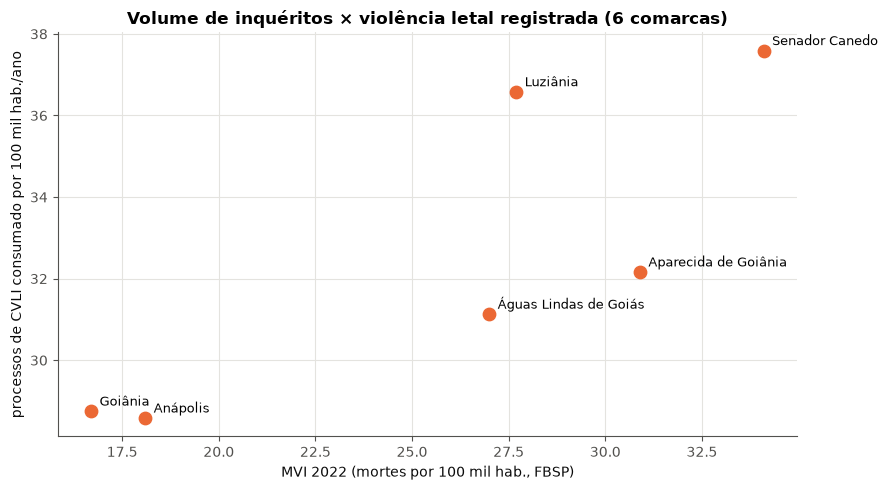

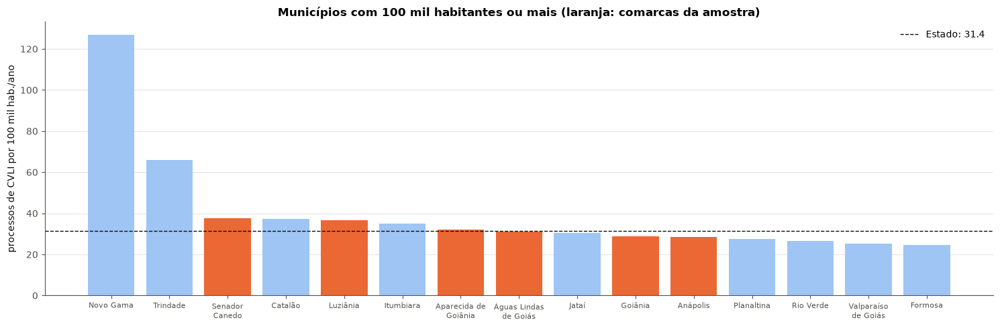

In [ ]:
MVI_2022 = pd.Series({'Águas Lindas de Goiás': 27.0, 'Anápolis': 18.1, 'Aparecida de Goiânia': 30.9, 'Goiânia': 16.7,
                      'Luziânia': 27.7, 'Senador Canedo': 34.1})  # Tabela 01 do estudo de caso (FBSP 2023; mortes/100 mil hab.)
anos_taxa = list(range(ANO_INICIO_COORTE, DATA_COLETA_DJ.year))
base_taxa = coorte_dj[coorte_dj['Ano_ajuizamento'].isin(anos_taxa)]
pop_municipio = municipios_ibge['Populacao_2022']


def taxa_por_municipio(df):
    t = (df.groupby('Codigo_IBGE').size() / len(anos_taxa)).rename('Processos por ano').to_frame()
    t = t.join(municipios_ibge[['Municipio', 'Populacao_2022']])
    t['Taxa por 100 mil hab./ano'] = 1e5 * t['Processos por ano'] / t['Populacao_2022']
    return t


taxa = taxa_por_municipio(base_taxa[base_taxa['Categoria_indicador'].eq('CVLI')])
taxa_com_tentados = taxa_por_municipio(base_taxa)
alvo = pd.DataFrame({
    'Processos de CVLI consumado/ano': taxa.set_index('Municipio').loc[list(MVI_2022.index), 'Processos por ano'],
    'Taxa CVLI consumado (por 100 mil)': taxa.set_index('Municipio').loc[list(MVI_2022.index), 'Taxa por 100 mil hab./ano'],
    'Taxa consumado + tentado (por 100 mil)': taxa_com_tentados.set_index('Municipio').loc[list(MVI_2022.index), 'Taxa por 100 mil hab./ano'],
    'MVI 2022 (FBSP)': MVI_2022})
taxa_estado = 1e5 * base_taxa['Categoria_indicador'].eq('CVLI').sum() / len(anos_taxa) / pop_municipio.sum()
print(f'Anos completos usados: {anos_taxa[0]}–{anos_taxa[-1]}; taxa estadual: {taxa_estado:.1f} processos de CVLI consumado por 100 mil hab./ano')
display(alvo.round(1))
for coluna in ['Taxa CVLI consumado (por 100 mil)', 'Taxa consumado + tentado (por 100 mil)']:
    print(f"Spearman ({coluna} × MVI 2022), 6 comarcas: {stats.spearmanr(alvo[coluna], alvo['MVI 2022 (FBSP)']).statistic:.2f}")
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(alvo['MVI 2022 (FBSP)'], alvo['Taxa CVLI consumado (por 100 mil)'], s=80, color=COR_DESTAQUE)
for m, linha in alvo.iterrows():
    ax.annotate(m, (linha['MVI 2022 (FBSP)'], linha['Taxa CVLI consumado (por 100 mil)']), textcoords='offset points', xytext=(6, 4), fontsize=9)
ax.set_xlabel('MVI 2022 (mortes por 100 mil hab., FBSP)')
ax.set_ylabel('processos de CVLI consumado por 100 mil hab./ano')
ax.set_title('Volume de inquéritos × violência letal registrada (6 comarcas)')
plt.tight_layout()
plt.show()
grandes = taxa[taxa['Populacao_2022'] >= 100_000].sort_values('Taxa por 100 mil hab./ano', ascending=False)
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(range(len(grandes)), grandes['Taxa por 100 mil hab./ano'],
       color=[COR_DESTAQUE if m in MVI_2022.index else COR_SECUNDARIA for m in grandes['Municipio']])
ax.axhline(taxa_estado, color=TINTA, linestyle='--', linewidth=1, label=f'Estado: {taxa_estado:.1f}')
ax.set_xticks(range(len(grandes)), [quebrar(m, 12) for m in grandes['Municipio']], fontsize=8, rotation=0)
ax.set_ylabel('processos de CVLI por 100 mil hab./ano')
ax.set_title('Municípios com 100 mil habitantes ou mais (laranja: comarcas da amostra)')
ax.legend()
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.show()

**Leitura.**

- **Estado:** cerca de 31 processos de CVLI consumado por 100 mil habitantes por ano (2022–2025).
- **Seis comarcas:** de cerca de 28 (Anápolis) a 37 (Senador Canedo).
- **Relação com a MVI:** a taxa de processos acompanha a MVI de 2022 da Tabela 01 (Spearman ρ ≈ **0,9**). Senador Canedo, Luziânia e Aparecida, com MVI alta, têm as maiores taxas; Goiânia e Anápolis, com MVI menor, as menores.
- **Sensibilidade:** incluindo as tentativas, a correlação cai para cerca de 0,6. As tentativas não entram no indicador de mortes.

**Cautela.** A taxa de processos supera a MVI em todas as comarcas: há mais processos que mortes. É compatível com as ressalvas da tabela acima: mais de um processo por fato, comarcas que abrangem municípios vizinhos e defasagem do ajuizamento. Com seis pontos, a correlação é descritiva.

### 22.13 O que a população confirma

Cada achado da Etapa 1, o teste correspondente na população e o resultado.

In [ ]:
def hr_de(tabela, termo, coluna='HR'):
    return (tabela.loc[termo, coluna], tabela.loc[termo, 'p-valor']) if termo in tabela.index else (np.nan, np.nan)


def veredito(efeito_a, p_a, efeito_p, p_p, neutro=1.0):
    # confirma: mesmo sentido e significativo nas duas; contradiz: sentido oposto e significativo na população
    if np.isnan(efeito_p):
        return 'não testável'
    mesmo_sentido = np.sign(np.log(efeito_a / neutro)) == np.sign(np.log(efeito_p / neutro))
    if p_p < 0.05 and mesmo_sentido and p_a < 0.05:
        return 'confirma'
    if p_p < 0.05 and not mesmo_sentido:
        return 'contradiz'
    if p_p >= 0.05 and p_a < 0.05:
        return 'não se confirma'
    return 'mesmo sentido; significativo só na população' if mesmo_sentido else 'inconclusivo'


linhas = []
for rotulo, termo_a, termo_p in [('Aparecida de Goiânia × Goiânia (Cox)', 'Comarca=Aparecida de Goiânia', 'Comarca_modelo=Aparecida de Goiânia'),
                                 ('Flagrante/prisão (Cox): amostra APF × população indício de prisão',
                                  'Forma_instauracao=Auto de prisão em flagrante (APF)', 'Indicio_prisao'),
                                 ('Homicídio qualificado × simples (Cox)', 'Assunto_grupo=Homicídio qualificado', 'Tipo_modelo=Homicídio qualificado'),
                                 ('Tentado × consumado (Cox)', 'Tentativa', 'Tentado')]:
    (ha, pa), (hp, pp) = hr_de(resumo_cox, termo_a), hr_de(resumo_cox_dj, termo_p)
    linhas.append({'Achado': rotulo, 'Amostra': f'HR = {ha:.2f} (p = {pa:.2g})', 'População': f'HR = {hp:.2f} (p = {pp:.2g})',
                   'Veredito': veredito(ha, pa, hp, pp)})
or_apf = pd.DataFrame(resumo_2x2).set_index('Variável').loc['Forma_instauracao']
op, pp = hr_de(or_den_dj, 'Indicio_prisao', 'OR')
linhas.append({'Achado': 'Flagrante/prisão aumenta a chance de denúncia',
               'Amostra': f"OR (Fisher, APF) = {or_apf['OR']:.1f} (p = {or_apf['p (Fisher)']:.2g})",
               'População': f'OR (logística, indício de prisão) = {op:.1f} (p = {pp:.2g})',
               'Veredito': veredito(or_apf['OR'], or_apf['p (Fisher)'], op, pp)})
den = comparacao[comparacao['Indicador'].eq('Denúncia') & comparacao['Nível'].str.startswith('Amostra ≥')].iloc[0]
linhas.append({'Achado': 'Denúncia é rara', 'Amostra': f"{den['% amostra']:.1f}% (instaurados ≥ 2022)",
               'População': f"{den['% população = p₀']:.1f}% (6 comarcas, 2022+)",
               'Veredito': 'contradiz' if den['p BH'] < 0.05 else 'confirma'})
linhas.append({'Achado': 'O tempo não é normal (assimetria à direita)',
               'Amostra': f"W = {normalidade.loc[(DESFECHOS['Tempo_fase_judicial'], 'original (dias)'), 'Shapiro-Wilk W']:.3f}; assimetria = "
                          f"{normalidade.loc[(DESFECHOS['Tempo_fase_judicial'], 'original (dias)'), 'Assimetria']:.2f}",
               'População': f'W = {stats.shapiro(sub_sw).statistic:.3f}; assimetria = {stats.skew(x_dj):.2f}', 'Veredito': 'confirma'})
linhas.append({'Achado': 'Família da fase judicial (concluídos)', 'Amostra': f"melhor AIC: {tabelas_conc['Tempo_fase_judicial'].index[0]}",
               'População': f'melhor AIC: {tabela_conc_dj.index[0]}', 'Veredito': 'parcial: a forma depende da composição dos desfechos'})
confirmacao = pd.DataFrame(linhas).set_index('Achado')
with pd.option_context('display.max_colwidth', 120):
    display(confirmacao)

,Amostra,População,Veredito
Achado,,,
Aparecida de Goiânia × Goiânia (Cox),HR = 2.24 (p = 8.6e-05),HR = 1.00 (p = 0.99),não se confirma
Flagrante/prisão (Cox): amostra APF × população indício de prisão,HR = 0.37 (p = 0.018),HR = 1.47 (p = 9.5e-66),contradiz
Homicídio qualificado × simples (Cox),HR = 0.68 (p = 0.068),HR = 1.40 (p = 2.6e-63),contradiz
Tentado × consumado (Cox),HR = 1.18 (p = 0.41),HR = 0.95 (p = 0.02),contradiz
Flagrante/prisão aumenta a chance de denúncia,"OR (Fisher, APF) = 21.6 (p = 0.001)","OR (logística, indício de prisão) = 15.2 (p = 1e-295)",confirma
Denúncia é rara,6.7% (instaurados ≥ 2022),"36.8% (6 comarcas, 2022+)",contradiz
O tempo não é normal (assimetria à direita),W = 0.737; assimetria = 1.74,W = 0.644; assimetria = 2.47,confirma
Família da fase judicial (concluídos),melhor AIC: Weibull,melhor AIC: Gama generalizada,parcial: a forma depende da composição dos desfechos


**Leitura.** A população **confirma** a não normalidade e a forte associação entre prisão/flagrante e denúncia. Mas **contradiz** três achados da amostra:

1. **A denúncia não é rara:** é cerca de 36% na população, contra 2,8% na amostra;
2. **Flagrante/prisão e homicídio qualificado aceleram o desfecho:** na amostra, pareciam alongá-lo;
3. **Aparecida não é mais rápida que Goiânia** depois do ajuizamento: HR ≈ 1.

As três divergências têm a mesma origem: a amostra perdeu os inquéritos que viraram ação penal, justamente os mais rápidos e os qualificados ou com prisão. **A lição metodológica do estudo é que o desenho da amostra determina as conclusões sobre o tempo.**

---

# SÍNTESE

## 23. Exportação Final e Conclusões

### 23.1 Bases exportadas

As variáveis de desfecho criadas nas Partes II e III são acrescentadas ao dataset da amostra, que é regravado. A base da população, já tratada, é gravada sem a lista bruta de movimentos. As duas ficam prontas para estudos posteriores.

In [ ]:
dados = dados.drop(columns=['Desfecho_top6'], errors='ignore')  # auxiliar do Exercício 4, reconstruível
NOVAS_VARIAVEIS = pd.DataFrame([
    ('Tempo_fase_judicial', 'Tempo', 'Quantitativa discreta (censurada)', 'Int64', 'dias', 'Derivada (seção 15)', 'Desfecho'),
    ('Tempo_total', 'Tempo', 'Quantitativa discreta (censurada, truncada)', 'Int64', 'dias', 'Derivada (seção 15)', 'Desfecho'),
    ('Idade_entrada_anos', 'Tempo', 'Quantitativa contínua', 'Float64', 'anos', 'Derivada (seção 15)', 'Entrada tardia'),
    ('Multiplas_vitimas', 'Caso', 'Qualitativa dicotômica', 'boolean', '', 'Derivada (seção 15)', 'Categórica'),
    ('Ano_recebimento_projudi', 'Tempo', 'Qualitativa ordinal', 'category', '', 'Derivada (seção 15)', 'Categórica'),
    ('Coorte_instauracao', 'Tempo', 'Qualitativa ordinal', 'category', '', 'Derivada (seção 15)', 'Categórica'),
    ('Tipo_desfecho', 'Desfecho', 'Qualitativa nominal', 'category', '', 'Derivada (seção 17)', 'Categórica'),
], columns=['Variável', 'Grupo', 'Tipo estatístico', 'dtype pandas', 'Unidade', 'Origem', 'Uso analítico'])
NOVAS_VARIAVEIS['Não nulos'] = [int(dados[v].notna().sum()) for v in NOVAS_VARIAVEIS['Variável']]
NOVAS_VARIAVEIS['Ausentes'] = [int(dados[v].isna().sum()) for v in NOVAS_VARIAVEIS['Variável']]
NOVAS_VARIAVEIS['Distintos'] = [int(dados[v].nunique()) for v in NOVAS_VARIAVEIS['Variável']]
ESQUEMA_FINAL = pd.concat([ESQUEMA_EXPORT, NOVAS_VARIAVEIS], ignore_index=True)
assert set(ESQUEMA_FINAL['Variável']) == set(dados.columns), set(ESQUEMA_FINAL['Variável']) ^ set(dados.columns)
divergentes = [v for v, t in zip(ESQUEMA_FINAL['Variável'], ESQUEMA_FINAL['dtype pandas']) if str(dados[v].dtype) != t]
assert not divergentes, divergentes

dados.to_pickle(ARQUIVO_PKL)
with pd.ExcelWriter(ARQUIVO_XLSX, engine='openpyxl') as planilha:
    dados.to_excel(planilha, sheet_name='dados')
    ESQUEMA_FINAL.to_excel(planilha, sheet_name='esquema', index=False)
    auditoria.to_excel(planilha, sheet_name='auditoria', index=False)
    diligencias_longas.to_excel(planilha, sheet_name='diligencias_longas', index=False)
pd.testing.assert_frame_equal(pd.read_pickle(ARQUIVO_PKL), dados)

ARQUIVO_POP = PASTA_SAIDA / 'rafaelcc_datajud_cvli_go.pkl'
pop.drop(columns=['Movimentos']).to_pickle(ARQUIVO_POP)
print(f'Amostra: {ARQUIVO_PKL.name} ({dados.shape[0]} × {dados.shape[1]}) | '
      f'População: {ARQUIVO_POP.name} ({len(pop):,} processos × {pop.shape[1] - 1} variáveis)')

Amostra: rafaelcc_ip_limpo.pkl (218 × 68) | População: rafaelcc_datajud_cvli_go.pkl (36,514 processos × 50 variáveis)


### 23.2 Reporte analítico

**1. Curadoria.**
- **Tratamento:** a base foi limpa sem imputação. Foram:
  - corrigidos os homóglifos de OCR;
  - separados os três tipos de ausência;
  - removidos os zeros estruturais;
  - normalizadas as categorias em partições verificadas;
  - aplicados tipos explícitos.
- **Incoerências documentadas:** 24 registros, entre eles data malformada, prescrições impossíveis e status sem indiciado. Somam-se a eles os 13 procedimentos "concluídos no MP" que seguem ativos.
- **No DataJud:** os desfechos anteriores ao ajuizamento e as ações penais sem marco de denúncia, também documentados.

**2. O que é o "tempo de tramitação".**
- **Tempo total:** a variável do professor (`Tempo_conclusao_ip`) é a idade do inquérito na chegada ao Projudi (r = −0,98 com o ano de instauração). O tempo total não é estimável sem viés com esta amostra: 1.764 dias com censura, 140 com entrada tardia, e o teste de Tsai rejeita a hipótese da correção.
- **Fase judicial:** é a medida comparável. Na amostra, mediana de Kaplan-Meier de **110 dias**; na população 2022+, de cerca de **2 meses**.

**3. Distribuição.**
- **Normalidade:** rejeitada em todas as escalas, nas duas bases. Por isso os testes de postos e os modelos de duração.
- **Família:** a gama generalizada não é necessária na amostra (Weibull e gama bastam). Na população, ela vence, com a lognormal como forma limite. Nenhuma família única é aderente, porque o tempo é uma mistura de regimes: o arquivamento imediato e o ciclo de diligências.

**4. Fatores do tempo.**
- **Amostra:** Aparecida de Goiânia (HR 2,2), APF (0,37), arma de fogo (0,65) e idade na chegada (1,06/ano), robustos ao Cox estratificado e aos AFT.
- **População:** o que acelera o desfecho é o **tipo de caso** (feminicídio, qualificado, latrocínio) e a **prisão**, e não a comarca.

**5. Desfechos.**
- **Indiciamento:** associado ao flagrante (OR 11) e à recência (AUC 0,75).
- **Denúncia:** na população, associada à prisão (OR ≈ 15) e à gravidade (qualificado/feminicídio OR ≈ 11), com AUC ≈ 0,90.
- **Extinção da punibilidade:** concentrada fora de Goiânia.

**6. Amostra × população.** A amostra sub-representa as denúncias (2,8% × cerca de 36%), os qualificados e os presos, o que inverte o sentido de alguns efeitos. É o achado mais importante para quem for usar a amostra: **as conclusões sobre tempo dependem de quais inquéritos entram na base**.

**7. Visualização.**
- Os gráficos decisivos foram o dispersograma tempo × ano de instauração, o diagrama de Lexis, as curvas de Kaplan-Meier com e sem censura e a comparação de proporções amostra × população.
- Os testes de postos foram acompanhados de boxplots com letras do post-hoc, e os ajustes de distribuição da FDA empírica × teórica.

### 23.3 Limitações e próximos passos

**Limitações.**
- **Amostra:** não tem o número CNJ. O vínculo com o DataJud é aproximado (cerca de 20% dos IPs recentes), e a data de referência da coleta (12/03/2026) foi inferida.
- **Ações penais:** a amostra parece excluir os inquéritos que viraram ação penal. Convém confirmar o critério de seleção com o pesquisador que a coletou.
- **DataJud:**
  - não identifica quem praticou cada ato, e o retorno da polícia e a manifestação do MP são **proxies** baseados em movimentos e tipos de petição;
  - não informa a data de instauração, nem distingue as mortes por intervenção policial (por isso mede CVLI, e não MVI);
  - a classe de origem (APF) se perde nas ações penais.
- **Taxas por habitante:** contam processos, e não mortes, e usam a população da sede da comarca.
- **Validação manual das regras textuais:** é preliminar e precisa ser confirmada pelo autor.

**Próximos passos.**
1. Obter o número CNJ da amostra para um vínculo exato.
2. Coletar a data de instauração (Atena) para os processos do DataJud.
3. Modelar os desfechos concorrentes (denúncia, arquivamento, extinção) com incidência acumulada (Aalen-Johansen, Fine-Gray).
4. Estender a coleta ao estoque antigo para estudar a prescrição.

---

## Referências

### Métodos
- Kaplan, E. L.; Meier, P. (1958). Nonparametric estimation from incomplete observations. *JASA*, 53, 457–481.
- Cox, D. R. (1972). Regression models and life-tables. *JRSS-B*, 34, 187–220.
- Grambsch, P. M.; Therneau, T. M. (1994). Proportional hazards tests and diagnostics based on weighted residuals. *Biometrika*, 81, 515–526.
- Tsai, W.-Y. (1990). Testing the assumption of independence of truncation time and failure time. *Biometrika*, 77, 169–177.
- Prentice, R. L. (1974). A log gamma model and its maximum likelihood estimation. *Biometrika*, 61, 539–544 (gama generalizada).
- Cox, C. et al. (2007). Parametric survival analysis and taxonomy of hazard functions for the generalized gamma distribution. *Statistics in Medicine*, 26, 4352–4374.
- Dunn, O. J. (1964). Multiple comparisons using rank sums. *Technometrics*, 6, 241–252.
- Benjamini, Y.; Hochberg, Y. (1995). Controlling the false discovery rate. *JRSS-B*, 57, 289–300.

### Dados e conceitos
- CNJ. API Pública do DataJud — https://datajud-wiki.cnj.jus.br/api-publica/ ; Tabelas Processuais Unificadas (TPU) — https://www.cnj.jus.br/sgt/consulta_publica_classes.php
- Fórum Brasileiro de Segurança Pública (2023). *Anuário Brasileiro de Segurança Pública* (Mortes Violentas Intencionais).
- MJSP/Senasp. Indicadores de Crimes Violentos Letais Intencionais (CVLI).
- IBGE. Censo Demográfico 2022 (tabela 4709) e cadastro de municípios (API de localidades).

### Bibliotecas
pandas, numpy, scipy, statsmodels, lifelines, scikit-posthocs, matplotlib, seaborn.

### Base legal
Código de Processo Penal, art. 10 (prazos do inquérito); Código Penal, arts. 14, II (tentativa), 109 (prescrição), 121, 129 §3º e 157 §3º.